# Phasing

Wrote table: haplotype_skew_summary_noncyclo_individual.tsv
Wrote figure: haplotype_skew_plot_noncyclo_jitter_individual.pdf


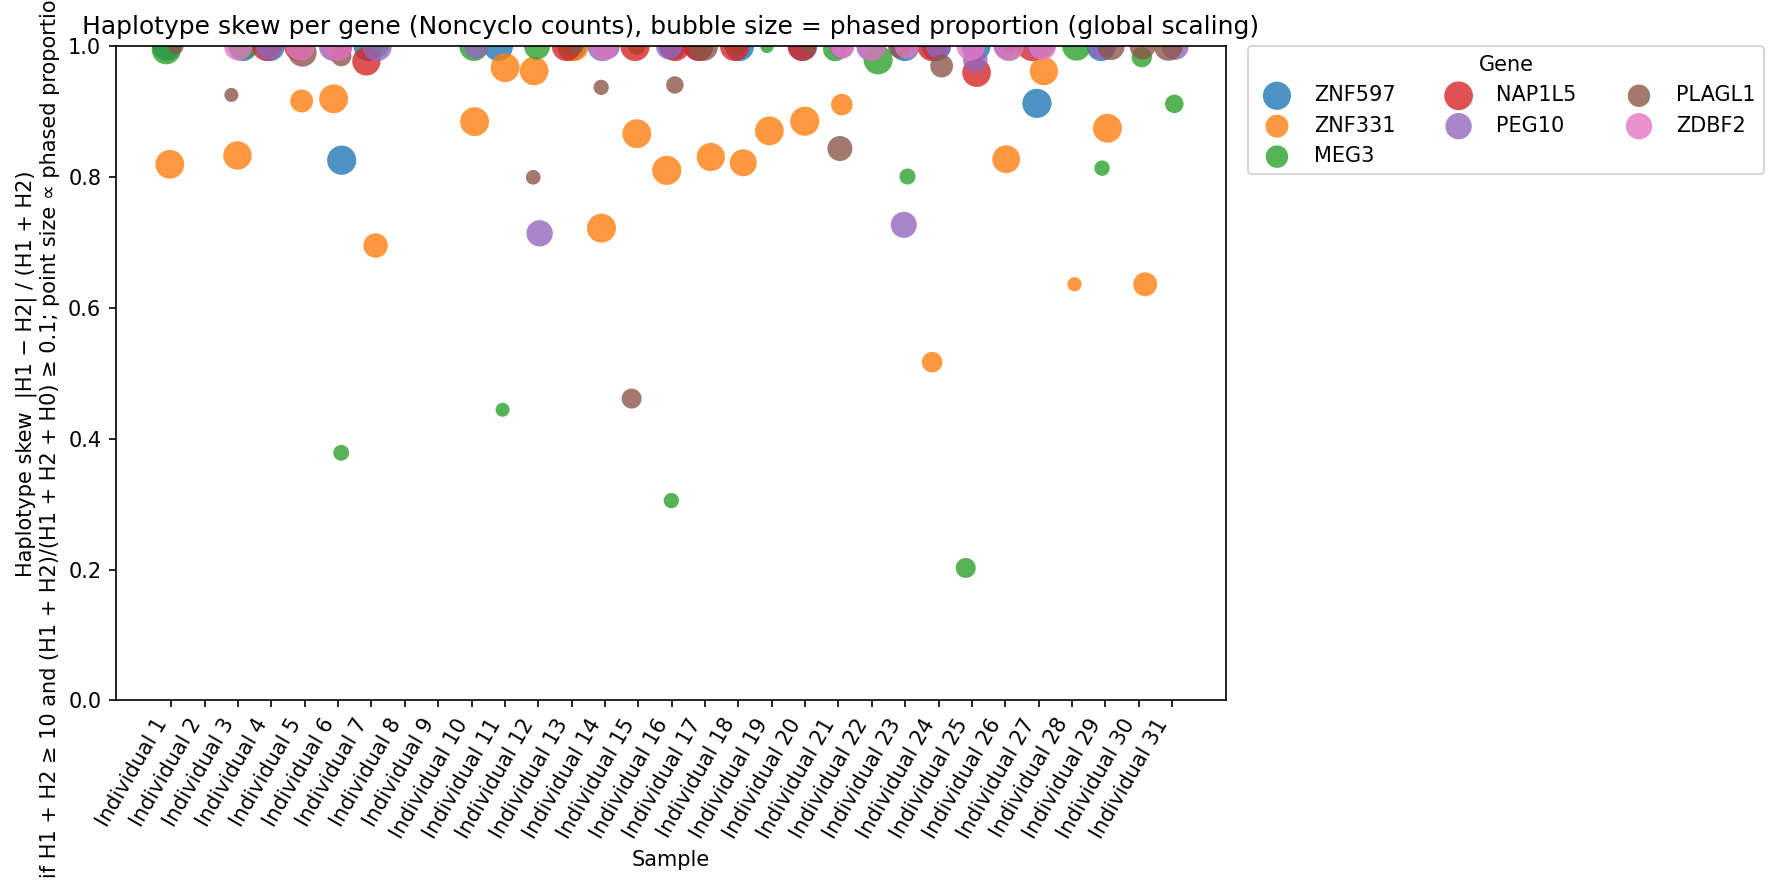

In [1]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

################
#  Inputs
################
FILE = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz"
GENES_OF_INTEREST = ["ZNF597", "ZNF331", "MEG3", "NAP1L5", "PEG10", "PLAGL1", "ZDBF2", "DLK1"]
OUT_TABLE = "haplotype_skew_summary_noncyclo_individual.tsv"
OUT_FIG   = "haplotype_skew_plot_noncyclo_jitter_individual.pdf"
MIN_TOTAL = 10         # require H1 + H2 >= 10 to compute skew
PHASED_PROP_MIN = 0.1  # require (H1 + H2)/(H1 + H2 + H0) >= 0.1 to compute skew

df = pd.read_csv(FILE, sep="\t", compression='gzip')

################
# Rename samples
################
sample_rename = {
    "UDN687128": "Individual 1",
    "UDN215640": "Individual 2",
    "UDN633333": "Individual 3",
    "UDN318336": "Individual 4",
    "UDN052264": "Individual 5",
    "UDN212054": "Individual 6",
    "UDN355246": "Individual 7",
    "UDN860070": "Individual 8",
    "UDN353099": "Individual 9",
    "UDN305049": "Individual 10",
    "UDN310876": "Individual 11",
    "BCH_1199-01": "Individual 12",
    "BCH_1877-01": "Individual 13",
    "BCH_310-01": "Individual 14",
    "UDN121217": "Individual 15",
    "UDN374570": "Individual 16",
    "UDN827597": "Individual 17",
    "UDN966087": "Individual 18",
    "UDN204349": "Individual 19",
    "UDN359892": "Individual 20",
    "UDN262407": "Individual 21",
    "UDN924176": "Individual 22",
    "UDN666440": "Individual 23",
    "UDN178694": "Individual 24",
    "BCH_1986-01": "Individual 25",
    "BCH_0252-01": "Individual 26",
    "BCH_2275-01": "Individual 27",
    "BCH_2401-01": "Individual 28",
    "BCH_2410-01": "Individual 29",
    "BCH_2443-01": "Individual 30",
    "UDN010451": "Individual 31"
}

df["Sample"] = df["Sample"].replace(sample_rename)

################
# Order samples 
################
df["Sample_num"] = df["Sample"].str.extract(r"Individual (\d+)", expand=False).astype(float)
sample_order = df.sort_values("Sample_num")["Sample"].unique()

# exact columns per your file
sample_col = "Sample"
gene_col   = "associated_gene"
h0_col     = "H0_noncyclo_count"
h1_col     = "H1_noncyclo_count"
h2_col     = "H2_noncyclo_count"

# keep original sample order
#sample_order = pd.unique(df[sample_col])

################
#  Filter to genes of interest
################
df = df[df[gene_col].isin(GENES_OF_INTEREST)].copy()

################
# Compute haplotype skew only if thresholds are met
################

den = df[h1_col] + df[h2_col]
num = (df[h1_col] - df[h2_col]).abs()
phased_proportion = den / (den + df[h0_col])

df["haplotype_skew"] = np.where(
    (den >= MIN_TOTAL) & (phased_proportion >= PHASED_PROP_MIN),
    num / den,
    np.nan
)
df["phased_proportion"] = phased_proportion  # for point sizing

################
# Prepare pivots for plotting
################
tidy = df.rename(columns={
    sample_col: "Sample",
    gene_col: "Gene",
    h0_col: "H0_noncyclo_count",
    h1_col: "H1_noncyclo_count",
    h2_col: "H2_noncyclo_count"
})[["Sample", "Gene", "H0_noncyclo_count", "H1_noncyclo_count", "H2_noncyclo_count", "haplotype_skew", "phased_proportion"]]

tidy.sort_values(["Sample", "Gene"]).to_csv(OUT_TABLE, sep="\t", index=False)
print(f"Wrote table: {OUT_TABLE}")

pivot_skew = (
    tidy.pivot(index="Sample", columns="Gene", values="haplotype_skew")
        .reindex(sample_order)
)
pivot_phase = (
    tidy.pivot(index="Sample", columns="Gene", values="phased_proportion")
        .reindex(sample_order)
)

################
#  Global min/max for phased_proportion across all plotted points 
################

valid_phase = (
    tidy.loc[tidy["haplotype_skew"].notna(), "phased_proportion"]
      .dropna()
      .astype(float)
)
if valid_phase.empty:
    G_MIN, G_MAX = 0.0, 0.0  # fallback; loop will use mid-size
else:
    G_MIN, G_MAX = valid_phase.min(), valid_phase.max()

################
# plot points. Size ~ global phased_proportion
################
plt.figure(figsize=(12, 6), dpi=150)

# matplotlib 's' is marker *area* in points^2
S_MIN, S_MAX = 36, 196
x_positions = np.arange(len(pivot_skew.index))  # numeric x for samples

for gene in [g for g in GENES_OF_INTEREST if (g in pivot_skew.columns and g in pivot_phase.columns)]:
    y = pivot_skew[gene]
    p = pivot_phase[gene]

    mask = y.notna() & p.notna()
    if not mask.any():
        continue

    phase_vals = p[mask].astype(float)

    # GLOBAL scaling: same mapping for every gene
    if G_MIN == G_MAX:
        sizes = np.full(mask.sum(), (S_MIN + S_MAX) / 2.0)
    else:
        sizes = np.interp(phase_vals, (G_MIN, G_MAX), (S_MIN, S_MAX))

    # jittered x positions
    jitter = np.random.uniform(-0.2, 0.2, size=mask.sum())
    x_jittered = x_positions[mask] + jitter

    plt.scatter(
        x_jittered, y[mask], s=sizes,
        label=gene, alpha=0.8, edgecolors="none", linewidth=0.4
    )

plt.ylim(0, 1)
plt.ylabel(
    f"Haplotype skew  |H1 − H2| / (H1 + H2)\n"
    f"(only if H1 + H2 ≥ {MIN_TOTAL} and (H1 + H2)/(H1 + H2 + H0) ≥ {PHASED_PROP_MIN}; "
    f"point size ∝ phased proportion, globally scaled)"
)
plt.xlabel("Sample")
plt.title("Haplotype skew per gene (Noncyclo counts), bubble size = phased proportion (global scaling)")
plt.xticks(x_positions, pivot_skew.index, rotation=60, ha="right")

# Put legend outside on the right, 3 columns
ax = plt.gca()
ax.legend(title="Gene", ncols=3, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.savefig(OUT_FIG, bbox_inches="tight")
print(f"Wrote figure: {OUT_FIG}")


In [10]:
df

,associated_gene,Sample,cyclo_count,noncyclo_count,Cyclo_TPM,Noncyclo_TPM,total_cyclo,total_noncyclo,H0_cyclo_count,H1_cyclo_count,...,Noncyclo_TPM_Rank,Cyclo_TPM_Median,Noncyclo_TPM_Median,Cyclo_TPM_Mean,Noncyclo_TPM_Mean,NoncycloHaplotypeDifference,test_statistic,z_score_of_test_stat,haplotype_skew,phased_proportion
129301,DLK1,Patient 26,0,0,0.000000,0.000000,6655126,4374709,0,0,...,22.5,0.000000,0.000000,0.253004,0.215243,NaN,0.000000,0.000000,NaN,NaN
129302,DLK1,Patient 12,2,1,0.299390,0.231353,6680255,4322405,0,2,...,9.0,0.000000,0.000000,0.253004,0.215243,1.0,0.000000,0.000000,NaN,1.000000
129303,DLK1,Patient 13,0,0,0.000000,0.000000,4960980,4963482,0,0,...,22.5,0.000000,0.000000,0.253004,0.215243,NaN,0.000000,0.000000,NaN,NaN
129304,DLK1,Patient 25,0,1,0.000000,0.177113,5700954,5646105,0,0,...,13.0,0.000000,0.000000,0.253004,0.215243,1.0,0.000000,0.000000,NaN,1.000000
129305,DLK1,Patient 27,0,5,0.000000,0.802960,5299150,6226963,0,0,...,3.0,0.000000,0.000000,0.253004,0.215243,-1.0,0.000000,0.000000,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613423,ZNF597,Patient 1,131,30,20.116856,4.562202,6511952,6575772,6,0,...,10.0,13.201646,4.141732,14.913099,4.496648,-1.0,23.837581,0.750188,1.0,0.966667
613424,ZNF597,Patient 17,67,40,12.869724,7.071252,5206017,5656707,0,67,...,4.0,13.201646,4.141732,14.913099,4.496648,1.0,28.128531,1.132014,1.0,0.975000
613425,ZNF597,Patient 8,76,19,11.607386,3.119137,6547555,6091428,76,0,...,26.0,13.201646,4.141732,14.913099,4.496648,NaN,0.000000,-1.467500,NaN,0.000000
613426,ZNF597,Patient 22,42,29,7.138433,5.116962,5883644,5667425,1,3,...,8.0,13.201646,4.141732,14.913099,4.496648,-1.0,23.837581,0.750188,1.0,1.000000


# Hierarchical clustering

In [18]:
def filter_based_on_counts(df, count_threshold=10, group_col='Isoform'):
    """
    Filter isoforms based on count thresholds.
    
    Parameters:
    - df (pd.DataFrame): The input long-format DataFrame.
    - count_threshold (int): The threshold for filtering counts.
    - group_col (str): The column to group by (e.g., 'Isoform', 'Isoform_PBid').
    
    Returns:
    - pd.DataFrame: Filtered DataFrame with only the groups meeting the count threshold.
    """
    # Determine isoforms/groups to keep based on the threshold
    isoforms_to_keep = df.groupby(group_col).apply(
        lambda group: any(group['cyclo_count'] >= count_threshold) or any(group['noncyclo_count'] >= count_threshold)
    )
    isoforms_to_keep = isoforms_to_keep[isoforms_to_keep].index.tolist()

    # Filter the DataFrame to include only the isoforms/groups to keep
    return df[df[group_col].isin(isoforms_to_keep)]

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D

def process_and_plot_dendrogram_log(
    df,
    output_pdf="hc_dendrogram.pdf",
    grouping_col="associated_gene",
    linkage_method="average",     # e.g., "average", "complete", "single", "ward"
    metric="euclidean",           # e.g., "euclidean", "cosine", "correlation", etc.
    standardize=True,             # z-score features (recommended)
    n_clusters=None,              # set an integer to cut the tree into k clusters
    distance_threshold=None,      # or cut at a distance (incompatible with n_clusters)
    orientation="left",           # "left" puts samples on the y-axis (good for many samples)
    label_fontsize=12
):
    """
    Performs hierarchical clustering on transcript expression data and generates a dendrogram.

    Parameters:
    - df (pd.DataFrame): Input with columns:
        - 'Sample' (str): identifier for each sample.
        - grouping_col (str): gene/isoform column (e.g., 'associated_gene' or 'Isoform').
        - 'Cyclo_TPM' (float): TPM values for CHX-treated samples.
        - 'Noncyclo_TPM' (float): TPM values for untreated samples.
    - output_pdf (str): Where to save the dendrogram PDF.
    - grouping_col (str): Column to group TPM values by (genes or isoforms).
    - linkage_method (str): Linkage method for clustering.
    - metric (str): Distance metric for pairwise distances.
    - standardize (bool): Z-score features across samples before clustering.
    - n_clusters (int or None): If set, assigns cluster IDs by cutting the tree into k clusters.
    - distance_threshold (float or None): If set, assigns cluster IDs by cutting at a distance.
      (Do not set together with n_clusters.)
    - orientation (str): "left", "right", "top", or "bottom".
    - label_fontsize (int): Font size for sample labels on the dendrogram.

    Returns:
    - pd.DataFrame with:
        - 'Sample' (str)
        - 'Condition' (Cyclo/Noncyclo)
        - 'Order' (int): plotting order from the dendrogram
        - 'Cluster' (int, optional): present if n_clusters or distance_threshold is provided

    Notes:
    - Mirrors the preprocessing in process_and_plot_pca():
      filters by count threshold (via filter_based_on_counts),
      aggregates TPM by Sample x grouping_col, duplicates into Cyclo/Noncyclo,
      pivots to samples x features, removes all-zero rows, optionally standardizes,
      then performs hierarchical clustering and plots the dendrogram.
    """

    # 1) Filter (uses your existing helper)
    df_filtered = filter_based_on_counts(df, count_threshold=10, group_col=grouping_col)

    # 2) Group by Sample and grouping_col and sum TPM values
    grouped_df = (
        df_filtered.groupby(["Sample", grouping_col])[["Cyclo_TPM", "Noncyclo_TPM"]]
        .sum()
        .reset_index()
    )

    # 3) Build Cyclo / Noncyclo long tables
    cyclo_df = grouped_df[["Sample", grouping_col, "Cyclo_TPM"]].copy()
    noncyclo_df = grouped_df[["Sample", grouping_col, "Noncyclo_TPM"]].copy()
    cyclo_df.columns = ["Sample", grouping_col, "TPM"]
    noncyclo_df.columns = ["Sample", grouping_col, "TPM"]
    cyclo_df["Sample"] = cyclo_df["Sample"] + "_Cyclo"
    noncyclo_df["Sample"] = noncyclo_df["Sample"] + "_Noncyclo"

    final_df = pd.concat([cyclo_df, noncyclo_df], ignore_index=True)

    # 4) Pivot to samples x features, fill NAs with 0, drop all-zero rows
    pivot_df = final_df.pivot(index="Sample", columns=grouping_col, values="TPM").fillna(0)
    pivot_df = pivot_df.loc[pivot_df.any(axis=1)]

    pivot_df = pivot_df.apply(np.log1p)  # log(1 + TPM) #THIS LINE IS CRITICAL

    if pivot_df.shape[0] < 2:
        raise ValueError("Need at least two samples (rows) after filtering/pivoting to build a dendrogram.")

    # 5) Optional standardization (feature-wise z-score)
    X = pivot_df.values
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # 6) Pairwise distances and linkage
    dists = pdist(X, metric=metric)
    Z = linkage(dists, method=linkage_method)

    # 7) Plot dendrogram
    labels = pivot_df.index.tolist()
    n_samples = len(labels)
    # Size heuristic: taller figure for more samples if horizontal dendrogram (left/right)
    if orientation in ("left", "right"):
        figsize = (8, max(2, 0.25 * n_samples + 2))
    else:
        figsize = (max(6, 0.25 * n_samples + 2), 6)

    fig, ax = plt.subplots(figsize=figsize)
    dendro = dendrogram(
        Z,
        labels=labels,
        orientation=orientation,
        leaf_font_size=label_fontsize,
        above_threshold_color="gray",  # keep link colors neutral
        ax=ax
    )

    ax.set_title("Hierarchical Clustering Dendrogram")
    # Axis label depends on orientation
    if orientation in ("left", "right"):
        ax.set_xlabel("Distance")
    else:
        ax.set_ylabel("Distance")

    # 8) Color leaf labels by condition
    color_mapping = {"Cyclo": "red", "Noncyclo": "blue"}
    # Tick labels are on the axis perpendicular to the dendrogram leaves
    ticklabels = ax.get_yticklabels() if orientation in ("left", "right") else ax.get_xticklabels()
    for tl in ticklabels:
        s = tl.get_text()
        cond = "Cyclo" if s.endswith("_Cyclo") else "Noncyclo"
        tl.set_color(color_mapping.get(cond, "black"))

    # Legend for conditions
    legend_elems = [
        Line2D([0], [0], marker='o', linestyle='', label='Cyclo', markerfacecolor=color_mapping["Cyclo"]),
        Line2D([0], [0], marker='o', linestyle='', label='Noncyclo', markerfacecolor=color_mapping["Noncyclo"]),
    ]
    ax.legend(handles=legend_elems, title="Condition", loc="best")

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close(fig)

    # 9) Build result DataFrame (order matches dendrogram leaf order)
    ordered_labels = dendro["ivl"]
    order_map = {lab: i for i, lab in enumerate(ordered_labels)}
    out = pd.DataFrame({
        "Sample": ordered_labels,
        "Condition": ["Cyclo" if s.endswith("_Cyclo") else "Noncyclo" for s in ordered_labels],
        "Order": [order_map[s] for s in ordered_labels],
    })

    # Optional, assign clusters
    if (n_clusters is not None) and (distance_threshold is not None):
        raise ValueError("Provide either n_clusters or distance_threshold, not both.")
    if n_clusters is not None:
        clusters = fcluster(Z, t=n_clusters, criterion="maxclust")
        # clusters are in the original row order; map to labels
        sample_to_cluster = {lab: clusters[i] for i, lab in enumerate(labels)}
        out["Cluster"] = [sample_to_cluster[s] for s in ordered_labels]
    elif distance_threshold is not None:
        clusters = fcluster(Z, t=distance_threshold, criterion="distance")
        sample_to_cluster = {lab: clusters[i] for i, lab in enumerate(labels)}
        out["Cluster"] = [sample_to_cluster[s] for s in ordered_labels]

    return out


In [20]:
# Same df you use for PCA:
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/long_format_annotated.tsv.gz", 
                 sep='\t',           # Tab-separated
                 compression='gzip') # Specify the compression type

In [21]:
# ---------- rename samples (preserve suffixes like _cyclo) ----------
sample_rename = {
    "UDN687128": "Individual 1",
    "UDN215640": "Individual 2",
    "UDN633333": "Individual 3",
    "UDN318336": "Individual 4",
    "UDN052264": "Individual 5",
    "UDN212054": "Individual 6",
    "UDN355246": "Individual 7",
    "UDN860070": "Individual 8",
    "UDN353099": "Individual 9",
    "UDN305049": "Individual 10",
    "UDN310876": "Individual 11",
    "BCH_1199-01": "Individual 12",
    "BCH_1877-01": "Individual 13",
    "BCH_310-01": "Individual 14",
    "UDN121217": "Individual 15",
    "UDN374570": "Individual 16",
    "UDN827597": "Individual 17",
    "UDN966087": "Individual 18",
    "UDN204349": "Individual 19",
    "UDN359892": "Individual 20",
    "UDN262407": "Individual 21",
    "UDN924176": "Individual 22",
    "UDN666440": "Individual 23",
    "UDN178694": "Individual 24",
    "BCH_1986-01": "Individual 25",
    "BCH_0252-01": "Individual 26",
    "BCH_2275-01": "Individual 27",
    "BCH_2401-01": "Individual 28",
    "BCH_2410-01": "Individual 29",
    "BCH_2443-01": "Individual 30",
    "UDN010451": "Individual 31"
}

def rename_sample_with_suffix(name):
    """Convert e.g. 'UDN687128_cyclo' -> 'Individual 1_cyclo'."""
    for old, new in sample_rename.items():
        if name.startswith(old):
            return name.replace(old, new, 1)
    return name  # unchanged if not in map

df["Sample"] = df["Sample"].apply(rename_sample_with_suffix)


In [22]:
dendro_df = process_and_plot_dendrogram_log(
    df,
    output_pdf="samples_hc_dendrogram_gene_ward_euclidean_log_renamed_individual.pdf",
    grouping_col="associated_gene",
    linkage_method="ward",
    metric="euclidean",
    standardize=False,
    #n_clusters=2,          # optional: assign cluster IDs
    orientation="left"
)

/tmp/ipykernel_53895/2215968530.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  isoforms_to_keep = df.groupby(group_col).apply(


# SRSF6 exonic proportion

In [1]:
import os
import sys
import gzip
import pandas as pd
import numpy as np
import pysam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
def process_pileup(df, reference_fasta, chromosome, position, output_file):
    """
    Processes pileup data from BAM files for a specific genomic position, extracting read depth, 
    nucleotide composition, and base qualities.

    Parameters:
    - df (pd.DataFrame): Input DataFrame containing sample and BAM file information. 
                         Expected columns: ['sample', 'patient', 'cyclo', 'bam_file']
    - reference_fasta (str): Path to the reference FASTA file, used to retrieve the reference base.
    - chromosome (str): Chromosome name (e.g., 'chr1', '2', 'X') for the pileup analysis.
    - position (int): genomic position at which pileup data is collected.
    - output_file (str): Path to save the results as a compressed tsv (gzip format).

    Returns:
    - None: Saves a compressed tsv file with columns:
        - 'Source': Unique identifier combining 'sample', 'patient', and 'cyclo'.
        - 'Chromosome': Chromosome name.
        - 'Position': Genomic position.
        - 'Reference_Base': Reference nucleotide at this position.
        - 'Original_Read_Depth': Total number of reads covering the position.
        - 'Exon_Read_Depth': Number of reads containing an exonic nucleotide (A, C, T, or G).
        - 'Exonic_Proportion': Proportion of exonic reads (Exon_Read_Depth / Original_Read_Depth).
        - 'Read_Bases': String of bases observed at this position.
        - 'Base_Qualities': ASCII-encoded Phred quality scores.

    Notes:
    - Uses `pysam.AlignmentFile.pileup()` to extract pileup data from BAM files.
    - Reference bases are obtained from the provided FASTA file.
    - Reads that contain deletions or are soft-clipped at this position are ignored.
    - Assumes that **A, C, T, G** bases represent exonic reads.
    - If a BAM file does not exist, an "N/A" row is added to the results.
    - Errors encountered during processing are logged in the output file.
    """

    #unique_bams = df.drop_duplicates(subset=['bam_file'])[['sample', 'individual', 'condition', 'bam_file']]
    unique_bams = df.drop_duplicates(subset=['individual', 'condition'])[['sample', 'individual', 'condition', 'bam_file']]

    
    results = [["Source", "Chromosome", "Position", "Reference_Base", "Original_Read_Depth", "Exon_Read_Depth", "Exonic_Proportion", "Read_Bases", "Base_Qualities"]]
    
    for _, row in unique_bams.iterrows():
        source = f"{row['individual']}_{row['condition']}"
        bam_file = row['bam_file']
        print(f"Processing BAM file: {bam_file} from source: {source}")
        
        if pd.notna(bam_file) and os.path.exists(bam_file):
            try:
                samfile = pysam.AlignmentFile(bam_file, "rb")
                pileup_data = []
                
                for pileupcolumn in samfile.pileup(chromosome, position - 1, position, truncate=True, fasta=pysam.FastaFile(reference_fasta)):
                    ref_base = pileupcolumn.reference_pos
                    read_depth = pileupcolumn.n
                    read_bases = ''.join([pileupread.alignment.query_sequence[pileupread.query_position] if pileupread.query_position is not None else '' for pileupread in pileupcolumn.pileups])
                    base_qualities = ''.join([chr(pileupread.alignment.query_qualities[pileupread.query_position] + 33) if pileupread.query_position is not None else '' for pileupread in pileupcolumn.pileups])
                    
                    exon_read_count = read_bases.count('A') + read_bases.count('C') + read_bases.count('T') + read_bases.count('G')
                    exonic_proportion = exon_read_count / read_depth if read_depth > 0 else 0
                    
                    pileup_data.append([source, chromosome, position, ref_base, read_depth, exon_read_count, round(exonic_proportion, 2), read_bases, base_qualities])
                
                samfile.close()
                results.extend(pileup_data if pileup_data else [[source, chromosome, position, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"]])
            except Exception as e:
                results.append([source, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", str(e)])
        else:
            print(f"{bam_file} not found")
            results.append([source, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"])
    
        
    df_output = pd.DataFrame(results[1:], columns=results[0])
    df_output.to_csv(output_file, index=False, compression = "gzip", sep="\t")
    print(f"Processing complete. Results saved to {output_file}")

Analzying SRSF6 cassette exon inclusion
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN633333_untreated_non-cyclo_PS00344.tagged.bam from source: Individual 3_noncyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN633333_treated_cyclo_PS00345.tagged.bam from source: Individual 3_cyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN212054_untreated_non-cyclo_PS00362.tagged.bam from source: Individual 6_noncyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN212054_treated_cyclo_PS00363.tagged.bam from source: Individual 6_cyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN215640_untreated_non-cyclo_PS00364.tagged.bam from source: Individual 2_noncyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/result

/tmp/ipykernel_52950/899332733.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x="Source", y="Exonic_Proportion", edgecolor="black", palette=colors)


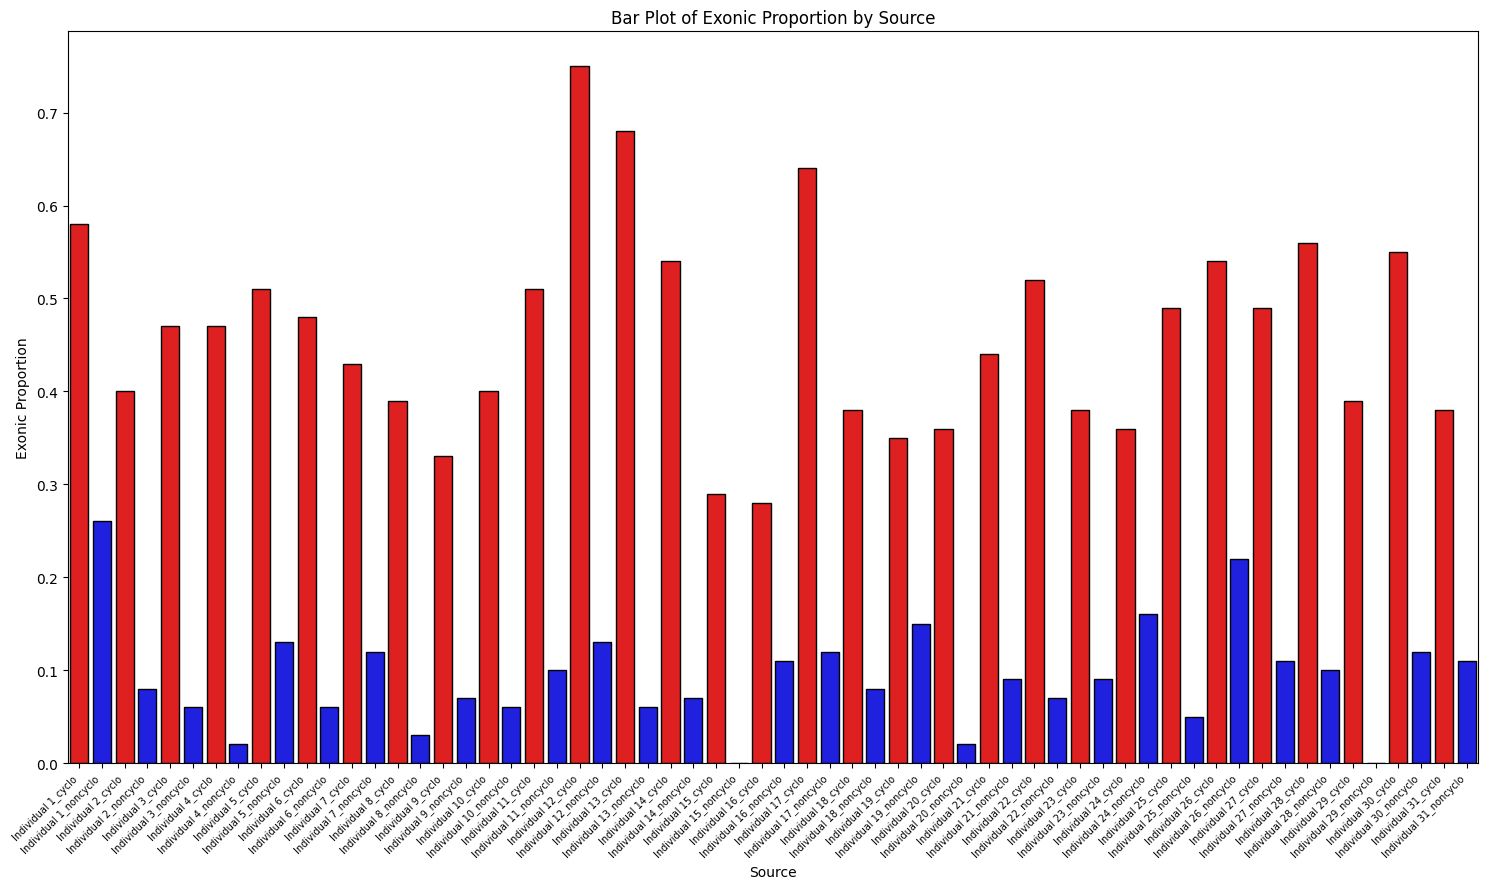

In [3]:
print("Analzying SRSF6 cassette exon inclusion", flush=True)

sample_info = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Add_genetic_and_haplotype/3.28.25/Sample_info.tsv", sep="\t")
reference_fasta_path = "/gscratch/stergachislab/assemblies/simple-names/hg38.fa"

# ---------- rename samples ----------
sample_rename = {
    "UDN687128": "Individual 1",
    "UDN215640": "Individual 2",
    "UDN633333": "Individual 3",
    "UDN318336": "Individual 4",
    "UDN052264": "Individual 5",
    "UDN212054": "Individual 6",
    "UDN355246": "Individual 7",
    "UDN860070": "Individual 8",
    "UDN353099": "Individual 9",
    "UDN305049": "Individual 10",
    "UDN310876": "Individual 11",
    "BCH_1199-01": "Individual 12",
    "BCH_1877-01": "Individual 13",
    "BCH_310-01": "Individual 14",
    "UDN121217": "Individual 15",
    "UDN374570": "Individual 16",
    "UDN827597": "Individual 17",
    "UDN966087": "Individual 18",
    "UDN204349": "Individual 19",
    "UDN359892": "Individual 20",
    "UDN262407": "Individual 21",
    "UDN924176": "Individual 22",
    "UDN666440": "Individual 23",
    "UDN178694": "Individual 24",
    "BCH_1986-01": "Individual 25",
    "BCH_0252-01": "Individual 26",
    "BCH_2275-01": "Individual 27",
    "BCH_2401-01": "Individual 28",
    "BCH_2410-01": "Individual 29",
    "BCH_2443-01": "Individual 30",
    "UDN010451": "Individual 31"
}

def rename_sample_with_suffix(name):
    """Convert e.g. 'UDN687128_cyclo' -> 'Individual 1_cyclo'."""
    for old, new in sample_rename.items():
        if name.startswith(old):
            return name.replace(old, new, 1)
    return name  # unchanged if not in map

sample_info["sample"] = sample_info["sample"].apply(rename_sample_with_suffix)
sample_info["individual"] = sample_info["individual"].apply(rename_sample_with_suffix)


process_pileup(df=sample_info, reference_fasta= reference_fasta_path, chromosome="chr20", position=43459200, output_file="SRSF6.tsv.gz")

# Plotting:

SRSF6_df = pd.read_csv("SRSF6.tsv.gz", compression = "gzip", sep="\t")

# Sort DataFrame by patient number (extracted from "Source")
import re

def extract_patient_number(source):
    match = re.search(r"Individual (\d+)", source)
    return int(match.group(1)) if match else 999  # push unknowns to end

SRSF6_df["Individual_Number"] = SRSF6_df["Source"].apply(extract_patient_number)

# Sort by patient number (and optionally keep cyclo before untreated)
df_sorted = SRSF6_df.sort_values(by=["Individual_Number", "Source"])

# Define colors based on condition
colors = ["red" if "_cyclo" in source else "blue" for source in df_sorted["Source"]]

# Plot bar chart
plt.figure(figsize=(15, 9))
sns.barplot(data=df_sorted, x="Source", y="Exonic_Proportion", edgecolor="black", palette=colors)

# Labeling and formatting
plt.xlabel("Source")
plt.ylabel("Exonic Proportion")
plt.title("Bar Plot of Exonic Proportion by Source")
plt.xticks(rotation=45, fontsize=7, ha="right")  # Adjust alignment to prevent cutoff

plt.tight_layout()

# Save to PDF
plt.savefig("SRSF6_exonic_proportion_individual.pdf", format="pdf")

# QC

In [4]:
import pandas as pd
import pysam
import numpy as np
from pathlib import Path
from collections import defaultdict


def n50(lengths):
    """Return N50 for a list of positive integers."""
    if not lengths:
        return float("nan")
    arr = np.array(lengths, dtype=np.int64)
    arr.sort()
    cum = np.cumsum(arr)
    half = cum[-1] / 2
    idx = np.searchsorted(cum, half)
    return int(arr[idx])
    
################
# Load sample info
################
samples = pd.read_csv(
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Add_genetic_and_haplotype/3.28.25/Sample_info.tsv",
    sep="\t"
)

################
# Accumulators
################
results = []

combined_lengths = []
combined_genes = set()
combined_isoforms = set()
combined_total = 0
combined_novel = 0
combined_phased = 0
combined_novel_isoforms = set()

for _, row in samples.iterrows():
    sample_name = row["sample"]
    bam_path = row["bam_file"]

    read_lengths = []
    genes = set()
    isoforms = set()
    novel_reads = 0
    phased_reads = 0
    total_reads = 0
    novel_isoforms = set()

    # mapping: gene -> set of isoforms in this sample
    gene_to_isoforms = defaultdict(set)

    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            total_reads += 1

            # length
            if read.has_tag("qs") and read.has_tag("qe"):
                try:
                    length = int(read.get_tag("qe")) - int(read.get_tag("qs"))
                except Exception:
                    length = read.query_alignment_length or 0
            else:
                length = read.query_alignment_length or 0
            if length > 0:
                read_lengths.append(length)
                combined_lengths.append(length)

            # tags
            gn = str(read.get_tag("gn")).strip() if read.has_tag("gn") else None
            sc = str(read.get_tag("sc")).strip().lower() if read.has_tag("sc") else ""
            iso = str(read.get_tag("in")).strip() if read.has_tag("in") else None

            if gn:
                genes.add(gn)
                combined_genes.add(gn)
            if iso:
                isoforms.add(iso)
                combined_isoforms.add(iso)
            if gn and iso:
                gene_to_isoforms[gn].add(iso)

            # novel isoforms
            if "novel" in sc:
                novel_reads += 1
                combined_novel += 1
                if iso:
                    novel_isoforms.add(iso)
                    combined_novel_isoforms.add(iso)

            # phased
            if read.has_tag("HP"):
                try:
                    hp = int(read.get_tag("HP"))
                except Exception:
                    try:
                        hp = int(str(read.get_tag("HP")))
                    except Exception:
                        hp = 0
                if hp in (1, 2):
                    phased_reads += 1
                    combined_phased += 1

    combined_total += total_reads

    # compute per-gene isoform counts
    per_gene_isoform_counts = [len(isos) for isos in gene_to_isoforms.values()]
    mean_iso_per_gene = np.mean(per_gene_isoform_counts)
    median_iso_per_gene = np.median(per_gene_isoform_counts)

    # per-sample stats
    mean_len = np.mean(read_lengths)
    n50_len = n50(read_lengths)
    unique_genes = len(genes)
    unique_isoforms = len(isoforms)

    results.append({
        "sample": sample_name,
        "Total": total_reads,
        "Mean transcript length": mean_len,
        "Read length N50": n50_len,
        "Unique genes": unique_genes,
        "Unique isoforms": unique_isoforms,
        "Reads in novel isoforms": novel_reads,
        "Unique novel isoforms": len(novel_isoforms),
        "Phased reads": phased_reads,
        "Avg isoforms per gene": mean_iso_per_gene,      
        "Median isoforms per gene": median_iso_per_gene 
    })

    print(f"{sample_name} is completed")

################
# Combined stats
################
all_mean_len = np.mean(combined_lengths)
all_n50 = n50(combined_lengths)

all_row = {
    "sample": "ALL",
    "Total": combined_total,
    "Mean transcript length": all_mean_len,
    "Read length N50": all_n50,
    "Unique genes": len(combined_genes),
    "Unique isoforms": len(combined_isoforms),
    "Reads in novel isoforms": combined_novel,
    "Unique novel isoforms": len(combined_novel_isoforms),
    "Phased reads": combined_phased,
    "Avg isoforms per gene": float("nan"),     # not meaningful across samples
    "Median isoforms per gene": float("nan")   # so mark as NaN
}
results.append(all_row)

################
# Write output
################
df = pd.DataFrame(results).set_index("sample")
out_path = Path("summary_table.tsv")
df.to_csv(out_path, sep="\t")
print(f"Wrote {out_path.resolve()}")


UDN633333_untreated_non-cyclo_PS00344 is completed
UDN633333_treated_cyclo_PS00345 is completed
UDN212054_untreated_non-cyclo_PS00362 is completed
UDN212054_treated_cyclo_PS00363 is completed
UDN215640_untreated_non-cyclo_PS00364 is completed
UDN215640_treated_cyclo_PS00365 is completed
UDN052264_untreated_non-cyclo_PS00366 is completed
UDN052264_treated_cyclo_PS00367 is completed
BCH_1877-01_treated_cyclo_PS00390 is completed
BCH_1877-01_untreated_non-cyclo_PS00391 is completed
BCH_2410-01_treated_cyclo_PS00393 is completed
BCH_2410-01_untreated_non-cyclo_PS00394 is completed
BCH_2275-01_treated_cyclo_PS00396 is completed
BCH_2275-01_untreated_non-cyclo_PS00397 is completed
BCH_2401-01_treated_cyclo_PS00399 is completed
BCH_2401-01_untreated_non-cyclo_PS00400 is completed
BCH_2443-01_treated_cyclo_PS00402 is completed
BCH_2443-01_untreated_non-cyclo_PS00403 is completed
BCH_0252-01_treated_cyclo_PS00405 is completed
BCH_0252-01_untreated_non-cyclo_PS00406 is completed
BCH_1199-01_trea

In [1]:
import pandas as pd
import pysam
import numpy as np
from pathlib import Path
from collections import defaultdict


def n50(lengths):
    """Return N50 for a list of positive integers."""
    if not lengths:
        return float("nan")
    arr = np.array(lengths, dtype=np.int64)
    arr.sort()
    cum = np.cumsum(arr)
    half = cum[-1] / 2
    idx = np.searchsorted(cum, half)
    return int(arr[idx])


def parse_gtf_protein_coding_genes(gtf_path, gene_field="gene_name"):
    """
    Parse a GTF and return a set of protein-coding genes.

    Parameters
    ----------
    gtf_path : str or Path
        Path to GTF file.
    gene_field : str
        Which field to extract from attributes. Usually "gene_name" or "gene_id".

    Returns
    -------
    set
        Set of protein-coding gene identifiers matching gene_field.
    """
    protein_coding_genes = set()

    with open(gtf_path, "r") as f:
        for line in f:
            if not line or line.startswith("#"):
                continue

            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9:
                continue

            attributes = fields[8]

            # Keep only protein-coding genes
            if (
                'gene_type "protein_coding"' not in attributes
                and 'gene_biotype "protein_coding"' not in attributes
            ):
                continue

            attr_dict = {}
            for item in attributes.strip().split(";"):
                item = item.strip()
                if not item:
                    continue
                parts = item.split(" ", 1)
                if len(parts) != 2:
                    continue
                key = parts[0]
                value = parts[1].strip().strip('"')
                attr_dict[key] = value

            if gene_field in attr_dict:
                protein_coding_genes.add(attr_dict[gene_field])

    return protein_coding_genes


################
# User inputs
################
sample_info_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Add_genetic_and_haplotype/3.28.25/Sample_info.tsv"

# Set this to your annotation GTF
gtf_path = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# Match this to what your BAM gn tag contains:
#   gene_field="gene_name"  -> if gn looks like TP53
#   gene_field="gene_id"    -> if gn looks like ENSG00000...
gene_field = "gene_name"


################
# Load protein-coding genes
################
protein_coding_genes = parse_gtf_protein_coding_genes(gtf_path, gene_field=gene_field)
print(f"Loaded {len(protein_coding_genes)} protein-coding genes from GTF using field: {gene_field}")


################
# Load sample info
################
samples = pd.read_csv(sample_info_path, sep="\t")


################
# Accumulators
################
results = []

combined_lengths = []
combined_genes = set()
combined_isoforms = set()
combined_total = 0
combined_novel = 0
combined_phased = 0
combined_novel_isoforms = set()

combined_gene_read_counts = defaultdict(int)
combined_isoform_read_counts = defaultdict(int)

for _, row in samples.iterrows():
    sample_name = row["sample"]
    bam_path = row["bam_file"]

    read_lengths = []
    genes = set()
    isoforms = set()
    novel_reads = 0
    phased_reads = 0
    total_reads = 0
    novel_isoforms = set()

    # mapping: gene -> set of isoforms in this sample
    gene_to_isoforms = defaultdict(set)

    # read-support counters
    gene_read_counts = defaultdict(int)
    isoform_read_counts = defaultdict(int)

    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            total_reads += 1

            # length
            if read.has_tag("qs") and read.has_tag("qe"):
                try:
                    length = int(read.get_tag("qe")) - int(read.get_tag("qs"))
                except Exception:
                    length = read.query_alignment_length or 0
            else:
                length = read.query_alignment_length or 0

            if length > 0:
                read_lengths.append(length)
                combined_lengths.append(length)

            # tags
            gn = str(read.get_tag("gn")).strip() if read.has_tag("gn") else None
            sc = str(read.get_tag("sc")).strip().lower() if read.has_tag("sc") else ""
            iso = str(read.get_tag("in")).strip() if read.has_tag("in") else None

            if gn:
                genes.add(gn)
                combined_genes.add(gn)
                gene_read_counts[gn] += 1
                combined_gene_read_counts[gn] += 1

            if iso:
                isoforms.add(iso)
                combined_isoforms.add(iso)
                isoform_read_counts[iso] += 1
                combined_isoform_read_counts[iso] += 1

            if gn and iso:
                gene_to_isoforms[gn].add(iso)

            # novel isoforms
            if "novel" in sc:
                novel_reads += 1
                combined_novel += 1
                if iso:
                    novel_isoforms.add(iso)
                    combined_novel_isoforms.add(iso)

            # phased
            if read.has_tag("HP"):
                try:
                    hp = int(read.get_tag("HP"))
                except Exception:
                    try:
                        hp = int(str(read.get_tag("HP")))
                    except Exception:
                        hp = 0

                if hp in (1, 2):
                    phased_reads += 1
                    combined_phased += 1

    combined_total += total_reads

    # compute per-gene isoform counts
    per_gene_isoform_counts = [len(isos) for isos in gene_to_isoforms.values()]
    mean_iso_per_gene = np.mean(per_gene_isoform_counts) if per_gene_isoform_counts else float("nan")
    median_iso_per_gene = np.median(per_gene_isoform_counts) if per_gene_isoform_counts else float("nan")

    # count genes/isoforms with >=10 reads
    genes_ge10 = {g for g, c in gene_read_counts.items() if c >= 10}
    isoforms_ge10 = {i for i, c in isoform_read_counts.items() if c >= 10}
    protein_coding_genes_ge10 = genes_ge10 & protein_coding_genes

    # per-sample stats
    mean_len = np.mean(read_lengths) if read_lengths else float("nan")
    n50_len = n50(read_lengths)
    unique_genes = len(genes)
    unique_isoforms = len(isoforms)

    results.append({
        "sample": sample_name,
        "Total": total_reads,
        "Mean transcript length": mean_len,
        "Read length N50": n50_len,
        "Unique genes": unique_genes,
        "Unique isoforms": unique_isoforms,
        "Genes >=10 reads": len(genes_ge10),
        "Protein-coding genes >=10 reads": len(protein_coding_genes_ge10),
        "Isoforms >=10 reads": len(isoforms_ge10),
        "Reads in novel isoforms": novel_reads,
        "Unique novel isoforms": len(novel_isoforms),
        "Phased reads": phased_reads,
        "Avg isoforms per gene": mean_iso_per_gene,
        "Median isoforms per gene": median_iso_per_gene
    })

    print(f"{sample_name} is completed")


################
# Combined stats
################
all_mean_len = np.mean(combined_lengths) if combined_lengths else float("nan")
all_n50 = n50(combined_lengths)

combined_genes_ge10 = {g for g, c in combined_gene_read_counts.items() if c >= 10}
combined_isoforms_ge10 = {i for i, c in combined_isoform_read_counts.items() if c >= 10}
combined_protein_coding_genes_ge10 = combined_genes_ge10 & protein_coding_genes

all_row = {
    "sample": "ALL",
    "Total": combined_total,
    "Mean transcript length": all_mean_len,
    "Read length N50": all_n50,
    "Unique genes": len(combined_genes),
    "Unique isoforms": len(combined_isoforms),
    "Genes >=10 reads": len(combined_genes_ge10),
    "Protein-coding genes >=10 reads": len(combined_protein_coding_genes_ge10),
    "Isoforms >=10 reads": len(combined_isoforms_ge10),
    "Reads in novel isoforms": combined_novel,
    "Unique novel isoforms": len(combined_novel_isoforms),
    "Phased reads": combined_phased,
    "Avg isoforms per gene": float("nan"),
    "Median isoforms per gene": float("nan")
}
results.append(all_row)


################
# Write output
################
df = pd.DataFrame(results).set_index("sample")
out_path = Path("summary_table.tsv")
df.to_csv(out_path, sep="\t")
print(f"Wrote {out_path.resolve()}")

Loaded 20065 protein-coding genes from GTF using field: gene_name
UDN633333_untreated_non-cyclo_PS00344 is completed
UDN633333_treated_cyclo_PS00345 is completed
UDN212054_untreated_non-cyclo_PS00362 is completed
UDN212054_treated_cyclo_PS00363 is completed
UDN215640_untreated_non-cyclo_PS00364 is completed
UDN215640_treated_cyclo_PS00365 is completed
UDN052264_untreated_non-cyclo_PS00366 is completed
UDN052264_treated_cyclo_PS00367 is completed
BCH_1877-01_treated_cyclo_PS00390 is completed
BCH_1877-01_untreated_non-cyclo_PS00391 is completed
BCH_2410-01_treated_cyclo_PS00393 is completed
BCH_2410-01_untreated_non-cyclo_PS00394 is completed
BCH_2275-01_treated_cyclo_PS00396 is completed
BCH_2275-01_untreated_non-cyclo_PS00397 is completed
BCH_2401-01_treated_cyclo_PS00399 is completed
BCH_2401-01_untreated_non-cyclo_PS00400 is completed
BCH_2443-01_treated_cyclo_PS00402 is completed
BCH_2443-01_untreated_non-cyclo_PS00403 is completed
BCH_0252-01_treated_cyclo_PS00405 is completed
BCH

In [1]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/pigeon/pigeon_classification.txt", sep="\t", compression="infer")

pd.set_option('display.max_columns', None)
df['structural_category'].unique()

df1 = df[df["structural_category"] == "fusion"]

# Of the ____ isoforms with 10 reads or more in any sample, ____ are classified as fusions. 
expression_matrix = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/expression_matrix.tsv.gz", sep="\t", index_col = 0, compression="infer")

# Step 1: Filter expression matrix to include only fusion isoforms
fusion_expr = expression_matrix.loc[expression_matrix.index.isin(df1['isoform'])]

# Step 2: Check for isoforms with at least one sample having 10 or more reads
has_10_or_more = (fusion_expr >= 10).any(axis=1)

# Step 3: Count how many fusion isoforms meet the condition
num_fusion_isoforms_with_10_reads = has_10_or_more.sum()

print(f"Number of fusion isoforms with ≥10 reads in any sample: {num_fusion_isoforms_with_10_reads}")


# Step 2: Check for isoforms with at least one sample having 10 or more reads
has_10_or_more_expression_matrix = (expression_matrix >= 10).any(axis=1)

# Step 3: Count how many isoforms meet the condition
num_isoforms_with_10_reads_expression_matrix = has_10_or_more_expression_matrix.sum()

print(f"Number of total isoforms with ≥10 reads in any sample: {num_isoforms_with_10_reads_expression_matrix}")


Number of fusion isoforms with ≥10 reads in any sample: 4579
Number of total isoforms with ≥10 reads in any sample: 100274


# Most CHX responsive genes

In [6]:
import pandas as pd

df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_test_statistic_gen_full_test_stat_and_z_scored_data.tsv", sep="\t")
#df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_rare_steady_state_transcript_gen_full_test_stat_and_z_scored_data.tsv", sep="\t")

df.head()

# I have a df that has these columns: Sample, associated_gene, z_score_of_test_stat
# Each row is a Sample-gene pair. For each sample (specified in the Sample column), I want to calculate the percentile of the z_score_of_test_stat relative to the other z_score_of_test_stat for the sample. Put this percentile value in a new column# Determining the most CHX responsive genes
import pandas as pd

# -----------------------
# Set these to match df
# -----------------------
SAMPLE_COL = "Sample"
GENE_COL = "associated_gene"
STAT_COL = "test_statistic"

# -----------------------
# sanity checks
# -----------------------
required_cols = {SAMPLE_COL, GENE_COL, STAT_COL}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"df is missing required columns: {sorted(missing)}")

# make sure STAT_COL is numeric
df = df.copy()
df[STAT_COL] = pd.to_numeric(df[STAT_COL], errors="coerce")

# drop rows with missing essentials
df = df.dropna(subset=[SAMPLE_COL, GENE_COL, STAT_COL])

# -----------------------
# 1) TOP N GENES PER SAMPLE (highest test_statistic within each sample)
# -----------------------
TOP_N_PER_SAMPLE = 10

top_genes_per_sample = (
    df.sort_values([SAMPLE_COL, STAT_COL], ascending=[True, False])
      .groupby(SAMPLE_COL, as_index=False)
      .head(TOP_N_PER_SAMPLE)
      .reset_index(drop=True)
)

# Optional: add within-sample rank (1 = highest)
top_genes_per_sample["rank_within_sample"] = (
    top_genes_per_sample.groupby(SAMPLE_COL)[STAT_COL]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# -----------------------
# 2) GENE-LEVEL SUMMARY ACROSS SAMPLES
#    (genes whose samples reach the highest test_statistic values)
# -----------------------
gene_summary = (
    df.groupby(GENE_COL)[STAT_COL]
      .agg(
          max_test="max",
          mean_test="mean",
          median_test="median",
          n_samples="count",
      )
      .sort_values(["max_test", "mean_test"], ascending=[False, False])
      .reset_index()
)

top_genes_by_max = gene_summary.head(50)

# -----------------------
# 3) CONSISTENCY: genes that appear in the TOP K within many samples
# -----------------------
TOP_K_WITHIN_SAMPLE = 50

topK_rows = (
    df.sort_values([SAMPLE_COL, STAT_COL], ascending=[True, False])
      .groupby(SAMPLE_COL, as_index=False)
      .head(TOP_K_WITHIN_SAMPLE)
      .reset_index(drop=True)
)

gene_consistency = (
    topK_rows[GENE_COL]
      .value_counts()
      .rename_axis(GENE_COL)
      .reset_index(name=f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}")
      .sort_values(f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}", ascending=False)
)

# Optional: merge consistency with gene_summary for a single ranked table
gene_ranked = (
    gene_summary.merge(gene_consistency, on=GENE_COL, how="left")
               .fillna({f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}": 0})
               .sort_values(
                   [f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}", "max_test", "mean_test"],
                   ascending=[False, False, False]
               )
               .reset_index(drop=True)
)

# -----------------------
# outputs 
# -----------------------
print("top_genes_per_sample:", top_genes_per_sample.shape)
print("gene_summary:", gene_summary.shape)
print("gene_consistency:", gene_consistency.shape)
print("gene_ranked:", gene_ranked.shape)

# Example: show the heads
display(top_genes_per_sample.head(20))
display(top_genes_by_max.head(20))
display(gene_ranked.head(20))


top_genes_per_sample: (310, 28)
gene_summary: (22181, 5)
gene_consistency: (225, 2)
gene_ranked: (22181, 6)


,associated_gene,Sample,cyclo_count,noncyclo_count,Cyclo_TPM,Noncyclo_TPM,total_cyclo,total_noncyclo,H0_cyclo_count,H1_cyclo_count,...,Cyclo_TPM_Mean,Noncyclo_TPM_Mean,CycloFraction,NoncycloFraction,NormalizedCycloFraction,NormalizedNoncycloFraction,NormalizedFractionDifference,test_statistic,z_score_of_test_stat,rank_within_sample
0,EGR2,BCH_0252-01,16089,29,2417.534995,6.629012,6655126,4374709,16089,0,...,2463.133617,15.007404,0.002418,6.629012e-06,0.997265,0.002735,0.994531,93.390928,0.740363,1
1,FOSB,BCH_0252-01,17980,60,2701.676873,13.715198,6655126,4374709,14,9060,...,1482.053283,21.963986,0.002702,1.371520e-05,0.994949,0.005051,0.989898,85.744014,0.875644,2
2,NR4A1,BCH_0252-01,12884,40,1935.951325,9.143465,6655126,4374709,179,5946,...,1050.197462,13.574727,0.001936,9.143465e-06,0.995299,0.004701,0.990598,82.744258,1.069402,3
3,HES1,BCH_0252-01,18955,82,2848.180485,18.744104,6655126,4374709,18955,0,...,1868.084016,96.421053,0.002848,1.874410e-05,0.993462,0.006538,0.986924,82.323141,1.590379,4
4,FOS,BCH_0252-01,109132,1435,16398.186901,328.021818,6655126,4374709,109132,0,...,10193.808443,706.848880,0.016398,3.280218e-04,0.980389,0.019611,0.960778,78.958195,0.817551,5
5,ARC,BCH_0252-01,4116,6,618.470635,1.371520,6655126,4374709,0,1971,...,140.474172,1.160188,0.000618,1.371520e-06,0.997787,0.002213,0.995575,74.487536,2.304399,6
6,EGR3,BCH_0252-01,3172,4,476.625086,0.914347,6655126,4374709,3168,3,...,331.802877,2.312681,0.000477,9.143465e-07,0.998085,0.001915,0.996171,70.891572,1.652351,7
7,GADD45B,BCH_0252-01,46663,667,7011.587760,152.467284,6655126,4374709,2383,20973,...,6794.894374,292.133770,0.007012,1.524673e-04,0.978718,0.021282,0.957435,70.445799,1.046448,8
8,EGR4,BCH_0252-01,8155,47,1225.371240,10.743572,6655126,4374709,8155,0,...,1839.452456,3.625570,0.001225,1.074357e-05,0.991309,0.008691,0.982617,68.816560,-0.962938,9
9,ATF3,BCH_0252-01,5956,27,894.949247,6.171839,6655126,4374709,5954,2,...,1080.983460,15.165439,0.000895,6.171839e-06,0.993151,0.006849,0.986302,68.318181,0.578790,10


,associated_gene,max_test,mean_test,median_test,n_samples
0,EGR4,131.990379,87.515819,88.772339,31
1,FOS,115.414413,59.720427,58.228860,31
2,CXCL8,114.746382,57.557466,56.994655,31
3,FOSB,113.874696,66.416200,67.601619,31
4,HES1,108.034188,49.977997,50.868890,31
5,TNFAIP3,104.992620,54.980450,53.782998,31
6,EGR2,102.927962,84.218607,85.949441,31
7,PTGS2,101.289353,23.272137,17.510861,31
8,JUN,101.091237,59.190029,61.820363,31
9,KLF10,99.067944,52.190158,52.779639,31


,associated_gene,max_test,mean_test,median_test,n_samples,n_samples_in_top50
0,EGR2,102.927962,84.218607,85.949441,31,31.0
1,EGR4,131.990379,87.515819,88.772339,31,30.0
2,GADD45B,83.329431,58.761766,56.500367,31,30.0
3,FOSB,113.874696,66.416200,67.601619,31,29.0
4,TNFAIP3,104.992620,54.980450,53.782998,31,29.0
5,JUN,101.091237,59.190029,61.820363,31,29.0
6,KLF10,99.067944,52.190158,52.779639,31,29.0
7,ATF3,81.866813,60.422611,61.499671,31,29.0
8,EGR3,74.658797,55.017400,54.688999,31,29.0
9,EGR1,84.365846,52.816142,52.843335,31,27.0


In [7]:
gene_ranked["associated_gene"].head(20)

0                      EGR2
1                      EGR4
2                   GADD45B
3                      FOSB
4                   TNFAIP3
5                       JUN
6                     KLF10
7                      ATF3
8                      EGR3
9                      EGR1
10                   CSRNP1
11                      FOS
12                    NR4A1
13    DUSP2_ENSG00000228873
14                    FOSL1
15                    CXCL8
16                     MCL1
17                     HES1
18         CYP1B1_RMDN2-AS1
19    ENSG00000280143_TAGLN
Name: associated_gene, dtype: object

# Most CHX responsive isoform

In [5]:
import pandas as pd

# -----------------------
# load
# -----------------------
df = pd.read_csv(
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_test_statistic_iso_full_test_stat_and_z_scored_data.tsv",
    sep="\t"
)

# -----------------------
# column settings
# -----------------------
SAMPLE_COL = "Sample"
FEATURE_COL = "Isoform"         
ASSOC_GENE_COL = "associated_gene"
STAT_COL = "test_statistic"

# -----------------------
# sanity checks
# -----------------------
required_cols = {SAMPLE_COL, FEATURE_COL, ASSOC_GENE_COL, STAT_COL}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"df is missing required columns: {sorted(missing)}")

df = df.copy()
df[STAT_COL] = pd.to_numeric(df[STAT_COL], errors="coerce")
df = df.dropna(subset=[SAMPLE_COL, FEATURE_COL, ASSOC_GENE_COL, STAT_COL])

# -----------------------
# 1) TOP N FEATURES PER SAMPLE (keeps feature + associated_gene)
# -----------------------
TOP_N_PER_SAMPLE = 10

top_features_per_sample = (
    df.sort_values([SAMPLE_COL, STAT_COL], ascending=[True, False])
      .groupby(SAMPLE_COL, as_index=False)
      .head(TOP_N_PER_SAMPLE)
      .reset_index(drop=True)
)

top_features_per_sample["rank_within_sample"] = (
    top_features_per_sample.groupby(SAMPLE_COL)[STAT_COL]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# nice column order
base_cols = [SAMPLE_COL, FEATURE_COL, ASSOC_GENE_COL, STAT_COL, "rank_within_sample"]
top_features_per_sample = top_features_per_sample[
    base_cols + [c for c in top_features_per_sample.columns if c not in base_cols]
]

# -----------------------
# 2) FEATURE SUMMARY ACROSS SAMPLES (keeps feature + associated_gene)
# -----------------------
feature_summary = (
    df.groupby([FEATURE_COL, ASSOC_GENE_COL])
      .agg(
          max_test=(STAT_COL, "max"),
          mean_test=(STAT_COL, "mean"),
          median_test=(STAT_COL, "median"),
          n_rows=(STAT_COL, "count"),
          n_samples=(SAMPLE_COL, "nunique"),
      )
      .sort_values(["max_test", "mean_test"], ascending=[False, False])
      .reset_index()
)

top_features_by_max = feature_summary.head(50)

# -----------------------
# 3) CONSISTENCY: features that appear in TOP K within many samples
#    (counts unique samples where that feature is in the per-sample topK)
# -----------------------
TOP_K_WITHIN_SAMPLE = 50

topK_rows = (
    df.sort_values([SAMPLE_COL, STAT_COL], ascending=[True, False])
      .groupby(SAMPLE_COL, as_index=False)
      .head(TOP_K_WITHIN_SAMPLE)
      .reset_index(drop=True)
)

feature_consistency = (
    topK_rows.groupby([FEATURE_COL, ASSOC_GENE_COL])[SAMPLE_COL]
            .nunique()
            .rename(f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}")
            .reset_index()
            .sort_values(f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}", ascending=False)
)

# merge into one ranked table (feature-level)
feature_ranked = (
    feature_summary.merge(feature_consistency, on=[FEATURE_COL, ASSOC_GENE_COL], how="left")
                  .fillna({f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}": 0})
                  .sort_values(
                      [f"n_samples_in_top{TOP_K_WITHIN_SAMPLE}", "max_test", "mean_test"],
                      ascending=[False, False, False]
                  )
                  .reset_index(drop=True)
)

# -----------------------
# outputs
# -----------------------
print("top_features_per_sample:", top_features_per_sample.shape)
print("feature_summary:", feature_summary.shape)
print("feature_consistency:", feature_consistency.shape)
print("feature_ranked:", feature_ranked.shape)

display(top_features_per_sample.head(20))
display(top_features_by_max.head(20))
display(feature_ranked.head(20))

top_features_per_sample: (310, 33)
feature_summary: (106469, 7)
feature_consistency: (264, 3)
feature_ranked: (106469, 8)


,Sample,Isoform,associated_gene,test_statistic,rank_within_sample,H0_cyclo_count,H1_cyclo_count,H2_cyclo_count,H0_noncyclo_count,H1_noncyclo_count,...,gene_cyclo_count,gene_noncyclo_count,isoform_cyclo_proportion,isoform_noncyclo_proportion,CycloFraction,NoncycloFraction,NormalizedCycloFraction,NormalizedNoncycloFraction,NormalizedFractionDifference,z_score_of_test_stat
0,BCH_0252-01,PB.157299.248,FOSB,98.990664,1,3,5196,5062,0,3,...,17980.0,60.0,0.570690,0.100000,0.001542,1.371520e-06,0.999111,0.000889,0.998222,1.329702
1,BCH_0252-01,PB.101914.20,EGR2,91.840119,2,13019,0,0,21,0,...,16089.0,29.0,0.809186,0.724138,0.001956,4.800319e-06,0.997552,0.002448,0.995104,0.821840
2,BCH_0252-01,PB.39952.7,HES1,84.027056,3,18423,0,0,70,0,...,18955.0,82.0,0.971934,0.853659,0.002768,1.600106e-05,0.994253,0.005747,0.988506,1.528618
3,BCH_0252-01,PB.157299.247,FOSB,83.647771,4,1,2658,2591,1,1,...,17980.0,60.0,0.291991,0.066667,0.000789,9.143465e-07,0.998842,0.001158,0.997685,1.293143
4,BCH_0252-01,PB.131566.2,FOS,82.089243,5,106668,0,0,1189,0,...,109132.0,1435.0,0.977422,0.828571,0.016028,2.717895e-04,0.983326,0.016674,0.966651,0.762410
5,BCH_0252-01,PB.117084.1382,NR4A1,74.161674,6,83,2902,3386,0,11,...,12884.0,40.0,0.494489,0.475000,0.000957,4.343146e-06,0.995484,0.004516,0.990967,1.008715
6,BCH_0252-01,PB.90116.4,ARC,73.876165,7,0,1934,2082,0,3,...,4116.0,6.0,0.975705,1.000000,0.000603,1.371520e-06,0.997732,0.002268,0.995465,2.287986
7,BCH_0252-01,PB.154718.1,GADD45B,72.476254,8,210,20612,22850,8,249,...,46663.0,667.0,0.935902,0.812594,0.006562,1.238940e-04,0.981470,0.018530,0.962940,0.870220
8,BCH_0252-01,PB.110021.3978,FOSL1,69.121015,9,633,4853,4785,4,27,...,13700.0,316.0,0.749708,0.218354,0.001543,1.577248e-05,0.989884,0.010116,0.979767,1.104407
9,BCH_0252-01,PB.18768.117,EGR4,68.235842,10,7869,0,0,46,0,...,8155.0,47.0,0.964929,0.978723,0.001182,1.051499e-05,0.991185,0.008815,0.982371,-0.925698


,Isoform,associated_gene,max_test,mean_test,median_test,n_rows,n_samples
0,PB.18768.117,EGR4,131.123710,86.329602,87.518871,31,31
1,PB.131566.2,FOS,119.178168,62.193522,60.986307,31,31
2,PB.44544.19,CXCL8,114.691109,57.942899,57.164696,31,31
3,PB.39952.7,HES1,110.687255,51.447512,53.134153,31,31
4,PB.157299.248,FOSB,110.475807,70.513878,69.898486,31,31
5,PB.10085.16,PTGS2,106.387569,23.270133,19.161503,31,31
6,PB.4033.102,JUN,104.759151,46.550314,47.381386,31,31
7,PB.44571.22,CXCL3,103.485454,38.394875,36.719237,31,31
8,PB.101914.20,EGR2,101.446424,81.646253,83.975670,31,31
9,PB.87891.74,KLF10,99.962075,42.535006,43.879945,31,31


,Isoform,associated_gene,max_test,mean_test,median_test,n_rows,n_samples,n_samples_in_top50
0,PB.101914.20,EGR2,101.446424,81.646253,83.975670,31,31,31.0
1,PB.18768.117,EGR4,131.123710,86.329602,87.518871,31,31,30.0
2,PB.157299.248,FOSB,110.475807,70.513878,69.898486,31,31,30.0
3,PB.154718.1,GADD45B,87.424939,61.439580,64.096667,31,31,29.0
4,PB.4033.3126,JUN,95.604644,56.200360,57.901402,31,31,28.0
5,PB.11811.33,ATF3,79.899066,60.108462,61.212457,31,31,28.0
6,PB.157299.247,FOSB,88.734470,59.540938,61.405357,31,31,27.0
7,PB.110021.3978,FOSL1,82.880262,56.185584,55.143826,31,31,27.0
8,PB.136471.11,TPM1,70.337562,48.932650,49.247364,31,31,27.0
9,PB.83127.820,EGR3,65.797919,48.085241,49.403764,31,31,27.0


In [8]:
feature_ranked["associated_gene"].head(20)

0                      EGR2
1                      EGR4
2                      FOSB
3                   GADD45B
4                       JUN
5                      ATF3
6                      FOSB
7                     FOSL1
8                      TPM1
9                      EGR3
10                      FOS
11    DUSP2_ENSG00000228873
12                     EGR1
13                   CSRNP1
14                    NR4A1
15                     EGR2
16                     MCL1
17                 SLC25A25
18                    CXCL8
19                      JUN
Name: associated_gene, dtype: object

# CHX global effects vs NMD isoform effects

In [12]:
import matplotlib.pyplot as plt

genes = ["FOS","JUN", "FOSB", "JUNB", "EGR1","EGR2", "GAPDH"]

#FOS - https://pubmed.ncbi.nlm.nih.gov/1628615/
#JUN - https://pubmed.ncbi.nlm.nih.gov/1628615/
#FOSB - https://www.pnas.org/doi/pdf/10.1073/pnas.88.12.5077
#GADD45B - https://www.sciencedirect.com/science/article/pii/S0021925820825733
#EGR1 - https://www.sciencedirect.com/science/article/pii/S0021925819548529
#EGR2 - https://pubmed.ncbi.nlm.nih.gov/3133658/

# GAPDH no effect: https://www.sciencedirect.com/science/article/pii/S0021925817455517


/tmp/ipykernel_22941/2831715894.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.86, 1])


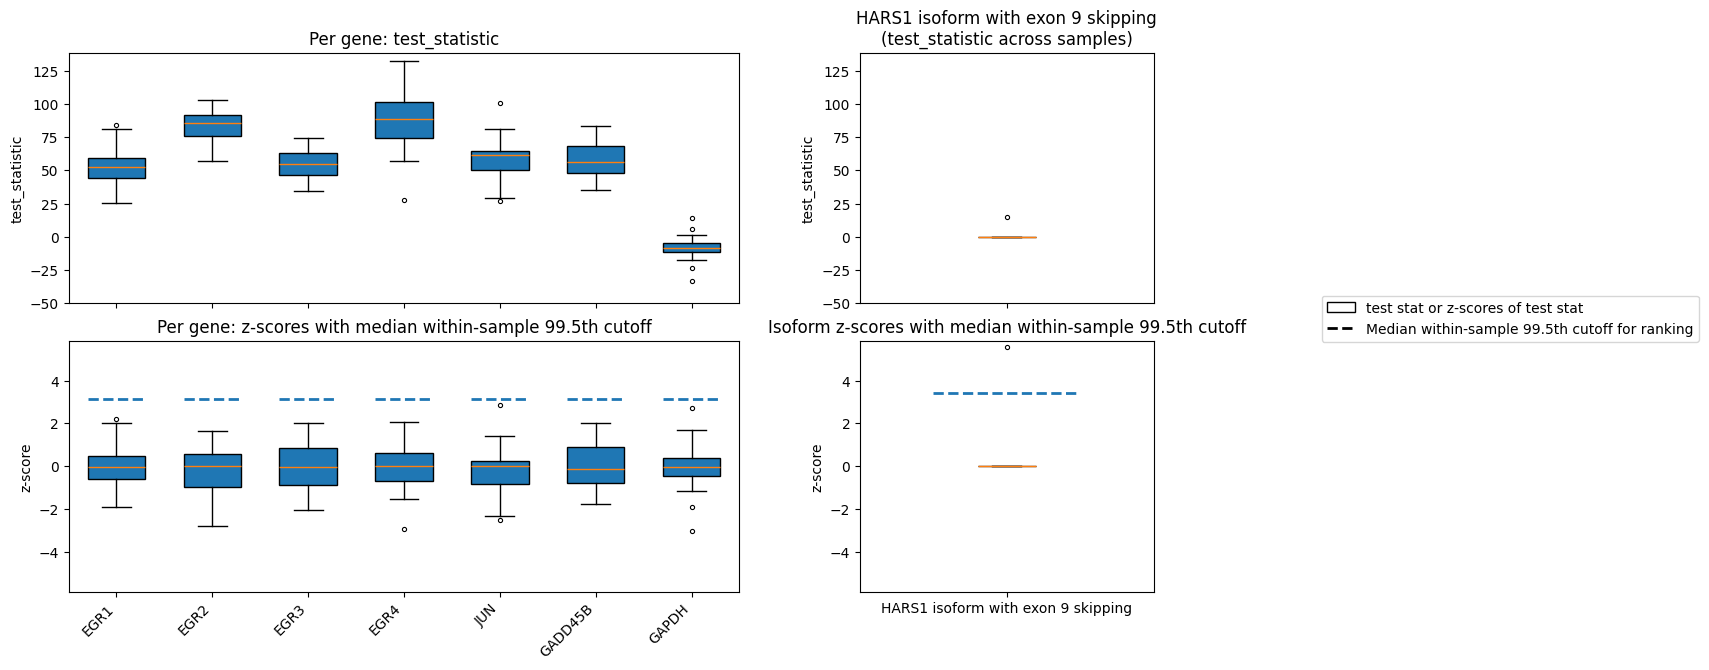

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ==========================
# INPUTS
# ==========================
gene_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_test_statistic_gen_full_test_stat_and_z_scored_data.tsv"

iso_path  = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_test_statistic_iso_full_test_stat_and_z_scored_data.tsv"

genes = ["EGR1","EGR2", "EGR3","EGR4", "JUN", "GADD45B", "GAPDH"]
isoform_id = "PB.58999.277"

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv(gene_path, sep="\t")
iso_df = pd.read_csv(iso_path, sep="\t")

# ==========================
# FILTER GENE DATA
# ==========================
d = df[df["associated_gene"].isin(genes)].copy()

# keep consistent gene order
d["associated_gene"] = d["associated_gene"].astype("category")
d["associated_gene"] = d["associated_gene"].cat.set_categories(genes, ordered=True)
d = d.sort_values(["associated_gene", "Sample"])

# ==========================
# GENE: per-sample 99.5th cutoff + arrays
# ==========================
gene_z99 = (
    df.groupby("Sample")["z_score_of_test_stat"]
      .quantile(0.995)
      .rename("z_score_at_99_5th")
      .reset_index()
)

dd = d.merge(gene_z99, on="Sample", how="left")

z_by_gene = []
cutoff_by_gene = []
teststat_by_gene = []

for g in genes:
    sub = dd.loc[dd["associated_gene"] == g, ["z_score_of_test_stat", "z_score_at_99_5th"]].dropna()
    z_by_gene.append(sub["z_score_of_test_stat"].values)
    cutoff_by_gene.append(sub["z_score_at_99_5th"].values)

    vals = d.loc[d["associated_gene"] == g, "test_statistic"].dropna().values
    teststat_by_gene.append(vals)

# ==========================
# ISOFORM: per-sample 99.5th cutoff + arrays
# ==========================
iso_z99 = (
    iso_df.groupby("Sample")["z_score_of_test_stat"]
          .quantile(0.995)
          .rename("z_score_at_99_5th")
          .reset_index()
)

iso_d = iso_df.loc[iso_df["Isoform"] == isoform_id].copy()
iso_d = iso_d.merge(iso_z99, on="Sample", how="left")

# collapse to one row per sample (in case of duplicates)
iso_d = (iso_d.groupby(["Sample", "Isoform"], as_index=False)
               .agg({
                   "test_statistic": "mean",
                   "z_score_of_test_stat": "mean",
                   "z_score_at_99_5th": "mean",
               }))

iso_teststat_vals = iso_d["test_statistic"].dropna().values
iso_z_vals        = iso_d["z_score_of_test_stat"].dropna().values
iso_cutoff_vals   = iso_d["z_score_at_99_5th"].dropna().values

# ==========================
# MATCH SCALES (shared y-limits per row)
# ==========================
def symmetric_ylim(values, pad_frac=0.05):
    """Make symmetric y-limits around 0 using all provided values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (-1, 1)
    m = np.max(np.abs(values))
    m = m * (1 + pad_frac) if m > 0 else 1.0
    return (-m, m)

# Row 1 (test_statistic): genes + isoform on same y-scale
all_teststat = np.concatenate(
    [np.concatenate([v for v in teststat_by_gene if len(v) > 0], axis=0) if any(len(v) > 0 for v in teststat_by_gene) else np.array([]),
     iso_teststat_vals]
)
ylim_teststat = symmetric_ylim(all_teststat, pad_frac=0.05)

# Row 2 (z-scores): gene z + gene cutoff + iso z + iso cutoff on same y-scale
all_z = np.concatenate(
    [np.concatenate([v for v in z_by_gene if len(v) > 0], axis=0) if any(len(v) > 0 for v in z_by_gene) else np.array([]),
     np.concatenate([v for v in cutoff_by_gene if len(v) > 0], axis=0) if any(len(v) > 0 for v in cutoff_by_gene) else np.array([]),
     iso_z_vals,
     iso_cutoff_vals]
)
ylim_z = symmetric_ylim(all_z, pad_frac=0.05)

# ==========================
# FORCE TOP ROW TO START AT -50 (both upper-left and upper-right)
# ==========================
TOPROW_YMIN = -50
toprow_ymax = max(ylim_teststat[1], 0)
ylim_teststat_toprow = (TOPROW_YMIN, toprow_ymax)

# ==========================
# PLOT: 2 rows x 2 columns (Left = genes, Right = isoform)
# ==========================
x_genes = np.arange(1, len(genes) + 1)

# --- keep these as variables so we can compute matching iso box width ---
left_col_ratio  = 3.2
right_col_ratio = 1.4
iso_xlim = (0.4, 1.6)  # <- you use this for ax_iso_top; we'll use it for both

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 7),
    sharex="col",
    gridspec_kw={
        "height_ratios": [1, 1],
        "width_ratios": [left_col_ratio, right_col_ratio],
        "hspace": 0.15,
        "wspace": 0.25
    },
)

ax_gene_top, ax_iso_top = axes[0, 0], axes[0, 1]
ax_gene_bot, ax_iso_bot = axes[1, 0], axes[1, 1]

# --- show ALL outliers (fliers) settings ---
flierprops = dict(marker="o", markersize=3, markerfacecolor="none", markeredgewidth=0.8)

# ==========================
# Make the isoform box the same *physical* width as one gene box
# ==========================
gene_box_width = 0.6
gene_xrange = len(genes)  # since xlim is (0.5, n+0.5), range = n
iso_xrange = iso_xlim[1] - iso_xlim[0]

# Compensate for (1) different axes widths (via width_ratios) and (2) different x-ranges
iso_box_width = gene_box_width * (left_col_ratio / right_col_ratio) * (iso_xrange / gene_xrange)

# ----- LEFT COL: genes -----
ax_gene_top.boxplot(
    teststat_by_gene,
    positions=x_genes,
    widths=gene_box_width,
    showfliers=True,
    patch_artist=True,
    flierprops=flierprops,
)
ax_gene_top.set_ylabel("test_statistic")
ax_gene_top.set_title("Per gene: test_statistic")
ax_gene_top.set_xlim(0.5, len(genes) + 0.5)
ax_gene_top.set_ylim(*ylim_teststat_toprow)

ax_gene_bot.boxplot(
    z_by_gene,
    positions=x_genes,
    widths=gene_box_width,
    showfliers=True,
    patch_artist=True,
    flierprops=flierprops,
)

median_cutoff_gene = [
    np.nanmedian(v) if (v is not None and len(v) > 0) else np.nan
    for v in cutoff_by_gene
]
half_span = 0.30
for x, med in zip(x_genes, median_cutoff_gene):
    if np.isfinite(med):
        ax_gene_bot.hlines(
            y=med,
            xmin=x - half_span,
            xmax=x + half_span,
            linestyles="--",
            linewidth=2,
        )

ax_gene_bot.set_ylabel("z-score")
ax_gene_bot.set_title("Per gene: z-scores with median within-sample 99.5th cutoff")
ax_gene_bot.set_xticks(x_genes)
ax_gene_bot.set_xticklabels(genes, rotation=45, ha="right")
ax_gene_bot.set_ylim(*ylim_z)

# ----- RIGHT COL: isoform -----
ax_iso_top.boxplot(
    [iso_teststat_vals],
    positions=[1],
    widths=iso_box_width, 
    showfliers=True,
    patch_artist=True,
    flierprops=flierprops,
)
ax_iso_top.set_ylabel("test_statistic")
ax_iso_top.set_title("HARS1 isoform with exon 9 skipping\n(test_statistic across samples)")
ax_iso_top.set_xlim(*iso_xlim)          # keep consistent
ax_iso_top.set_ylim(*ylim_teststat_toprow)

ax_iso_bot.boxplot(
    [iso_z_vals],
    positions=[1],
    widths=iso_box_width, 
    showfliers=True,
    patch_artist=True,
    flierprops=flierprops,
)
ax_iso_bot.set_xlim(*iso_xlim)          

iso_med_cutoff = np.nanmedian(iso_cutoff_vals) if len(iso_cutoff_vals) else np.nan
if np.isfinite(iso_med_cutoff):
    ax_iso_bot.hlines(
        y=iso_med_cutoff,
        xmin=1 - half_span,
        xmax=1 + half_span,
        linestyles="--",
        linewidth=2,
    )

ax_iso_bot.set_ylabel("z-score")
ax_iso_bot.set_title("Isoform z-scores with median within-sample 99.5th cutoff")
ax_iso_bot.set_xticks([1])
ax_iso_bot.set_xticklabels(["HARS1 isoform with exon 9 skipping"], rotation=0)
ax_iso_bot.set_ylim(*ylim_z)

# ==========================
# ONE FIGURE-LEVEL LEGEND 
# ==========================
legend_z = mpatches.Patch(facecolor="white", edgecolor="black",
                          label="test stat or z-scores of test stat")
legend_cut = Line2D([0], [0], linestyle="--", linewidth=2, color="black",
                    label="Median within-sample 99.5th cutoff for ranking")

fig.legend(
    handles=[legend_z, legend_cut],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)

fig.tight_layout(rect=[0, 0, 0.86, 1])

# ==========================
# SAVE AS PDF
# ==========================
out_pdf = "gene_isoform_boxplots.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")

plt.show()


# Ranking with just OMIM genes

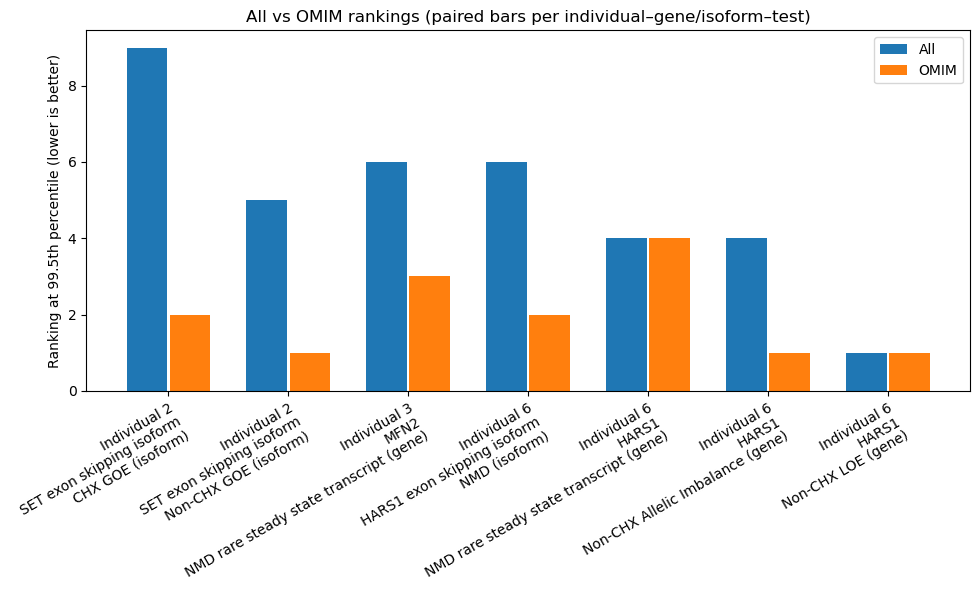

In [11]:
# Paired "histogram-like" plot: for each (Sample, associated_gene, Test),
# show two slightly-separated bars on the x-axis: All vs OMIM.
#
# Required columns:
#   Sample
#   Ranking at 99.5th percentile
#   associated_gene
#   Test
#   Source   (values should include "All" and "OMIM")

# VTA1 and HARS1_DND1 are not included in this analysis because VTA1 and HARS1_DND1 are not omim genes. 

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 1) INPUT
# -----------------------
INPUT_PATH = Path("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/All_vs_omim.tsv")   # <-- change to your input file
SHEET_NAME = "none"                   

# -----------------------
# 2) READ
# -----------------------
REQUIRED_COLS = {
    "Sample",
    "Ranking at 99.5th percentile",
    "associated_gene",
    "Test",
    "Source",
}

suffix = INPUT_PATH.suffix.lower()
if suffix in {".xlsx", ".xls"}:
    df = pd.read_excel(INPUT_PATH, sheet_name=SHEET_NAME)
elif suffix == ".csv":
    df = pd.read_csv(INPUT_PATH)
elif suffix in {".tsv", ".txt"}:
    df = pd.read_csv(INPUT_PATH, sep="\t")
else:
    raise ValueError(f"Unsupported file type: {suffix}. Use .csv, .tsv, or .xlsx")

df.columns = [c.strip() for c in df.columns]
missing = REQUIRED_COLS - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

# Basic cleanup
df["Source"] = df["Source"].astype(str).str.strip()
df["Sample"] = df["Sample"].astype(str).str.strip()
df["associated_gene"] = df["associated_gene"].astype(str).str.strip()
df["Test"] = df["Test"].astype(str).str.strip()

df["Ranking at 99.5th percentile"] = pd.to_numeric(
    df["Ranking at 99.5th percentile"], errors="coerce"
)
df = df.dropna(subset=["Ranking at 99.5th percentile"])

# Keep only All and OMIM
df = df[df["Source"].isin(["All", "OMIM"])].copy()

# -----------------------
# 3) BUILD PAIRED TABLE
# -----------------------
idx = ["Sample", "associated_gene", "Test"]

wide = (
    df.pivot_table(
        index=idx,
        columns="Source",
        values="Ranking at 99.5th percentile",
        aggfunc="min",  # if duplicates exist, keep best (smallest rank)
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# Keep only complete pairs
if "All" not in wide.columns or "OMIM" not in wide.columns:
    raise ValueError("Input must contain both 'All' and 'OMIM' in the Source column.")
wide = wide.dropna(subset=["All", "OMIM"]).copy()

# add deltas
wide["delta_all_minus_omim"] = wide["All"] - wide["OMIM"]  # + => OMIM ranks better (smaller rank)

# sort for nicer grouping
wide = wide.sort_values(["Sample", "Test", "associated_gene"], kind="stable").reset_index(drop=True)

# -----------------------
# 4) PLOT: "histogram-like" paired bars
# -----------------------
wide["pair_label"] = (
    wide["Sample"].astype(str)
    + "\n"
    + wide["associated_gene"].astype(str)
    + "\n"
    + wide["Test"].astype(str)
)

x = np.arange(len(wide))
offset = 0.18     # separation between All and OMIM within each pair
bar_width = 0.34  # bar thickness (keep < 2*offset + bar_width <= 1 for good spacing)

plt.figure(figsize=(max(10, 0.6 * len(wide)), 6))

plt.bar(x - offset, wide["All"].to_numpy(), width=bar_width, label="All")
plt.bar(x + offset, wide["OMIM"].to_numpy(), width=bar_width, label="OMIM")

plt.ylabel("Ranking at 99.5th percentile (lower is better)")
plt.title("All vs OMIM rankings (paired bars per individual–gene/isoform–test)")
#plt.xticks(x, wide["pair_label"], rotation=90)
plt.xticks(x, wide["pair_label"], rotation=30, ha="right", rotation_mode="anchor")
plt.legend()
plt.tight_layout()


# ==========================
# SAVE AS PDF
# ==========================
out_pdf = "All_vs_omim_rankings.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

plt.show()

# Analyzing genetic variants. Only use MANE select transcripts

In [ ]:
# Including 99

import os
import gzip
import urllib.request
import pandas as pd

# -------------------------
# CONFIG
# -------------------------

sample_info_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/1.25.26_changed_MAX_AF/Sample_info.tsv"
output_base_dir = "variant_annotations_tables"  # where {individual}_vcf_vep_filtered.tsv live

# MANE summary (GRCh38 v1.5, current)
MANE_SUMMARY_URL = "https://ftp.funet.fi/pub/mirrors/ftp.ncbi.nlm.nih.gov/refseq/MANE/MANE_human/current/MANE.GRCh38.v1.5.summary.txt.gz"
MANE_LOCAL_GZ = "MANE.GRCh38.v1.5.summary.txt.gz"

# Choose which MANE transcripts to keep:
# - "all": keep both "MANE Select" and "MANE Plus Clinical"
# - "select": keep only "MANE Select"
MANE_MODE = "all"

# 3 NMD metric files
f1 = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_rare_steady_state_transcript_gene_full_ranked_data.tsv"
f2 = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_gene_full_ranked_data.tsv"
f3 = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_isoform_full_ranked_data.tsv"

# Additional metric files
# Gene-level
g_noncyclo_loe = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_LOE_gene_full_ranked_data.tsv"
g_noncyclo_goe = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_GOE_gene_full_ranked_data.tsv"
g_cyclo_goe    = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Cyclo_GOE_gene_full_ranked_data.tsv"
g_noncyclo_ai  = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_Allelic_Imbalance_gene_full_ranked_data.tsv"

# Isoform-level (collapsed to 1 row per gene unless you change the join key)
i_noncyclo_loe = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_LOE_isoform_full_ranked_data.tsv"
i_noncyclo_goe = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_GOE_isoform_full_ranked_data.tsv"
i_cyclo_goe    = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Cyclo_GOE_isoform_full_ranked_data.tsv"
i_noncyclo_ai  = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_Allelic_Imbalance_isoform_full_ranked_data.tsv"

# TPM lookup (per sample + gene)
tpm_lookup_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/browser/lookup_tables/sample_gene_rankings_lookup_table.tsv"

# Coverage medians lookup (per gene)
coverage_lookup_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/browser/lookup_tables/gene_coverage_lookup_table.tsv"

out_tsv = "all_samples_stop_gained_frameshift_with_all_metrics_and_ranks_MANE_include99.tsv"

# Column names in per-sample VEP tables
VARIANT_ID_COL = "#CHROM_POS_REF/ALT"
SYMBOL_COL = "SYMBOL"
CONSEQ_COL = "Consequence"
FEATURE_COL = "Feature"  # ENST in your VEP tables (no version)

# Column names in metric files
SAMPLE_COL = "Sample"
GENE_COL = "associated_gene"
Z_COL = "z_score_of_test_stat"
R995_COL = "rank_top_99_5_percentile"
R99_COL  = "rank_top_99_percentile"
R95_COL  = "rank_top_95_percentile"

# TPM lookup columns
TPM_CYCLO_COL = "Cyclo_TPM"
TPM_NONCYCLO_COL = "Noncyclo_TPM"

# Coverage medians lookup columns
CYCLO_MED_COL = "Cyclo_TPM_median"
NONCYCLO_MED_COL = "Noncyclo_TPM_median"

# Filter condition
CONSEQ_REGEX = "stop_gained|frameshift|splice_donor|splice_acceptor"

# Thresholds
TPM_THRESHOLD = 10
RANK_LT = 100  # ONLY count "ranked" if rank < 100


# -------------------------
# HELPERS
# -------------------------

def _require_cols(df: pd.DataFrame, cols, label: str):
    missing = set(cols) - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns in {label}: {sorted(missing)}. Found: {list(df.columns)[:40]} ...")

def _download(url: str, out_path: str):
    print(f"Downloading MANE summary:\n  {url}\n-> {out_path}")
    urllib.request.urlretrieve(url, out_path)

def _strip_enst_version(enst: str) -> str:
    if pd.isna(enst):
        return ""
    s = str(enst).strip()
    if not s:
        return ""
    return s.split(".", 1)[0]

def load_mane_enst_set(mane_gz_path: str, mode: str = "all") -> set:
    """
    Returns a set of ENST base IDs (no version) that are in MANE.

    mode:
      - "all": includes MANE Select + MANE Plus Clinical
      - "select": includes only MANE Select
    """
    with gzip.open(mane_gz_path, "rt") as fh:
        mane = pd.read_csv(fh, sep="\t", dtype=str)

    _require_cols(mane, ["Ensembl_nuc", "MANE_status"], mane_gz_path)

    mane = mane.copy()
    mane["ENST"] = mane["Ensembl_nuc"].map(_strip_enst_version)
    mane["MANE_status"] = mane["MANE_status"].astype(str).str.strip()

    if mode == "select":
        mane = mane[mane["MANE_status"].eq("MANE Select")]
    else:
        mane = mane[mane["MANE_status"].isin(["MANE Select", "MANE Plus Clinical"])]

    ensts = set(mane["ENST"].dropna().astype(str).str.strip())
    ensts.discard("")
    return ensts

def prep_metric_table(tsv_path: str) -> pd.DataFrame:
    """Load + normalize metric table (keep all rows; per-sample selection happens later)."""
    d = pd.read_csv(tsv_path, sep="\t", dtype=str)
    required = [SAMPLE_COL, GENE_COL, Z_COL, R995_COL, R99_COL, R95_COL]
    _require_cols(d, required, tsv_path)

    d = d.copy()
    d[SAMPLE_COL] = d[SAMPLE_COL].astype(str).str.strip()
    d["SYMBOL"] = d[GENE_COL].astype(str).str.strip()
    d[Z_COL] = pd.to_numeric(d[Z_COL], errors="coerce")
    return d

def metrics_for_sample(metric_df: pd.DataFrame, sample: str, prefix: str, choose: str = "first") -> pd.DataFrame:
    """One row per gene for this sample; rename z/ranks with prefix."""
    d = metric_df[metric_df[SAMPLE_COL] == sample].copy()
    d["SYMBOL"] = d["SYMBOL"].astype(str).str.strip()
    d = d[(d["SYMBOL"].notna()) & (d["SYMBOL"] != "") & (d["SYMBOL"].str.lower() != "nan")]

    if choose == "max_z":
        d = d.sort_values(["SYMBOL", Z_COL], ascending=[True, False], na_position="last")
        d = d.drop_duplicates(subset=["SYMBOL"], keep="first")
    else:
        d = d.drop_duplicates(subset=["SYMBOL"], keep="first")

    return d[["SYMBOL", Z_COL, R995_COL, R99_COL, R95_COL]].rename(columns={
        Z_COL:    f"{prefix}_{Z_COL}",
        R995_COL: f"{prefix}_{R995_COL}",
        R99_COL:  f"{prefix}_{R99_COL}",
        R95_COL:  f"{prefix}_{R95_COL}",
    })

def load_and_filter_sample_variants(vep_tsv_path: str, sample_name: str, mane_enst_set: set) -> pd.DataFrame:
    """
    Load per-sample VEP TSV, filter by consequence regex AND keep ONLY MANE transcripts
    (based on Feature ENST). Then keep one row per variant.
    """
    df = pd.read_csv(vep_tsv_path, sep="\t", dtype=str)
    _require_cols(df, [VARIANT_ID_COL, SYMBOL_COL, CONSEQ_COL, FEATURE_COL], vep_tsv_path)

    df[SYMBOL_COL] = df[SYMBOL_COL].astype(str).str.strip()
    df[FEATURE_COL] = df[FEATURE_COL].astype(str).str.strip()

    # consequence filter
    mask_cons = df[CONSEQ_COL].fillna("").astype(str).str.contains(CONSEQ_REGEX, case=False, regex=True)
    d = df.loc[mask_cons].copy()

    # MANE-only transcript filter
    d = d[d[FEATURE_COL].isin(mane_enst_set)].copy()

    # One row per variant (if multiple MANE transcripts somehow remain, keep first)
    out = d.drop_duplicates(subset=[VARIANT_ID_COL]).copy()
    out["Sample"] = sample_name
    return out

def _rank_lt_100(x) -> bool:
    """True if x is numeric and < RANK_LT."""
    if pd.isna(x):
        return False
    v = pd.to_numeric(x, errors="coerce")
    return pd.notna(v) and (v < RANK_LT)

def compute_coverage_and_rank_flags(final_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
      - Adequate_coverage_for_LOE: Noncyclo_TPM_median > 10
      - Adequate_coverage_for_Cyclo_or_NMD: Cyclo_TPM > 10
      - Adequate_coverage_for_Noncyclo_only: Noncyclo_TPM > 10

      - Ranked_any_test_99_5: any *_rank_top_99_5_percentile column has numeric rank < 100
      - Ranked_any_test_99_5_with_adequate_coverage: ranked (rank < 100) AND coverage rule satisfied

      - Ranked_any_test_99: any *_rank_top_99_percentile column has numeric rank < 100
    """
    # Ensure numeric for coverage columns
    for col in [TPM_CYCLO_COL, TPM_NONCYCLO_COL, CYCLO_MED_COL, NONCYCLO_MED_COL]:
        if col in final_df.columns:
            final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

    # Coverage flags
    final_df["Adequate_coverage_for_LOE"] = final_df[NONCYCLO_MED_COL] > TPM_THRESHOLD
    final_df["Adequate_coverage_for_Cyclo_or_NMD"] = final_df[TPM_CYCLO_COL] > TPM_THRESHOLD
    final_df["Adequate_coverage_for_Noncyclo_only"] = final_df[TPM_NONCYCLO_COL] > TPM_THRESHOLD

    # Identify rank columns
    r995_cols = [c for c in final_df.columns if c.endswith(f"_{R995_COL}")]
    r99_cols  = [c for c in final_df.columns if c.endswith(f"_{R99_COL}")]

    # -------------------------
    # 99.5% flags (existing)
    # -------------------------
    if not r995_cols:
        print("WARNING: No *_rank_top_99_5_percentile columns found.")
        final_df["Ranked_any_test_99_5"] = False
        final_df["Ranked_any_test_99_5_with_adequate_coverage"] = False
    else:
        # Family grouping for coverage rules
        loe_rank_cols = [c for c in r995_cols if "LOE" in c]
        cyclo_or_nmd_rank_cols = [c for c in r995_cols if ("Cyclo" in c) or ("NMD" in c)]
        noncyclo_only_rank_cols = [
            c for c in r995_cols
            if ("Noncyclo" in c) and ("LOE" not in c) and ("Cyclo" not in c) and ("NMD" not in c)
        ]

        # Any 99.5% hit across all tests = any numeric rank < 100
        final_df["Ranked_any_test_99_5"] = final_df[r995_cols].apply(
            lambda row: any(_rank_lt_100(v) for v in row.values),
            axis=1
        )

        # Any 99.5% hit AND adequate coverage for the family that produced the hit
        def _row_ranked_and_covered(row) -> bool:
            # LOE family
            if loe_rank_cols:
                ranked = any(_rank_lt_100(row[c]) for c in loe_rank_cols)
                if ranked and bool(row.get("Adequate_coverage_for_LOE")):
                    return True

            # Cyclo or NMD family
            if cyclo_or_nmd_rank_cols:
                ranked = any(_rank_lt_100(row[c]) for c in cyclo_or_nmd_rank_cols)
                if ranked and bool(row.get("Adequate_coverage_for_Cyclo_or_NMD")):
                    return True

            # Noncyclo-only family
            if noncyclo_only_rank_cols:
                ranked = any(_rank_lt_100(row[c]) for c in noncyclo_only_rank_cols)
                if ranked and bool(row.get("Adequate_coverage_for_Noncyclo_only")):
                    return True

            return False

        final_df["Ranked_any_test_99_5_with_adequate_coverage"] = final_df.apply(_row_ranked_and_covered, axis=1)

    # -------------------------
    # 99% flag (new)
    # -------------------------
    if not r99_cols:
        print("WARNING: No *_rank_top_99_percentile columns found.")
        final_df["Ranked_any_test_99"] = False
    else:
        final_df["Ranked_any_test_99"] = final_df[r99_cols].apply(
            lambda row: any(_rank_lt_100(v) for v in row.values),
            axis=1
        )

    return final_df


# -------------------------
# RUN
# -------------------------

required_paths = [
    sample_info_path,
    f1, f2, f3,
    g_noncyclo_loe, g_noncyclo_goe, g_cyclo_goe, g_noncyclo_ai,
    i_noncyclo_loe, i_noncyclo_goe, i_cyclo_goe, i_noncyclo_ai,
    tpm_lookup_path,
    coverage_lookup_path,
]
for p in required_paths:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

# Download MANE summary if needed, then build MANE ENST set
if not os.path.exists(MANE_LOCAL_GZ):
    _download(MANE_SUMMARY_URL, MANE_LOCAL_GZ)

mane_enst_set = load_mane_enst_set(MANE_LOCAL_GZ, mode=MANE_MODE)
print(f"Loaded MANE ENST set ({MANE_MODE}) with {len(mane_enst_set)} transcripts.")

sample_info = pd.read_csv(sample_info_path, sep="\t", dtype=str)
_require_cols(sample_info, ["individual"], sample_info_path)

individuals = [x for x in sample_info["individual"].dropna().astype(str).str.strip().unique() if x]

# Load metric tables once
nmd1 = prep_metric_table(f1)
nmd2 = prep_metric_table(f2)
nmd3 = prep_metric_table(f3)

g1 = prep_metric_table(g_noncyclo_loe)
g2 = prep_metric_table(g_noncyclo_goe)
g3 = prep_metric_table(g_cyclo_goe)
g4 = prep_metric_table(g_noncyclo_ai)

i1 = prep_metric_table(i_noncyclo_loe)
i2 = prep_metric_table(i_noncyclo_goe)
i3 = prep_metric_table(i_cyclo_goe)
i4 = prep_metric_table(i_noncyclo_ai)

# Load TPM lookup once: one row per (Sample, associated_gene)
tpm_lookup = pd.read_csv(tpm_lookup_path, sep="\t", dtype=str)
_require_cols(tpm_lookup, [SAMPLE_COL, GENE_COL, TPM_CYCLO_COL, TPM_NONCYCLO_COL], tpm_lookup_path)
tpm_lookup = tpm_lookup.copy()
tpm_lookup[SAMPLE_COL] = tpm_lookup[SAMPLE_COL].astype(str).str.strip()
tpm_lookup["SYMBOL"] = tpm_lookup[GENE_COL].astype(str).str.strip()
tpm_lookup[TPM_CYCLO_COL] = pd.to_numeric(tpm_lookup[TPM_CYCLO_COL], errors="coerce")
tpm_lookup[TPM_NONCYCLO_COL] = pd.to_numeric(tpm_lookup[TPM_NONCYCLO_COL], errors="coerce")
tpm_lookup = (
    tpm_lookup.sort_values([SAMPLE_COL, "SYMBOL"])
              .drop_duplicates(subset=[SAMPLE_COL, "SYMBOL"], keep="first")
              [[SAMPLE_COL, "SYMBOL", TPM_CYCLO_COL, TPM_NONCYCLO_COL]]
)

# Load gene coverage lookup once: one row per associated_gene
coverage_lookup = pd.read_csv(coverage_lookup_path, sep="\t", dtype=str)
_require_cols(coverage_lookup, [GENE_COL, CYCLO_MED_COL, NONCYCLO_MED_COL], coverage_lookup_path)
coverage_lookup = coverage_lookup.copy()
coverage_lookup["SYMBOL"] = coverage_lookup[GENE_COL].astype(str).str.strip()
coverage_lookup[CYCLO_MED_COL] = pd.to_numeric(coverage_lookup[CYCLO_MED_COL], errors="coerce")
coverage_lookup[NONCYCLO_MED_COL] = pd.to_numeric(coverage_lookup[NONCYCLO_MED_COL], errors="coerce")
coverage_lookup = (
    coverage_lookup.sort_values(["SYMBOL"])
                   .drop_duplicates(subset=["SYMBOL"], keep="first")
                   [["SYMBOL", CYCLO_MED_COL, NONCYCLO_MED_COL]]
)

all_rows = []
missing_vep = []
mane_filtered_out = 0

for individual in individuals:
    vep_tsv = os.path.join(output_base_dir, f"{individual}_vcf_vep_filtered.tsv")

    if not os.path.exists(vep_tsv):
        missing_vep.append(vep_tsv)
        continue

    # Filter variants for this sample: consequence filter + MANE transcript-only
    df_filtered = load_and_filter_sample_variants(vep_tsv, individual, mane_enst_set)

    # Track if MANE filtering removes everything for a sample
    if df_filtered.empty:
        mane_filtered_out += 1
        continue

    # Metrics per sample
    m1 = metrics_for_sample(nmd1, individual, prefix="NMD_rare_ss_tx", choose="first")
    m2 = metrics_for_sample(nmd2, individual, prefix="NMD_gene", choose="first")
    m3 = metrics_for_sample(nmd3, individual, prefix="NMD_isoform", choose="max_z")

    mg1 = metrics_for_sample(g1, individual, prefix="Noncyclo_LOE_gene", choose="first")
    mg2 = metrics_for_sample(g2, individual, prefix="Noncyclo_GOE_gene", choose="first")
    mg3 = metrics_for_sample(g3, individual, prefix="Cyclo_GOE_gene", choose="first")
    mg4 = metrics_for_sample(g4, individual, prefix="Noncyclo_AI_gene", choose="first")

    mi1 = metrics_for_sample(i1, individual, prefix="Noncyclo_LOE_isoform", choose="max_z")
    mi2 = metrics_for_sample(i2, individual, prefix="Noncyclo_GOE_isoform", choose="max_z")
    mi3 = metrics_for_sample(i3, individual, prefix="Cyclo_GOE_isoform", choose="max_z")
    mi4 = metrics_for_sample(i4, individual, prefix="Noncyclo_AI_isoform", choose="max_z")

    df_with_metrics = (
        df_filtered
          .merge(m1,  on="SYMBOL", how="left", validate="m:1")
          .merge(m2,  on="SYMBOL", how="left", validate="m:1")
          .merge(m3,  on="SYMBOL", how="left", validate="m:1")
          .merge(mg1, on="SYMBOL", how="left", validate="m:1")
          .merge(mg2, on="SYMBOL", how="left", validate="m:1")
          .merge(mg3, on="SYMBOL", how="left", validate="m:1")
          .merge(mg4, on="SYMBOL", how="left", validate="m:1")
          .merge(mi1, on="SYMBOL", how="left", validate="m:1")
          .merge(mi2, on="SYMBOL", how="left", validate="m:1")
          .merge(mi3, on="SYMBOL", how="left", validate="m:1")
          .merge(mi4, on="SYMBOL", how="left", validate="m:1")
    )

    all_rows.append(df_with_metrics)

# Report missing per-sample VEP TSVs
if missing_vep:
    print("WARNING: Missing per-sample VEP TSVs (skipped):")
    for p in missing_vep[:20]:
        print("  ", p)
    if len(missing_vep) > 20:
        print(f"  ... and {len(missing_vep) - 20} more")

if mane_filtered_out:
    print(f"NOTE: {mane_filtered_out} sample(s) had no variants left after MANE-only filtering (skipped).")

# Concatenate all samples
final_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

print("Final rows (pre-lookups):", len(final_df))
print("Unique samples:", final_df["Sample"].nunique() if "Sample" in final_df.columns else 0)

if not final_df.empty:
    # Add Cyclo_TPM + Noncyclo_TPM (ONE column each) from sample_gene_rankings_lookup_table.tsv
    final_df = final_df.merge(
        tpm_lookup,
        left_on=["Sample", "SYMBOL"],
        right_on=[SAMPLE_COL, "SYMBOL"],
        how="left",
        validate="m:1",
    )

    # Add Cyclo_TPM_median + Noncyclo_TPM_median from gene_coverage_lookup_table.tsv
    final_df = final_df.merge(
        coverage_lookup,
        on="SYMBOL",
        how="left",
        validate="m:1",
    )

    # Compute adequate coverage flags + ranked-any-test flags (rank counts only if < 100)
    final_df = compute_coverage_and_rank_flags(final_df)

    # Save
    final_df.to_csv(out_tsv, sep="\t", index=False)
    print("Wrote:", out_tsv)

final_df

# Recall at K

,metric,TP_rows,NonNA_ranks,Recall@1,MedianRank@1,Recall@5,MedianRank@5,Recall@10,MedianRank@10,Recall@25,MedianRank@25,Recall@50,MedianRank@50,Recall@100,MedianRank@100
0,NMD_rare_ss_tx_rank_top_99_5_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
1,NMD_gene_rank_top_99_5_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
2,NMD_isoform_rank_top_99_5_percentile,30,3,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,3.33,75.0
3,Noncyclo_LOE_gene_rank_top_99_5_percentile,30,1,3.33,1.0,3.33,1.0,3.33,1.0,3.33,1.0,3.33,1.0,3.33,1.0
4,Noncyclo_GOE_gene_rank_top_99_5_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
5,Cyclo_GOE_gene_rank_top_99_5_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
6,Noncyclo_AI_gene_rank_top_99_5_percentile,30,14,0.00,NaN,10.00,2.0,30.00,9.0,40.00,9.0,43.33,9.0,46.67,9.5
7,Noncyclo_LOE_isoform_rank_top_99_5_percentile,30,7,0.00,NaN,0.00,NaN,0.00,NaN,6.67,20.5,6.67,20.5,16.67,59.0
8,Noncyclo_GOE_isoform_rank_top_99_5_percentile,30,5,0.00,NaN,0.00,NaN,3.33,6.0,3.33,6.0,6.67,26.0,13.33,50.0
9,Cyclo_GOE_isoform_rank_top_99_5_percentile,30,5,0.00,NaN,0.00,NaN,0.00,NaN,3.33,13.0,6.67,24.0,13.33,50.5


Saved Recall@K + MedianRank@K table to: recall_and_median_rank_at_k_table.csv

Winner distribution among retrieved TPs (percent) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_5_percentile,Noncyclo_AI_isoform_rank_top_99_5_percentile,Noncyclo_GOE_isoform_rank_top_99_5_percentile,Noncyclo_LOE_gene_rank_top_99_5_percentile,Noncyclo_LOE_isoform_rank_top_99_5_percentile
K,,,,,
1,0.00,0.00,0.00,100.00,0.00
5,75.00,0.00,0.00,25.00,0.00
10,75.00,8.33,8.33,8.33,0.00
25,73.33,13.33,6.67,6.67,0.00
50,70.59,11.76,11.76,5.88,0.00
100,54.55,13.64,18.18,4.55,9.09



Winner distribution among retrieved TPs (counts) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_5_percentile,Noncyclo_AI_isoform_rank_top_99_5_percentile,Noncyclo_GOE_isoform_rank_top_99_5_percentile,Noncyclo_LOE_gene_rank_top_99_5_percentile,Noncyclo_LOE_isoform_rank_top_99_5_percentile
K,,,,,
1,0,0,0,1,0
5,3,0,0,1,0
10,9,1,1,1,0
25,11,2,1,1,0
50,12,2,2,1,0
100,12,3,4,1,2


Saved winner distribution by K to: combined_min_rank_winner_distribution_by_k.csv


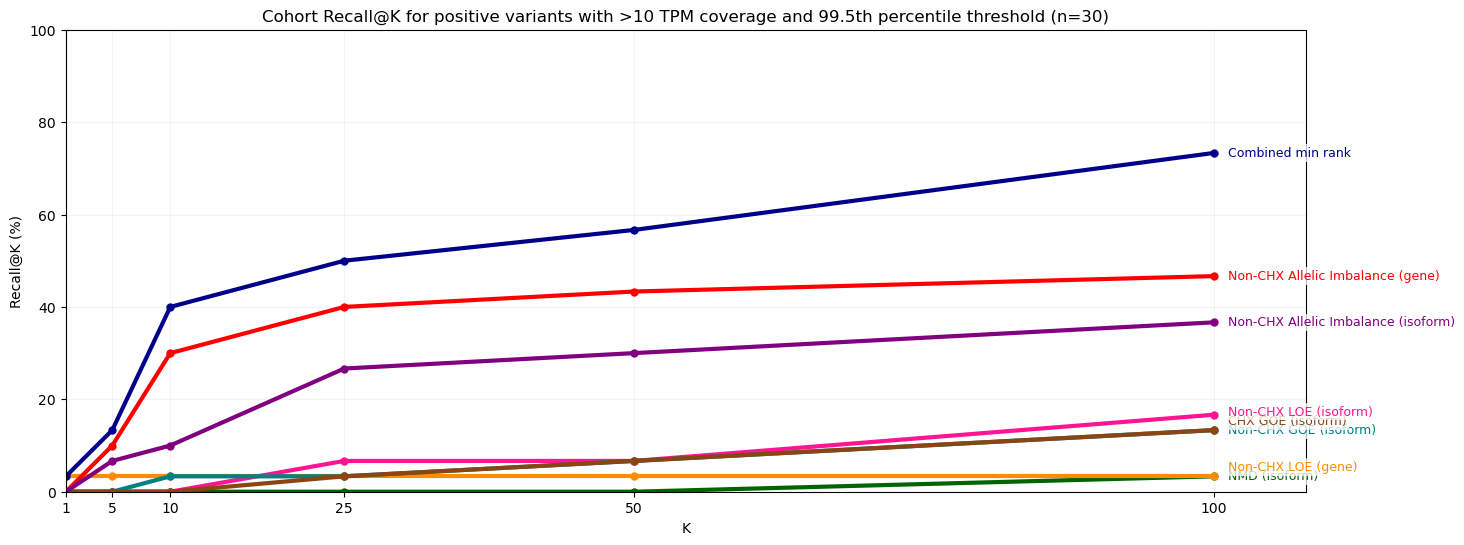

In [32]:
# Using coverage threshold of 10 TPM. 99.5th percentile.
#
# Filtered "all_samples_stop_gained_frameshift_with_all_metrics_and_ranks_MANE_include99.tsv" to get "fs_stop_splice_positives.tsv"
# - Filtering was done by filtering for genes with >10 TPM coverage for both Cyclo_TPM and Noncyclo_TPM
# - Removed frameshifts and stop-gains in the last exons
# - Removed genes that were not phased
# - Manually inspected in IGV to verify the variant is deleterious and impacts transcript usage

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS (EDIT THESE)
# =========================
input_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/fs_stop_splice_positives.tsv"
sheet_name = 0  # for Excel only; ignored for TSV/CSV
k_values = [1, 5, 10, 25, 50, 100]

rank_cols = [
    "NMD_rare_ss_tx_rank_top_99_5_percentile",
    "NMD_gene_rank_top_99_5_percentile",
    "NMD_isoform_rank_top_99_5_percentile",
    "Noncyclo_LOE_gene_rank_top_99_5_percentile",
    "Noncyclo_GOE_gene_rank_top_99_5_percentile",
    "Cyclo_GOE_gene_rank_top_99_5_percentile",
    "Noncyclo_AI_gene_rank_top_99_5_percentile",
    "Noncyclo_LOE_isoform_rank_top_99_5_percentile",
    "Noncyclo_GOE_isoform_rank_top_99_5_percentile",
    "Cyclo_GOE_isoform_rank_top_99_5_percentile",
    "Noncyclo_AI_isoform_rank_top_99_5_percentile",
]

# If True, compute combined rank = min across rank_cols (best evidence)
add_combined_min_rank = True

# Plot settings
make_plot = True
plot_include_individual_cols = True   # set False to plot only combined
plot_title = "Cohort Recall@K for positive variants with >10 TPM coverage and 99.5th percentile threshold"  # n will be appended automatically
output_metrics_csv = "recall_and_median_rank_at_k_table.csv"
output_winner_by_k_csv = "combined_min_rank_winner_distribution_by_k.csv"

# Inline label settings (tweak as needed)
inline_label_fontsize = 9
inline_label_min_y_gap = 2.0           # min vertical gap (Recall% units) between labels at the right edge
inline_label_x_pad_frac = 0.08         # fraction of x-range to add to the right for label room
inline_label_x_pos_frac_of_pad = 0.15  # how close labels are to line ends (smaller = closer)

# =========================
# LABEL OVERRIDES (PLOT ONLY)
# =========================
label_map = {
    "NMD_rare_ss_tx_rank_top_99_5_percentile": "NMD rare steady state (gene)",
    "NMD_gene_rank_top_99_5_percentile": "NMD (gene)",
    "NMD_isoform_rank_top_99_5_percentile": "NMD (isoform)",
    "Noncyclo_LOE_gene_rank_top_99_5_percentile": "Non-CHX LOE (gene)",
    "Noncyclo_GOE_gene_rank_top_99_5_percentile": "Non-CHX GOE (gene)",
    "Cyclo_GOE_gene_rank_top_99_5_percentile": "CHX GOE (gene)",
    "Noncyclo_AI_gene_rank_top_99_5_percentile": "Non-CHX Allelic Imbalance (gene)",
    "Noncyclo_LOE_isoform_rank_top_99_5_percentile": "Non-CHX LOE (isoform)",
    "Noncyclo_GOE_isoform_rank_top_99_5_percentile": "Non-CHX GOE (isoform)",
    "Cyclo_GOE_isoform_rank_top_99_5_percentile": "CHX GOE (isoform)",
    "Noncyclo_AI_isoform_rank_top_99_5_percentile": "Non-CHX Allelic Imbalance (isoform)",
    "Combined_min_rank": "Combined min rank",
}

# =========================
# HELPERS
# =========================
def read_table(path: str, sheet=0) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=sheet)
    elif ext in [".csv", ".tsv", ".txt"]:
        sep = "\t" if ext in [".tsv", ".txt"] else ","
        return pd.read_csv(path, sep=sep)
    else:
        raise ValueError(f"Unsupported file extension: {ext}. Use .xlsx/.xls/.csv/.tsv/.txt")


def coerce_rank_series(s: pd.Series) -> pd.Series:
    """Convert rank-like column to numeric; invalid/non-numeric -> NaN. Enforce rank >= 1."""
    x = pd.to_numeric(s, errors="coerce")
    x = x.where(x >= 1, np.nan)
    return x


def recall_and_median_rank_at_k(
    ranks: pd.Series, k_list: list[int]
) -> tuple[dict[int, float], dict[int, float]]:
    """
    ranks: numeric Series with NaN meaning "not retrieved"
    Returns:
      - recall@K dict
      - median_rank_among_retrieved@K dict (median of ranks where rank <= K; NaN if none retrieved)
    """
    denom = len(ranks)  # TP-only spreadsheet: every row is a TP
    rec = {}
    med = {}
    for K in k_list:
        retrieved = ranks[(ranks.notna()) & (ranks <= K)]
        rec[K] = float(len(retrieved)) / float(denom) if denom > 0 else np.nan
        med[K] = float(retrieved.median()) if len(retrieved) > 0 else np.nan
    return rec, med


def winner_column_for_row(row: pd.Series, cols: list[str]) -> str:
    """
    Given a row of ranks across cols, return the column name achieving the min rank.
    Ties: choose the first column in 'cols' order.
    If all NaN: return NA.
    """
    vals = row[cols].to_numpy(dtype=float)
    if np.all(np.isnan(vals)):
        return pd.NA
    min_val = np.nanmin(vals)
    for c in cols:
        v = row[c]
        if pd.notna(v) and float(v) == float(min_val):
            return c
    return pd.NA


def winner_distribution_by_k(
    df: pd.DataFrame, winner_col: str, combined_rank_col: str, k_list: list[int]
) -> pd.DataFrame:
    """
    For each K, among rows where combined_rank_col <= K, compute counts and percents of winner_col.
    Returns a long-form dataframe with columns: K, winner_metric, n, pct
    """
    out = []
    for K in k_list:
        mask = df[combined_rank_col].notna() & (df[combined_rank_col] <= K)
        sub = df.loc[mask, winner_col].dropna()
        total = len(sub)
        if total == 0:
            continue
        counts = sub.value_counts()
        for winner, n in counts.items():
            out.append({"K": K, "winner_metric": winner, "n": int(n), "pct": 100.0 * float(n) / float(total)})
    return pd.DataFrame(out)


def spread_labels_vertically(items, min_gap):
    """
    items: list of dicts with keys: 'y' plus any others.
    Adds 'y_label' values such that adjacent labels are at least min_gap apart.
    Greedy pass after sorting by y.
    """
    items_sorted = sorted(items, key=lambda d: d["y"])
    prev_y = None
    for d in items_sorted:
        y = d["y"]
        if prev_y is None:
            d["y_label"] = y
        else:
            d["y_label"] = y if (y - prev_y >= min_gap) else (prev_y + min_gap)
        prev_y = d["y_label"]
    return items_sorted


def is_all_zero_line(recall_pct_list: list[float], eps: float = 1e-12) -> bool:
    """True if every value is (numerically) zero."""
    return all(abs(v) <= eps for v in recall_pct_list)


def pick_strong_colors(n: int):
    """
    Return N high-contrast, non-faded colors (cycled if needed).
    Avoids very light yellows / pastels that look washed out on white.
    """
    base = [
        "darkgreen",
        "darkorange",
        "deeppink",
        "teal",
        "saddlebrown",
        "olive",
        "goldenrod",
        "slategray",
        "dodgerblue",
        "crimson",
        "indigo",
        "darkcyan",
        "firebrick",
        "darkmagenta",
        "seagreen",
        "chocolate",
        "mediumvioletred",
        "steelblue",
        "darkslateblue",
        "darkred",
    ]
    if n <= len(base):
        return base[:n]
    return [base[i % len(base)] for i in range(n)]

# =========================
# LOAD + VALIDATE
# =========================
df = read_table(input_path, sheet=sheet_name).copy()

missing = [c for c in rank_cols if c not in df.columns]
if missing:
    raise KeyError(
        "These rank columns were not found in your spreadsheet:\n"
        + "\n".join(missing)
        + "\n\nAvailable columns:\n"
        + ", ".join(df.columns.astype(str))
    )

# Coerce all rank columns to numeric
for c in rank_cols:
    df[c] = coerce_rank_series(df[c])

# Optional combined min-rank across modules
combined_col = "Combined_min_rank"
winner_col = "Combined_min_rank_winner"
if add_combined_min_rank:
    df[combined_col] = df[rank_cols].min(axis=1, skipna=True)
    df[winner_col] = df.apply(lambda r: winner_column_for_row(r, rank_cols), axis=1)

# =========================
# COMPUTE RECALL@K + MEDIAN RANK@K TABLE
# =========================
all_cols_to_score = rank_cols + ([combined_col] if add_combined_min_rank else [])

rows = []
for col in all_cols_to_score:
    rec, med = recall_and_median_rank_at_k(df[col], k_values)
    row = {"metric": col, "TP_rows": len(df), "NonNA_ranks": int(df[col].notna().sum())}
    for K in k_values:
        row[f"Recall@{K}"] = rec[K]
        row[f"MedianRank@{K}"] = med[K]
    rows.append(row)

metrics_table = pd.DataFrame(rows)

# Prettify: percent for Recall; keep MedianRank as numeric
metrics_table_pretty = metrics_table.copy()
for K in k_values:
    metrics_table_pretty[f"Recall@{K}"] = (100.0 * metrics_table_pretty[f"Recall@{K}"]).round(2)
    metrics_table_pretty[f"MedianRank@{K}"] = metrics_table_pretty[f"MedianRank@{K}"].round(2)

display(metrics_table_pretty)

metrics_table_pretty.to_csv(output_metrics_csv, index=False)
print(f"Saved Recall@K + MedianRank@K table to: {output_metrics_csv}")

# =========================
# WINNER DISTRIBUTION (ONLY FOR COMBINED MIN-RANK)
# =========================
if add_combined_min_rank:
    winner_by_k = winner_distribution_by_k(
        df,
        winner_col=winner_col,
        combined_rank_col=combined_col,
        k_list=k_values
    )

    if not winner_by_k.empty:
        winner_wide_pct = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="pct", aggfunc="sum"
        ).fillna(0.0)

        winner_wide_n = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="n", aggfunc="sum"
        ).fillna(0).astype(int)

        print("\nWinner distribution among retrieved TPs (percent) by K:")
        display(winner_wide_pct.round(2))

        print("\nWinner distribution among retrieved TPs (counts) by K:")
        display(winner_wide_n)

    winner_by_k.to_csv(output_winner_by_k_csv, index=False)
    print(f"Saved winner distribution by K to: {output_winner_by_k_csv}")

# =========================
# PLOT (RECALL@K) WITH INLINE LABELS
# Skips any metric whose Recall@K is zero for ALL K.
# =========================
if make_plot:
    x = k_values

    candidate_cols = []
    if plot_include_individual_cols:
        candidate_cols.extend(rank_cols)
    if add_combined_min_rank:
        candidate_cols.append(combined_col)

    # Compute recall curves first and drop all-zero lines
    curves = []  # list of dicts: {col, y_pct}
    for col in candidate_cols:
        rec, _ = recall_and_median_rank_at_k(df[col], k_values)
        y_pct = [100.0 * rec[K] for K in k_values]
        if is_all_zero_line(y_pct):
            continue
        curves.append({"col": col, "y_pct": y_pct})

    if len(curves) == 0:
        print("No non-zero Recall@K lines to plot (all metrics were 0 across all K).")
    else:
        fig, ax = plt.subplots(figsize=(16, 6))

        # Force specific metric colors + use only strong (non-faded) colors for the rest
        forced_colors = {
            combined_col: "darkblue",
            "Noncyclo_AI_gene_rank_top_99_5_percentile": "red",
            "Noncyclo_AI_isoform_rank_top_99_5_percentile": "purple",
        }

        unforced_cols = [c["col"] for c in curves if c["col"] not in forced_colors]
        strong_colors = pick_strong_colors(len(unforced_cols))
        unforced_color_map = dict(zip(unforced_cols, strong_colors))

        label_items = []
        for curve in curves:
            col = curve["col"]
            y = curve["y_pct"]

            line_color = forced_colors[col] if col in forced_colors else unforced_color_map[col]

            ax.plot(
                x, y,
                marker="o",
                linewidth=3.0,
                markersize=6.0,
                markeredgewidth=0.0,     
                markeredgecolor=line_color,
                color=line_color,
                alpha=1.0,
            )

            pretty_label = label_map.get(col, col)
            label_items.append({"col": pretty_label, "color": line_color, "y": y[-1]})

        ax.set_xlabel("K")
        ax.set_ylabel("Recall@K (%)")

        # Put n in the title (n = number of TP rows)
        n_tp = len(df)
        ax.set_title(f"{plot_title} (n={n_tp})")

        ax.set_xticks(k_values)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.15, linewidth=0.8)

        # Add a small x-padding so labels fit and sit just right of the last point
        x_min, x_max = min(x), max(x)
        x_pad = inline_label_x_pad_frac * (x_max - x_min)
        ax.set_xlim(x_min, x_max + x_pad)

        # Nudge labels to reduce overlap
        label_items_spread = spread_labels_vertically(label_items, inline_label_min_y_gap)

        # Place labels immediately to the right of the last x
        x_label = x_max + inline_label_x_pos_frac_of_pad * x_pad
        for item in label_items_spread:
            ax.text(
                x_label,
                item["y_label"],
                item["col"],
                color=item["color"],
                fontsize=inline_label_fontsize,
                va="center",
                ha="left",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            )

        # ==========================
        # SAVE AS PDF
        # ==========================
        out_pdf = "RecallK_10TPM_99_5.pdf"
        plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
        
        plt.show()

,metric,TP_rows,NonNA_ranks,Recall@1,MedianRank@1,Recall@5,MedianRank@5,Recall@10,MedianRank@10,Recall@25,MedianRank@25,Recall@50,MedianRank@50,Recall@100,MedianRank@100
0,NMD_rare_ss_tx_rank_top_99_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
1,NMD_gene_rank_top_99_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
2,NMD_isoform_rank_top_99_percentile,30,3,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
3,Noncyclo_LOE_gene_rank_top_99_percentile,30,2,3.33,1.0,3.33,1.0,3.33,1.0,3.33,1.0,3.33,1.0,3.33,1.0
4,Noncyclo_GOE_gene_rank_top_99_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
5,Cyclo_GOE_gene_rank_top_99_percentile,30,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
6,Noncyclo_AI_gene_rank_top_99_percentile,30,22,0.00,NaN,6.67,3.5,16.67,8.0,56.67,16.0,66.67,16.5,70.00,17.0
7,Noncyclo_LOE_isoform_rank_top_99_percentile,30,7,0.00,NaN,0.00,NaN,0.00,NaN,6.67,20.5,6.67,20.5,16.67,69.0
8,Noncyclo_GOE_isoform_rank_top_99_percentile,30,6,0.00,NaN,0.00,NaN,3.33,6.0,3.33,6.0,6.67,27.0,13.33,53.5
9,Cyclo_GOE_isoform_rank_top_99_percentile,30,6,0.00,NaN,0.00,NaN,0.00,NaN,3.33,17.0,6.67,33.5,10.00,50.0


Saved Recall@K + MedianRank@K table to: recall_and_median_rank_at_k_table.csv

Winner distribution among retrieved TPs (percent) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_percentile,Noncyclo_AI_isoform_rank_top_99_percentile,Noncyclo_GOE_isoform_rank_top_99_percentile,Noncyclo_LOE_gene_rank_top_99_percentile,Noncyclo_LOE_isoform_rank_top_99_percentile
K,,,,,
1,0.00,0.00,0.00,100.00,0.0
5,66.67,0.00,0.00,33.33,0.0
10,71.43,0.00,14.29,14.29,0.0
25,83.33,5.56,5.56,5.56,0.0
50,78.26,8.70,8.70,4.35,0.0
100,70.37,11.11,11.11,3.70,3.7



Winner distribution among retrieved TPs (counts) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_percentile,Noncyclo_AI_isoform_rank_top_99_percentile,Noncyclo_GOE_isoform_rank_top_99_percentile,Noncyclo_LOE_gene_rank_top_99_percentile,Noncyclo_LOE_isoform_rank_top_99_percentile
K,,,,,
1,0,0,0,1,0
5,2,0,0,1,0
10,5,0,1,1,0
25,15,1,1,1,0
50,18,2,2,1,0
100,19,3,3,1,1


Saved winner distribution by K to: combined_min_rank_winner_distribution_by_k.csv


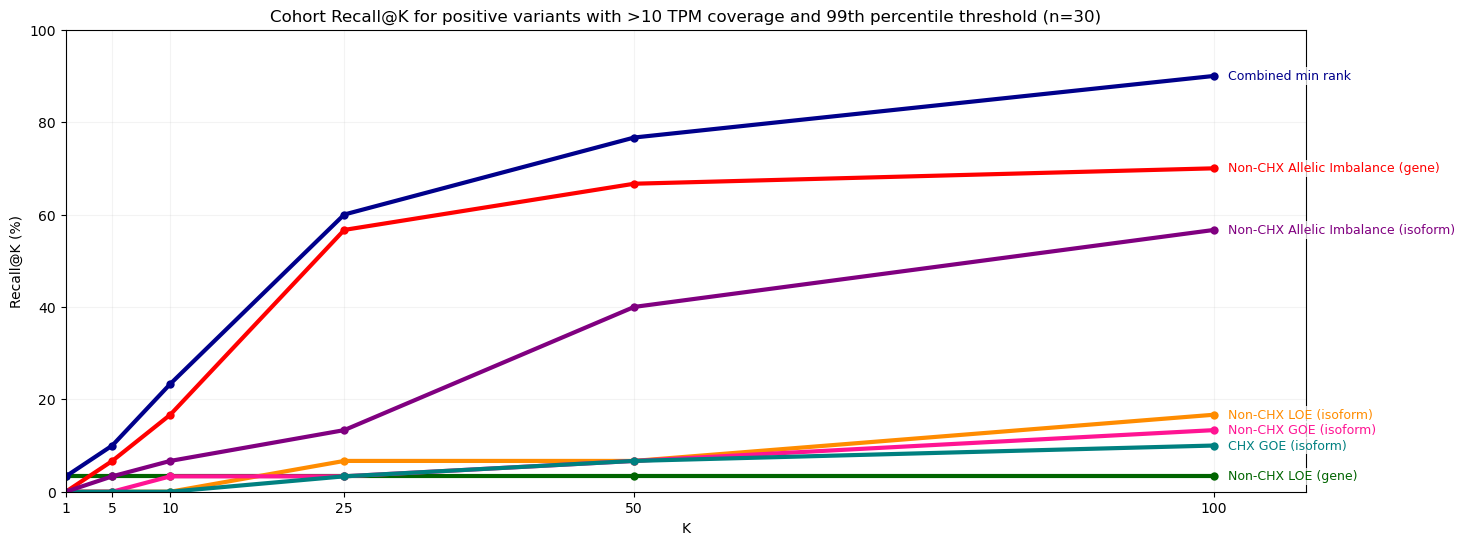

In [33]:
# Using coverage threshold of 10 TPM. 99th percentile.
#
# Filtered "all_samples_stop_gained_frameshift_with_all_metrics_and_ranks_MANE_include99.tsv" to get "fs_stop_splice_positives.tsv"
# - Filtering was done by filtering for genes with >10 TPM coverage for both Cyclo_TPM and Noncyclo_TPM
# - Removed frameshifts and stop-gains in the last exons
# - Removed genes that were not phased
# - Manually inspected in IGV to verify the variant is deleterious and impacts transcript usage

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS (EDIT THESE)
# =========================
input_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/fs_stop_splice_positives.tsv"
sheet_name = 0  # for Excel only; ignored for TSV/CSV
k_values = [1, 5, 10, 25, 50, 100]

rank_cols = [
    "NMD_rare_ss_tx_rank_top_99_percentile",
    "NMD_gene_rank_top_99_percentile",
    "NMD_isoform_rank_top_99_percentile",
    "Noncyclo_LOE_gene_rank_top_99_percentile",
    "Noncyclo_GOE_gene_rank_top_99_percentile",
    "Cyclo_GOE_gene_rank_top_99_percentile",
    "Noncyclo_AI_gene_rank_top_99_percentile",
    "Noncyclo_LOE_isoform_rank_top_99_percentile",
    "Noncyclo_GOE_isoform_rank_top_99_percentile",
    "Cyclo_GOE_isoform_rank_top_99_percentile",
    "Noncyclo_AI_isoform_rank_top_99_percentile",
]

# If True, compute combined rank = min across rank_cols (best evidence)
add_combined_min_rank = True

# Plot settings
make_plot = True
plot_include_individual_cols = True   # set False to plot only combined
plot_title = "Cohort Recall@K for positive variants with >10 TPM coverage and 99th percentile threshold"  # n will be appended automatically
output_metrics_csv = "recall_and_median_rank_at_k_table.csv"
output_winner_by_k_csv = "combined_min_rank_winner_distribution_by_k.csv"

# Inline label settings (tweak as needed)
inline_label_fontsize = 9
inline_label_min_y_gap = 2.0           # min vertical gap (Recall% units) between labels at the right edge
inline_label_x_pad_frac = 0.08         # fraction of x-range to add to the right for label room
inline_label_x_pos_frac_of_pad = 0.15  # how close labels are to line ends (smaller = closer)

# =========================
# LABEL OVERRIDES (PLOT ONLY)
# =========================
label_map = {
    "NMD_rare_ss_tx_rank_top_99_percentile": "NMD rare steady state (gene)",
    "NMD_gene_rank_top_99_percentile": "NMD (gene)",
    "NMD_isoform_rank_top_99_percentile": "NMD (isoform)",
    "Noncyclo_LOE_gene_rank_top_99_percentile": "Non-CHX LOE (gene)",
    "Noncyclo_GOE_gene_rank_top_99_percentile": "Non-CHX GOE (gene)",
    "Cyclo_GOE_gene_rank_top_99_percentile": "CHX GOE (gene)",
    "Noncyclo_AI_gene_rank_top_99_percentile": "Non-CHX Allelic Imbalance (gene)",
    "Noncyclo_LOE_isoform_rank_top_99_percentile": "Non-CHX LOE (isoform)",
    "Noncyclo_GOE_isoform_rank_top_99_percentile": "Non-CHX GOE (isoform)",
    "Cyclo_GOE_isoform_rank_top_99_percentile": "CHX GOE (isoform)",
    "Noncyclo_AI_isoform_rank_top_99_percentile": "Non-CHX Allelic Imbalance (isoform)",
    "Combined_min_rank": "Combined min rank",
}

# =========================
# HELPERS
# =========================
def read_table(path: str, sheet=0) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=sheet)
    elif ext in [".csv", ".tsv", ".txt"]:
        sep = "\t" if ext in [".tsv", ".txt"] else ","
        return pd.read_csv(path, sep=sep)
    else:
        raise ValueError(f"Unsupported file extension: {ext}. Use .xlsx/.xls/.csv/.tsv/.txt")


def coerce_rank_series(s: pd.Series) -> pd.Series:
    """Convert rank-like column to numeric; invalid/non-numeric -> NaN. Enforce rank >= 1."""
    x = pd.to_numeric(s, errors="coerce")
    x = x.where(x >= 1, np.nan)
    return x


def recall_and_median_rank_at_k(
    ranks: pd.Series, k_list: list[int]
) -> tuple[dict[int, float], dict[int, float]]:
    """
    ranks: numeric Series with NaN meaning "not retrieved"
    Returns:
      - recall@K dict
      - median_rank_among_retrieved@K dict (median of ranks where rank <= K; NaN if none retrieved)
    """
    denom = len(ranks)  # TP-only spreadsheet: every row is a TP
    rec = {}
    med = {}
    for K in k_list:
        retrieved = ranks[(ranks.notna()) & (ranks <= K)]
        rec[K] = float(len(retrieved)) / float(denom) if denom > 0 else np.nan
        med[K] = float(retrieved.median()) if len(retrieved) > 0 else np.nan
    return rec, med


def winner_column_for_row(row: pd.Series, cols: list[str]) -> str:
    """
    Given a row of ranks across cols, return the column name achieving the min rank.
    Ties: choose the first column in 'cols' order.
    If all NaN: return NA.
    """
    vals = row[cols].to_numpy(dtype=float)
    if np.all(np.isnan(vals)):
        return pd.NA
    min_val = np.nanmin(vals)
    for c in cols:
        v = row[c]
        if pd.notna(v) and float(v) == float(min_val):
            return c
    return pd.NA


def winner_distribution_by_k(
    df: pd.DataFrame, winner_col: str, combined_rank_col: str, k_list: list[int]
) -> pd.DataFrame:
    """
    For each K, among rows where combined_rank_col <= K, compute counts and percents of winner_col.
    Returns a long-form dataframe with columns: K, winner_metric, n, pct
    """
    out = []
    for K in k_list:
        mask = df[combined_rank_col].notna() & (df[combined_rank_col] <= K)
        sub = df.loc[mask, winner_col].dropna()
        total = len(sub)
        if total == 0:
            continue
        counts = sub.value_counts()
        for winner, n in counts.items():
            out.append({"K": K, "winner_metric": winner, "n": int(n), "pct": 100.0 * float(n) / float(total)})
    return pd.DataFrame(out)


def spread_labels_vertically(items, min_gap):
    """
    items: list of dicts with keys: 'y' plus any others.
    Adds 'y_label' values such that adjacent labels are at least min_gap apart.
    Greedy pass after sorting by y.
    """
    items_sorted = sorted(items, key=lambda d: d["y"])
    prev_y = None
    for d in items_sorted:
        y = d["y"]
        if prev_y is None:
            d["y_label"] = y
        else:
            d["y_label"] = y if (y - prev_y >= min_gap) else (prev_y + min_gap)
        prev_y = d["y_label"]
    return items_sorted


def is_all_zero_line(recall_pct_list: list[float], eps: float = 1e-12) -> bool:
    """True if every value is (numerically) zero."""
    return all(abs(v) <= eps for v in recall_pct_list)


def pick_strong_colors(n: int):
    """
    Return N high-contrast, non-faded colors (cycled if needed).
    Avoids very light yellows / pastels that look washed out on white.
    """
    base = [
        "darkgreen",
        "darkorange",
        "deeppink",
        "teal",
        "saddlebrown",
        "olive",
        "goldenrod",
        "slategray",
        "dodgerblue",
        "crimson",
        "indigo",
        "darkcyan",
        "firebrick",
        "darkmagenta",
        "seagreen",
        "chocolate",
        "mediumvioletred",
        "steelblue",
        "darkslateblue",
        "darkred",
    ]
    if n <= len(base):
        return base[:n]
    return [base[i % len(base)] for i in range(n)]

# =========================
# LOAD + VALIDATE
# =========================
df = read_table(input_path, sheet=sheet_name).copy()

missing = [c for c in rank_cols if c not in df.columns]
if missing:
    raise KeyError(
        "These rank columns were not found in your spreadsheet:\n"
        + "\n".join(missing)
        + "\n\nAvailable columns:\n"
        + ", ".join(df.columns.astype(str))
    )

# Coerce all rank columns to numeric
for c in rank_cols:
    df[c] = coerce_rank_series(df[c])

# Optional combined min-rank across modules
combined_col = "Combined_min_rank"
winner_col = "Combined_min_rank_winner"
if add_combined_min_rank:
    df[combined_col] = df[rank_cols].min(axis=1, skipna=True)
    df[winner_col] = df.apply(lambda r: winner_column_for_row(r, rank_cols), axis=1)

# =========================
# COMPUTE RECALL@K + MEDIAN RANK@K TABLE
# =========================
all_cols_to_score = rank_cols + ([combined_col] if add_combined_min_rank else [])

rows = []
for col in all_cols_to_score:
    rec, med = recall_and_median_rank_at_k(df[col], k_values)
    row = {"metric": col, "TP_rows": len(df), "NonNA_ranks": int(df[col].notna().sum())}
    for K in k_values:
        row[f"Recall@{K}"] = rec[K]
        row[f"MedianRank@{K}"] = med[K]
    rows.append(row)

metrics_table = pd.DataFrame(rows)

# Prettify: percent for Recall; keep MedianRank as numeric
metrics_table_pretty = metrics_table.copy()
for K in k_values:
    metrics_table_pretty[f"Recall@{K}"] = (100.0 * metrics_table_pretty[f"Recall@{K}"]).round(2)
    metrics_table_pretty[f"MedianRank@{K}"] = metrics_table_pretty[f"MedianRank@{K}"].round(2)

display(metrics_table_pretty)

metrics_table_pretty.to_csv(output_metrics_csv, index=False)
print(f"Saved Recall@K + MedianRank@K table to: {output_metrics_csv}")

# =========================
# WINNER DISTRIBUTION (ONLY FOR COMBINED MIN-RANK)
# =========================
if add_combined_min_rank:
    winner_by_k = winner_distribution_by_k(
        df,
        winner_col=winner_col,
        combined_rank_col=combined_col,
        k_list=k_values
    )

    if not winner_by_k.empty:
        winner_wide_pct = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="pct", aggfunc="sum"
        ).fillna(0.0)

        winner_wide_n = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="n", aggfunc="sum"
        ).fillna(0).astype(int)

        print("\nWinner distribution among retrieved TPs (percent) by K:")
        display(winner_wide_pct.round(2))

        print("\nWinner distribution among retrieved TPs (counts) by K:")
        display(winner_wide_n)

    winner_by_k.to_csv(output_winner_by_k_csv, index=False)
    print(f"Saved winner distribution by K to: {output_winner_by_k_csv}")

# =========================
# PLOT (RECALL@K) WITH INLINE LABELS
# Skips any metric whose Recall@K is zero for ALL K.
# =========================
if make_plot:
    x = k_values

    candidate_cols = []
    if plot_include_individual_cols:
        candidate_cols.extend(rank_cols)
    if add_combined_min_rank:
        candidate_cols.append(combined_col)

    # Compute recall curves first and drop all-zero lines
    curves = []  # list of dicts: {col, y_pct}
    for col in candidate_cols:
        rec, _ = recall_and_median_rank_at_k(df[col], k_values)
        y_pct = [100.0 * rec[K] for K in k_values]
        if is_all_zero_line(y_pct):
            continue
        curves.append({"col": col, "y_pct": y_pct})

    if len(curves) == 0:
        print("No non-zero Recall@K lines to plot (all metrics were 0 across all K).")
    else:
        fig, ax = plt.subplots(figsize=(16, 6))

        # Force specific metric colors + use only strong (non-faded) colors for the rest
        forced_colors = {
            combined_col: "darkblue",
            "Noncyclo_AI_gene_rank_top_99_percentile": "red",
            "Noncyclo_AI_isoform_rank_top_99_percentile": "purple",
        }

        unforced_cols = [c["col"] for c in curves if c["col"] not in forced_colors]
        strong_colors = pick_strong_colors(len(unforced_cols))
        unforced_color_map = dict(zip(unforced_cols, strong_colors))

        label_items = []
        for curve in curves:
            col = curve["col"]
            y = curve["y_pct"]

            line_color = forced_colors[col] if col in forced_colors else unforced_color_map[col]

            ax.plot(
                x, y,
                marker="o",
                linewidth=3.0,
                markersize=6.0,
                markeredgewidth=0.0,  
                markeredgecolor=line_color,
                color=line_color,
                alpha=1.0,
            )

            pretty_label = label_map.get(col, col)
            label_items.append({"col": pretty_label, "color": line_color, "y": y[-1]})

        ax.set_xlabel("K")
        ax.set_ylabel("Recall@K (%)")

        # Put n in the title (n = number of TP rows)
        n_tp = len(df)
        ax.set_title(f"{plot_title} (n={n_tp})")

        ax.set_xticks(k_values)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.15, linewidth=0.8)

        # Add a small x-padding so labels fit and sit just right of the last point
        x_min, x_max = min(x), max(x)
        x_pad = inline_label_x_pad_frac * (x_max - x_min)
        ax.set_xlim(x_min, x_max + x_pad)

        # Nudge labels to reduce overlap
        label_items_spread = spread_labels_vertically(label_items, inline_label_min_y_gap)

        # Place labels immediately to the right of the last x
        x_label = x_max + inline_label_x_pos_frac_of_pad * x_pad
        for item in label_items_spread:
            ax.text(
                x_label,
                item["y_label"],
                item["col"],
                color=item["color"],
                fontsize=inline_label_fontsize,
                va="center",
                ha="left",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            )

        # ==========================
        # SAVE AS PDF
        # ==========================
        out_pdf = "RecallK_10TPM_99.pdf"
        plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
        
        plt.show()

,metric,TP_rows,NonNA_ranks,Recall@1,MedianRank@1,Recall@5,MedianRank@5,Recall@10,MedianRank@10,Recall@25,MedianRank@25,Recall@50,MedianRank@50,Recall@100,MedianRank@100
0,NMD_rare_ss_tx_rank_top_99_5_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
1,NMD_gene_rank_top_99_5_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
2,NMD_isoform_rank_top_99_5_percentile,14,1,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
3,Noncyclo_LOE_gene_rank_top_99_5_percentile,14,1,7.14,1.0,7.14,1.0,7.14,1.0,7.14,1.0,7.14,1.0,7.14,1.0
4,Noncyclo_GOE_gene_rank_top_99_5_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
5,Cyclo_GOE_gene_rank_top_99_5_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
6,Noncyclo_AI_gene_rank_top_99_5_percentile,14,8,0.00,NaN,14.29,2.0,28.57,5.0,42.86,9.0,50.00,10.0,57.14,11.0
7,Noncyclo_LOE_isoform_rank_top_99_5_percentile,14,5,0.00,NaN,0.00,NaN,0.00,NaN,14.29,20.5,14.29,20.5,28.57,40.0
8,Noncyclo_GOE_isoform_rank_top_99_5_percentile,14,3,0.00,NaN,0.00,NaN,7.14,6.0,7.14,6.0,7.14,6.0,21.43,54.0
9,Cyclo_GOE_isoform_rank_top_99_5_percentile,14,2,0.00,NaN,0.00,NaN,0.00,NaN,7.14,13.0,7.14,13.0,14.29,52.5


Saved Recall@K + MedianRank@K table to: recall_and_median_rank_at_k_table.csv

Winner distribution among retrieved TPs (percent) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_5_percentile,Noncyclo_AI_isoform_rank_top_99_5_percentile,Noncyclo_GOE_isoform_rank_top_99_5_percentile,Noncyclo_LOE_gene_rank_top_99_5_percentile,Noncyclo_LOE_isoform_rank_top_99_5_percentile
K,,,,,
1,0.00,0.00,0.00,100.00,0.00
5,66.67,0.00,0.00,33.33,0.00
10,57.14,14.29,14.29,14.29,0.00
25,62.50,12.50,12.50,12.50,0.00
50,66.67,11.11,11.11,11.11,0.00
100,50.00,8.33,25.00,8.33,8.33



Winner distribution among retrieved TPs (counts) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_5_percentile,Noncyclo_AI_isoform_rank_top_99_5_percentile,Noncyclo_GOE_isoform_rank_top_99_5_percentile,Noncyclo_LOE_gene_rank_top_99_5_percentile,Noncyclo_LOE_isoform_rank_top_99_5_percentile
K,,,,,
1,0,0,0,1,0
5,2,0,0,1,0
10,4,1,1,1,0
25,5,1,1,1,0
50,6,1,1,1,0
100,6,1,3,1,1


Saved winner distribution by K to: combined_min_rank_winner_distribution_by_k.csv


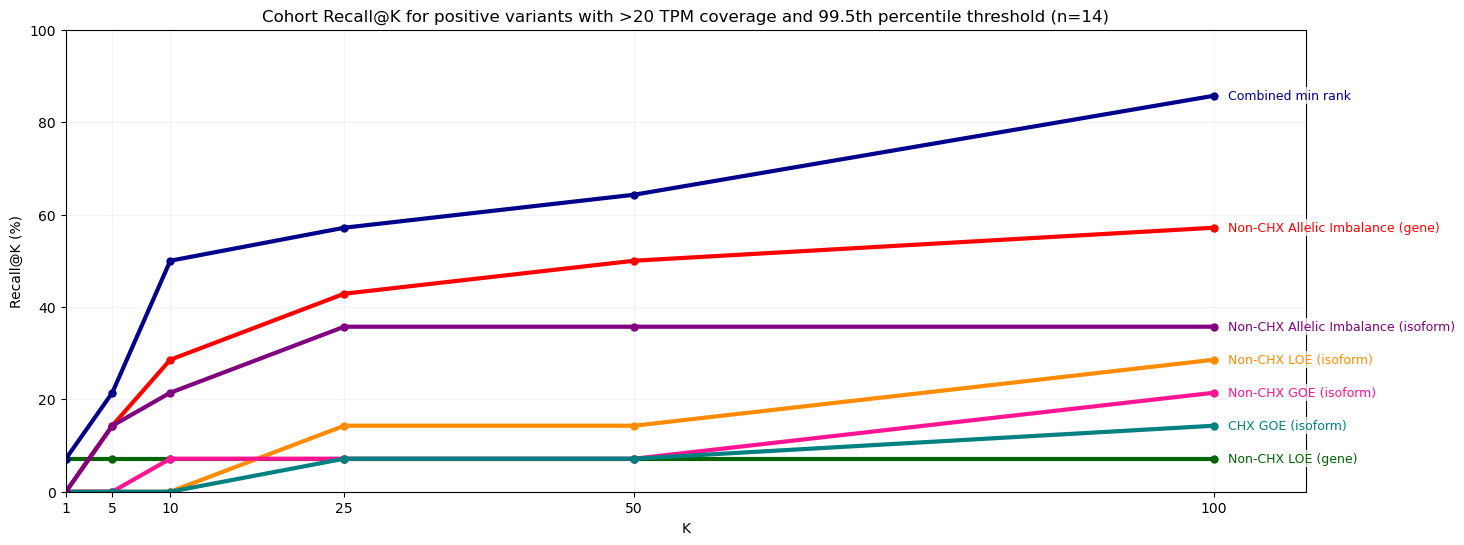

In [34]:
# Using coverage threshold of 20 TPM. 99.5th percentile.
#
# Filtered "all_samples_stop_gained_frameshift_with_all_metrics_and_ranks_MANE_include99.tsv" to get "fs_stop_splice_positives.tsv"
# - Filtering was done by filtering for genes with >10 TPM coverage for both Cyclo_TPM and Noncyclo_TPM
# - Removed frameshifts and stop-gains in the last exons
# - Removed genes that were not phased
# - Manually inspected in IGV to verify the variant is deleterious and impacts transcript usage

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS (EDIT THESE)
# =========================
input_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/fs_stop_splice_positives_20TPM.tsv"
sheet_name = 0  # for Excel only; ignored for TSV/CSV
k_values = [1, 5, 10, 25, 50, 100]

rank_cols = [
    "NMD_rare_ss_tx_rank_top_99_5_percentile",
    "NMD_gene_rank_top_99_5_percentile",
    "NMD_isoform_rank_top_99_5_percentile",
    "Noncyclo_LOE_gene_rank_top_99_5_percentile",
    "Noncyclo_GOE_gene_rank_top_99_5_percentile",
    "Cyclo_GOE_gene_rank_top_99_5_percentile",
    "Noncyclo_AI_gene_rank_top_99_5_percentile",
    "Noncyclo_LOE_isoform_rank_top_99_5_percentile",
    "Noncyclo_GOE_isoform_rank_top_99_5_percentile",
    "Cyclo_GOE_isoform_rank_top_99_5_percentile",
    "Noncyclo_AI_isoform_rank_top_99_5_percentile",
]

# If True, compute combined rank = min across rank_cols (best evidence)
add_combined_min_rank = True

# Plot settings
make_plot = True
plot_include_individual_cols = True   # set False to plot only combined
plot_title = "Cohort Recall@K for positive variants with >20 TPM coverage and 99.5th percentile threshold"  # n will be appended automatically
output_metrics_csv = "recall_and_median_rank_at_k_table.csv"
output_winner_by_k_csv = "combined_min_rank_winner_distribution_by_k.csv"

# Inline label settings (tweak as needed)
inline_label_fontsize = 9
inline_label_min_y_gap = 2.0           # min vertical gap (Recall% units) between labels at the right edge
inline_label_x_pad_frac = 0.08         # fraction of x-range to add to the right for label room
inline_label_x_pos_frac_of_pad = 0.15  # how close labels are to line ends (smaller = closer)

# =========================
# LABEL OVERRIDES (PLOT ONLY)
# =========================
label_map = {
    "NMD_rare_ss_tx_rank_top_99_5_percentile": "NMD rare steady state (gene)",
    "NMD_gene_rank_top_99_5_percentile": "NMD (gene)",
    "NMD_isoform_rank_top_99_5_percentile": "NMD (isoform)",
    "Noncyclo_LOE_gene_rank_top_99_5_percentile": "Non-CHX LOE (gene)",
    "Noncyclo_GOE_gene_rank_top_99_5_percentile": "Non-CHX GOE (gene)",
    "Cyclo_GOE_gene_rank_top_99_5_percentile": "CHX GOE (gene)",
    "Noncyclo_AI_gene_rank_top_99_5_percentile": "Non-CHX Allelic Imbalance (gene)",
    "Noncyclo_LOE_isoform_rank_top_99_5_percentile": "Non-CHX LOE (isoform)",
    "Noncyclo_GOE_isoform_rank_top_99_5_percentile": "Non-CHX GOE (isoform)",
    "Cyclo_GOE_isoform_rank_top_99_5_percentile": "CHX GOE (isoform)",
    "Noncyclo_AI_isoform_rank_top_99_5_percentile": "Non-CHX Allelic Imbalance (isoform)",
    "Combined_min_rank": "Combined min rank",
}

# =========================
# HELPERS
# =========================
def read_table(path: str, sheet=0) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=sheet)
    elif ext in [".csv", ".tsv", ".txt"]:
        sep = "\t" if ext in [".tsv", ".txt"] else ","
        return pd.read_csv(path, sep=sep)
    else:
        raise ValueError(f"Unsupported file extension: {ext}. Use .xlsx/.xls/.csv/.tsv/.txt")


def coerce_rank_series(s: pd.Series) -> pd.Series:
    """Convert rank-like column to numeric; invalid/non-numeric -> NaN. Enforce rank >= 1."""
    x = pd.to_numeric(s, errors="coerce")
    x = x.where(x >= 1, np.nan)
    return x


def recall_and_median_rank_at_k(
    ranks: pd.Series, k_list: list[int]
) -> tuple[dict[int, float], dict[int, float]]:
    """
    ranks: numeric Series with NaN meaning "not retrieved"
    Returns:
      - recall@K dict
      - median_rank_among_retrieved@K dict (median of ranks where rank <= K; NaN if none retrieved)
    """
    denom = len(ranks)  # TP-only spreadsheet: every row is a TP
    rec = {}
    med = {}
    for K in k_list:
        retrieved = ranks[(ranks.notna()) & (ranks <= K)]
        rec[K] = float(len(retrieved)) / float(denom) if denom > 0 else np.nan
        med[K] = float(retrieved.median()) if len(retrieved) > 0 else np.nan
    return rec, med


def winner_column_for_row(row: pd.Series, cols: list[str]) -> str:
    """
    Given a row of ranks across cols, return the column name achieving the min rank.
    Ties: choose the first column in 'cols' order.
    If all NaN: return NA.
    """
    vals = row[cols].to_numpy(dtype=float)
    if np.all(np.isnan(vals)):
        return pd.NA
    min_val = np.nanmin(vals)
    for c in cols:
        v = row[c]
        if pd.notna(v) and float(v) == float(min_val):
            return c
    return pd.NA


def winner_distribution_by_k(
    df: pd.DataFrame, winner_col: str, combined_rank_col: str, k_list: list[int]
) -> pd.DataFrame:
    """
    For each K, among rows where combined_rank_col <= K, compute counts and percents of winner_col.
    Returns a long-form dataframe with columns: K, winner_metric, n, pct
    """
    out = []
    for K in k_list:
        mask = df[combined_rank_col].notna() & (df[combined_rank_col] <= K)
        sub = df.loc[mask, winner_col].dropna()
        total = len(sub)
        if total == 0:
            continue
        counts = sub.value_counts()
        for winner, n in counts.items():
            out.append({"K": K, "winner_metric": winner, "n": int(n), "pct": 100.0 * float(n) / float(total)})
    return pd.DataFrame(out)


def spread_labels_vertically(items, min_gap):
    """
    items: list of dicts with keys: 'y' plus any others.
    Adds 'y_label' values such that adjacent labels are at least min_gap apart.
    Greedy pass after sorting by y.
    """
    items_sorted = sorted(items, key=lambda d: d["y"])
    prev_y = None
    for d in items_sorted:
        y = d["y"]
        if prev_y is None:
            d["y_label"] = y
        else:
            d["y_label"] = y if (y - prev_y >= min_gap) else (prev_y + min_gap)
        prev_y = d["y_label"]
    return items_sorted


def is_all_zero_line(recall_pct_list: list[float], eps: float = 1e-12) -> bool:
    """True if every value is (numerically) zero."""
    return all(abs(v) <= eps for v in recall_pct_list)


def pick_strong_colors(n: int):
    """
    Return N high-contrast, non-faded colors (cycled if needed).
    Avoids very light yellows / pastels that look washed out on white.
    """
    base = [
        "darkgreen",
        "darkorange",
        "deeppink",
        "teal",
        "saddlebrown",
        "olive",
        "goldenrod",
        "slategray",
        "dodgerblue",
        "crimson",
        "indigo",
        "darkcyan",
        "firebrick",
        "darkmagenta",
        "seagreen",
        "chocolate",
        "mediumvioletred",
        "steelblue",
        "darkslateblue",
        "darkred",
    ]
    if n <= len(base):
        return base[:n]
    return [base[i % len(base)] for i in range(n)]

# =========================
# LOAD + VALIDATE
# =========================
df = read_table(input_path, sheet=sheet_name).copy()

missing = [c for c in rank_cols if c not in df.columns]
if missing:
    raise KeyError(
        "These rank columns were not found in your spreadsheet:\n"
        + "\n".join(missing)
        + "\n\nAvailable columns:\n"
        + ", ".join(df.columns.astype(str))
    )

# Coerce all rank columns to numeric
for c in rank_cols:
    df[c] = coerce_rank_series(df[c])

# Optional combined min-rank across modules
combined_col = "Combined_min_rank"
winner_col = "Combined_min_rank_winner"
if add_combined_min_rank:
    df[combined_col] = df[rank_cols].min(axis=1, skipna=True)
    df[winner_col] = df.apply(lambda r: winner_column_for_row(r, rank_cols), axis=1)

# =========================
# COMPUTE RECALL@K + MEDIAN RANK@K TABLE
# =========================
all_cols_to_score = rank_cols + ([combined_col] if add_combined_min_rank else [])

rows = []
for col in all_cols_to_score:
    rec, med = recall_and_median_rank_at_k(df[col], k_values)
    row = {"metric": col, "TP_rows": len(df), "NonNA_ranks": int(df[col].notna().sum())}
    for K in k_values:
        row[f"Recall@{K}"] = rec[K]
        row[f"MedianRank@{K}"] = med[K]
    rows.append(row)

metrics_table = pd.DataFrame(rows)

# Prettify: percent for Recall; keep MedianRank as numeric
metrics_table_pretty = metrics_table.copy()
for K in k_values:
    metrics_table_pretty[f"Recall@{K}"] = (100.0 * metrics_table_pretty[f"Recall@{K}"]).round(2)
    metrics_table_pretty[f"MedianRank@{K}"] = metrics_table_pretty[f"MedianRank@{K}"].round(2)

display(metrics_table_pretty)

metrics_table_pretty.to_csv(output_metrics_csv, index=False)
print(f"Saved Recall@K + MedianRank@K table to: {output_metrics_csv}")

# =========================
# WINNER DISTRIBUTION (ONLY FOR COMBINED MIN-RANK)
# =========================
if add_combined_min_rank:
    winner_by_k = winner_distribution_by_k(
        df,
        winner_col=winner_col,
        combined_rank_col=combined_col,
        k_list=k_values
    )

    if not winner_by_k.empty:
        winner_wide_pct = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="pct", aggfunc="sum"
        ).fillna(0.0)

        winner_wide_n = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="n", aggfunc="sum"
        ).fillna(0).astype(int)

        print("\nWinner distribution among retrieved TPs (percent) by K:")
        display(winner_wide_pct.round(2))

        print("\nWinner distribution among retrieved TPs (counts) by K:")
        display(winner_wide_n)

    winner_by_k.to_csv(output_winner_by_k_csv, index=False)
    print(f"Saved winner distribution by K to: {output_winner_by_k_csv}")

# =========================
# PLOT (RECALL@K) WITH INLINE LABELS
# Skips any metric whose Recall@K is zero for ALL K.
# =========================
if make_plot:
    x = k_values

    candidate_cols = []
    if plot_include_individual_cols:
        candidate_cols.extend(rank_cols)
    if add_combined_min_rank:
        candidate_cols.append(combined_col)

    # Compute recall curves first and drop all-zero lines
    curves = []  # list of dicts: {col, y_pct}
    for col in candidate_cols:
        rec, _ = recall_and_median_rank_at_k(df[col], k_values)
        y_pct = [100.0 * rec[K] for K in k_values]
        if is_all_zero_line(y_pct):
            continue
        curves.append({"col": col, "y_pct": y_pct})

    if len(curves) == 0:
        print("No non-zero Recall@K lines to plot (all metrics were 0 across all K).")
    else:
        fig, ax = plt.subplots(figsize=(16, 6))

        # Force specific metric colors + use only strong (non-faded) colors for the rest
        forced_colors = {
            combined_col: "darkblue",
            "Noncyclo_AI_gene_rank_top_99_5_percentile": "red",
            "Noncyclo_AI_isoform_rank_top_99_5_percentile": "purple",
        }

        unforced_cols = [c["col"] for c in curves if c["col"] not in forced_colors]
        strong_colors = pick_strong_colors(len(unforced_cols))
        unforced_color_map = dict(zip(unforced_cols, strong_colors))

        label_items = []
        for curve in curves:
            col = curve["col"]
            y = curve["y_pct"]

            line_color = forced_colors[col] if col in forced_colors else unforced_color_map[col]

            ax.plot(
                x, y,
                marker="o",
                linewidth=3.0,
                markersize=6.0,
                markeredgewidth=0.0,     
                markeredgecolor=line_color,
                color=line_color,
                alpha=1.0,
            )

            pretty_label = label_map.get(col, col)
            label_items.append({"col": pretty_label, "color": line_color, "y": y[-1]})

        ax.set_xlabel("K")
        ax.set_ylabel("Recall@K (%)")

        # Put n in the title (n = number of TP rows)
        n_tp = len(df)
        ax.set_title(f"{plot_title} (n={n_tp})")

        ax.set_xticks(k_values)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.15, linewidth=0.8)

        # Add a small x-padding so labels fit and sit just right of the last point
        x_min, x_max = min(x), max(x)
        x_pad = inline_label_x_pad_frac * (x_max - x_min)
        ax.set_xlim(x_min, x_max + x_pad)

        # Nudge labels to reduce overlap
        label_items_spread = spread_labels_vertically(label_items, inline_label_min_y_gap)

        # Place labels immediately to the right of the last x
        x_label = x_max + inline_label_x_pos_frac_of_pad * x_pad
        for item in label_items_spread:
            ax.text(
                x_label,
                item["y_label"],
                item["col"],
                color=item["color"],
                fontsize=inline_label_fontsize,
                va="center",
                ha="left",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            )

        # ==========================
        # SAVE AS PDF
        # ==========================
        out_pdf = "RecallK_20TPM_99_5.pdf"
        plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
        
        plt.show()

,metric,TP_rows,NonNA_ranks,Recall@1,MedianRank@1,Recall@5,MedianRank@5,Recall@10,MedianRank@10,Recall@25,MedianRank@25,Recall@50,MedianRank@50,Recall@100,MedianRank@100
0,NMD_rare_ss_tx_rank_top_99_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
1,NMD_gene_rank_top_99_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
2,NMD_isoform_rank_top_99_percentile,14,1,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
3,Noncyclo_LOE_gene_rank_top_99_percentile,14,2,7.14,1.0,7.14,1.0,7.14,1.0,7.14,1.0,7.14,1.0,7.14,1.0
4,Noncyclo_GOE_gene_rank_top_99_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
5,Cyclo_GOE_gene_rank_top_99_percentile,14,0,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN
6,Noncyclo_AI_gene_rank_top_99_percentile,14,10,0.00,NaN,14.29,3.5,14.29,3.5,57.14,16.0,57.14,16.0,64.29,16.0
7,Noncyclo_LOE_isoform_rank_top_99_percentile,14,5,0.00,NaN,0.00,NaN,0.00,NaN,14.29,20.5,14.29,20.5,28.57,45.0
8,Noncyclo_GOE_isoform_rank_top_99_percentile,14,3,0.00,NaN,0.00,NaN,7.14,6.0,7.14,6.0,7.14,6.0,21.43,59.0
9,Cyclo_GOE_isoform_rank_top_99_percentile,14,3,0.00,NaN,0.00,NaN,0.00,NaN,7.14,17.0,7.14,17.0,7.14,17.0


Saved Recall@K + MedianRank@K table to: recall_and_median_rank_at_k_table.csv

Winner distribution among retrieved TPs (percent) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_percentile,Noncyclo_AI_isoform_rank_top_99_percentile,Noncyclo_GOE_isoform_rank_top_99_percentile,Noncyclo_LOE_gene_rank_top_99_percentile,Noncyclo_LOE_isoform_rank_top_99_percentile
K,,,,,
1,0.00,0.00,0.00,100.00,0.00
5,66.67,0.00,0.00,33.33,0.00
10,50.00,0.00,25.00,25.00,0.00
25,66.67,11.11,11.11,11.11,0.00
50,66.67,11.11,11.11,11.11,0.00
100,53.85,15.38,15.38,7.69,7.69



Winner distribution among retrieved TPs (counts) by K:


winner_metric,Noncyclo_AI_gene_rank_top_99_percentile,Noncyclo_AI_isoform_rank_top_99_percentile,Noncyclo_GOE_isoform_rank_top_99_percentile,Noncyclo_LOE_gene_rank_top_99_percentile,Noncyclo_LOE_isoform_rank_top_99_percentile
K,,,,,
1,0,0,0,1,0
5,2,0,0,1,0
10,2,0,1,1,0
25,6,1,1,1,0
50,6,1,1,1,0
100,7,2,2,1,1


Saved winner distribution by K to: combined_min_rank_winner_distribution_by_k.csv


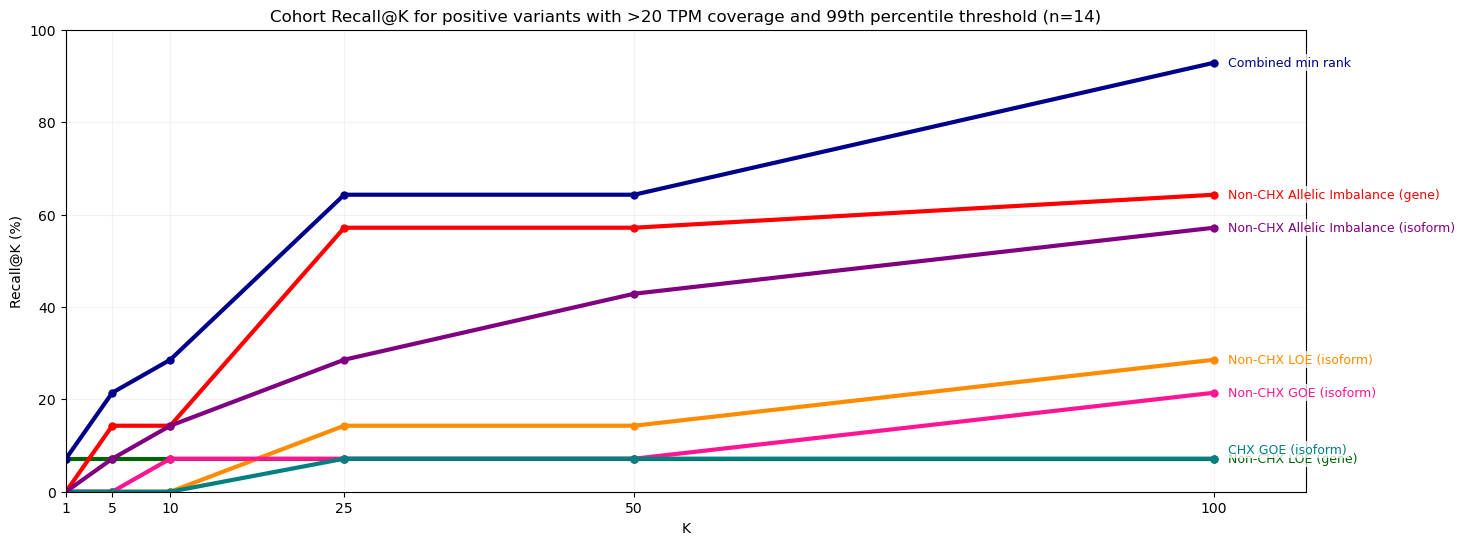

In [35]:
# Using coverage threshold of 20 TPM. 99th percentile.
#
# Filtered "all_samples_stop_gained_frameshift_with_all_metrics_and_ranks_MANE_include99.tsv" to get "fs_stop_splice_positives.tsv"
# - Filtering was done by filtering for genes with >10 TPM coverage for both Cyclo_TPM and Noncyclo_TPM
# - Removed frameshifts and stop-gains in the last exons
# - Removed genes that were not phased
# - Manually inspected in IGV to verify the variant is deleterious and impacts transcript usage

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER INPUTS (EDIT THESE)
# =========================
input_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/fs_stop_splice_positives_20TPM.tsv"
sheet_name = 0  # for Excel only; ignored for TSV/CSV
k_values = [1, 5, 10, 25, 50, 100]

rank_cols = [
    "NMD_rare_ss_tx_rank_top_99_percentile",
    "NMD_gene_rank_top_99_percentile",
    "NMD_isoform_rank_top_99_percentile",
    "Noncyclo_LOE_gene_rank_top_99_percentile",
    "Noncyclo_GOE_gene_rank_top_99_percentile",
    "Cyclo_GOE_gene_rank_top_99_percentile",
    "Noncyclo_AI_gene_rank_top_99_percentile",
    "Noncyclo_LOE_isoform_rank_top_99_percentile",
    "Noncyclo_GOE_isoform_rank_top_99_percentile",
    "Cyclo_GOE_isoform_rank_top_99_percentile",
    "Noncyclo_AI_isoform_rank_top_99_percentile",
]

# If True, compute combined rank = min across rank_cols (best evidence)
add_combined_min_rank = True

# Plot settings
make_plot = True
plot_include_individual_cols = True   # set False to plot only combined
plot_title = "Cohort Recall@K for positive variants with >20 TPM coverage and 99th percentile threshold"  # n will be appended automatically
output_metrics_csv = "recall_and_median_rank_at_k_table.csv"
output_winner_by_k_csv = "combined_min_rank_winner_distribution_by_k.csv"

# Inline label settings (tweak as needed)
inline_label_fontsize = 9
inline_label_min_y_gap = 2.0           # min vertical gap (Recall% units) between labels at the right edge
inline_label_x_pad_frac = 0.08         # fraction of x-range to add to the right for label room
inline_label_x_pos_frac_of_pad = 0.15  # how close labels are to line ends (smaller = closer)

# =========================
# LABEL OVERRIDES (PLOT ONLY)
# =========================
label_map = {
    "NMD_rare_ss_tx_rank_top_99_percentile": "NMD rare steady state (gene)",
    "NMD_gene_rank_top_99_percentile": "NMD (gene)",
    "NMD_isoform_rank_top_99_percentile": "NMD (isoform)",
    "Noncyclo_LOE_gene_rank_top_99_percentile": "Non-CHX LOE (gene)",
    "Noncyclo_GOE_gene_rank_top_99_percentile": "Non-CHX GOE (gene)",
    "Cyclo_GOE_gene_rank_top_99_percentile": "CHX GOE (gene)",
    "Noncyclo_AI_gene_rank_top_99_percentile": "Non-CHX Allelic Imbalance (gene)",
    "Noncyclo_LOE_isoform_rank_top_99_percentile": "Non-CHX LOE (isoform)",
    "Noncyclo_GOE_isoform_rank_top_99_percentile": "Non-CHX GOE (isoform)",
    "Cyclo_GOE_isoform_rank_top_99_percentile": "CHX GOE (isoform)",
    "Noncyclo_AI_isoform_rank_top_99_percentile": "Non-CHX Allelic Imbalance (isoform)",
    "Combined_min_rank": "Combined min rank",
}

# =========================
# HELPERS
# =========================
def read_table(path: str, sheet=0) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=sheet)
    elif ext in [".csv", ".tsv", ".txt"]:
        sep = "\t" if ext in [".tsv", ".txt"] else ","
        return pd.read_csv(path, sep=sep)
    else:
        raise ValueError(f"Unsupported file extension: {ext}. Use .xlsx/.xls/.csv/.tsv/.txt")


def coerce_rank_series(s: pd.Series) -> pd.Series:
    """Convert rank-like column to numeric; invalid/non-numeric -> NaN. Enforce rank >= 1."""
    x = pd.to_numeric(s, errors="coerce")
    x = x.where(x >= 1, np.nan)
    return x


def recall_and_median_rank_at_k(
    ranks: pd.Series, k_list: list[int]
) -> tuple[dict[int, float], dict[int, float]]:
    """
    ranks: numeric Series with NaN meaning "not retrieved"
    Returns:
      - recall@K dict
      - median_rank_among_retrieved@K dict (median of ranks where rank <= K; NaN if none retrieved)
    """
    denom = len(ranks)  # TP-only spreadsheet: every row is a TP
    rec = {}
    med = {}
    for K in k_list:
        retrieved = ranks[(ranks.notna()) & (ranks <= K)]
        rec[K] = float(len(retrieved)) / float(denom) if denom > 0 else np.nan
        med[K] = float(retrieved.median()) if len(retrieved) > 0 else np.nan
    return rec, med


def winner_column_for_row(row: pd.Series, cols: list[str]) -> str:
    """
    Given a row of ranks across cols, return the column name achieving the min rank.
    Ties: choose the first column in 'cols' order.
    If all NaN: return NA.
    """
    vals = row[cols].to_numpy(dtype=float)
    if np.all(np.isnan(vals)):
        return pd.NA
    min_val = np.nanmin(vals)
    for c in cols:
        v = row[c]
        if pd.notna(v) and float(v) == float(min_val):
            return c
    return pd.NA


def winner_distribution_by_k(
    df: pd.DataFrame, winner_col: str, combined_rank_col: str, k_list: list[int]
) -> pd.DataFrame:
    """
    For each K, among rows where combined_rank_col <= K, compute counts and percents of winner_col.
    Returns a long-form dataframe with columns: K, winner_metric, n, pct
    """
    out = []
    for K in k_list:
        mask = df[combined_rank_col].notna() & (df[combined_rank_col] <= K)
        sub = df.loc[mask, winner_col].dropna()
        total = len(sub)
        if total == 0:
            continue
        counts = sub.value_counts()
        for winner, n in counts.items():
            out.append({"K": K, "winner_metric": winner, "n": int(n), "pct": 100.0 * float(n) / float(total)})
    return pd.DataFrame(out)


def spread_labels_vertically(items, min_gap):
    """
    items: list of dicts with keys: 'y' plus any others.
    Adds 'y_label' values such that adjacent labels are at least min_gap apart.
    Greedy pass after sorting by y.
    """
    items_sorted = sorted(items, key=lambda d: d["y"])
    prev_y = None
    for d in items_sorted:
        y = d["y"]
        if prev_y is None:
            d["y_label"] = y
        else:
            d["y_label"] = y if (y - prev_y >= min_gap) else (prev_y + min_gap)
        prev_y = d["y_label"]
    return items_sorted


def is_all_zero_line(recall_pct_list: list[float], eps: float = 1e-12) -> bool:
    """True if every value is (numerically) zero."""
    return all(abs(v) <= eps for v in recall_pct_list)


def pick_strong_colors(n: int):
    """
    Return N high-contrast, non-faded colors (cycled if needed).
    Avoids very light yellows / pastels that look washed out on white.
    """
    base = [
        "darkgreen",
        "darkorange",
        "deeppink",
        "teal",
        "saddlebrown",
        "olive",
        "goldenrod",
        "slategray",
        "dodgerblue",
        "crimson",
        "indigo",
        "darkcyan",
        "firebrick",
        "darkmagenta",
        "seagreen",
        "chocolate",
        "mediumvioletred",
        "steelblue",
        "darkslateblue",
        "darkred",
    ]
    if n <= len(base):
        return base[:n]
    return [base[i % len(base)] for i in range(n)]

# =========================
# LOAD + VALIDATE
# =========================
df = read_table(input_path, sheet=sheet_name).copy()

missing = [c for c in rank_cols if c not in df.columns]
if missing:
    raise KeyError(
        "These rank columns were not found in your spreadsheet:\n"
        + "\n".join(missing)
        + "\n\nAvailable columns:\n"
        + ", ".join(df.columns.astype(str))
    )

# Coerce all rank columns to numeric
for c in rank_cols:
    df[c] = coerce_rank_series(df[c])

# Optional combined min-rank across modules
combined_col = "Combined_min_rank"
winner_col = "Combined_min_rank_winner"
if add_combined_min_rank:
    df[combined_col] = df[rank_cols].min(axis=1, skipna=True)
    df[winner_col] = df.apply(lambda r: winner_column_for_row(r, rank_cols), axis=1)

# =========================
# COMPUTE RECALL@K + MEDIAN RANK@K TABLE
# =========================
all_cols_to_score = rank_cols + ([combined_col] if add_combined_min_rank else [])

rows = []
for col in all_cols_to_score:
    rec, med = recall_and_median_rank_at_k(df[col], k_values)
    row = {"metric": col, "TP_rows": len(df), "NonNA_ranks": int(df[col].notna().sum())}
    for K in k_values:
        row[f"Recall@{K}"] = rec[K]
        row[f"MedianRank@{K}"] = med[K]
    rows.append(row)

metrics_table = pd.DataFrame(rows)

# Prettify: percent for Recall; keep MedianRank as numeric
metrics_table_pretty = metrics_table.copy()
for K in k_values:
    metrics_table_pretty[f"Recall@{K}"] = (100.0 * metrics_table_pretty[f"Recall@{K}"]).round(2)
    metrics_table_pretty[f"MedianRank@{K}"] = metrics_table_pretty[f"MedianRank@{K}"].round(2)

display(metrics_table_pretty)

metrics_table_pretty.to_csv(output_metrics_csv, index=False)
print(f"Saved Recall@K + MedianRank@K table to: {output_metrics_csv}")

# =========================
# WINNER DISTRIBUTION (ONLY FOR COMBINED MIN-RANK)
# =========================
if add_combined_min_rank:
    winner_by_k = winner_distribution_by_k(
        df,
        winner_col=winner_col,
        combined_rank_col=combined_col,
        k_list=k_values
    )

    if not winner_by_k.empty:
        winner_wide_pct = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="pct", aggfunc="sum"
        ).fillna(0.0)

        winner_wide_n = winner_by_k.pivot_table(
            index="K", columns="winner_metric", values="n", aggfunc="sum"
        ).fillna(0).astype(int)

        print("\nWinner distribution among retrieved TPs (percent) by K:")
        display(winner_wide_pct.round(2))

        print("\nWinner distribution among retrieved TPs (counts) by K:")
        display(winner_wide_n)

    winner_by_k.to_csv(output_winner_by_k_csv, index=False)
    print(f"Saved winner distribution by K to: {output_winner_by_k_csv}")

# =========================
# PLOT (RECALL@K) WITH INLINE LABELS
# Skips any metric whose Recall@K is zero for ALL K.
# =========================
if make_plot:
    x = k_values

    candidate_cols = []
    if plot_include_individual_cols:
        candidate_cols.extend(rank_cols)
    if add_combined_min_rank:
        candidate_cols.append(combined_col)

    # Compute recall curves first and drop all-zero lines
    curves = []  # list of dicts: {col, y_pct}
    for col in candidate_cols:
        rec, _ = recall_and_median_rank_at_k(df[col], k_values)
        y_pct = [100.0 * rec[K] for K in k_values]
        if is_all_zero_line(y_pct):
            continue
        curves.append({"col": col, "y_pct": y_pct})

    if len(curves) == 0:
        print("No non-zero Recall@K lines to plot (all metrics were 0 across all K).")
    else:
        fig, ax = plt.subplots(figsize=(16, 6))

        # Force specific metric colors + use only strong (non-faded) colors for the rest
        forced_colors = {
            combined_col: "darkblue",
            "Noncyclo_AI_gene_rank_top_99_percentile": "red",
            "Noncyclo_AI_isoform_rank_top_99_percentile": "purple",
        }

        unforced_cols = [c["col"] for c in curves if c["col"] not in forced_colors]
        strong_colors = pick_strong_colors(len(unforced_cols))
        unforced_color_map = dict(zip(unforced_cols, strong_colors))

        label_items = []
        for curve in curves:
            col = curve["col"]
            y = curve["y_pct"]

            line_color = forced_colors[col] if col in forced_colors else unforced_color_map[col]

            ax.plot(
                x, y,
                marker="o",
                linewidth=3.0,
                markersize=6.0,
                markeredgewidth=0.0, 
                markeredgecolor=line_color,
                color=line_color,
                alpha=1.0,
            )

            pretty_label = label_map.get(col, col)
            label_items.append({"col": pretty_label, "color": line_color, "y": y[-1]})

        ax.set_xlabel("K")
        ax.set_ylabel("Recall@K (%)")

        # Put n in the title (n = number of TP rows)
        n_tp = len(df)
        ax.set_title(f"{plot_title} (n={n_tp})")

        ax.set_xticks(k_values)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.15, linewidth=0.8)

        # Add a small x-padding so labels fit and sit just right of the last point
        x_min, x_max = min(x), max(x)
        x_pad = inline_label_x_pad_frac * (x_max - x_min)
        ax.set_xlim(x_min, x_max + x_pad)

        # Nudge labels to reduce overlap
        label_items_spread = spread_labels_vertically(label_items, inline_label_min_y_gap)

        # Place labels immediately to the right of the last x
        x_label = x_max + inline_label_x_pos_frac_of_pad * x_pad
        for item in label_items_spread:
            ax.text(
                x_label,
                item["y_label"],
                item["col"],
                color=item["color"],
                fontsize=inline_label_fontsize,
                va="center",
                ha="left",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            )

        # ==========================
        # SAVE AS PDF
        # ==========================
        out_pdf = "RecallK_20TPM_99.pdf"
        plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
        
        plt.show()

# Compare short vs long read RNA

In [ ]:
GTF=gencode.v47.annotation.gtf
( grep '^#' "$GTF" ; grep -v '^#' "$GTF" | sort -k1,1 -k4,4n ) \
  | bgzip -c > "${GTF%.gtf}.sorted.gtf.gz" \
&& tabix -p gff "${GTF%.gtf}.sorted.gtf.gz"

# QC check
fastqc *.fastq.gz
# adapter trimming (looks like trimmed before but making sure as some illumina adapters were still detected on QC)
fastp -i UDN212054_FB.R1.fastq.gz -I UDN212054_FB.R2.fastq.gz -o UDN212054_FB.trim.R1.fastq.gz -O UDN212054_FB.trim.R2.fastq.gz

# create STAR index
STAR --runMode genomeGenerate --runThreadN 4 --genomeDir hg38_star_gencode47 \
         --genomeFastaFiles hg38.fa --sjdbGTFfile gencode.v47.annotation.gtf --sjdbOverhang 149

# align, same settings as with hg19
STAR --runMode alignReads --runThreadN 16 \
 --genomeDir hg38_star_gencode47 \
 --twopassMode Basic --outFilterMultimapNmax 20 \
 --alignSJoverhangMin 8 --alignSJDBoverhangMin 1 \
 --outFilterMismatchNmax 999 --outFilterMismatchNoverLmax 0.1 \
 --alignIntronMin 20 --alignIntronMax 1000000 \
 --alignMatesGapMax 1000000 --outFilterType BySJout \
 --outFilterScoreMinOverLread 0.33 --outFilterMatchNminOverLread 0.33 \
 --limitSjdbInsertNsj 1200000 \
 --readFilesIn UDN212054_FB.trim.R1.fastq.gz UDN212054_FB.trim.R2.fastq.gz \
 --readFilesCommand zcat --outFileNamePrefix UDN212054_FB.hg38. \
 --outSAMstrandField intronMotif --outFilterIntronMotifs None \
 --alignSoftClipAtReferenceEnds Yes --quantMode TranscriptomeSAM GeneCounts \
 --quantTranscriptomeBAMcompression 9 --outSAMtype BAM SortedByCoordinate --limitBAMsortRAM 100000000000  \
 --outBAMcompression 1 --outSAMunmapped Within --genomeLoad NoSharedMemory \
 --chimSegmentMin 15 --chimJunctionOverhangMin 15 --chimOutType Junctions WithinBAM SoftClip \
 --chimMainSegmentMultNmax 1 --outSAMattributes NH HI AS nM NM ch --outSAMattrRGline ID:STAR-2.7.11b PL:hg38 LB:BCM SM:UDN212054_FB.hg38

# feature counts
featureCounts -T 4 -p --countReadPairs -J -B -C -s 2 \
  -t exon -g gene_id \
  -a gencode.v47.annotation.gtf -o UDN212054_FB.counts.txt \
  UDN212054_FB.hg38.Aligned.sortedByCoord.out.bam

# get jnuction counts from bam 
regtools junctions extract -s XS -a 8 -m 50 -M 500000 \
  UDN212054_FB.hg38.Aligned.sortedByCoord.out.bam \
  -o UDN212054_FB.juncs.bed
  # for IGV:
  sort -k1,1 -k2,2n UDN212054_FB.juncs.bed | bgzip -c > UDN212054_FB.juncs.bed.gz && tabix -p bed UDN212054_FB.juncs.bed.gz


In [ ]:
# ============================
# Short-read vs Long-read RNA-seq comparison
#
# What this script does
# ---------------------
# 1) Long-read sample-specific isoform read counts:
#      - reads collapsed.read_stat.txt (id, pbid)
#      - filters rows where id contains sample_substring
#      - counts reads per pbid (isoform_id)
#
# 2) Long-read gene abundance:
#      - maps isoform_id -> gene_symbol using pigeon_classification.txt (isoform, associated_gene)
#      - sums isoform read counts per gene_symbol
#
# 3) Long-read junction support:
#      - reads pigeon_junctions.txt (isoform, chrom, strand, genomic_start_coord, genomic_end_coord)
#      - attaches sample-specific isoform counts
#      - sums isoform read counts per junction
#
# 4) Short-read gene abundance:
#      - reads featureCounts output and computes CPM
#
# 5) Short-read junction support:
#      - reads regtools BED12 junctions output and derives (chrom,left,right,strand)
#
# 6) Compare:
#      - gene: outer join, save TSV, hexbin plot, correlations on nonzero-both
#      - junction: outer join by junction_id, save TSV, hexbin plot on overlap only
#
# IMPORTANT:
#   - Empirical offset scan indicates pigeon junction RIGHT coordinate needs +1 shift
#     relative to regtools-derived coords (left shift 0, right shift +1).
#   - This script includes diagnostics to ensure you do NOT double-shift and that
#     your junction_id strings match when tuples match.
#
# Outputs:
#   - <out_prefix>.gene_compare.tsv
#   - <out_prefix>.junction_compare.tsv
#   - <out_prefix>.gene_scatter.png
#   - <out_prefix>.junction_scatter.png
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re


# -------------------
# INPUTS
# -------------------
gtf_path = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

featurecounts_path = "/mmfs1/gscratch/stergachislab/asedeno/data/Hank_MASseq/short_read/gencode47/UDN212054_FB.counts.txt"
regtools_bed_path  = "/mmfs1/gscratch/stergachislab/asedeno/data/Hank_MASseq/short_read/gencode47/UDN212054_FB.juncs.bed.gz"

pigeon_class_path  = "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/pigeon/pigeon_classification.txt"
pigeon_junc_path   = "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/pigeon/pigeon_junctions.txt"

read_stat_path = "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/collapse/collapsed.read_stat.txt"

# sample substring used to select reads belonging to your sample of interest
sample_substring = "UDN212054_untreated"

# Strand handling for junction matching:
#   "keep"   = require strand match
#   "ignore" = ignore strand (use '.' on both sides)
strand_mode = "keep"

pigeon_shift_left  = -1
pigeon_shift_right = 0

out_prefix = "UDN212054_FB_compare"

# Gene comparison join key:
compare_by_symbol = True

# restrict long-read genes to only symbols present in the GTF mapping
filter_long_to_gtf_symbols = True

# Chunk size for streaming read_stat
read_stat_chunksize = 2_000_000


# -------------------
# Small helpers
# -------------------
def normalize_chrom(s: pd.Series) -> pd.Series:
    """
    Normalize chromosome naming to maximize overlap.
    If most values start with 'chr', keep as-is; otherwise strip any leading 'chr'.
    """
    s = s.astype(str)
    frac_chr = s.str.startswith("chr").mean()
    if frac_chr > 0.5:
        return s
    return s.str.replace(r"^chr", "", regex=True)


def safe_pearson(x: pd.Series, y: pd.Series) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def safe_spearman(x: pd.Series, y: pd.Series) -> float:
    xr = x.rank(method="average")
    yr = y.rank(method="average")
    xrc = xr - xr.mean()
    yrc = yr - yr.mean()
    denom = np.sqrt((xrc**2).sum() * (yrc**2).sum())
    return np.nan if denom == 0 else float((xrc * yrc).sum() / denom)


def junction_id_from_cols(df: pd.DataFrame) -> pd.Series:
    # ensure clean formatting
    chrom = df["chrom"].astype(str).str.strip()
    strand = df["strand"].astype(str).str.strip()
    left = df["left"].astype(int)
    right = df["right"].astype(int)
    return pd.Series([f"{c}:{l}-{r}:{s}" for c, l, r, s in zip(chrom, left, right, strand)], index=df.index)


# -------------------
# GTF parsing: build ENSG <-> gene_name map (from gencode)
# -------------------
def parse_gtf_gene_map(gtf_file: str) -> pd.DataFrame:
    """
    Parse a GTF and return mapping rows: gene_id (ENSG...) <-> gene_name (symbol).
    Uses feature == 'gene' lines for speed/uniqueness.
    """
    gene_ids = []
    gene_names = []
    re_gene_id = re.compile(r'gene_id "([^"]+)"')
    re_gene_name = re.compile(r'gene_name "([^"]+)"')

    with open(gtf_file, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            if parts[2] != "gene":
                continue
            attrs = parts[8]
            m1 = re_gene_id.search(attrs)
            m2 = re_gene_name.search(attrs)
            if m1 and m2:
                gene_ids.append(m1.group(1))
                gene_names.append(m2.group(1))

    return pd.DataFrame({"gene_id": gene_ids, "gene_symbol": gene_names}).drop_duplicates()


gene_map = parse_gtf_gene_map(gtf_path)
symbol_to_ensg = gene_map.groupby("gene_symbol")["gene_id"].apply(list).to_dict()
ensg_to_symbol = dict(zip(gene_map["gene_id"], gene_map["gene_symbol"]))
valid_symbols = set(symbol_to_ensg.keys())

print("GTF gene map:")
print("  # gene_id:", len(ensg_to_symbol))
print("  # symbols:", len(symbol_to_ensg))


# -------------------
# Read_stat: count isoform (pbid) reads for sample_substring
# -------------------
def isoform_counts_from_read_stat(read_stat_path: str, sample_substring: str, chunksize: int = 2_000_000) -> pd.DataFrame:
    """
    read_stat expected columns: id, pbid
    Filters rows where id contains sample_substring, then counts reads per pbid.
    Supports gz via compression='infer'.
    Returns DataFrame: isoform_id, long_read_count
    """
    counts = {}

    it = pd.read_csv(
        read_stat_path,
        sep="\t",
        usecols=["id", "pbid"],
        dtype={"id": "string", "pbid": "string"},
        chunksize=chunksize,
        compression="infer",
    )

    total_seen = 0
    total_kept = 0

    for chunk in it:
        total_seen += len(chunk)
        mask = chunk["id"].str.contains(sample_substring, na=False)
        sub = chunk.loc[mask, "pbid"].dropna()
        total_kept += len(sub)

        vc = sub.value_counts()
        for k, v in vc.items():
            counts[k] = counts.get(k, 0) + int(v)

    out = pd.DataFrame({"isoform_id": list(counts.keys()), "long_read_count": list(counts.values())})
    out["long_read_count"] = out["long_read_count"].astype(int)

    print(f"read_stat: scanned {total_seen:,} rows; kept {total_kept:,} rows containing '{sample_substring}'.")
    print(f"read_stat: observed {len(out):,} isoforms with >=1 read for this sample.")
    return out


iso_counts = isoform_counts_from_read_stat(read_stat_path, sample_substring, chunksize=read_stat_chunksize)
print("Total long-read reads kept:", int(iso_counts["long_read_count"].sum()))
print("Top 10 isoforms by long_read_count:")
print(iso_counts.sort_values("long_read_count", ascending=False).head(10).to_string(index=False))


# -------------------
# featureCounts: gene counts
# -------------------
def read_featurecounts(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", comment="#")
    if "Geneid" not in df.columns:
        raise ValueError("featureCounts file missing 'Geneid' column.")

    sample_col = df.columns[-1]
    out = df[["Geneid", sample_col]].copy()
    out.columns = ["gene_id", "short_count"]
    out["short_count"] = pd.to_numeric(out["short_count"], errors="coerce").fillna(0.0)

    libsize = out["short_count"].sum()
    out["short_cpm"] = (out["short_count"] / libsize) * 1e6 if libsize > 0 else np.nan

    out["gene_symbol"] = out["gene_id"].map(ensg_to_symbol)
    return out


# -------------------
# pigeon classification: isoform -> gene mapping
# -------------------
def read_pigeon_classification_map(classification_path: str) -> pd.DataFrame:
    """
    Reads pigeon classification and returns isoform_id -> gene_symbol mapping.
    Uses only: isoform, associated_gene
    """
    df = pd.read_csv(classification_path, sep="\t", low_memory=False)
    need = {"isoform", "associated_gene"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in pigeon classification: {missing}")

    m = df[["isoform", "associated_gene"]].copy()
    m.columns = ["isoform_id", "gene_symbol"]
    m["isoform_id"] = m["isoform_id"].astype(str)
    m["gene_symbol"] = m["gene_symbol"].astype(str)

    m["gene_id"] = m["gene_symbol"].map(lambda s: symbol_to_ensg.get(s, [np.nan])[0])

    m = m.drop_duplicates(subset=["isoform_id"])
    return m


iso_to_gene = read_pigeon_classification_map(pigeon_class_path)


# -------------------
# Junction parsing
# -------------------
def parse_regtools_bed12(path: str, strand_mode: str) -> pd.DataFrame:
    """
    regtools junctions extract outputs BED12.
    Junction boundaries from blocks:
      left  = chromStart + blockSizes[0]
      right = chromStart + blockStarts[1]
    """
    cols = [
        "chrom", "start", "end", "name", "score", "strand",
        "thickStart", "thickEnd", "itemRgb", "blockCount", "blockSizes", "blockStarts"
    ]

    df = pd.read_csv(path, sep="\t", header=None, comment="#", compression="infer")
    if df.shape[1] < 12:
        raise ValueError("regtools junction file doesn't look like BED12 (needs >=12 cols).")
    df = df.iloc[:, :12]
    df.columns = cols

    df["chrom"] = normalize_chrom(df["chrom"]).astype(str).str.strip()
    df["strand"] = df["strand"].astype(str).str.strip()

    def parse_int_list(x):
        return [int(v) for v in str(x).rstrip(",").split(",") if v != ""]

    bsz = df["blockSizes"].map(parse_int_list)
    bst = df["blockStarts"].map(parse_int_list)

    left = df["start"].astype(int) + bsz.map(lambda v: v[0])
    right = df["start"].astype(int) + bst.map(lambda v: v[1])

    strand = df["strand"].astype(str)
    if strand_mode == "ignore":
        strand = pd.Series(["."] * len(df), index=df.index)

    short_support = pd.to_numeric(df["score"], errors="coerce").fillna(1.0)

    out = pd.DataFrame({
        "chrom": df["chrom"].astype(str),
        "left": left.astype(int),
        "right": right.astype(int),
        "strand": strand.astype(str).str.strip(),
        "short_support": short_support.astype(float),
    })

    out["junction_id"] = junction_id_from_cols(out)
    out = out.groupby(["junction_id", "chrom", "left", "right", "strand"], as_index=False)["short_support"].sum()
    return out


def read_pigeon_junctions_no_cov(path: str, pigeon_shift_left: int, pigeon_shift_right: int, strand_mode: str) -> pd.DataFrame:
    """
    Reads pigeon junctions using:
      isoform, chrom, strand, genomic_start_coord, genomic_end_coord
    Applies shifts:
      left  += pigeon_shift_left
      right += pigeon_shift_right
    """
    df = pd.read_csv(path, sep="\t", low_memory=False)
    need = {"isoform", "chrom", "strand", "genomic_start_coord", "genomic_end_coord"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in pigeon junctions: {missing}")

    out = df[["isoform", "chrom", "strand", "genomic_start_coord", "genomic_end_coord"]].copy()
    out.columns = ["isoform_id", "chrom", "strand", "left", "right"]

    out["isoform_id"] = out["isoform_id"].astype(str)
    out["chrom"] = normalize_chrom(out["chrom"]).astype(str).str.strip()
    out["strand"] = out["strand"].astype(str).str.strip()

    out["left"] = pd.to_numeric(out["left"], errors="coerce")
    out["right"] = pd.to_numeric(out["right"], errors="coerce")
    out = out.dropna(subset=["left", "right"])

    out["left"] = out["left"].astype(int)
    out["right"] = out["right"].astype(int)

    out["left"], out["right"] = out[["left", "right"]].min(axis=1), out[["left", "right"]].max(axis=1)

    out["left"] = out["left"] + int(pigeon_shift_left)
    out["right"] = out["right"] + int(pigeon_shift_right)

    if strand_mode == "ignore":
        out["strand"] = "."

    out["junction_id"] = junction_id_from_cols(out)
    return out


# -------------------
# Offset diagnostic helpers
# -------------------
def junction_set(df, cols=("chrom","left","right","strand")):
    return set(map(tuple, df[list(cols)].astype(object).values))

def eval_offsets(short_df, long_df, strand_mode="keep", max_shift=2):
    """
    Try small shifts on left/right and count exact coordinate intersections.
    Returns list of (intersection_count, d_left, d_right) sorted descending.
    """
    s = short_df.copy()
    l = long_df.copy()
    if strand_mode == "ignore":
        s["strand"] = "."
        l["strand"] = "."
    base_short = junction_set(s)
    best = []
    for dl in range(-max_shift, max_shift + 1):
        for dr in range(-max_shift, max_shift + 1):
            tmp = l.copy()
            tmp["left"] = tmp["left"] + dl
            tmp["right"] = tmp["right"] + dr
            inter = len(base_short & junction_set(tmp))
            best.append((inter, dl, dr))
    best.sort(reverse=True)
    return best


# ============================
# RUN: GENE COMPARISON
# ============================
short_gene = read_featurecounts(featurecounts_path)

iso_df = iso_counts.merge(iso_to_gene, on="isoform_id", how="left")
iso_df = iso_df.dropna(subset=["gene_symbol"]).copy()

if filter_long_to_gtf_symbols:
    iso_df = iso_df[iso_df["gene_symbol"].isin(valid_symbols)].copy()

gene_long_symbol = (
    iso_df.groupby("gene_symbol", as_index=False)["long_read_count"]
          .sum()
          .rename(columns={"long_read_count": "long_abundance"})
)

gene_long_ensg = (
    iso_df.dropna(subset=["gene_id"])
          .groupby("gene_id", as_index=False)["long_read_count"]
          .sum()
          .rename(columns={"long_read_count": "long_abundance"})
)

if compare_by_symbol:
    short_keyed = short_gene.dropna(subset=["gene_symbol"]).copy()
    short_keyed = short_keyed.rename(columns={"gene_symbol": "gene_symbol_key"})
    long_keyed = gene_long_symbol.rename(columns={"gene_symbol": "gene_symbol_key"})
    gene_cmp = short_keyed.merge(long_keyed, on="gene_symbol_key", how="outer")
    gene_cmp = gene_cmp.rename(columns={"gene_symbol_key": "gene_symbol"})
else:
    gene_cmp = short_gene.merge(gene_long_ensg, on="gene_id", how="outer")

gene_cmp = gene_cmp.fillna(0.0)
gene_cmp.to_csv(f"{out_prefix}.gene_compare.tsv", sep="\t", index=False)

x = np.log1p(gene_cmp["short_cpm"].astype(float))
y = np.log1p(gene_cmp["long_abundance"].astype(float))
mask = (gene_cmp["short_cpm"] > 0) & (gene_cmp["long_abundance"] > 0)

gene_pearson = safe_pearson(x[mask], y[mask])
gene_spearman = safe_spearman(x[mask], y[mask]) if mask.sum() >= 3 else np.nan

plt.figure(figsize=(6.5, 5.5))
hb = plt.hexbin(x, y, gridsize=65, mincnt=1, bins="log")
plt.colorbar(hb, label="log10(# genes per hex)")
plt.xlabel("log1p(short CPM)")
plt.ylabel("log1p(long isoform-read-counts summed per gene)")
title_key = "gene_symbol" if compare_by_symbol else "gene_id (ENSG)"
plt.title(
    f"Gene abundance (join on {title_key})\n"
    f"Corr on nonzero-both (n={int(mask.sum())}): Pearson={gene_pearson:.3f}  Spearman={gene_spearman:.3f}"
)
plt.tight_layout()
plt.savefig(f"{out_prefix}.gene_scatter.png", dpi=200)

out_pdf = "blood_vs_fibroblast_expression_scatter.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()

print("=== Gene comparison ===")
print("Wrote:", f"{out_prefix}.gene_compare.tsv", "and", f"{out_prefix}.gene_scatter.png")
print(f"Nonzero-both n={int(mask.sum())}")
print(f"Gene correlations (log1p, nonzero-both): Pearson={gene_pearson:.3f}  Spearman={gene_spearman:.3f}")
print(f"Short genes w/ symbol: {short_gene['gene_symbol'].notna().sum()} / {len(short_gene)}")
print(f"Long isoforms w/ >=1 read (sample): {len(iso_counts):,}")
print(f"Long genes (unique symbols after filters): {iso_df['gene_symbol'].nunique():,}")


# ============================
# RUN: JUNCTION COMPARISON
# ============================
short_j = parse_regtools_bed12(regtools_bed_path, strand_mode=strand_mode)
pj = read_pigeon_junctions_no_cov(
    pigeon_junc_path,
    pigeon_shift_left=pigeon_shift_left,
    pigeon_shift_right=pigeon_shift_right,
    strand_mode=strand_mode,
)

# attach isoform read counts for YOUR sample
pj = pj.merge(iso_counts, on="isoform_id", how="left")
pj["long_read_count"] = pj["long_read_count"].fillna(0).astype(int)

# --- critical diagnostics: isoform overlap (ensure pj_nonzero isn't empty) ---
print("\n=== Isoform ID overlap diagnostics ===")
print("iso_counts isoforms:", iso_counts["isoform_id"].nunique())
print("pj isoforms:", pj["isoform_id"].nunique())
overlap_iso = set(iso_counts["isoform_id"]) & set(pj["isoform_id"])
print("isoform_id overlap (iso_counts ∩ pj):", len(overlap_iso))
print("pj rows:", len(pj))
print("pj rows with long_read_count>0:", int((pj["long_read_count"] > 0).sum()))
print("pj isoforms with long_read_count>0:", int(pj.loc[pj["long_read_count"] > 0, "isoform_id"].nunique()))

# keep isoforms with >=1 read
pj_nonzero = pj[pj["long_read_count"] > 0].copy()

# summarize long junctions
long_j = (
    pj_nonzero.groupby("junction_id", as_index=False)
              .agg(
                  chrom=("chrom", "first"),
                  left=("left", "first"),
                  right=("right", "first"),
                  strand=("strand", "first"),
                  long_isoform_count=("isoform_id", "nunique"),
                  long_support=("long_read_count", "sum"),
              )
)

print("\nStrand distributions:")
print("short:", short_j["strand"].value_counts(dropna=False).to_dict())
print("long :", long_j["strand"].value_counts(dropna=False).to_dict())

# --- coordinate tuple overlap sanity checks ---
print("\n=== Coordinate range sanity ===")
print("short left range:", int(short_j["left"].min()), int(short_j["left"].max()))
if len(long_j) > 0:
    print("long  left range:", int(long_j["left"].min()), int(long_j["left"].max()))
else:
    print("long  left range: NA (no long junctions after filtering)")

# --- offset diagnostic BEFORE/AFTER ---
try:
    # AFTER shifting is applied, best should be (0,0) if everything consistent
    long_coords_after = long_j[["chrom","left","right","strand"]].drop_duplicates()
    best5_after = eval_offsets(short_j[["chrom","left","right","strand"]], long_coords_after, strand_mode=strand_mode, max_shift=2)[:5]
    print("\nOffset diagnostic AFTER applying pigeon shifts (top 5):")
    for inter, dl, dr in best5_after:
        print(inter, dl, dr)
except Exception as e:
    print("Offset diagnostic skipped due to:", str(e))

# --- junction_id intersection check (should be large if tuples overlap) ---
print("\n=== junction_id intersection sanity ===")
short_ids = set(short_j["junction_id"])
long_ids = set(long_j["junction_id"]) if len(long_j) > 0 else set()
print("short junction_ids:", len(short_ids))
print("long  junction_ids:", len(long_ids))
print("junction_id intersection:", len(short_ids & long_ids))

# merge by junction_id
junc_cmp = short_j.merge(
    long_j,
    on="junction_id",
    how="outer",
    suffixes=("_short", "_long")
)

# prefer short coords if present
junc_cmp["chrom"]  = junc_cmp["chrom_short"].fillna(junc_cmp["chrom_long"])
junc_cmp["left"]   = junc_cmp["left_short"].fillna(junc_cmp["left_long"])
junc_cmp["right"]  = junc_cmp["right_short"].fillna(junc_cmp["right_long"])
junc_cmp["strand"] = junc_cmp["strand_short"].fillna(junc_cmp["strand_long"])

junc_cmp = junc_cmp.drop(columns=[
    "chrom_short","left_short","right_short","strand_short",
    "chrom_long","left_long","right_long","strand_long"
])

for c in ["short_support", "long_isoform_count", "long_support"]:
    junc_cmp[c] = pd.to_numeric(junc_cmp[c], errors="coerce").fillna(0)

junc_cmp["in_short"] = junc_cmp["short_support"] > 0
junc_cmp["in_long"]  = junc_cmp["long_support"] > 0

junc_cmp.to_csv(f"{out_prefix}.junction_compare.tsv", sep="\t", index=False)

n_short = int(junc_cmp["in_short"].sum())
n_long = int(junc_cmp["in_long"].sum())
n_both = int((junc_cmp["in_short"] & junc_cmp["in_long"]).sum())

print("\n=== Junction overlap ===")
print(f"short junctions: {n_short}")
print(f"long junctions:  {n_long}")
print(f"both:            {n_both}")
print(f"short-only:      {n_short - n_both}")
print(f"long-only:       {n_long - n_both}")
print("Wrote:", f"{out_prefix}.junction_compare.tsv")

both = junc_cmp[(junc_cmp["in_short"]) & (junc_cmp["in_long"])].copy()
if len(both) > 0:
    jx = np.log1p(both["short_support"].astype(float))
    jy = np.log1p(both["long_support"].astype(float))
    junc_pearson = safe_pearson(jx, jy)
    junc_spearman = safe_spearman(jx, jy) if len(both) >= 3 else np.nan

    plt.figure(figsize=(6.5, 5.5))
    hb = plt.hexbin(jx, jy, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(# junctions per hex)")
    plt.xlabel("log1p(short junction support)")
    plt.ylabel("log1p(long junction support; sum isoform read counts)")
    plt.title(
        f"Junction support (overlap only, n={len(both)})\n"
        f"Pearson={junc_pearson:.3f}  Spearman={junc_spearman:.3f}"
    )
    plt.tight_layout()
    plt.savefig(f"{out_prefix}.junction_scatter.png", dpi=200)

    out_pdf = "blood_vs_fibroblast_junction_scatter.pdf"
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
    plt.show()


    print(f"Junction correlations (log1p, overlap only): Pearson={junc_pearson:.3f}  Spearman={junc_spearman:.3f}")
    print("Wrote:", f"{out_prefix}.junction_scatter.png")
else:
    print("No overlapping junctions found under current settings.")
    print("If this happens, check strand_mode and junction_id intersection diagnostics above.")

print("\nSettings used:")
print("  sample_substring =", sample_substring)
print("  compare_by_symbol =", compare_by_symbol)
print("  filter_long_to_gtf_symbols =", filter_long_to_gtf_symbols)
print("  strand_mode =", strand_mode)
print("  pigeon_shift_left =", pigeon_shift_left)
print("  pigeon_shift_right =", pigeon_shift_right)
print("  gtf_path =", gtf_path)
print("  read_stat_path =", read_stat_path)


# Saturation curve

# Saturation plot for only omim

OMIM phenotype genes: 5,071
PS00362: reads_used=1,922,594, unique_genes_observed=3,867
PS01276: reads_used=1,536,650, unique_genes_observed=4,028


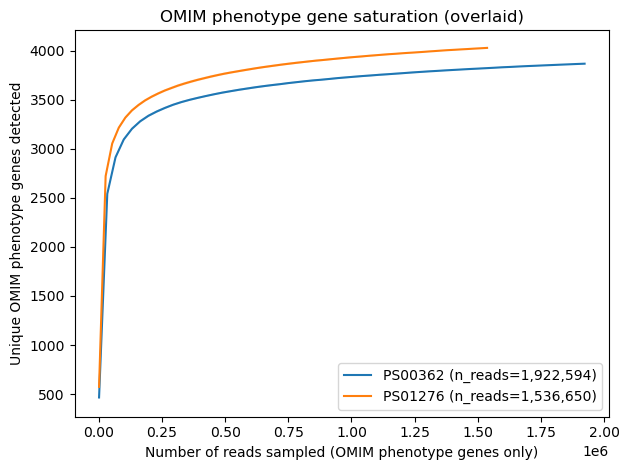

Saved combined plot: OMIMphen_overlap_PS00362_vs_PS01276.png
Saved per-sample TSVs: PS00362_OMIMphen_gene_saturation.tsv, PS01276_OMIMphen_gene_saturation.tsv


In [19]:
# Overlaid saturation curves for OMIM phenotype genes for two samples
# - Sample A: PS00362 (fibroblast)
# - Sample B: PS01276 (whole blood)
#
# Produces one figure with both curves overlaid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Shared inputs
# =========================
genemap2_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/2.3.26_rank_omim_only_no_fusion/genemap2.txt"

# Remove only first 3 metadata lines, keep header
gm = pd.read_csv(genemap2_path, sep="\t", skiprows=3, header=0, dtype=str)
gm.columns = [c.lstrip("#").strip() for c in gm.columns]

gm["Approved Gene Symbol"] = gm["Approved Gene Symbol"].fillna("").str.strip()
gm["Phenotypes"] = gm["Phenotypes"].fillna("").str.strip()

has_pheno = (gm["Phenotypes"] != "") & (gm["Phenotypes"] != "-")
omim_pheno_genes = set(gm.loc[has_pheno, "Approved Gene Symbol"]) - {""}
print(f"OMIM phenotype genes: {len(omim_pheno_genes):,}")

# =========================
# Parameters (shared)
# =========================
reps = 50
n_points = 60
min_reads = 1000
seed = 1

save_outputs = True
out_prefix = "OMIMphen_overlap_PS00362_vs_PS01276"

# =========================
# Sample definitions (EDIT labels/paths as needed)
# =========================
samples = [
    dict(
        label="PS00362",
        read_stat="/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results_PS00362/collapse/collapsed.read_stat.txt",
        classification="/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results_PS00362/pigeon/pigeon_classification.txt",
    ),
    dict(
        label="PS01276",
        read_stat="/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results_PS01276/collapse/collapsed.read_stat.txt",
        classification="/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results_PS01276/pigeon/pigeon_classification.txt",
    ),
]

# =========================
# Helpers
# =========================
def build_points(n_reads, n_points=60, min_reads=1000):
    if n_reads < min_reads:
        return np.unique(np.linspace(1, n_reads, min(n_reads, n_points)).astype(int))
    pts = np.unique(np.linspace(min_reads, n_reads, n_points).astype(int))
    pts[0] = min_reads
    pts[-1] = n_reads
    return pts

def one_replicate_unique_counts(labels, points, rng):
    n = labels.shape[0]
    perm = rng.permutation(n)
    seen = set()
    counts = np.empty(len(points), dtype=np.int32)

    prev = 0
    for i, k in enumerate(points):
        idx = perm[prev:k]
        seen.update(labels[idx])
        counts[i] = len(seen)
        prev = k
    return counts

def summarize(points, mat):
    mean = mat.mean(axis=0)
    sd = mat.std(axis=0, ddof=1) if mat.shape[0] > 1 else np.zeros(mat.shape[1])
    return pd.DataFrame({"reads": points, "mean": mean, "sd": sd})

def compute_omim_gene_saturation(read_stat_path, classification_path, omim_gene_set,
                                 reps=50, n_points=60, min_reads=1000, seed=1):
    # load read->isoform
    read_stat = pd.read_csv(read_stat_path, sep="\t", usecols=["id", "pbid"])
    read_stat["pbid"] = read_stat["pbid"].astype(str)
    bad_pbid = read_stat["pbid"].isin(["nan", "NA", "NaN", ".", "None", "null", "NULL", ""])
    read_stat = read_stat.loc[~bad_pbid].copy()

    # load isoform->gene
    classification = pd.read_csv(classification_path, sep="\t", usecols=["isoform", "associated_gene"])
    iso2gene = dict(zip(classification["isoform"].astype(str), classification["associated_gene"].astype(str)))

    # map reads -> gene and filter to OMIM phenotype genes
    read_stat["gene"] = read_stat["pbid"].map(iso2gene).fillna("NA")
    rs = read_stat.loc[(read_stat["gene"] != "NA") & (read_stat["gene"].isin(omim_gene_set))].copy()

    if len(rs) == 0:
        raise ValueError(f"No reads after filtering to OMIM phenotype genes for {read_stat_path}")

    # saturation
    points = build_points(len(rs), n_points=n_points, min_reads=min_reads)
    gene_codes, _ = pd.factorize(rs["gene"], sort=False)
    gene_codes = gene_codes.astype(np.int32)

    rng = np.random.default_rng(seed)
    mat = np.empty((reps, len(points)), dtype=np.int32)
    for r in range(reps):
        rrng = np.random.default_rng(rng.integers(0, 2**63 - 1))
        mat[r, :] = one_replicate_unique_counts(gene_codes, points, rrng)

    sat = summarize(points, mat)
    stats = {
        "reads_used": len(rs),
        "unique_genes_observed": rs["gene"].nunique(),
        "total_mapped_reads": len(read_stat),
    }
    return sat, stats

# =========================
# Compute both curves
# =========================
results = []
for s in samples:
    sat, stats = compute_omim_gene_saturation(
        s["read_stat"], s["classification"], omim_pheno_genes,
        reps=reps, n_points=n_points, min_reads=min_reads, seed=seed
    )
    results.append((s["label"], sat, stats))
    print(f"{s['label']}: reads_used={stats['reads_used']:,}, unique_genes_observed={stats['unique_genes_observed']:,}")

    if save_outputs:
        sat.to_csv(f"{s['label']}_OMIMphen_gene_saturation.tsv", sep="\t", index=False)

# =========================
# Overlaid plot (each curve uses its own 'reads' axis)
# =========================
plt.figure()

for label, sat, stats in results:
    plt.plot(sat["reads"], sat["mean"], label=f"{label} (n_reads={stats['reads_used']:,})")
    lower = np.maximum(sat["mean"] - sat["sd"], 0)
    upper = sat["mean"] + sat["sd"]
    plt.fill_between(sat["reads"], lower, upper, alpha=0.2)

plt.xlabel("Number of reads sampled (OMIM phenotype genes only)")
plt.ylabel("Unique OMIM phenotype genes detected")
plt.title("OMIM phenotype gene saturation (overlaid)")
plt.legend()
plt.tight_layout()
plt.show()

if save_outputs:
    plt.figure()
    for label, sat, stats in results:
        plt.plot(sat["reads"], sat["mean"], label=f"{label} (n_reads={stats['reads_used']:,})")
        lower = np.maximum(sat["mean"] - sat["sd"], 0)
        upper = sat["mean"] + sat["sd"]
        plt.fill_between(sat["reads"], lower, upper, alpha=0.2)

    plt.xlabel("Number of reads sampled (OMIM phenotype genes only)")
    plt.ylabel("Unique OMIM phenotype genes detected")
    plt.title("OMIM phenotype gene saturation (overlaid)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}.png", dpi=200)
    plt.close()

    print("Saved combined plot:", f"{out_prefix}.png")
    print("Saved per-sample TSVs: PS00362_OMIMphen_gene_saturation.tsv, PS01276_OMIMphen_gene_saturation.tsv")

# Rank with different percentile thresholds

/tmp/ipykernel_15829/857769620.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/857769620.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/857769620.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/857769620.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/857769620.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")


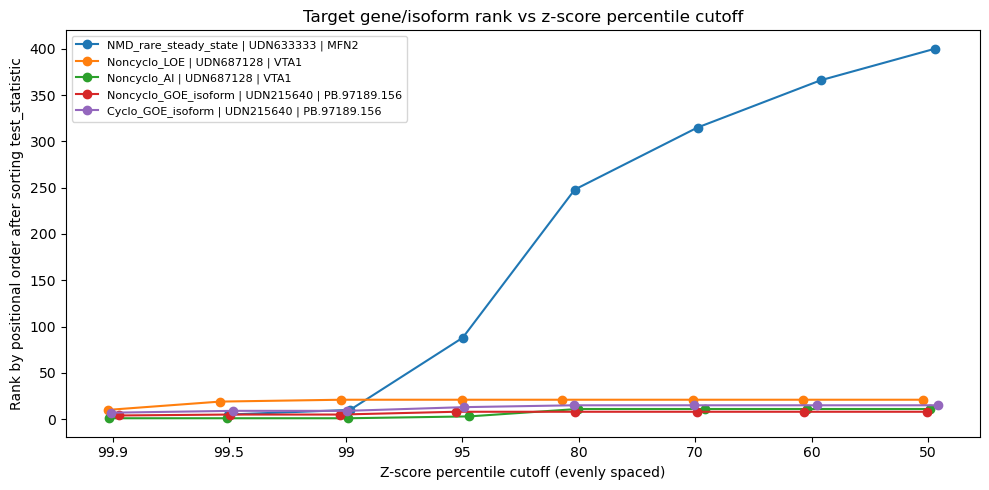

                                              label  \
0          NMD_rare_steady_state | UDN633333 | MFN2   
1          NMD_rare_steady_state | UDN633333 | MFN2   
2          NMD_rare_steady_state | UDN633333 | MFN2   
3          NMD_rare_steady_state | UDN633333 | MFN2   
4          NMD_rare_steady_state | UDN633333 | MFN2   
5          NMD_rare_steady_state | UDN633333 | MFN2   
6          NMD_rare_steady_state | UDN633333 | MFN2   
7          NMD_rare_steady_state | UDN633333 | MFN2   
8                   Noncyclo_LOE | UDN687128 | VTA1   
9                   Noncyclo_LOE | UDN687128 | VTA1   
10                  Noncyclo_LOE | UDN687128 | VTA1   
11                  Noncyclo_LOE | UDN687128 | VTA1   
12                  Noncyclo_LOE | UDN687128 | VTA1   
13                  Noncyclo_LOE | UDN687128 | VTA1   
14                  Noncyclo_LOE | UDN687128 | VTA1   
15                  Noncyclo_LOE | UDN687128 | VTA1   
16                   Noncyclo_AI | UDN687128 | VTA1   
17        

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# settings
# -----------------------
percentiles = [99.9, 99.5, 99, 95, 80, 70, 60, 50]
#percentiles = [99.9, 99.5, 99, 95]

x = np.arange(len(percentiles))  # evenly spaced x positions

# jitter settings (horizontal jitter so lines don't overlap)
rng = np.random.default_rng(0)   # reproducible jitter
jitter_sd = 0.06                

configs = [
    dict(
        label="NMD_rare_steady_state | UDN633333 | MFN2",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_rare_steady_state_transcript_gene_full_ranked_data.tsv",
        sample="UDN633333",
        group_col="associated_gene",
        target="MFN2",
    ),
    dict(
        label="Noncyclo_LOE | UDN687128 | VTA1",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_LOE_gene_full_ranked_data.tsv",
        sample="UDN687128",
        group_col="associated_gene",
        target="VTA1",
    ),
    dict(
        label="Noncyclo_AI | UDN687128 | VTA1",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_Allelic_Imbalance_gene_full_ranked_data.tsv",
        sample="UDN687128",
        group_col="associated_gene",
        target="VTA1",
    ),
    dict(
        label="Noncyclo_GOE_isoform | UDN215640 | PB.97189.156",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_GOE_isoform_full_ranked_data.tsv",
        sample="UDN215640",
        group_col="Isoform",
        target="PB.97189.156",
    ),
    dict(
        label="Cyclo_GOE_isoform | UDN215640 | PB.97189.156",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Cyclo_GOE_isoform_full_ranked_data.tsv",
        sample="UDN215640",
        group_col="Isoform",
        target="PB.97189.156",
    ),
]

# -----------------------
# exact rank logic (matches your function)
# -----------------------
def ranks_for_target_exact(df: pd.DataFrame, sample: str, group_col: str, target: str, percentiles):
    df0 = df[df["z_score_of_test_stat"].notna()].copy()

    sample_df = df0[df0["Sample"] == sample].copy()
    if sample_df.empty:
        raise ValueError(f"No rows found for Sample == {sample}")

    missing = [c for c in ["z_score_of_test_stat", "test_statistic", group_col] if c not in sample_df.columns]
    if missing:
        raise ValueError(f"Missing columns in sample df: {missing}")

    z = sample_df["z_score_of_test_stat"].to_numpy()

    ranks = []
    thresholds = {}
    n_kept = {}

    for p in percentiles:
        percentile_value = float(np.percentile(z, p))
        thresholds[p] = percentile_value

        top_df = sample_df[sample_df["z_score_of_test_stat"] > percentile_value].copy()  # STRICT >
        n_kept[p] = len(top_df)

        sorted_df = top_df.sort_values(by="test_statistic", ascending=False).reset_index(drop=True)
        rank_mapping = {key: rank + 1 for rank, key in enumerate(sorted_df[group_col])}

        ranks.append(float(rank_mapping.get(target, np.nan)))

    return ranks, thresholds, n_kept

# -----------------------
# compute + plot
# -----------------------
plt.figure(figsize=(10, 5))

summary_rows = []

for cfg in configs:
    df = pd.read_csv(cfg["path"], sep="\t")

    ranks, thresholds, n_kept = ranks_for_target_exact(
        df=df,
        sample=cfg["sample"],
        group_col=cfg["group_col"],
        target=cfg["target"],
        percentiles=percentiles,
    )

    # horizontal jitter so lines don’t perfectly overlap
    x_jittered = x + rng.normal(loc=0.0, scale=jitter_sd, size=len(x))

    plt.plot(x_jittered, ranks, marker="o", label=cfg["label"])

    for p, r in zip(percentiles, ranks):
        summary_rows.append(
            dict(
                label=cfg["label"],
                path=cfg["path"],
                sample=cfg["sample"],
                group_col=cfg["group_col"],
                target=cfg["target"],
                percentile=p,
                z_threshold=thresholds[p],
                n_kept=n_kept[p],
                rank=r,
            )
        )

# Keep tick labels on the true (unjittered) x positions
plt.xticks(x, [str(p) for p in percentiles])
plt.xlabel("Z-score percentile cutoff (evenly spaced)")
plt.ylabel("Rank by positional order after sorting test_statistic")
plt.title("Target gene/isoform rank vs z-score percentile cutoff")
plt.legend(loc="best", fontsize=8)

plt.tight_layout()

# save as PDF (vector). bbox_inches makes sure nothing gets cut off.
plt.savefig("rank_vs_percentile.pdf" , format="pdf", bbox_inches="tight")

plt.show()

# -----------------------
# optional: print summary table
# -----------------------
summary_df = pd.DataFrame(summary_rows)
with pd.option_context("display.max_rows", 500, "display.max_columns", 200):
    print(summary_df)


/tmp/ipykernel_15829/3054006492.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/3054006492.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/3054006492.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/3054006492.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")
/tmp/ipykernel_15829/3054006492.py:98: DtypeWarning: Columns (0: Phenotypes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cfg["path"], sep="\t")


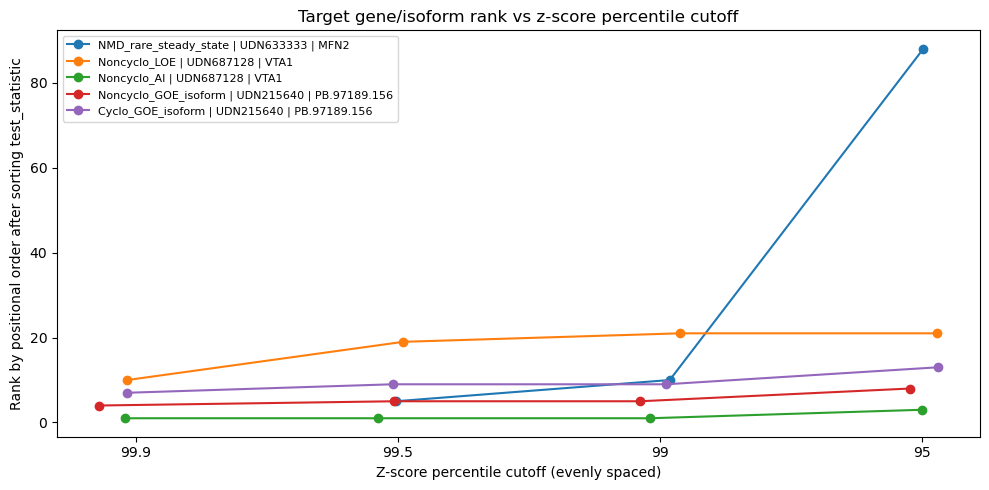

                                              label  \
0          NMD_rare_steady_state | UDN633333 | MFN2   
1          NMD_rare_steady_state | UDN633333 | MFN2   
2          NMD_rare_steady_state | UDN633333 | MFN2   
3          NMD_rare_steady_state | UDN633333 | MFN2   
4                   Noncyclo_LOE | UDN687128 | VTA1   
5                   Noncyclo_LOE | UDN687128 | VTA1   
6                   Noncyclo_LOE | UDN687128 | VTA1   
7                   Noncyclo_LOE | UDN687128 | VTA1   
8                    Noncyclo_AI | UDN687128 | VTA1   
9                    Noncyclo_AI | UDN687128 | VTA1   
10                   Noncyclo_AI | UDN687128 | VTA1   
11                   Noncyclo_AI | UDN687128 | VTA1   
12  Noncyclo_GOE_isoform | UDN215640 | PB.97189.156   
13  Noncyclo_GOE_isoform | UDN215640 | PB.97189.156   
14  Noncyclo_GOE_isoform | UDN215640 | PB.97189.156   
15  Noncyclo_GOE_isoform | UDN215640 | PB.97189.156   
16     Cyclo_GOE_isoform | UDN215640 | PB.97189.156   
17     Cyc

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# settings
# -----------------------
# percentiles = [99.9, 99.5, 99, 95, 80, 70, 60, 50]
percentiles = [99.9, 99.5, 99, 95]

x = np.arange(len(percentiles))  # evenly spaced x positions

# jitter settings (horizontal jitter so lines don't overlap)
rng = np.random.default_rng(0)   # reproducible
jitter_sd = 0.06                 # tweak (0.03–0.10 is typical)

configs = [
    dict(
        label="NMD_rare_steady_state | UDN633333 | MFN2",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/NMD_rare_steady_state_transcript_gene_full_ranked_data.tsv",
        sample="UDN633333",
        group_col="associated_gene",
        target="MFN2",
    ),
    dict(
        label="Noncyclo_LOE | UDN687128 | VTA1",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_LOE_gene_full_ranked_data.tsv",
        sample="UDN687128",
        group_col="associated_gene",
        target="VTA1",
    ),
    dict(
        label="Noncyclo_AI | UDN687128 | VTA1",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_Allelic_Imbalance_gene_full_ranked_data.tsv",
        sample="UDN687128",
        group_col="associated_gene",
        target="VTA1",
    ),
    dict(
        label="Noncyclo_GOE_isoform | UDN215640 | PB.97189.156",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Noncyclo_GOE_isoform_full_ranked_data.tsv",
        sample="UDN215640",
        group_col="Isoform",
        target="PB.97189.156",
    ),
    dict(
        label="Cyclo_GOE_isoform | UDN215640 | PB.97189.156",
        path="/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output_Unzipped/Output/intermediate/Cyclo_GOE_isoform_full_ranked_data.tsv",
        sample="UDN215640",
        group_col="Isoform",
        target="PB.97189.156",
    ),
]

# -----------------------
# exact rank logic (matches your function)
# -----------------------
def ranks_for_target_exact(df: pd.DataFrame, sample: str, group_col: str, target: str, percentiles):
    df0 = df[df["z_score_of_test_stat"].notna()].copy()

    sample_df = df0[df0["Sample"] == sample].copy()
    if sample_df.empty:
        raise ValueError(f"No rows found for Sample == {sample}")

    missing = [c for c in ["z_score_of_test_stat", "test_statistic", group_col] if c not in sample_df.columns]
    if missing:
        raise ValueError(f"Missing columns in sample df: {missing}")

    z = sample_df["z_score_of_test_stat"].to_numpy()

    ranks = []
    thresholds = {}
    n_kept = {}

    for p in percentiles:
        percentile_value = float(np.percentile(z, p))
        thresholds[p] = percentile_value

        top_df = sample_df[sample_df["z_score_of_test_stat"] > percentile_value].copy()  # STRICT >
        n_kept[p] = len(top_df)

        sorted_df = top_df.sort_values(by="test_statistic", ascending=False).reset_index(drop=True)
        rank_mapping = {key: rank + 1 for rank, key in enumerate(sorted_df[group_col])}

        ranks.append(float(rank_mapping.get(target, np.nan)))

    return ranks, thresholds, n_kept

# -----------------------
# compute + plot
# -----------------------
plt.figure(figsize=(10, 5))

summary_rows = []

for cfg in configs:
    df = pd.read_csv(cfg["path"], sep="\t")

    ranks, thresholds, n_kept = ranks_for_target_exact(
        df=df,
        sample=cfg["sample"],
        group_col=cfg["group_col"],
        target=cfg["target"],
        percentiles=percentiles,
    )

    # horizontal jitter so lines don’t perfectly overlap
    x_jittered = x + rng.normal(loc=0.0, scale=jitter_sd, size=len(x))

    plt.plot(x_jittered, ranks, marker="o", label=cfg["label"])

    for p, r in zip(percentiles, ranks):
        summary_rows.append(
            dict(
                label=cfg["label"],
                path=cfg["path"],
                sample=cfg["sample"],
                group_col=cfg["group_col"],
                target=cfg["target"],
                percentile=p,
                z_threshold=thresholds[p],
                n_kept=n_kept[p],
                rank=r,
            )
        )

# Keep tick labels on the true (unjittered) x positions
plt.xticks(x, [str(p) for p in percentiles])
plt.xlabel("Z-score percentile cutoff (evenly spaced)")
plt.ylabel("Rank by positional order after sorting test_statistic")
plt.title("Target gene/isoform rank vs z-score percentile cutoff")
plt.legend(loc="best", fontsize=8)

plt.tight_layout()

# save as PDF (vector). bbox_inches makes sure nothing gets cut off.
plt.savefig("rank_vs_percentile_zoomed.pdf" , format="pdf", bbox_inches="tight")

plt.show()

# -----------------------
# optional: print summary table
# -----------------------
summary_df = pd.DataFrame(summary_rows)
with pd.option_context("display.max_rows", 500, "display.max_columns", 200):
    print(summary_df)


# Looking for variants near NEFL FIRE in UDN359892

##### I want to look at +/- 100kb of the NEFL enhancer at chr8:24,957,366-24,957,585 for rare variants in the UDN359892 sample and then annotate the variants to see which ones might be deleterious (based on CADD and SpliceAI and AlphaGenome). Based on this analysis, chr8:24956773:G>C was picked out as a variant with some large quantiles for couple of the AlphaGenome modality scores. Looking at it in IGV, it looks close to the promoter of NEFL.

In [8]:
!pip install /mmfs1/gscratch/stergachislab/yhhc/tools/AlphaGenome/alphagenome

Processing /mmfs1/gscratch/stergachislab/yhhc/tools/AlphaGenome/alphagenome
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached grpcio-1.80.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.8 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached donfig-0.8.1.post1-py3-none-any.whl.metadata (5.0 kB)
Using cached grpcio-1.80.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (6.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.2 MB/s  0:00:026m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 38.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 5.1 MB/s  0:00:066m0:00:0100:01
Using cached donfig-0.8.1.post1-py3-none-any.whl (21 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 905.6 kB/s  0:00:090:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 568.4 kB/s  0:0

In [ ]:

import os
import pickle
from typing import Any, List

import numpy as np
import pandas as pd
from tqdm import tqdm

from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers

os.environ["ALPHAGENOME_API_KEY"] = ""


In [6]:
# =========================================================
# Make AlphaGenome input TSV from VEP annotated VCF (with SpliceAI and CADD)
#
# Keeps:
#   - non-reference variants in the sample
#   - variants with MAX_AF < 0.01 (or missing MAX_AF)
#   - variants within the specified window around the NEFL tss
#
# Output that can be used later for adding AlphaGenome annotation:
#   UDN359892_NEFL_alphagenome_input.tsv
# =========================================================

import os
from typing import List, Tuple, Dict, Optional
import pandas as pd
import pysam


# =========================================================
# CONFIG
# =========================================================

vcf_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/bgzip_vcfs/UDN359892_mod.annotated.bgz.vcf.gz"
gtf_path = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"
sample_name = "UnnamedSample"
target_gene = "NEFL"
output_dir = "UDN359892_NEFL_alphagenome_input"
os.makedirs(output_dir, exist_ok=True)

max_af_cutoff = 0.01
qual_min = 30

region_flank_bp = 100_000 

# =========================================================
# HELPERS
# =========================================================

def normalize_chrom(chrom: str) -> str:
    chrom = str(chrom)
    return chrom if chrom.startswith("chr") else f"chr{chrom}"


def safe_float(x, default=0.0) -> float:
    try:
        if x in (None, "", "."):
            return default
        return float(x)
    except Exception:
        return default


def variant_key(chrom: str, pos: int, ref: str, alt: str) -> str:
    return f"{normalize_chrom(chrom)}_{int(pos)}_{ref}_{alt}"


def parse_gtf_gene_tss(gtf_path: str, gene_name: str) -> Tuple[str, int, str]:
    """
    Return (chrom, tss, strand) for the requested gene from gene features in the GTF.
    TSS = gene start on '+' strand, gene end on '-' strand.
    """
    with open(gtf_path, "r") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9:
                continue

            chrom, _, feature, start, end, _, strand, _, attrs = fields
            if feature != "gene":
                continue
            if 'gene_name "' not in attrs:
                continue

            this_gene = attrs.split('gene_name "')[1].split('"')[0]
            if this_gene != gene_name:
                continue

            start = int(start)
            end = int(end)
            tss = start if strand == "+" else end
            return normalize_chrom(chrom), tss, strand

    raise ValueError(f"Gene {gene_name} not found in GTF: {gtf_path}")


def parse_csq_fields(vcf: pysam.VariantFile) -> List[str]:
    desc = vcf.header.info["CSQ"].description
    if "Format: " in desc:
        return desc.split("Format: ")[1].strip().split("|")
    if ": " in desc:
        return desc.split(": ")[1].strip().split("|")
    raise ValueError("Could not parse CSQ format from VCF header.")


def get_sample_gt(record, sample_name: str) -> str:
    sample = record.samples[sample_name]
    gt = sample.get("GT")
    if gt is None:
        return "NA"
    phased = getattr(sample, "phased", False)
    sep = "|" if phased else "/"
    return sep.join("." if a is None else str(a) for a in gt)


def sample_has_alt(record, sample_name: str) -> bool:
    gt = record.samples[sample_name].get("GT")
    if gt is None:
        return False
    return any((a is not None and a > 0) for a in gt)


def choose_best_csq(
    csq_entries: List[str],
    csq_fields: List[str],
    target_gene: Optional[str] = None
) -> Dict[str, str]:
    """
    Pick one CSQ annotation per record.

    Preference:
      1. target gene match
      2. higher SpliceAI
      3. higher CADD
      4. lower MAX_AF
    """
    best = None
    best_key = None

    splice_cols = [
        "SpliceAI_pred_DS_AG",
        "SpliceAI_pred_DS_AL",
        "SpliceAI_pred_DS_DG",
        "SpliceAI_pred_DS_DL",
    ]

    for entry in csq_entries:
        values = entry.split("|")
        d = dict(zip(csq_fields, values))

        symbol = d.get("SYMBOL", "")
        gene_match = 1 if (target_gene and symbol == target_gene) else 0

        spliceai = max(safe_float(d.get(c, "0"), 0.0) for c in splice_cols)
        cadd = safe_float(d.get("CADD_PHRED", "0"), 0.0)

        max_af_raw = d.get("MAX_AF", "")
        max_af = safe_float(max_af_raw, 0.0 if max_af_raw in ("", ".") else 1.0)

        key = (gene_match, spliceai, cadd, -max_af)
        if best is None or key > best_key:
            best = d
            best_key = key

    return best if best is not None else {}


def record_passes_rare_filter(record, csq_fields: List[str], max_af_cutoff: float = 0.01) -> bool:
    """
    Keep if any CSQ annotation has MAX_AF < cutoff or MAX_AF missing.
    """
    if "CSQ" not in record.info:
        return False

    for entry in record.info["CSQ"]:
        values = entry.split("|")
        d = dict(zip(csq_fields, values))
        af = d.get("MAX_AF", "")

        if af in ("", "."):
            return True

        try:
            if float(af) < max_af_cutoff:
                return True
        except ValueError:
            continue

    return False


def extract_region_variants(
    vcf_path: str,
    sample_name: str,
    chrom: str,
    start_1based: int,
    end_1based: int,
    target_gene: Optional[str] = None,
    qual_min: float = 30,
    max_af_cutoff: float = 0.01,
) -> pd.DataFrame:
    """
    Extract rare non-reference variants from the requested region.
    """
    vcf = pysam.VariantFile(vcf_path)

    if sample_name not in list(vcf.header.samples):
        raise ValueError(f"Sample {sample_name} not found in VCF samples: {list(vcf.header.samples)}")

    csq_fields = parse_csq_fields(vcf)
    rows = []

    fetch_start = max(0, start_1based - 1)
    fetch_end = end_1based

    for record in vcf.fetch(chrom, fetch_start, fetch_end):
        if record.qual is None or record.qual < qual_min:
            continue
        if not sample_has_alt(record, sample_name):
            continue
        if not record_passes_rare_filter(record, csq_fields, max_af_cutoff=max_af_cutoff):
            continue

        alts = list(record.alts) if record.alts else []
        if len(alts) == 0:
            continue

        alt = str(alts[0])

        best = choose_best_csq(
            list(record.info.get("CSQ", [])),
            csq_fields,
            target_gene=target_gene,
        )

        rows.append({
            "variant_id": f"{normalize_chrom(record.chrom)}_{record.pos}_{record.ref}_{alt}",
            "CHROM": normalize_chrom(record.chrom),
            "POS": int(record.pos),
            "REF": str(record.ref),
            "ALT": alt,
            "variant_key": variant_key(record.chrom, record.pos, record.ref, alt),
            "sample": sample_name,
            "SYMBOL": best.get("SYMBOL", ""),
            "MAX_AF": best.get("MAX_AF", ""),
            "GT": get_sample_gt(record, sample_name),
            "QUAL": record.qual,
            "Consequence": best.get("Consequence", ""),
            "CADD_PHRED": safe_float(best.get("CADD_PHRED", "0"), 0.0),
            "SpliceAI_pred_DS_AG": safe_float(best.get("SpliceAI_pred_DS_AG", "0"), 0.0),
            "SpliceAI_pred_DS_AL": safe_float(best.get("SpliceAI_pred_DS_AL", "0"), 0.0),
            "SpliceAI_pred_DS_DG": safe_float(best.get("SpliceAI_pred_DS_DG", "0"), 0.0),
            "SpliceAI_pred_DS_DL": safe_float(best.get("SpliceAI_pred_DS_DL", "0"), 0.0),
            "HGVSc": best.get("HGVSc", ""),
        })

    return pd.DataFrame(rows)


# =========================================================
# RUN
# =========================================================

# 1) get TSS
gene_chrom, gene_tss, gene_strand = parse_gtf_gene_tss(gtf_path, target_gene)
region_start = max(1, gene_tss - region_flank_bp)
region_end = gene_tss + region_flank_bp

print(f"{target_gene} TSS: {gene_chrom}:{gene_tss} ({gene_strand})")
print(f"Region used: {gene_chrom}:{region_start}-{region_end}")
print(f"Flank (bp): {region_flank_bp:,}")

# 2) extract variants
variants_df = extract_region_variants(
    vcf_path=vcf_path,
    sample_name=sample_name,
    chrom=gene_chrom,
    start_1based=region_start,
    end_1based=region_end,
    target_gene=target_gene,
    qual_min=qual_min,
    max_af_cutoff=max_af_cutoff,
)

print(f"Extracted {len(variants_df)} variants")

# 3) write AlphaGenome input TSV
input_tsv = os.path.join(output_dir, "UDN359892.NEFL.input.tsv")
variants_df[["variant_id", "CHROM", "POS", "REF", "ALT"]].to_csv(input_tsv, sep="\t", index=False)

# 4) also write richer metadata TSV
metadata_tsv = os.path.join(output_dir, "UDN359892.NEFL.input.metadata.tsv")
variants_df.to_csv(metadata_tsv, sep="\t", index=False)

print(f"Saved AlphaGenome input TSV: {input_tsv}")
print(f"Saved metadata TSV: {metadata_tsv}")

display(variants_df.head())

NEFL TSS: chr8:24956721 (-)
Region used: chr8:24856721-25056721
Flank (bp): 100,000
Extracted 14 variants
Saved AlphaGenome input TSV: UDN359892_NEFL_alphagenome_input/UDN359892.NEFL.input.tsv
Saved metadata TSV: UDN359892_NEFL_alphagenome_input/UDN359892.NEFL.input.metadata.tsv


,variant_id,CHROM,POS,REF,ALT,variant_key,sample,SYMBOL,MAX_AF,GT,QUAL,Consequence,CADD_PHRED,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,HGVSc
0,chr8_24865465_C_G,chr8,24865465,C,G,chr8_24865465_C_G,UnnamedSample,ADAM7-AS1,0.001264,1|0,55.000000,intron_variant&non_coding_transcript_variant,2.145,0.0,0.0,0.0,0.0,ENST00000519689.1:n.184+18537G>C
1,chr8_24876134_C_T,chr8,24876134,C,T,chr8_24876134_C_T,UnnamedSample,ADAM7-AS1,0.0015,1|0,32.299999,intron_variant&non_coding_transcript_variant,3.919,0.0,0.0,0.0,0.0,ENST00000519689.1:n.184+7868G>A
2,chr8_24888653_A_AG,chr8,24888653,A,AG,chr8_24888653_A_AG,UnnamedSample,ADAM7-AS1,0.7324,1/2,51.000000,intron_variant&non_coding_transcript_variant,2.609,0.0,0.0,0.0,0.0,ENST00000519689.1:n.63-4530T>C
3,chr8_24928206_G_T,chr8,24928206,G,T,chr8_24928206_G_T,UnnamedSample,,0.00125,0|1,45.200001,intron_variant&non_coding_transcript_variant,1.797,0.0,0.0,0.0,0.0,ENST00000781717.1:n.106-3500C>A
4,chr8_24929974_A_G,chr8,24929974,A,G,chr8_24929974_A_G,UnnamedSample,,0.001279,0|1,49.799999,intron_variant&non_coding_transcript_variant,1.887,0.0,0.0,0.0,0.0,ENST00000781717.1:n.106-5268T>C


In [24]:
# Use AlphaGenome to Score batch of variants and save df_scores as intermediate output

from io import StringIO
import pandas as pd
from tqdm import tqdm

from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers

#This is from the AlphaGenome example site: https://www.alphagenomedocs.com/colabs/batch_variant_scoring.html
# We provide an example list of variants to illustrate. 
#vcf_file = """variant_id\tCHROM\tPOS\tREF\tALT
#chr3_58394738_A_T_b38\tchr3\t58394738\tA\tT
#chr8_28520_G_C_b38\tchr8\t28520\tG\tC
#chr16_636337_G_A_b38\tchr16\t636337\tG\tA
#chr16_1135446_G_T_b38\tchr16\t1135446\tG\tT
#"""

vcf = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Paper/5.Supplementary/UDN359892_NEFL_alphagenome_input/UDN359892.NEFL.input.tsv", sep='\t')


required_columns = ['variant_id', 'CHROM', 'POS', 'REF', 'ALT']
for column in required_columns:
    if column not in vcf.columns:
        raise ValueError(f'VCF file is missing required column: {column}.')

organism = 'human'  # @param ["human", "mouse"] {type:"string"}

# Specify length of sequence around variants to predict:
sequence_length = '1MB'  # @param ["16KB", "100KB", "500KB", "1MB"] { type:"string" }
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{sequence_length}'
]

# Specify which scorers to use to score your variants:
score_rna_seq = True
score_cage = True
score_procap = True
score_atac = True
score_dnase = True
score_chip_histone = True
score_chip_tf = True
score_polyadenylation = True
score_splice_sites = True
score_splice_site_usage = True
score_splice_junctions = True

# Parse organism specification.
organism_map = {
    'human': dna_client.Organism.HOMO_SAPIENS,
    'mouse': dna_client.Organism.MUS_MUSCULUS,
}
organism = organism_map[organism]

# Parse scorer specification.
scorer_selections = {
    'rna_seq': score_rna_seq,
    'cage': score_cage,
    'procap': score_procap,
    'atac': score_atac,
    'dnase': score_dnase,
    'chip_histone': score_chip_histone,
    'chip_tf': score_chip_tf,
    'polyadenylation': score_polyadenylation,
    'splice_sites': score_splice_sites,
    'splice_site_usage': score_splice_site_usage,
    'splice_junctions': score_splice_junctions,
}

all_scorers = variant_scorers.RECOMMENDED_VARIANT_SCORERS
selected_scorers = [
    all_scorers[key]
    for key in all_scorers
    if scorer_selections.get(key.lower(), False)
]

unsupported_scorers = [
    scorer
    for scorer in selected_scorers
    if (
        organism.value
        not in variant_scorers.SUPPORTED_ORGANISMS[scorer.base_variant_scorer]
    )
    or (
        (scorer.requested_output == dna_client.OutputType.PROCAP)
        and (organism == dna_client.Organism.MUS_MUSCULUS)
    )
]

if len(unsupported_scorers) > 0:
    print(
        f'Excluding {unsupported_scorers} scorers as they are not supported for {organism}.'
    )
    for unsupported_scorer in unsupported_scorers:
        selected_scorers.remove(unsupported_scorer)

# Score variants in the VCF file.
results = []

for i, vcf_row in tqdm(vcf.iterrows(), total=len(vcf)):
    variant = genome.Variant(
        chromosome=str(vcf_row.CHROM),
        position=int(vcf_row.POS),
        reference_bases=vcf_row.REF,
        alternate_bases=vcf_row.ALT,
        name=vcf_row.variant_id,
    )

    interval = variant.reference_interval.resize(sequence_length)

    variant_scores = dna_model.score_variant(
        interval=interval,
        variant=variant,
        variant_scorers=selected_scorers,
        organism=organism,
    )
    results.append(variant_scores)

# Create the raw tidy AlphaGenome dataframe
df_scores = variant_scorers.tidy_scores(results)

# Save df_scores immediately as intermediate files
df_scores.to_csv("UDN359892_NEFL_alphagenome_df_scores_intermediate.tsv", sep="\t", index=False)

print("Saved intermediate files:")
print("UDN359892_NEFL_alphagenome_df_scores_intermediate.tsv")

# Optional: inspect columns
print("\nColumns in df_scores:")
print(df_scores.columns.tolist())

df_scores.head()

##########

# Create the raw tidy AlphaGenome dataframe
df_scores = variant_scorers.tidy_scores(results)

# Fix: ensure variant_id is hashable
df_scores["variant_id"] = df_scores["variant_id"].astype(str)

# Keep only one row per (variant_id, output_type)
df_scores_filtered = (
    df_scores.sort_values(
        by=["variant_id", "output_type", "quantile_score"],
        ascending=[True, True, False]
    )
    .drop_duplicates(subset=["variant_id", "output_type"], keep="first")
    .reset_index(drop=True)
)

# Save outputs
df_scores.to_csv("UDN359892_NEFL_alphagenome_df_scores_intermediate.tsv", sep="\t", index=False)
df_scores_filtered.to_csv("UDN359892_NEFL_alphagenome_df_scores_collapsed_intermediate.tsv", sep="\t", index=False)

print("Saved:")
print("  alphagenome_df_scores_intermediate.tsv")
print("  alphagenome_df_scores_filtered.tsv")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:18<00:00,  1.29s/it]


Saved intermediate files:
UDN359892_NEFL_alphagenome_df_scores_intermediate.tsv

Columns in df_scores:
['variant_id', 'scored_interval', 'gene_id', 'gene_name', 'gene_type', 'gene_strand', 'junction_Start', 'junction_End', 'output_type', 'variant_scorer', 'track_name', 'track_strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'data_source', 'endedness', 'genetically_modified', 'transcription_factor', 'histone_mark', 'gtex_tissue', 'raw_score', 'quantile_score']
Saved:
  alphagenome_df_scores_intermediate.tsv
  alphagenome_df_scores_filtered.tsv


# AlphaGenome visualizations for predict variant

## NEFL Predict variant


Variant:
chr8:24956773:G>C

Prediction interval:
chr8:24432485-25481061:.

Plot interval:
chr8:24952773-24960773:.

Neuron/fibroblast-related ontology terms found:
['CL:0002551', 'EFO:0002009']
Total found: 2


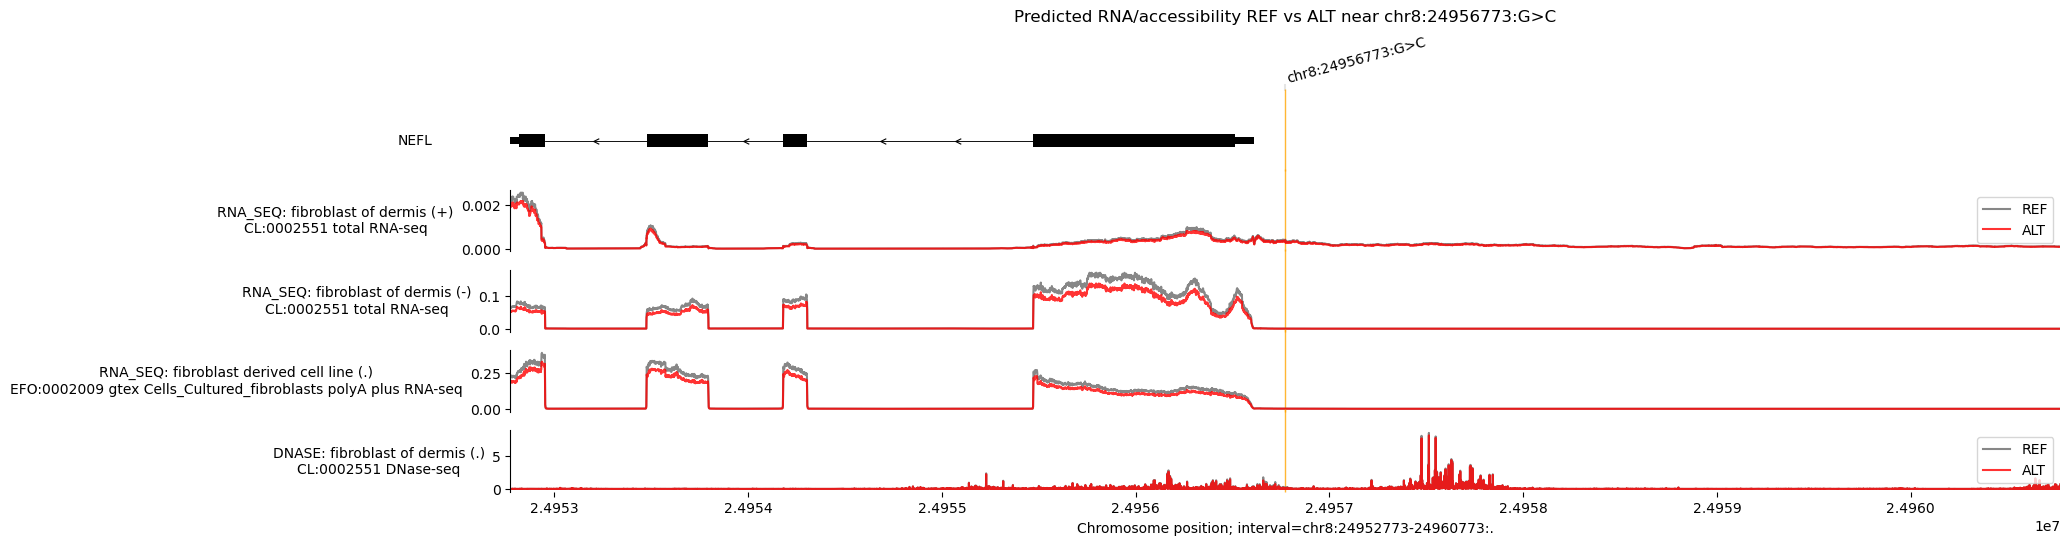

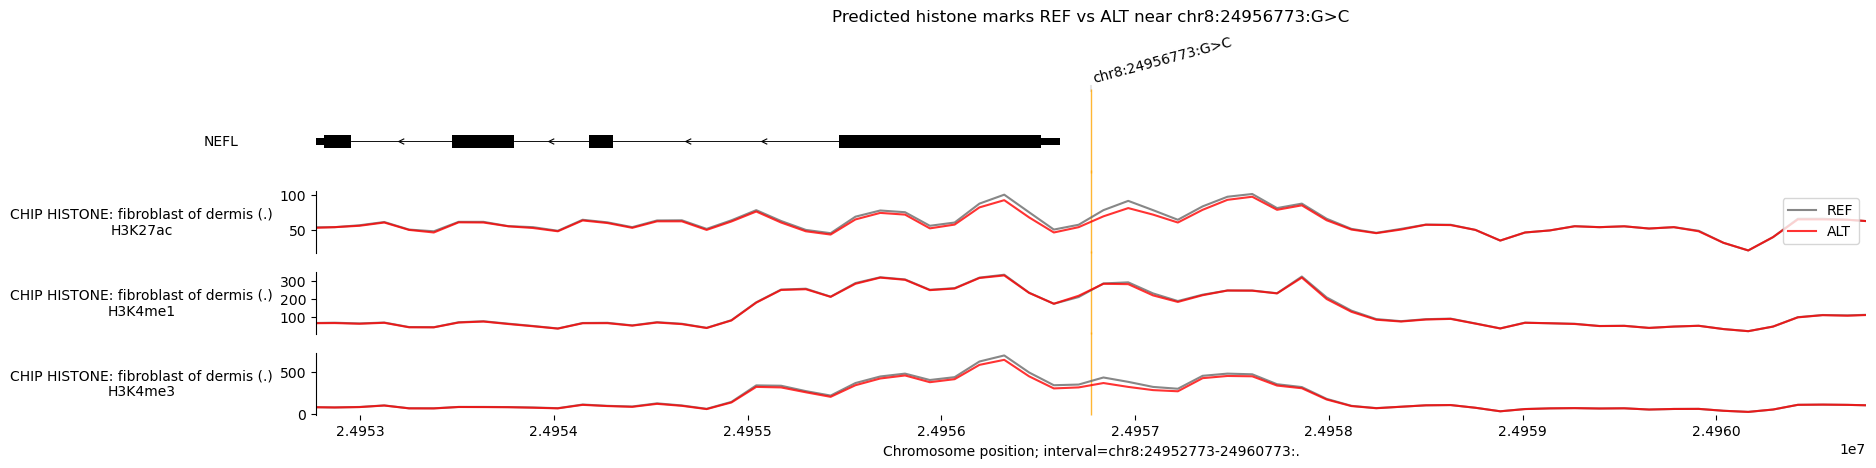

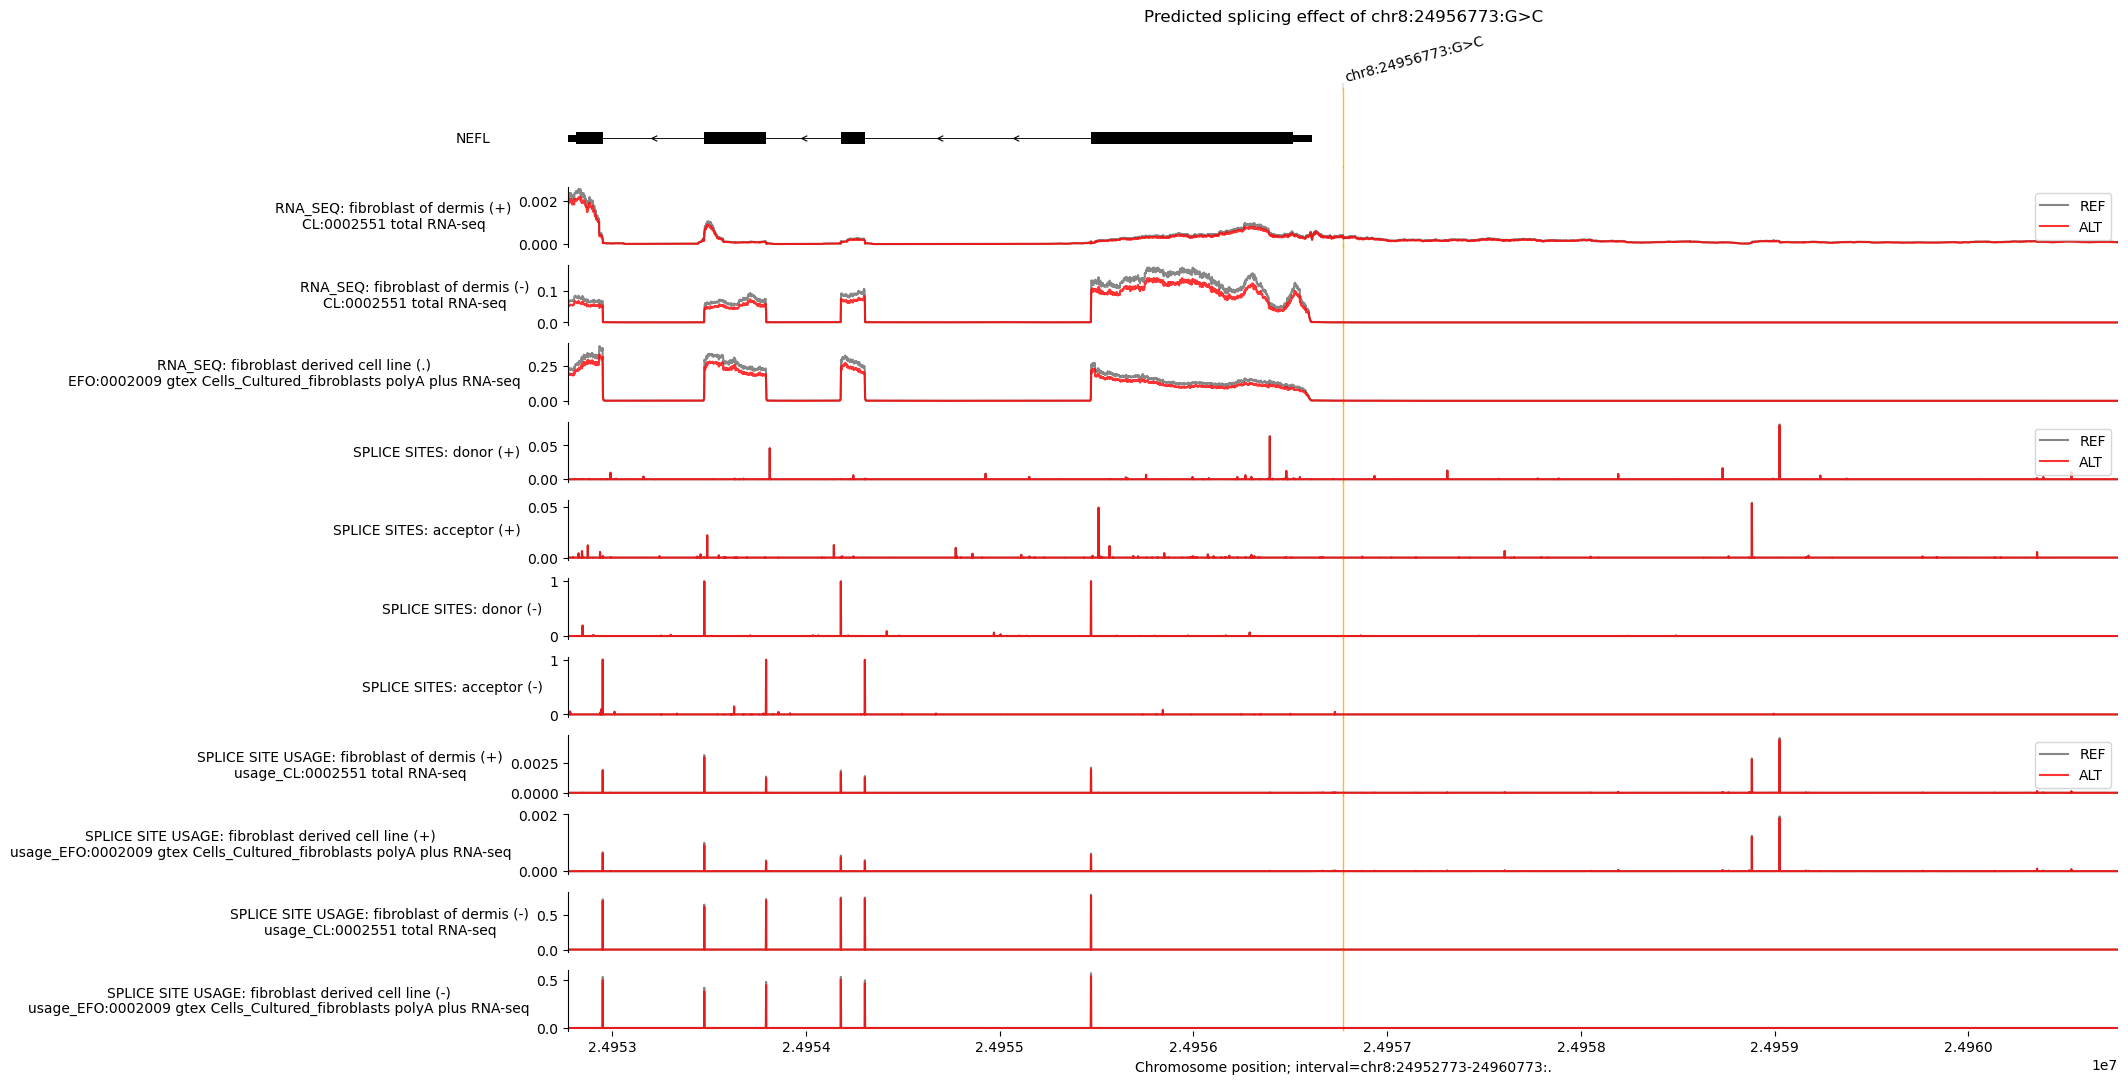

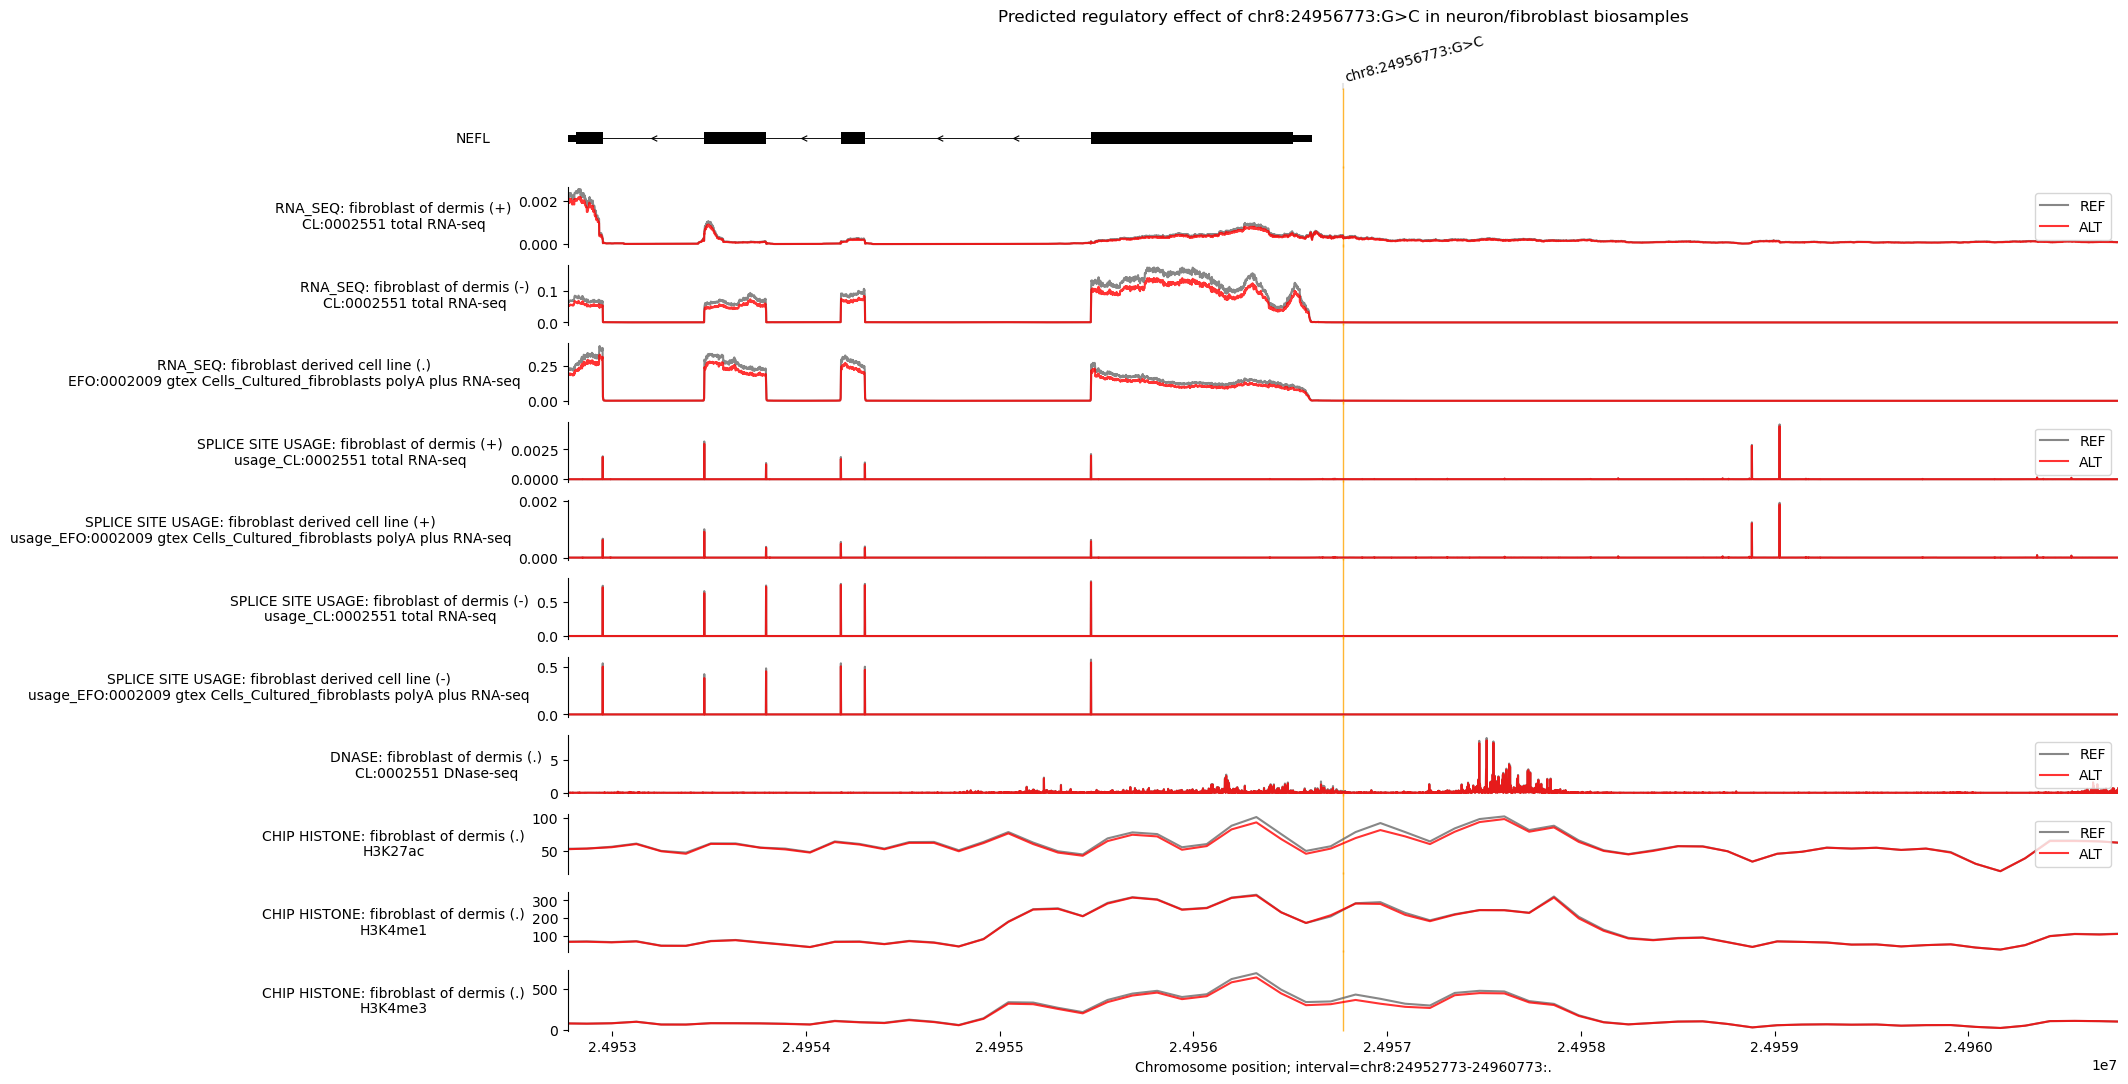


Saved outputs to: alphagenome_Fibroblast_variant_NEFL_chr8_24956773_G_C_plots_

REF RNA_SEQ metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
1,CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
2,EFO:0002009 gtex Cells_Cultured_fibroblasts po...,.,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,paired,False,0.056562



REF DNASE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 DNase-seq,.,DNase-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,encode,single,False,1.079167



REF ATAC metadata:


...

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K27ac,encode,single,False,1.049457
2,CL:0002551 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K4me1,encode,single,False,1.037979
4,CL:0002551 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,"adult,unknown",H3K4me3,encode,single,False,0.947388



REF SPLICE_SITE_USAGE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
1,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,+,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex
2,usage_CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
3,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,-,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex



REF SPLICE_JUNCTIONS metadata:


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0002551 total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,total RNA-seq
1,junction_EFO:0002009 gtex Cells_Cultured_fibro...,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,polyA plus RNA-seq


In [8]:
# PLot fibroblasts here

# ============================================================
# AlphaGenome variant visualization for chr8:24956773:G>C
# ============================================================

# Optional install
# !pip install alphagenome pyarrow pandas matplotlib

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import gene_annotation, genome, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

# ============================================================
# 1. USER SETTINGS
# ============================================================

# ---- API key ----
# put your key here directly
API_KEY = ""

# ---- Your GENCODE path ----
# Can be .feather or .gtf / .gtf.gz
GENCODE_PATH = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# ---- Variant of interest ----
VARIANT_STRING = "chr8:24956773:G>C"

# ---- Prediction interval width ----
PREDICTION_INTERVAL = dna_client.SEQUENCE_LENGTH_1MB

# ---- Plot zoom width around the variant ----
PLOT_WIDTH_BP = 8000

# ---- Optional enhancer annotation ----
ENHANCER_INTERVALS = [
    # genome.Interval("chr8", 24956000, 24957200, name="Nearby_enhancer")
]

# ---- Search words for neuron + fibroblast biosamples ----
# CELLTYPE_KEYWORDS = [
#     # Neuron-related
#     "neuron",
#     "neuronal",
#     "brain",
#     "cortex",
#     "cortical",
#     "cerebell",
#     "spinal",
#     "hippoc",
#     "motor neuron",
#     "neural",
# ]

CELLTYPE_KEYWORDS = {
    "fibroblast derived cell line",
    "fibroblast of dermis",
}

# ---- Histone marks to keep ----
HISTONE_KEEP = ["H3K27ac", "H3K4me1", "H3K4me3"]

# ---- Save figures? ----
SAVE_FIGURES = True
OUTDIR = "alphagenome_Fibroblast_variant_NEFL_chr8_24956773_G_C_plots_"

# ============================================================
# 2. CREATE MODEL
# ============================================================

dna_model = dna_client.create(API_KEY)

output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

# # ============================================================
# # 3. LOAD YOUR GENCODE FILE
# # ============================================================

# def parse_gtf_attributes(attr_string):
#     out = {}
#     if pd.isna(attr_string):
#         return out
#     matches = re.findall(r'(\S+)\s+"([^"]+)"', attr_string)
#     for key, val in matches:
#         out[key] = val
#     return out


# def load_gencode(path):
#     if path.endswith(".feather"):
#         return pd.read_feather(path)

#     gtf = pd.read_csv(
#         path,
#         sep="\t",
#         comment="#",
#         header=None,
#         compression="infer"
#     )

#     if gtf.shape[1] != 9:
#         raise ValueError(f"Expected 9 GTF columns, found {gtf.shape[1]}.")

#     gtf.columns = [
#         "Chromosome", "Source", "Feature", "Start", "End",
#         "Score", "Strand", "Frame", "Attributes"
#     ]

#     parsed = gtf["Attributes"].apply(parse_gtf_attributes).apply(pd.Series)
#     gtf = pd.concat([gtf, parsed], axis=1)

#     gtf["Chromosome"] = gtf["Chromosome"].astype(str)
#     gtf["Chromosome"] = gtf["Chromosome"].apply(
#         lambda x: x if x.startswith("chr") else f"chr{x}"
#     )

#     gtf["Start"] = pd.to_numeric(gtf["Start"], errors="coerce")
#     gtf["End"] = pd.to_numeric(gtf["End"], errors="coerce")

#     if "gene_type" not in gtf.columns and "gene_biotype" in gtf.columns:
#         gtf["gene_type"] = gtf["gene_biotype"]

#     if "transcript_type" not in gtf.columns and "transcript_biotype" in gtf.columns:
#         gtf["transcript_type"] = gtf["transcript_biotype"]

#     return gtf


# gtf = load_gencode(GENCODE_PATH)

# gtf_transcript = gene_annotation.filter_transcript_support_level(
#     gene_annotation.filter_protein_coding(gtf), ['1']
# )

# transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
#     gtf_transcript
# )

# longest_transcript_extractor = transcript.TranscriptExtractor(
#     gtf_longest_transcript
# )

# print("Loaded GENCODE.")
# print(f"Rows: {len(gtf):,}")

# ============================================================
# 4. DEFINE VARIANT AND INTERVAL
# ============================================================

variant = genome.Variant.from_str(VARIANT_STRING)
print("\nVariant:")
print(variant)

interval = variant.reference_interval.resize(PREDICTION_INTERVAL)
plot_interval = variant.reference_interval.resize(PLOT_WIDTH_BP)

print("\nPrediction interval:")
print(interval)

print("\nPlot interval:")
print(plot_interval)

# Longest transcripts for cleaner annotation
longest_transcripts = longest_transcript_extractor.extract(interval)

# Full transcripts are useful for splicing plots
all_transcripts = transcript_extractor.extract(interval)

# ============================================================
# 5. FIND MATCHING ONTOLOGY TERMS
# ============================================================

def find_matching_ontology_terms(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return []

    cols_to_search = []
    for c in ["biosample_name", "biosample_type", "ontology_curie", "name", "Assay title"]:
        if c in metadata_df.columns:
            cols_to_search.append(c)

    if len(cols_to_search) == 0:
        return []

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)

    matches = metadata_df.loc[mask].copy()

    if "ontology_curie" not in matches.columns:
        return []

    return sorted(matches["ontology_curie"].dropna().astype(str).unique().tolist())


dnase_terms = find_matching_ontology_terms(output_metadata.dnase, CELLTYPE_KEYWORDS)
atac_terms = find_matching_ontology_terms(output_metadata.atac, CELLTYPE_KEYWORDS)
chip_histone_terms = find_matching_ontology_terms(output_metadata.chip_histone, CELLTYPE_KEYWORDS)
rna_seq_terms = find_matching_ontology_terms(output_metadata.rna_seq, CELLTYPE_KEYWORDS)
splice_usage_terms = find_matching_ontology_terms(output_metadata.splice_site_usage, CELLTYPE_KEYWORDS)
splice_junction_terms = find_matching_ontology_terms(output_metadata.splice_junctions, CELLTYPE_KEYWORDS)

all_terms = sorted(
    set(dnase_terms)
    | set(atac_terms)
    | set(chip_histone_terms)
    | set(rna_seq_terms)
    | set(splice_usage_terms)
    | set(splice_junction_terms)
)

print("\nNeuron/fibroblast-related ontology terms found:")
print(all_terms[:100])
print(f"Total found: {len(all_terms)}")

if len(all_terms) == 0:
    print("\nWarning: no matching ontology terms were found.")

# ============================================================
# 6. RUN PREDICT_VARIANT
# ============================================================

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=all_terms if len(all_terms) > 0 else None,
)

ref_alt_colors = {"REF": "dimgrey", "ALT": "red"}

# ============================================================
# 7. FILTER TRACKS TO MATCHING BIOSAMPLES
# ============================================================

def metadata_keyword_mask(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.Series([], dtype=bool)

    cols_to_search = [
        c for c in ["biosample_name", "biosample_type", "ontology_curie", "name"]
        if c in metadata_df.columns
    ]
    if len(cols_to_search) == 0:
        return pd.Series([True] * len(metadata_df), index=metadata_df.index)

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)
    return mask


def filter_trackdata_by_keywords(tdata, keywords):
    if tdata is None:
        return tdata
    md = tdata.metadata
    if md is None or len(md) == 0:
        return tdata
    mask = metadata_keyword_mask(md, keywords)
    if len(mask) == 0 or mask.sum() == 0:
        return tdata
    return tdata.filter_tracks(mask.values)


ref_dnase = filter_trackdata_by_keywords(output.reference.dnase, CELLTYPE_KEYWORDS)
alt_dnase = filter_trackdata_by_keywords(output.alternate.dnase, CELLTYPE_KEYWORDS)

ref_atac = filter_trackdata_by_keywords(output.reference.atac, CELLTYPE_KEYWORDS)
alt_atac = filter_trackdata_by_keywords(output.alternate.atac, CELLTYPE_KEYWORDS)

ref_rna_seq = filter_trackdata_by_keywords(output.reference.rna_seq, CELLTYPE_KEYWORDS)
alt_rna_seq = filter_trackdata_by_keywords(output.alternate.rna_seq, CELLTYPE_KEYWORDS)

ref_splice_usage = filter_trackdata_by_keywords(output.reference.splice_site_usage, CELLTYPE_KEYWORDS)
alt_splice_usage = filter_trackdata_by_keywords(output.alternate.splice_site_usage, CELLTYPE_KEYWORDS)

ref_splice_junctions = filter_trackdata_by_keywords(output.reference.splice_junctions, CELLTYPE_KEYWORDS)
alt_splice_junctions = filter_trackdata_by_keywords(output.alternate.splice_junctions, CELLTYPE_KEYWORDS)

# splice_sites is tissue-agnostic, so use directly
ref_splice_sites = output.reference.splice_sites
alt_splice_sites = output.alternate.splice_sites

ref_chip_histone = filter_trackdata_by_keywords(output.reference.chip_histone, CELLTYPE_KEYWORDS)
alt_chip_histone = filter_trackdata_by_keywords(output.alternate.chip_histone, CELLTYPE_KEYWORDS)

# Keep only selected histone marks
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_chip_histone = ref_chip_histone.filter_tracks(
        ref_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_chip_histone = alt_chip_histone.filter_tracks(
        alt_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

# Safe reordering using positional indices
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_order = (
        ref_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    ref_chip_histone = ref_chip_histone.select_tracks_by_index(ref_order)

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_order = (
        alt_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    alt_chip_histone = alt_chip_histone.select_tracks_by_index(alt_order)

# ============================================================
# 8. BUILD ANNOTATIONS
# ============================================================

annotations = [plot_components.VariantAnnotation([variant])]

if len(ENHANCER_INTERVALS) > 0:
    annotations.append(plot_components.IntervalAnnotation(ENHANCER_INTERVALS))

# ============================================================
# 9. PLOT RNA + ACCESSIBILITY
# ============================================================

plot1 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted RNA/accessibility REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 10. PLOT CHIP_HISTONE
# ============================================================

plot2 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted histone marks REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 11. PLOT SPLICING
# ============================================================

plot3 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(all_transcripts),

        plot_components.Sashimi(
            ref_splice_junctions,
            ylabel_template="REF junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.Sashimi(
            alt_splice_junctions,
            ylabel_template="ALT junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_sites,
                "ALT": alt_splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITES: {name} ({strand})",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted splicing effect of {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 12. OPTIONAL COMBINED PLOT
# ============================================================

plot4 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),


        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted regulatory effect of {VARIANT_STRING} in neuron/fibroblast biosamples",
)

plt.show()

# ============================================================
# 13. OPTIONAL SAVE
# ============================================================

if SAVE_FIGURES:
    os.makedirs(OUTDIR, exist_ok=True)

    plot1.savefig(os.path.join(OUTDIR, "rna_dnase_atac_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot2.savefig(os.path.join(OUTDIR, "chip_histone_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot3.savefig(os.path.join(OUTDIR, "splicing_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot4.savefig(os.path.join(OUTDIR, "combined_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")

    if ref_rna_seq is not None:
        ref_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "ref_rna_seq_metadata.tsv"), sep="\t", index=False)
    if alt_rna_seq is not None:
        alt_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "alt_rna_seq_metadata.tsv"), sep="\t", index=False)

    if ref_dnase is not None:
        ref_dnase.metadata.to_csv(os.path.join(OUTDIR, "ref_dnase_metadata.tsv"), sep="\t", index=False)
    if alt_dnase is not None:
        alt_dnase.metadata.to_csv(os.path.join(OUTDIR, "alt_dnase_metadata.tsv"), sep="\t", index=False)

    if ref_atac is not None:
        ref_atac.metadata.to_csv(os.path.join(OUTDIR, "ref_atac_metadata.tsv"), sep="\t", index=False)
    if alt_atac is not None:
        alt_atac.metadata.to_csv(os.path.join(OUTDIR, "alt_atac_metadata.tsv"), sep="\t", index=False)

    if ref_chip_histone is not None:
        ref_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "ref_chip_histone_metadata.tsv"), sep="\t", index=False)
    if alt_chip_histone is not None:
        alt_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "alt_chip_histone_metadata.tsv"), sep="\t", index=False)

    if ref_splice_usage is not None:
        ref_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_usage_metadata.tsv"), sep="\t", index=False)
    if alt_splice_usage is not None:
        alt_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_usage_metadata.tsv"), sep="\t", index=False)

    if ref_splice_junctions is not None:
        ref_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_junctions_metadata.tsv"), sep="\t", index=False)
    if alt_splice_junctions is not None:
        alt_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_junctions_metadata.tsv"), sep="\t", index=False)

    print(f"\nSaved outputs to: {OUTDIR}")

# ============================================================
# 14. DISPLAY PLOTTED METADATA
# ============================================================

print("\nREF RNA_SEQ metadata:")
display(ref_rna_seq.metadata.head(20) if ref_rna_seq is not None else None)

print("\nREF DNASE metadata:")
display(ref_dnase.metadata.head(20) if ref_dnase is not None else None)

print("\nREF ATAC metadata:")
display(ref_atac.metadata.head(20) if ref_atac is not None else None)

print("\nREF CHIP_HISTONE metadata:")
display(ref_chip_histone.metadata.head(20) if ref_chip_histone is not None else None)

print("\nREF SPLICE_SITE_USAGE metadata:")
display(ref_splice_usage.metadata.head(20) if ref_splice_usage is not None else None)

print("\nREF SPLICE_JUNCTIONS metadata:")
display(ref_splice_junctions.metadata.head(20) if ref_splice_junctions is not None else None)

## FARS2 predict variant


Variant:
chr6:5325124:G>T

Prediction interval:
chr6:4800836-5849412:.

Plot interval:
chr6:5321124-5329124:.

Neuron/fibroblast-related ontology terms found:
['CL:0002551', 'EFO:0002009']
Total found: 2


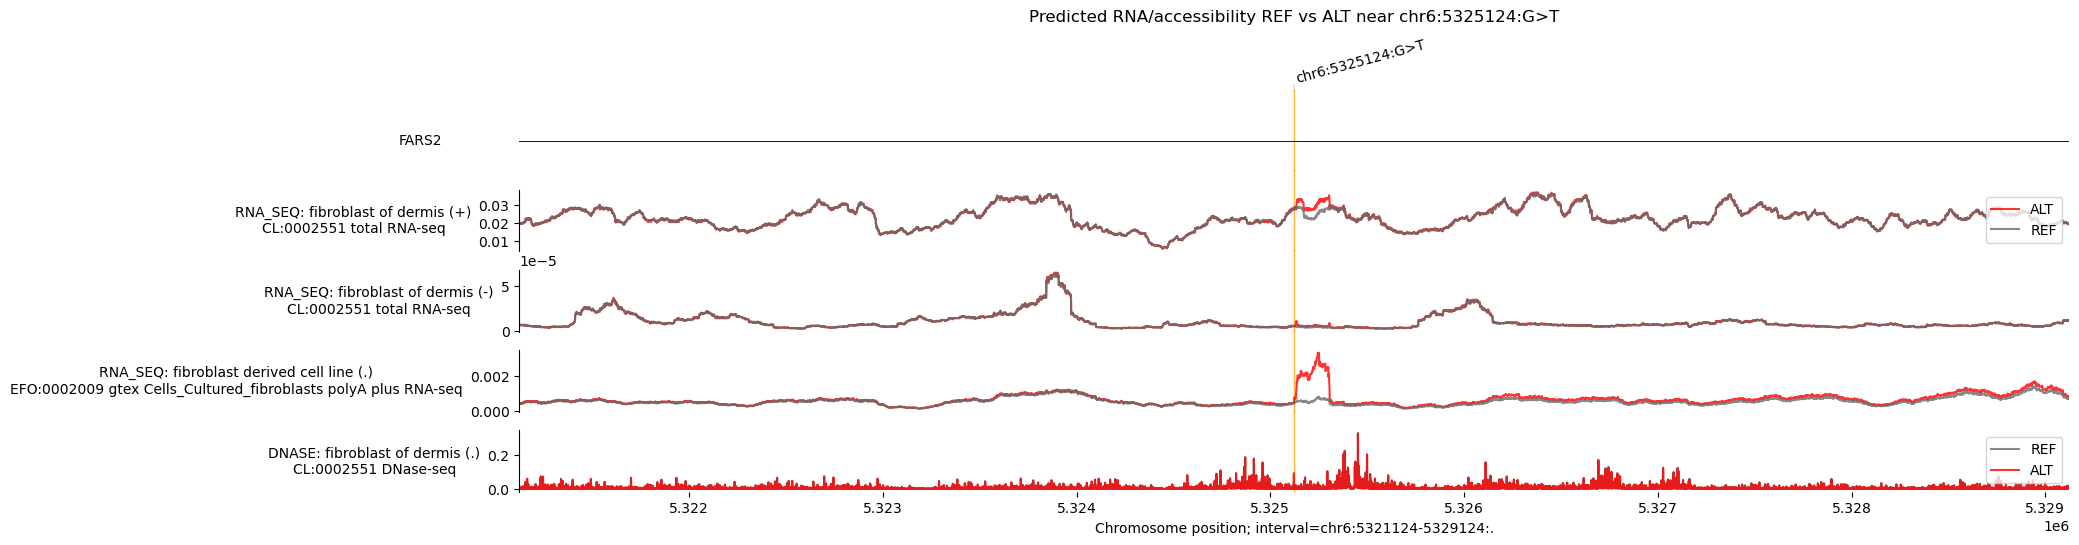

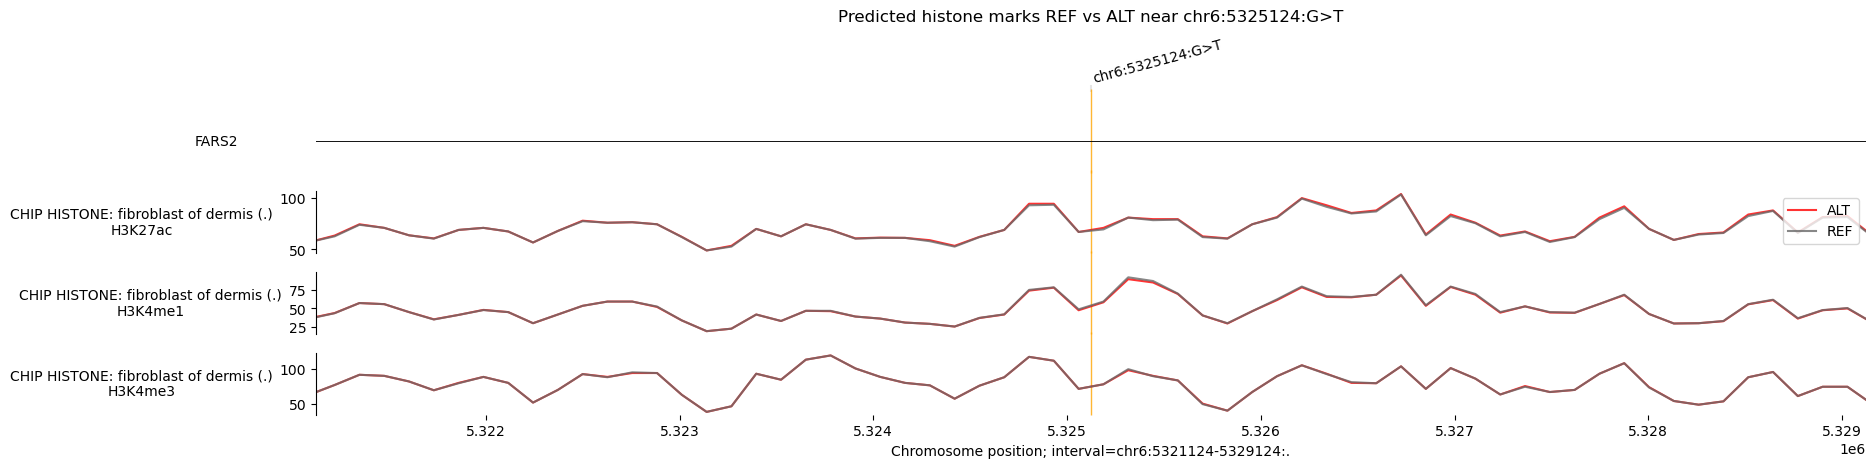

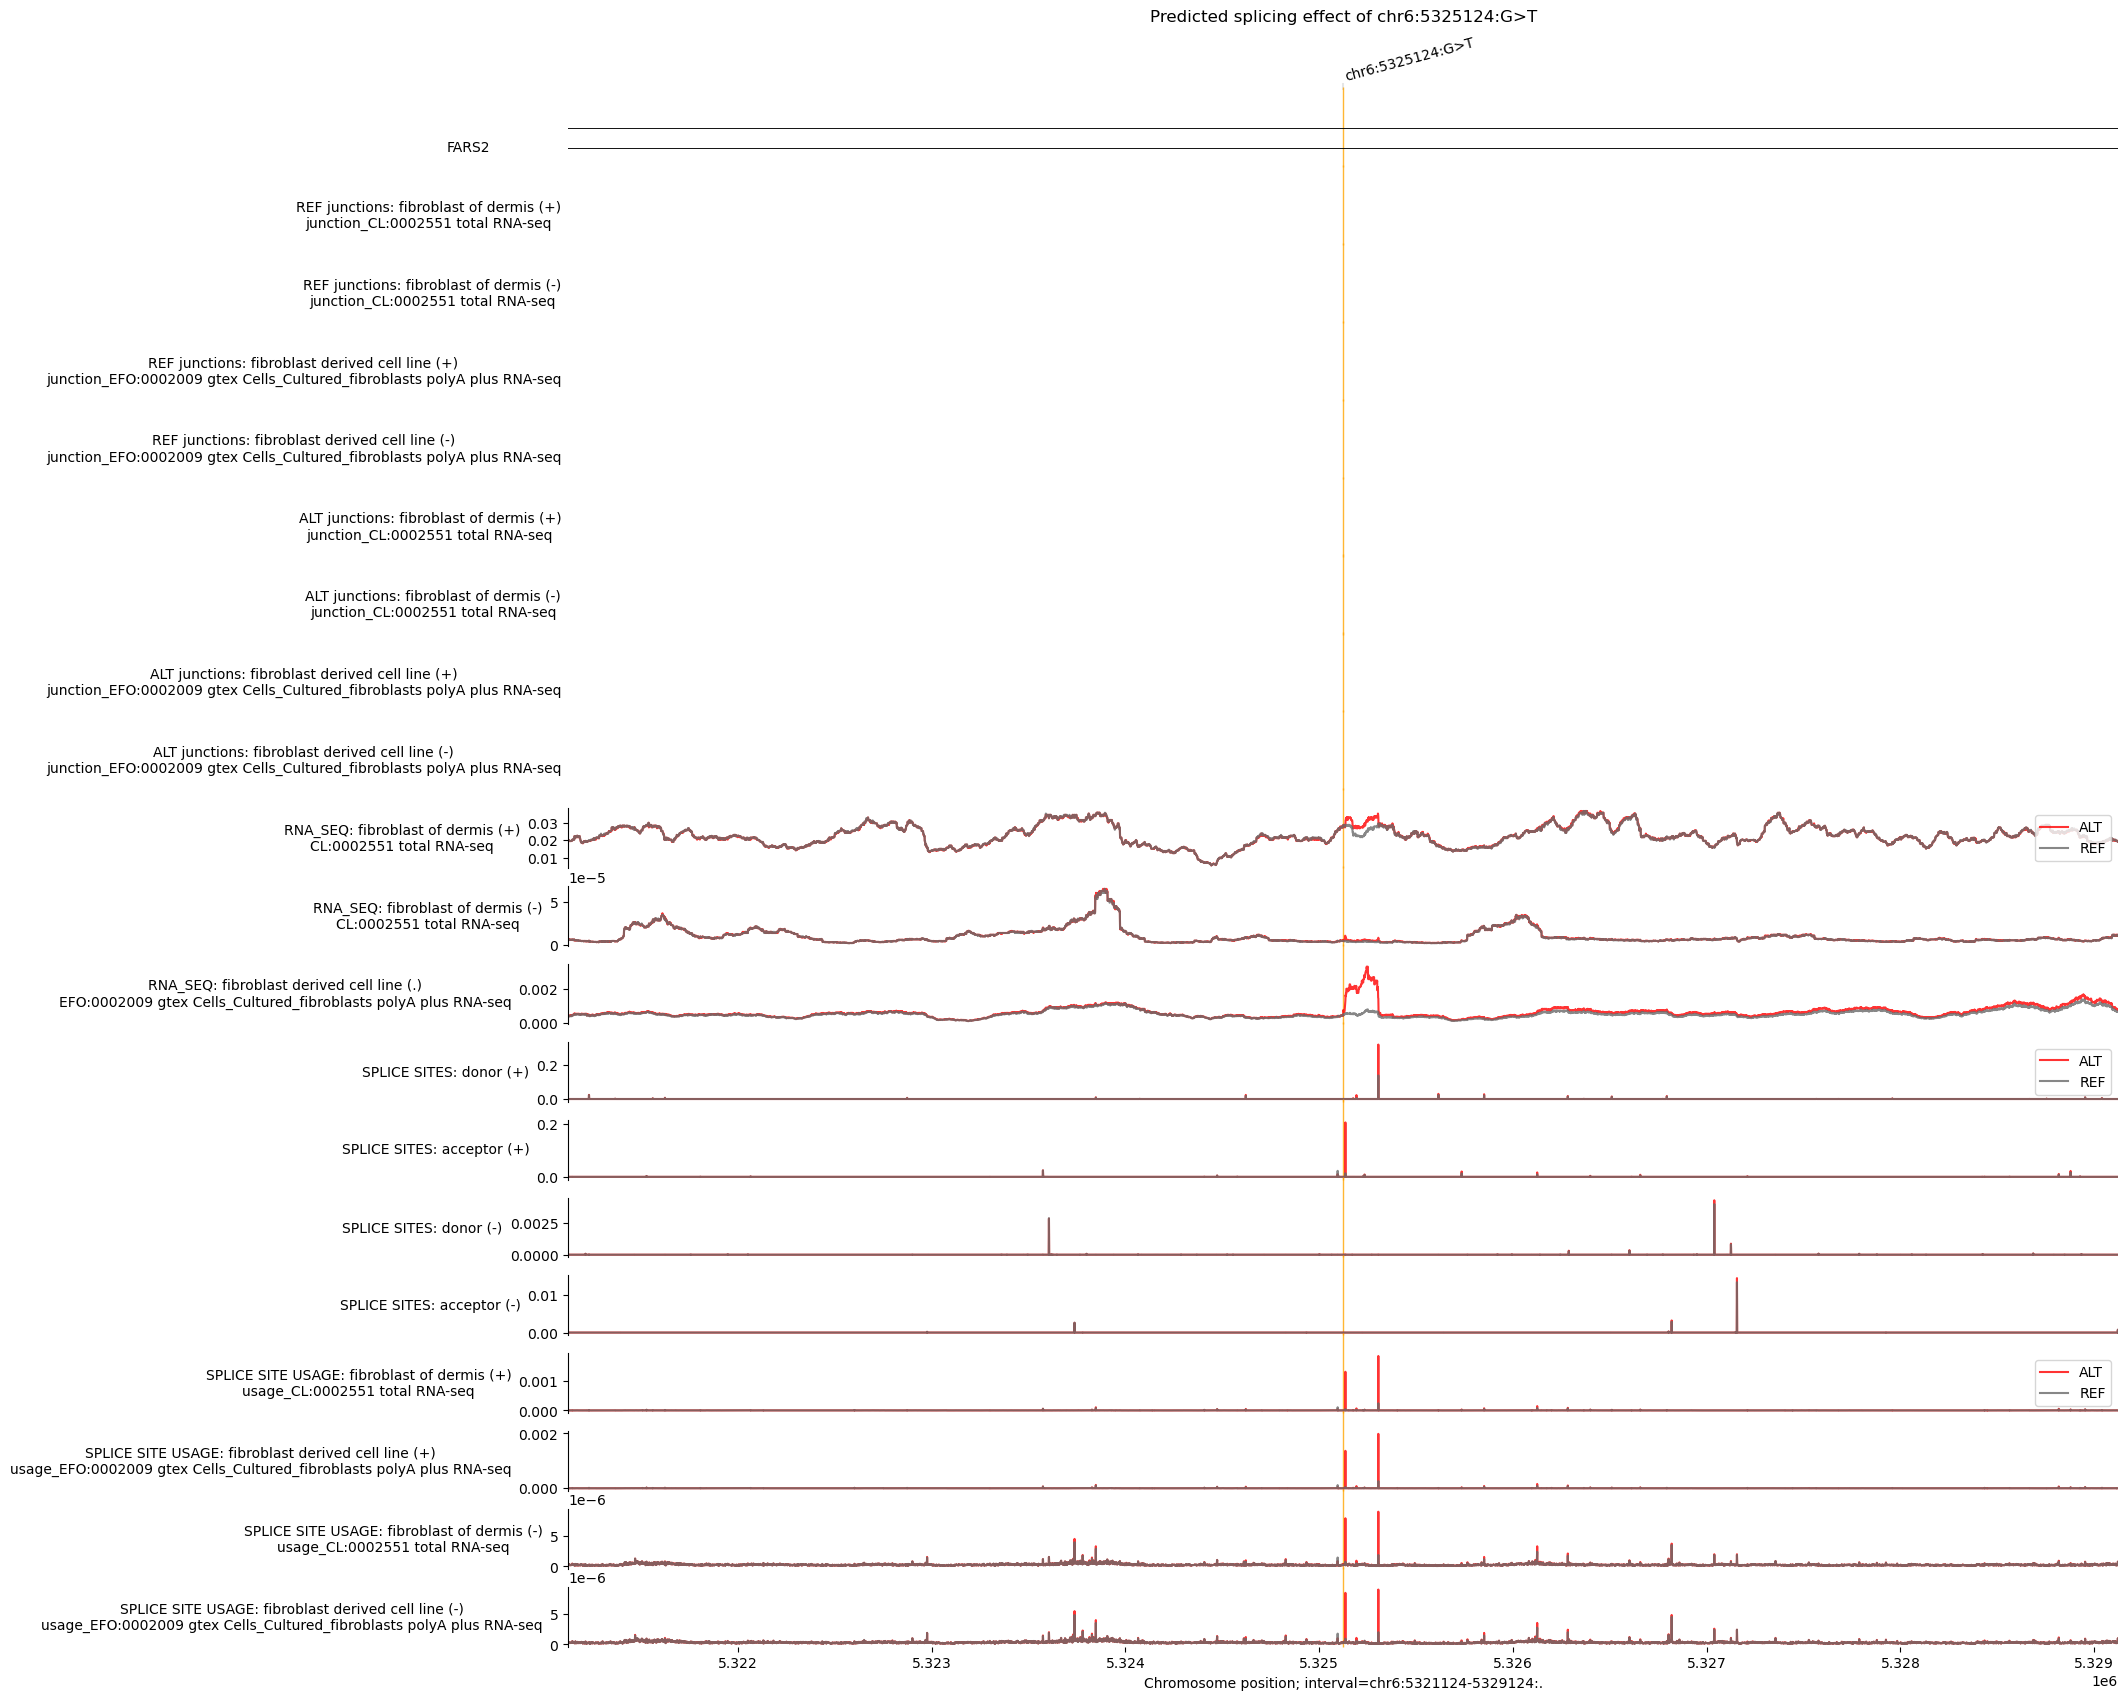

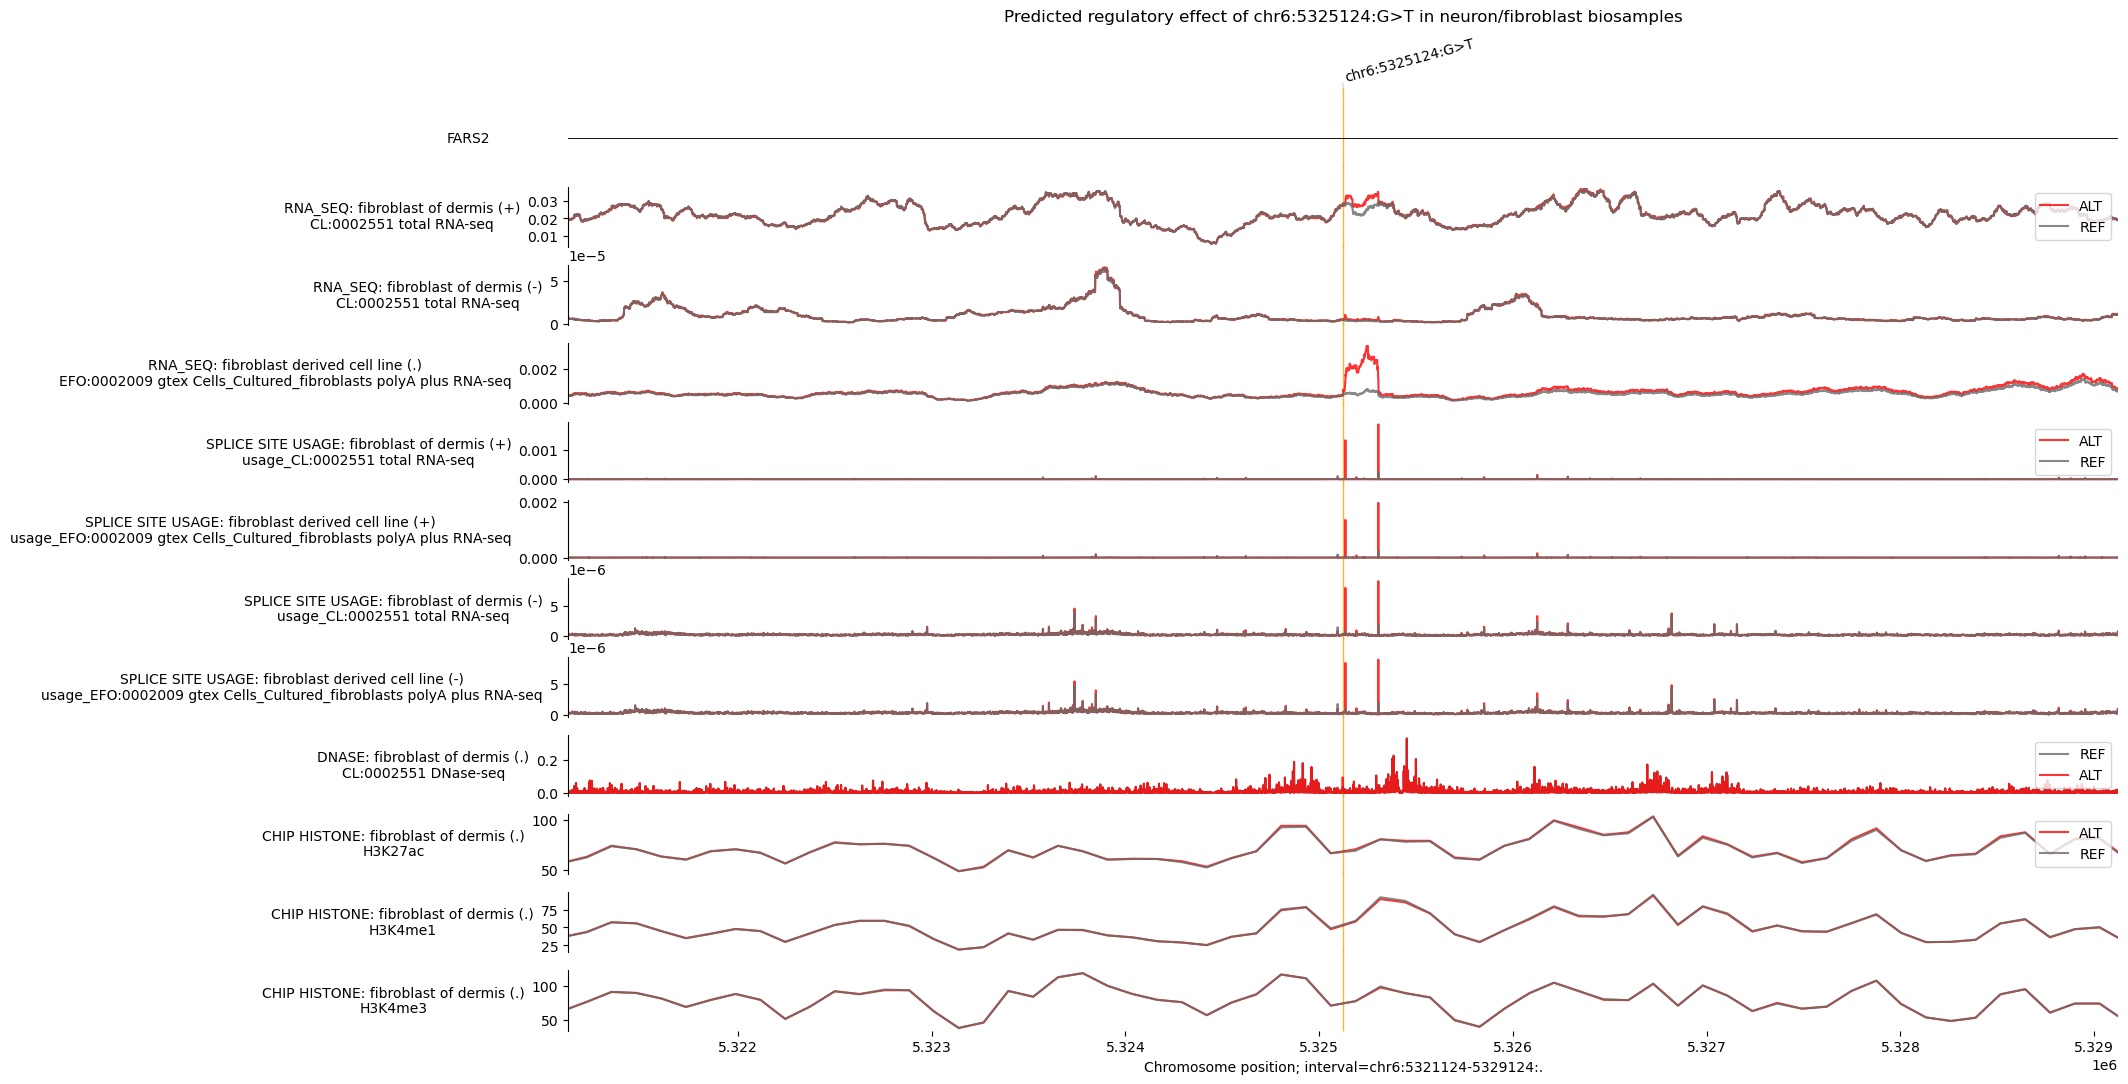


Saved outputs to: alphagenome_Fibroblast_variant_FARS2_chr6_5325124_G_T_plots_

REF RNA_SEQ metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
1,CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
2,EFO:0002009 gtex Cells_Cultured_fibroblasts po...,.,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,paired,False,0.056562



REF DNASE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 DNase-seq,.,DNase-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,encode,single,False,1.079167



REF ATAC metadata:


...

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K27ac,encode,single,False,1.049457
2,CL:0002551 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K4me1,encode,single,False,1.037979
4,CL:0002551 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,"adult,unknown",H3K4me3,encode,single,False,0.947388



REF SPLICE_SITE_USAGE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
1,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,+,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex
2,usage_CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
3,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,-,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex



REF SPLICE_JUNCTIONS metadata:


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0002551 total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,total RNA-seq
1,junction_EFO:0002009 gtex Cells_Cultured_fibro...,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,polyA plus RNA-seq


In [9]:
# PLot fibroblasts here

# ============================================================
# AlphaGenome variant visualization for chr6:5325124:G>T
# ============================================================

# Optional install
# !pip install alphagenome pyarrow pandas matplotlib

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import gene_annotation, genome, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

# ============================================================
# 1. USER SETTINGS
# ============================================================

# ---- API key ----
# put your key from AlphaGenome here directly
API_KEY = ""

# ---- GENCODE path ----
# Can be .feather or .gtf / .gtf.gz
GENCODE_PATH = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# ---- Variant of interest ----
VARIANT_STRING = "chr6:5325124:G>T"

# ---- Prediction interval width ----
PREDICTION_INTERVAL = dna_client.SEQUENCE_LENGTH_1MB

# ---- Plot zoom width around the variant ----
PLOT_WIDTH_BP = 8000

# ---- Optional enhancer annotation ----
ENHANCER_INTERVALS = [
    # genome.Interval("chr8", 24956000, 24957200, name="Nearby_enhancer")
]

# ---- Search words for neuron + fibroblast biosamples ----
# CELLTYPE_KEYWORDS = [
#     # Neuron-related
#     "neuron",
#     "neuronal",
#     "brain",
#     "cortex",
#     "cortical",
#     "cerebell",
#     "spinal",
#     "hippoc",
#     "motor neuron",
#     "neural",
# ]

CELLTYPE_KEYWORDS = {
    "fibroblast derived cell line",
    "fibroblast of dermis",
}

# ---- Histone marks to keep ----
HISTONE_KEEP = ["H3K27ac", "H3K4me1", "H3K4me3"]

# ---- Save figures? ----
SAVE_FIGURES = True
OUTDIR = "alphagenome_Fibroblast_variant_FARS2_chr6_5325124_G_T_plots_"

# ============================================================
# 2. CREATE MODEL
# ============================================================

dna_model = dna_client.create(API_KEY)

output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

# # ============================================================
# # 3. LOAD YOUR GENCODE FILE
# # ============================================================

# def parse_gtf_attributes(attr_string):
#     out = {}
#     if pd.isna(attr_string):
#         return out
#     matches = re.findall(r'(\S+)\s+"([^"]+)"', attr_string)
#     for key, val in matches:
#         out[key] = val
#     return out


# def load_gencode(path):
#     if path.endswith(".feather"):
#         return pd.read_feather(path)

#     gtf = pd.read_csv(
#         path,
#         sep="\t",
#         comment="#",
#         header=None,
#         compression="infer"
#     )

#     if gtf.shape[1] != 9:
#         raise ValueError(f"Expected 9 GTF columns, found {gtf.shape[1]}.")

#     gtf.columns = [
#         "Chromosome", "Source", "Feature", "Start", "End",
#         "Score", "Strand", "Frame", "Attributes"
#     ]

#     parsed = gtf["Attributes"].apply(parse_gtf_attributes).apply(pd.Series)
#     gtf = pd.concat([gtf, parsed], axis=1)

#     gtf["Chromosome"] = gtf["Chromosome"].astype(str)
#     gtf["Chromosome"] = gtf["Chromosome"].apply(
#         lambda x: x if x.startswith("chr") else f"chr{x}"
#     )

#     gtf["Start"] = pd.to_numeric(gtf["Start"], errors="coerce")
#     gtf["End"] = pd.to_numeric(gtf["End"], errors="coerce")

#     if "gene_type" not in gtf.columns and "gene_biotype" in gtf.columns:
#         gtf["gene_type"] = gtf["gene_biotype"]

#     if "transcript_type" not in gtf.columns and "transcript_biotype" in gtf.columns:
#         gtf["transcript_type"] = gtf["transcript_biotype"]

#     return gtf


# gtf = load_gencode(GENCODE_PATH)

# gtf_transcript = gene_annotation.filter_transcript_support_level(
#     gene_annotation.filter_protein_coding(gtf), ['1']
# )

# transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
#     gtf_transcript
# )

# longest_transcript_extractor = transcript.TranscriptExtractor(
#     gtf_longest_transcript
# )

# print("Loaded GENCODE.")
# print(f"Rows: {len(gtf):,}")

# ============================================================
# 4. DEFINE VARIANT AND INTERVAL
# ============================================================

variant = genome.Variant.from_str(VARIANT_STRING)
print("\nVariant:")
print(variant)

interval = variant.reference_interval.resize(PREDICTION_INTERVAL)
plot_interval = variant.reference_interval.resize(PLOT_WIDTH_BP)

print("\nPrediction interval:")
print(interval)

print("\nPlot interval:")
print(plot_interval)

# Longest transcripts for cleaner annotation
longest_transcripts = longest_transcript_extractor.extract(interval)

# Full transcripts are useful for splicing plots
all_transcripts = transcript_extractor.extract(interval)

# ============================================================
# 5. FIND MATCHING ONTOLOGY TERMS
# ============================================================

def find_matching_ontology_terms(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return []

    cols_to_search = []
    for c in ["biosample_name", "biosample_type", "ontology_curie", "name", "Assay title"]:
        if c in metadata_df.columns:
            cols_to_search.append(c)

    if len(cols_to_search) == 0:
        return []

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)

    matches = metadata_df.loc[mask].copy()

    if "ontology_curie" not in matches.columns:
        return []

    return sorted(matches["ontology_curie"].dropna().astype(str).unique().tolist())


dnase_terms = find_matching_ontology_terms(output_metadata.dnase, CELLTYPE_KEYWORDS)
atac_terms = find_matching_ontology_terms(output_metadata.atac, CELLTYPE_KEYWORDS)
chip_histone_terms = find_matching_ontology_terms(output_metadata.chip_histone, CELLTYPE_KEYWORDS)
rna_seq_terms = find_matching_ontology_terms(output_metadata.rna_seq, CELLTYPE_KEYWORDS)
splice_usage_terms = find_matching_ontology_terms(output_metadata.splice_site_usage, CELLTYPE_KEYWORDS)
splice_junction_terms = find_matching_ontology_terms(output_metadata.splice_junctions, CELLTYPE_KEYWORDS)

all_terms = sorted(
    set(dnase_terms)
    | set(atac_terms)
    | set(chip_histone_terms)
    | set(rna_seq_terms)
    | set(splice_usage_terms)
    | set(splice_junction_terms)
)

print("\nNeuron/fibroblast-related ontology terms found:")
print(all_terms[:100])
print(f"Total found: {len(all_terms)}")

if len(all_terms) == 0:
    print("\nWarning: no matching ontology terms were found.")

# ============================================================
# 6. RUN PREDICT_VARIANT
# ============================================================

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=all_terms if len(all_terms) > 0 else None,
)

ref_alt_colors = {"REF": "dimgrey", "ALT": "red"}

# ============================================================
# 7. FILTER TRACKS TO MATCHING BIOSAMPLES
# ============================================================

def metadata_keyword_mask(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.Series([], dtype=bool)

    cols_to_search = [
        c for c in ["biosample_name", "biosample_type", "ontology_curie", "name"]
        if c in metadata_df.columns
    ]
    if len(cols_to_search) == 0:
        return pd.Series([True] * len(metadata_df), index=metadata_df.index)

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)
    return mask


def filter_trackdata_by_keywords(tdata, keywords):
    if tdata is None:
        return tdata
    md = tdata.metadata
    if md is None or len(md) == 0:
        return tdata
    mask = metadata_keyword_mask(md, keywords)
    if len(mask) == 0 or mask.sum() == 0:
        return tdata
    return tdata.filter_tracks(mask.values)


ref_dnase = filter_trackdata_by_keywords(output.reference.dnase, CELLTYPE_KEYWORDS)
alt_dnase = filter_trackdata_by_keywords(output.alternate.dnase, CELLTYPE_KEYWORDS)

ref_atac = filter_trackdata_by_keywords(output.reference.atac, CELLTYPE_KEYWORDS)
alt_atac = filter_trackdata_by_keywords(output.alternate.atac, CELLTYPE_KEYWORDS)

ref_rna_seq = filter_trackdata_by_keywords(output.reference.rna_seq, CELLTYPE_KEYWORDS)
alt_rna_seq = filter_trackdata_by_keywords(output.alternate.rna_seq, CELLTYPE_KEYWORDS)

ref_splice_usage = filter_trackdata_by_keywords(output.reference.splice_site_usage, CELLTYPE_KEYWORDS)
alt_splice_usage = filter_trackdata_by_keywords(output.alternate.splice_site_usage, CELLTYPE_KEYWORDS)

ref_splice_junctions = filter_trackdata_by_keywords(output.reference.splice_junctions, CELLTYPE_KEYWORDS)
alt_splice_junctions = filter_trackdata_by_keywords(output.alternate.splice_junctions, CELLTYPE_KEYWORDS)

# splice_sites is tissue-agnostic, so use directly
ref_splice_sites = output.reference.splice_sites
alt_splice_sites = output.alternate.splice_sites

ref_chip_histone = filter_trackdata_by_keywords(output.reference.chip_histone, CELLTYPE_KEYWORDS)
alt_chip_histone = filter_trackdata_by_keywords(output.alternate.chip_histone, CELLTYPE_KEYWORDS)

# Keep only selected histone marks
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_chip_histone = ref_chip_histone.filter_tracks(
        ref_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_chip_histone = alt_chip_histone.filter_tracks(
        alt_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

# Safe reordering using positional indices
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_order = (
        ref_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    ref_chip_histone = ref_chip_histone.select_tracks_by_index(ref_order)

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_order = (
        alt_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    alt_chip_histone = alt_chip_histone.select_tracks_by_index(alt_order)

# ============================================================
# 8. BUILD ANNOTATIONS
# ============================================================

annotations = [plot_components.VariantAnnotation([variant])]

if len(ENHANCER_INTERVALS) > 0:
    annotations.append(plot_components.IntervalAnnotation(ENHANCER_INTERVALS))

# ============================================================
# 9. PLOT RNA + ACCESSIBILITY
# ============================================================

plot1 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted RNA/accessibility REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 10. PLOT CHIP_HISTONE
# ============================================================

plot2 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted histone marks REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 11. PLOT SPLICING
# ============================================================

plot3 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(all_transcripts),

        plot_components.Sashimi(
            ref_splice_junctions,
            ylabel_template="REF junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.Sashimi(
            alt_splice_junctions,
            ylabel_template="ALT junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_sites,
                "ALT": alt_splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITES: {name} ({strand})",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted splicing effect of {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 12. OPTIONAL COMBINED PLOT
# ============================================================

plot4 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),


        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted regulatory effect of {VARIANT_STRING} in neuron/fibroblast biosamples",
)

plt.show()


# ============================================================
# 13. OPTIONAL SAVE
# ============================================================

if SAVE_FIGURES:
    os.makedirs(OUTDIR, exist_ok=True)

    plot1.savefig(os.path.join(OUTDIR, "rna_dnase_atac_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot2.savefig(os.path.join(OUTDIR, "chip_histone_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot3.savefig(os.path.join(OUTDIR, "splicing_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot4.savefig(os.path.join(OUTDIR, "combined_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")

    if ref_rna_seq is not None:
        ref_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "ref_rna_seq_metadata.tsv"), sep="\t", index=False)
    if alt_rna_seq is not None:
        alt_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "alt_rna_seq_metadata.tsv"), sep="\t", index=False)

    if ref_dnase is not None:
        ref_dnase.metadata.to_csv(os.path.join(OUTDIR, "ref_dnase_metadata.tsv"), sep="\t", index=False)
    if alt_dnase is not None:
        alt_dnase.metadata.to_csv(os.path.join(OUTDIR, "alt_dnase_metadata.tsv"), sep="\t", index=False)

    if ref_atac is not None:
        ref_atac.metadata.to_csv(os.path.join(OUTDIR, "ref_atac_metadata.tsv"), sep="\t", index=False)
    if alt_atac is not None:
        alt_atac.metadata.to_csv(os.path.join(OUTDIR, "alt_atac_metadata.tsv"), sep="\t", index=False)

    if ref_chip_histone is not None:
        ref_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "ref_chip_histone_metadata.tsv"), sep="\t", index=False)
    if alt_chip_histone is not None:
        alt_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "alt_chip_histone_metadata.tsv"), sep="\t", index=False)

    if ref_splice_usage is not None:
        ref_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_usage_metadata.tsv"), sep="\t", index=False)
    if alt_splice_usage is not None:
        alt_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_usage_metadata.tsv"), sep="\t", index=False)

    if ref_splice_junctions is not None:
        ref_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_junctions_metadata.tsv"), sep="\t", index=False)
    if alt_splice_junctions is not None:
        alt_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_junctions_metadata.tsv"), sep="\t", index=False)

    print(f"\nSaved outputs to: {OUTDIR}")

# ============================================================
# 14. DISPLAY PLOTTED METADATA
# ============================================================

print("\nREF RNA_SEQ metadata:")
display(ref_rna_seq.metadata.head(20) if ref_rna_seq is not None else None)

print("\nREF DNASE metadata:")
display(ref_dnase.metadata.head(20) if ref_dnase is not None else None)

print("\nREF ATAC metadata:")
display(ref_atac.metadata.head(20) if ref_atac is not None else None)

print("\nREF CHIP_HISTONE metadata:")
display(ref_chip_histone.metadata.head(20) if ref_chip_histone is not None else None)

print("\nREF SPLICE_SITE_USAGE metadata:")
display(ref_splice_usage.metadata.head(20) if ref_splice_usage is not None else None)

print("\nREF SPLICE_JUNCTIONS metadata:")
display(ref_splice_junctions.metadata.head(20) if ref_splice_junctions is not None else None)

## HARS1 predict variant


Variant:
chr5:140673926:T>A

Prediction interval:
chr5:140149638-141198214:.

Plot interval:
chr5:140669926-140677926:.

Neuron/fibroblast-related ontology terms found:
['CL:0002551', 'EFO:0002009']
Total found: 2


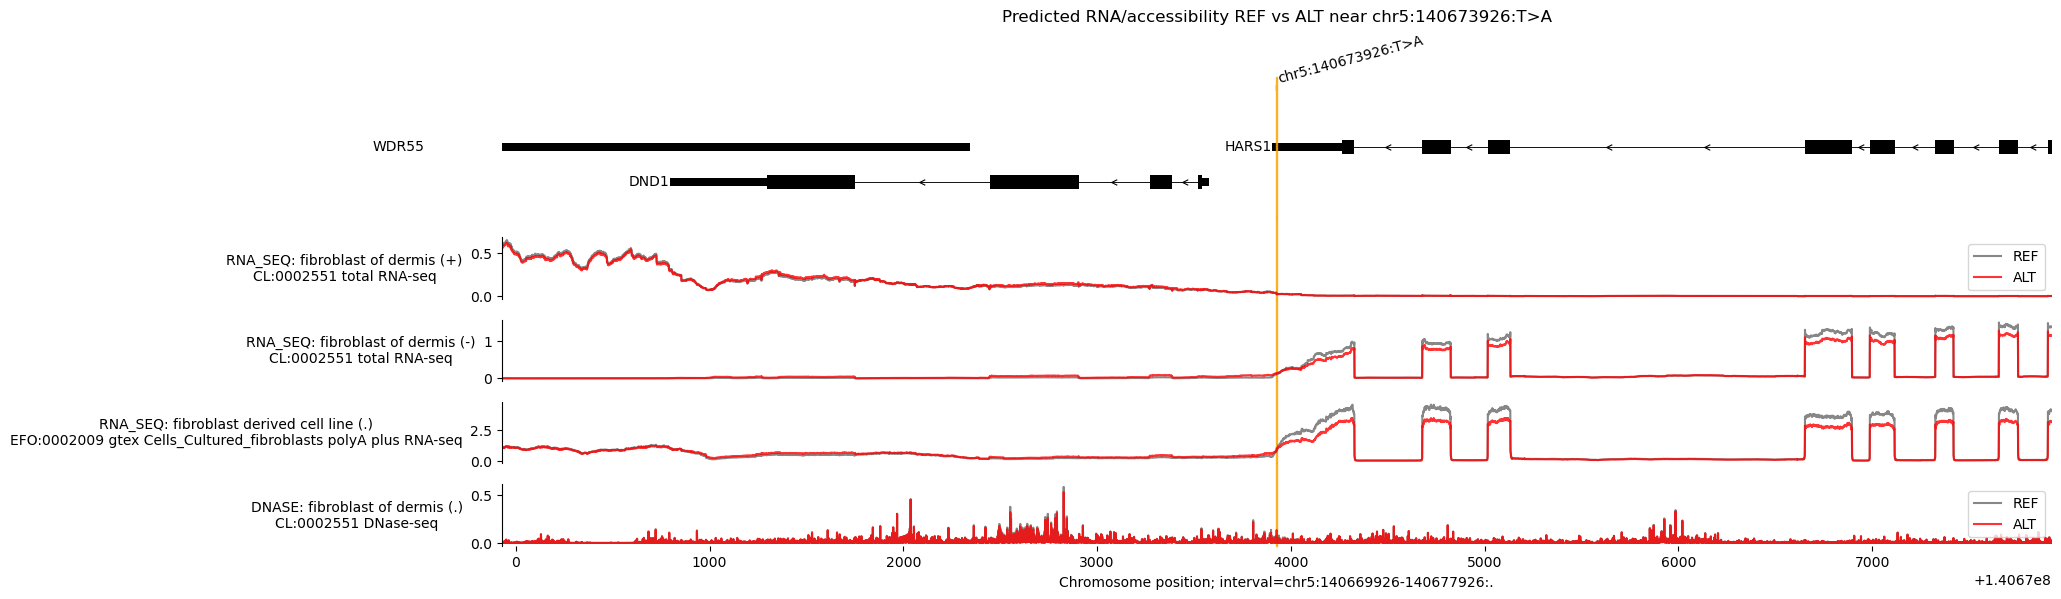

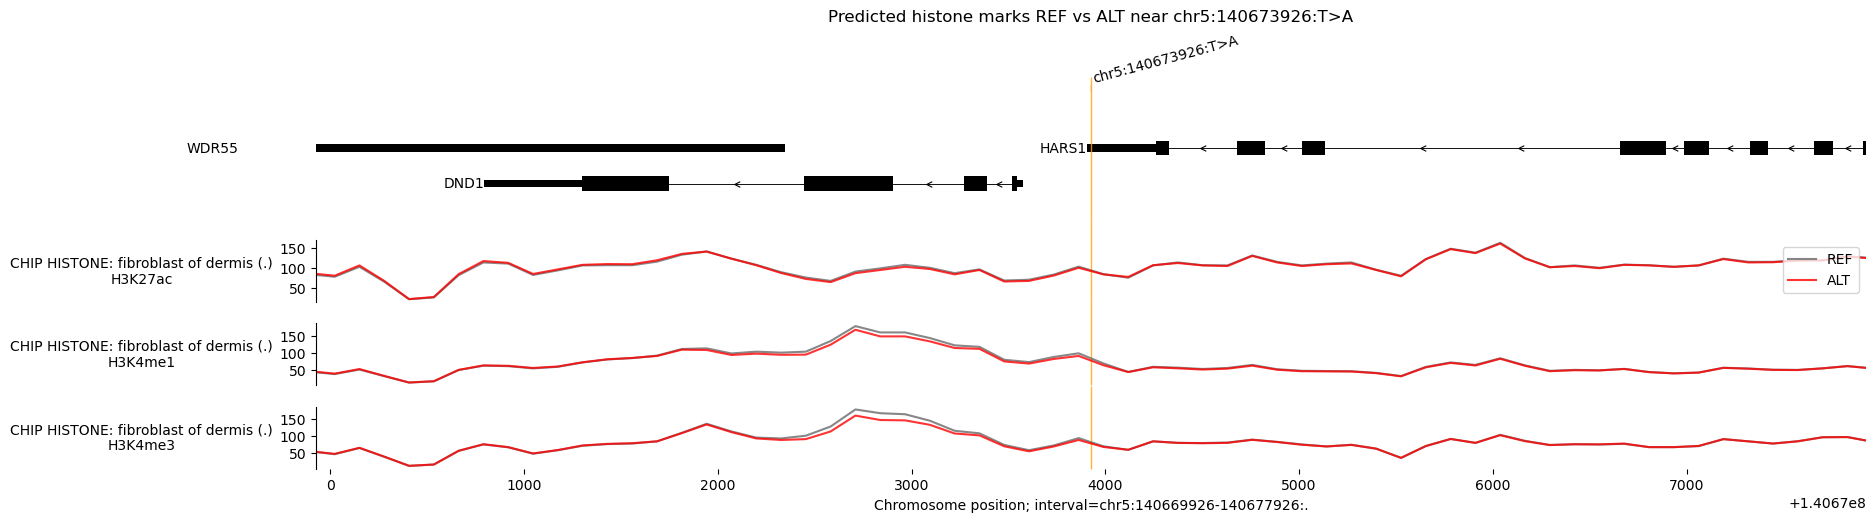

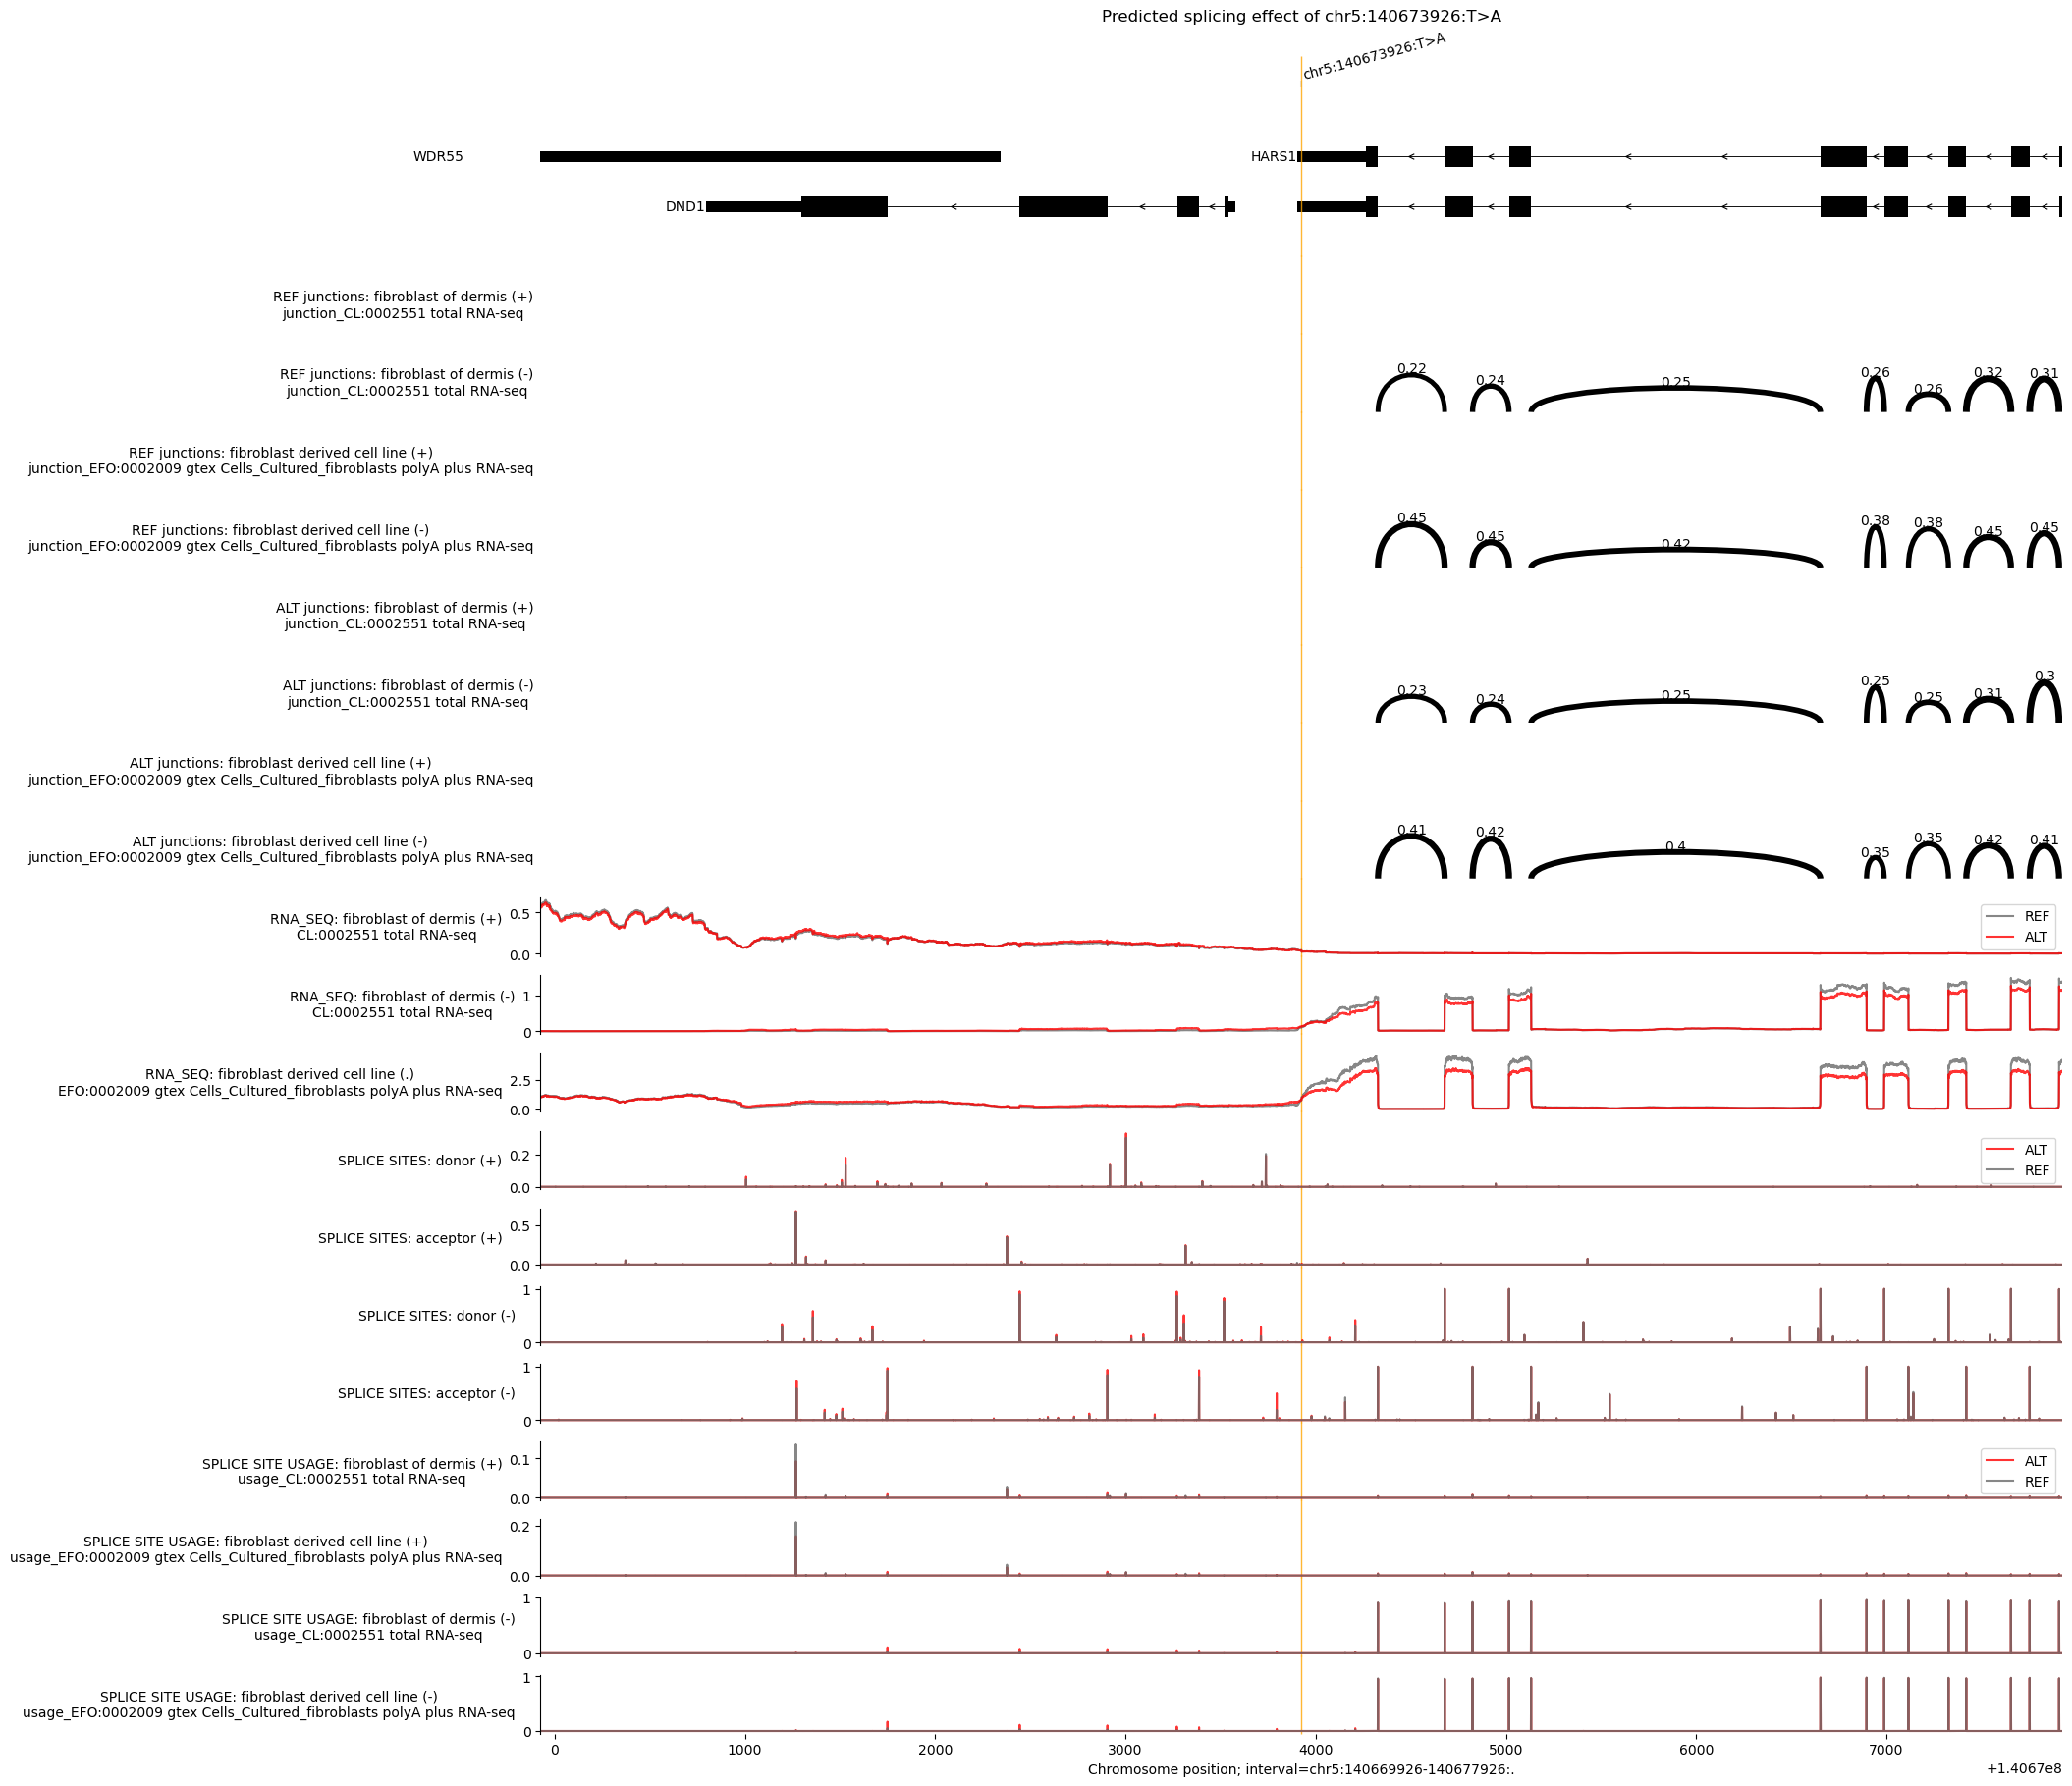

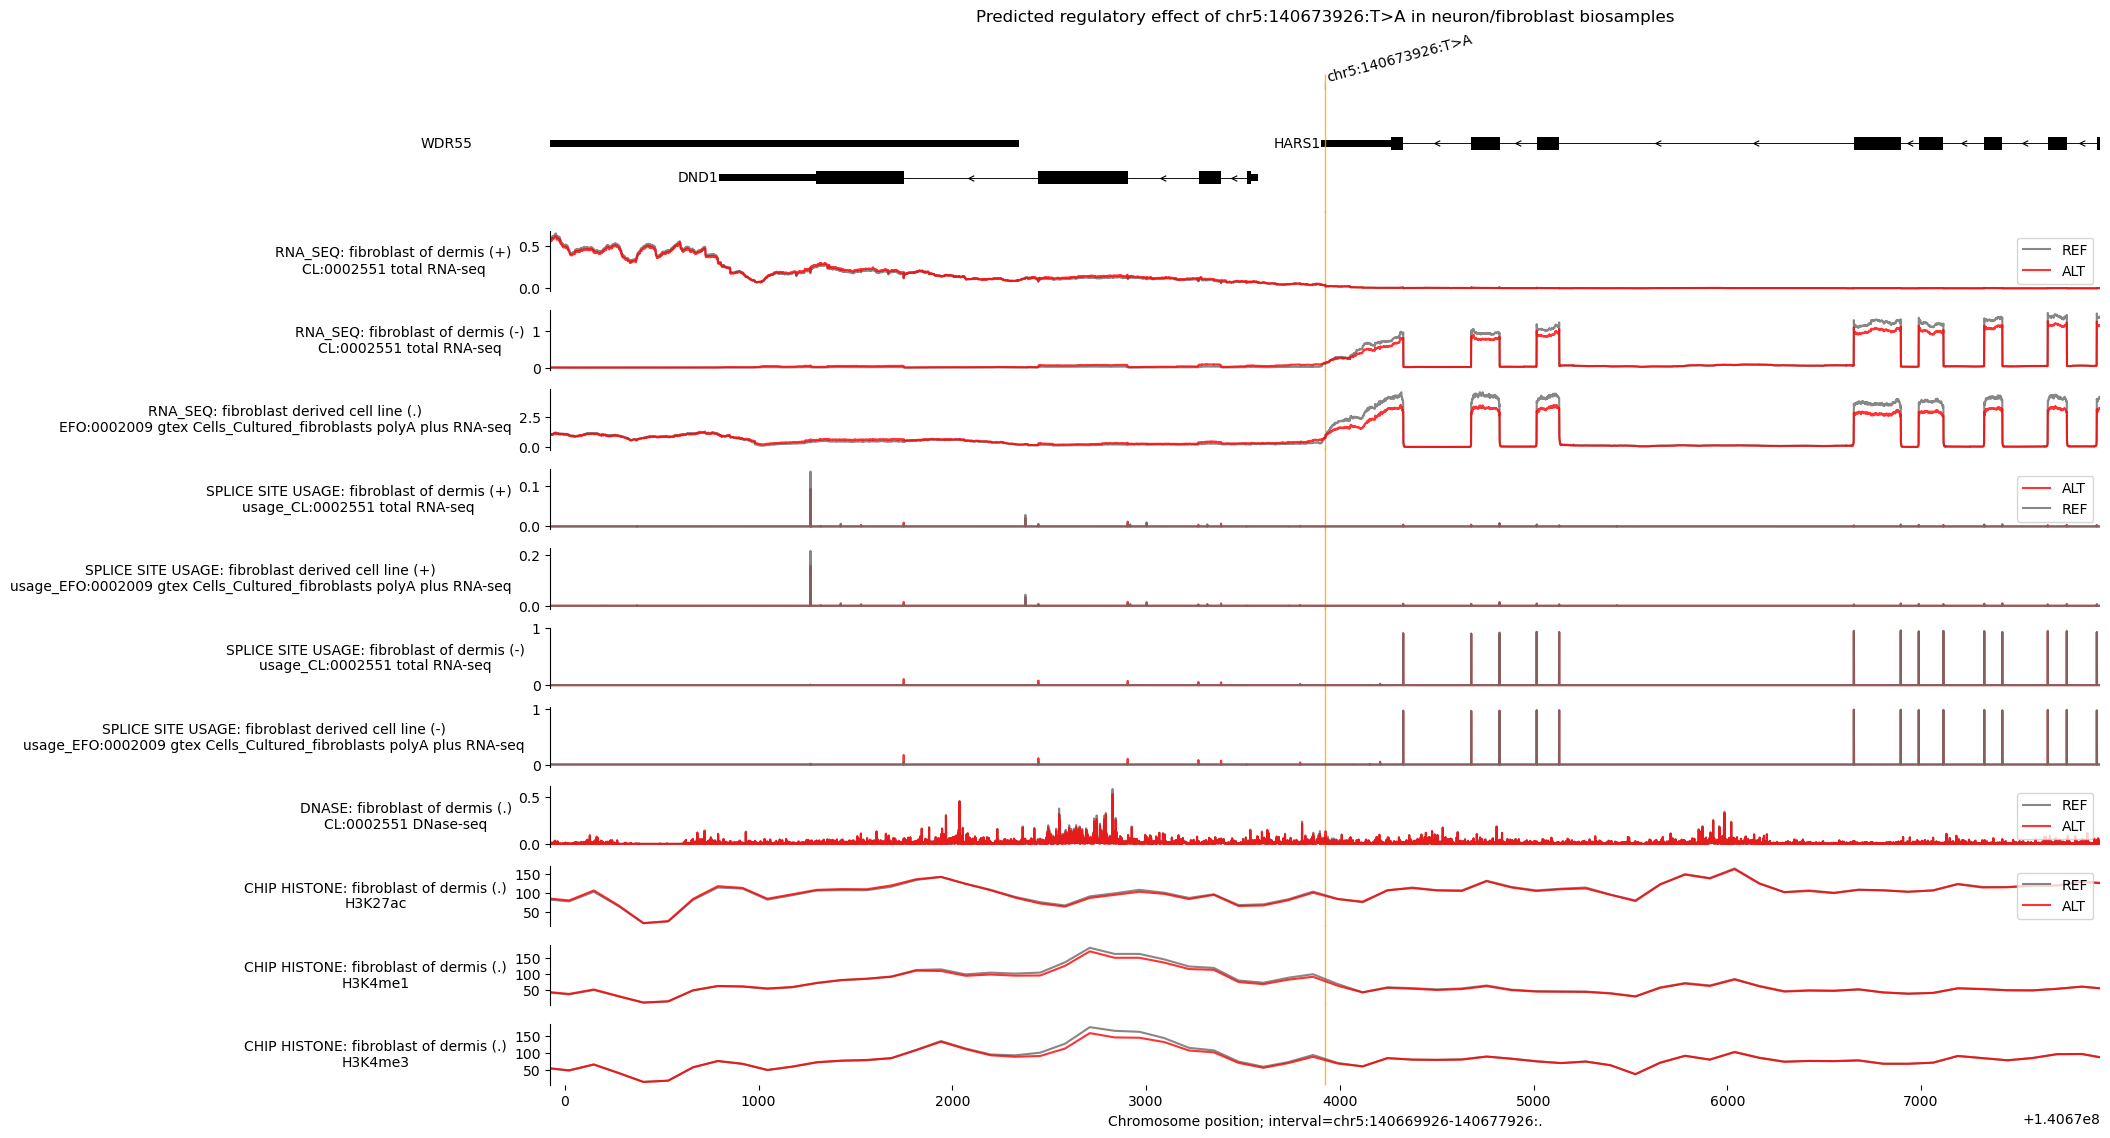


Saved outputs to: alphagenome_Fibroblast_variant_HARS1_chr5_140673926_T_A_fusion_plots_

REF RNA_SEQ metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
1,CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
2,EFO:0002009 gtex Cells_Cultured_fibroblasts po...,.,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,paired,False,0.056562



REF DNASE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 DNase-seq,.,DNase-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,encode,single,False,1.079167



REF ATAC metadata:


...

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K27ac,encode,single,False,1.049457
2,CL:0002551 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K4me1,encode,single,False,1.037979
4,CL:0002551 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,"adult,unknown",H3K4me3,encode,single,False,0.947388



REF SPLICE_SITE_USAGE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
1,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,+,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex
2,usage_CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
3,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,-,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex



REF SPLICE_JUNCTIONS metadata:


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0002551 total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,total RNA-seq
1,junction_EFO:0002009 gtex Cells_Cultured_fibro...,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,polyA plus RNA-seq


In [10]:
# PLot fibroblasts here

# ============================================================
# AlphaGenome variant visualization for chr8:24956773:G>C
# using YOUR OWN GENCODE file
# includes neuron + fibroblast + RNA + splicing
# ============================================================

# Optional install
# !pip install alphagenome pyarrow pandas matplotlib

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import gene_annotation, genome, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

# ============================================================
# 1. USER SETTINGS
# ============================================================

# ---- API key ----
# Option A: put your key here directly
API_KEY = ""

# Option B: or uncomment this and set an env var instead
# API_KEY = os.environ["ALPHAGENOME_API_KEY"]

# ---- Your GENCODE path ----
# Can be .feather or .gtf / .gtf.gz
GENCODE_PATH = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# ---- Variant of interest ----
VARIANT_STRING = "chr5:140673926:T>A"

# ---- Prediction interval width ----
PREDICTION_INTERVAL = dna_client.SEQUENCE_LENGTH_1MB

# ---- Plot zoom width around the variant ----
PLOT_WIDTH_BP = 8000

# ---- Optional enhancer annotation ----
ENHANCER_INTERVALS = [
    # genome.Interval("chr8", 24956000, 24957200, name="Nearby_enhancer")
]

# ---- Search words for neuron + fibroblast biosamples ----
# CELLTYPE_KEYWORDS = [
#     # Neuron-related
#     "neuron",
#     "neuronal",
#     "brain",
#     "cortex",
#     "cortical",
#     "cerebell",
#     "spinal",
#     "hippoc",
#     "motor neuron",
#     "neural",
# ]

CELLTYPE_KEYWORDS = {
    "fibroblast derived cell line",
    "fibroblast of dermis",
}

# ---- Histone marks to keep ----
HISTONE_KEEP = ["H3K27ac", "H3K4me1", "H3K4me3"]

# ---- Save figures? ----
SAVE_FIGURES = True
OUTDIR = "alphagenome_Fibroblast_variant_HARS1_chr5_140673926_T_A_fusion_plots_"

# ============================================================
# 2. CREATE MODEL
# ============================================================

dna_model = dna_client.create(API_KEY)

output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

# # ============================================================
# # 3. LOAD YOUR GENCODE FILE
# # ============================================================

# def parse_gtf_attributes(attr_string):
#     out = {}
#     if pd.isna(attr_string):
#         return out
#     matches = re.findall(r'(\S+)\s+"([^"]+)"', attr_string)
#     for key, val in matches:
#         out[key] = val
#     return out


# def load_gencode(path):
#     if path.endswith(".feather"):
#         return pd.read_feather(path)

#     gtf = pd.read_csv(
#         path,
#         sep="\t",
#         comment="#",
#         header=None,
#         compression="infer"
#     )

#     if gtf.shape[1] != 9:
#         raise ValueError(f"Expected 9 GTF columns, found {gtf.shape[1]}.")

#     gtf.columns = [
#         "Chromosome", "Source", "Feature", "Start", "End",
#         "Score", "Strand", "Frame", "Attributes"
#     ]

#     parsed = gtf["Attributes"].apply(parse_gtf_attributes).apply(pd.Series)
#     gtf = pd.concat([gtf, parsed], axis=1)

#     gtf["Chromosome"] = gtf["Chromosome"].astype(str)
#     gtf["Chromosome"] = gtf["Chromosome"].apply(
#         lambda x: x if x.startswith("chr") else f"chr{x}"
#     )

#     gtf["Start"] = pd.to_numeric(gtf["Start"], errors="coerce")
#     gtf["End"] = pd.to_numeric(gtf["End"], errors="coerce")

#     if "gene_type" not in gtf.columns and "gene_biotype" in gtf.columns:
#         gtf["gene_type"] = gtf["gene_biotype"]

#     if "transcript_type" not in gtf.columns and "transcript_biotype" in gtf.columns:
#         gtf["transcript_type"] = gtf["transcript_biotype"]

#     return gtf


# gtf = load_gencode(GENCODE_PATH)

# gtf_transcript = gene_annotation.filter_transcript_support_level(
#     gene_annotation.filter_protein_coding(gtf), ['1']
# )

# transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
#     gtf_transcript
# )

# longest_transcript_extractor = transcript.TranscriptExtractor(
#     gtf_longest_transcript
# )

# print("Loaded GENCODE.")
# print(f"Rows: {len(gtf):,}")

# ============================================================
# 4. DEFINE VARIANT AND INTERVAL
# ============================================================

variant = genome.Variant.from_str(VARIANT_STRING)
print("\nVariant:")
print(variant)

interval = variant.reference_interval.resize(PREDICTION_INTERVAL)
plot_interval = variant.reference_interval.resize(PLOT_WIDTH_BP)

print("\nPrediction interval:")
print(interval)

print("\nPlot interval:")
print(plot_interval)

# Longest transcripts for cleaner annotation
longest_transcripts = longest_transcript_extractor.extract(interval)

# Full transcripts are useful for splicing plots
all_transcripts = transcript_extractor.extract(interval)

# ============================================================
# 5. FIND MATCHING ONTOLOGY TERMS
# ============================================================

def find_matching_ontology_terms(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return []

    cols_to_search = []
    for c in ["biosample_name", "biosample_type", "ontology_curie", "name", "Assay title"]:
        if c in metadata_df.columns:
            cols_to_search.append(c)

    if len(cols_to_search) == 0:
        return []

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)

    matches = metadata_df.loc[mask].copy()

    if "ontology_curie" not in matches.columns:
        return []

    return sorted(matches["ontology_curie"].dropna().astype(str).unique().tolist())


dnase_terms = find_matching_ontology_terms(output_metadata.dnase, CELLTYPE_KEYWORDS)
atac_terms = find_matching_ontology_terms(output_metadata.atac, CELLTYPE_KEYWORDS)
chip_histone_terms = find_matching_ontology_terms(output_metadata.chip_histone, CELLTYPE_KEYWORDS)
rna_seq_terms = find_matching_ontology_terms(output_metadata.rna_seq, CELLTYPE_KEYWORDS)
splice_usage_terms = find_matching_ontology_terms(output_metadata.splice_site_usage, CELLTYPE_KEYWORDS)
splice_junction_terms = find_matching_ontology_terms(output_metadata.splice_junctions, CELLTYPE_KEYWORDS)

all_terms = sorted(
    set(dnase_terms)
    | set(atac_terms)
    | set(chip_histone_terms)
    | set(rna_seq_terms)
    | set(splice_usage_terms)
    | set(splice_junction_terms)
)

print("\nNeuron/fibroblast-related ontology terms found:")
print(all_terms[:100])
print(f"Total found: {len(all_terms)}")

if len(all_terms) == 0:
    print("\nWarning: no matching ontology terms were found.")

# ============================================================
# 6. RUN PREDICT_VARIANT
# ============================================================

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=all_terms if len(all_terms) > 0 else None,
)

ref_alt_colors = {"REF": "dimgrey", "ALT": "red"}

# ============================================================
# 7. FILTER TRACKS TO MATCHING BIOSAMPLES
# ============================================================

def metadata_keyword_mask(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.Series([], dtype=bool)

    cols_to_search = [
        c for c in ["biosample_name", "biosample_type", "ontology_curie", "name"]
        if c in metadata_df.columns
    ]
    if len(cols_to_search) == 0:
        return pd.Series([True] * len(metadata_df), index=metadata_df.index)

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)
    return mask


def filter_trackdata_by_keywords(tdata, keywords):
    if tdata is None:
        return tdata
    md = tdata.metadata
    if md is None or len(md) == 0:
        return tdata
    mask = metadata_keyword_mask(md, keywords)
    if len(mask) == 0 or mask.sum() == 0:
        return tdata
    return tdata.filter_tracks(mask.values)


ref_dnase = filter_trackdata_by_keywords(output.reference.dnase, CELLTYPE_KEYWORDS)
alt_dnase = filter_trackdata_by_keywords(output.alternate.dnase, CELLTYPE_KEYWORDS)

ref_atac = filter_trackdata_by_keywords(output.reference.atac, CELLTYPE_KEYWORDS)
alt_atac = filter_trackdata_by_keywords(output.alternate.atac, CELLTYPE_KEYWORDS)

ref_rna_seq = filter_trackdata_by_keywords(output.reference.rna_seq, CELLTYPE_KEYWORDS)
alt_rna_seq = filter_trackdata_by_keywords(output.alternate.rna_seq, CELLTYPE_KEYWORDS)

ref_splice_usage = filter_trackdata_by_keywords(output.reference.splice_site_usage, CELLTYPE_KEYWORDS)
alt_splice_usage = filter_trackdata_by_keywords(output.alternate.splice_site_usage, CELLTYPE_KEYWORDS)

ref_splice_junctions = filter_trackdata_by_keywords(output.reference.splice_junctions, CELLTYPE_KEYWORDS)
alt_splice_junctions = filter_trackdata_by_keywords(output.alternate.splice_junctions, CELLTYPE_KEYWORDS)

# splice_sites is tissue-agnostic, so use directly
ref_splice_sites = output.reference.splice_sites
alt_splice_sites = output.alternate.splice_sites

ref_chip_histone = filter_trackdata_by_keywords(output.reference.chip_histone, CELLTYPE_KEYWORDS)
alt_chip_histone = filter_trackdata_by_keywords(output.alternate.chip_histone, CELLTYPE_KEYWORDS)

# Keep only selected histone marks
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_chip_histone = ref_chip_histone.filter_tracks(
        ref_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_chip_histone = alt_chip_histone.filter_tracks(
        alt_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

# Safe reordering using positional indices
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_order = (
        ref_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    ref_chip_histone = ref_chip_histone.select_tracks_by_index(ref_order)

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_order = (
        alt_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    alt_chip_histone = alt_chip_histone.select_tracks_by_index(alt_order)

# ============================================================
# 8. BUILD ANNOTATIONS
# ============================================================

annotations = [plot_components.VariantAnnotation([variant])]

if len(ENHANCER_INTERVALS) > 0:
    annotations.append(plot_components.IntervalAnnotation(ENHANCER_INTERVALS))

# ============================================================
# 9. PLOT RNA + ACCESSIBILITY
# ============================================================

plot1 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted RNA/accessibility REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 10. PLOT CHIP_HISTONE
# ============================================================

plot2 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted histone marks REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 11. PLOT SPLICING
# ============================================================

plot3 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(all_transcripts),

        plot_components.Sashimi(
            ref_splice_junctions,
            ylabel_template="REF junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.Sashimi(
            alt_splice_junctions,
            ylabel_template="ALT junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_sites,
                "ALT": alt_splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITES: {name} ({strand})",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted splicing effect of {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 12. OPTIONAL COMBINED PLOT
# ============================================================

plot4 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),


        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted regulatory effect of {VARIANT_STRING} in neuron/fibroblast biosamples",
)

plt.show()


# ============================================================
# 13. OPTIONAL SAVE
# ============================================================

if SAVE_FIGURES:
    os.makedirs(OUTDIR, exist_ok=True)

    plot1.savefig(os.path.join(OUTDIR, "rna_dnase_atac_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot2.savefig(os.path.join(OUTDIR, "chip_histone_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot3.savefig(os.path.join(OUTDIR, "splicing_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot4.savefig(os.path.join(OUTDIR, "combined_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")

    if ref_rna_seq is not None:
        ref_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "ref_rna_seq_metadata.tsv"), sep="\t", index=False)
    if alt_rna_seq is not None:
        alt_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "alt_rna_seq_metadata.tsv"), sep="\t", index=False)

    if ref_dnase is not None:
        ref_dnase.metadata.to_csv(os.path.join(OUTDIR, "ref_dnase_metadata.tsv"), sep="\t", index=False)
    if alt_dnase is not None:
        alt_dnase.metadata.to_csv(os.path.join(OUTDIR, "alt_dnase_metadata.tsv"), sep="\t", index=False)

    if ref_atac is not None:
        ref_atac.metadata.to_csv(os.path.join(OUTDIR, "ref_atac_metadata.tsv"), sep="\t", index=False)
    if alt_atac is not None:
        alt_atac.metadata.to_csv(os.path.join(OUTDIR, "alt_atac_metadata.tsv"), sep="\t", index=False)

    if ref_chip_histone is not None:
        ref_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "ref_chip_histone_metadata.tsv"), sep="\t", index=False)
    if alt_chip_histone is not None:
        alt_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "alt_chip_histone_metadata.tsv"), sep="\t", index=False)

    if ref_splice_usage is not None:
        ref_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_usage_metadata.tsv"), sep="\t", index=False)
    if alt_splice_usage is not None:
        alt_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_usage_metadata.tsv"), sep="\t", index=False)

    if ref_splice_junctions is not None:
        ref_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_junctions_metadata.tsv"), sep="\t", index=False)
    if alt_splice_junctions is not None:
        alt_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_junctions_metadata.tsv"), sep="\t", index=False)

    print(f"\nSaved outputs to: {OUTDIR}")

# ============================================================
# 14. DISPLAY PLOTTED METADATA
# ============================================================

print("\nREF RNA_SEQ metadata:")
display(ref_rna_seq.metadata.head(20) if ref_rna_seq is not None else None)

print("\nREF DNASE metadata:")
display(ref_dnase.metadata.head(20) if ref_dnase is not None else None)

print("\nREF ATAC metadata:")
display(ref_atac.metadata.head(20) if ref_atac is not None else None)

print("\nREF CHIP_HISTONE metadata:")
display(ref_chip_histone.metadata.head(20) if ref_chip_histone is not None else None)

print("\nREF SPLICE_SITE_USAGE metadata:")
display(ref_splice_usage.metadata.head(20) if ref_splice_usage is not None else None)

print("\nREF SPLICE_JUNCTIONS metadata:")
display(ref_splice_junctions.metadata.head(20) if ref_splice_junctions is not None else None)


Variant:
chr5:140676984:C>A

Prediction interval:
chr5:140152696-141201272:.

Plot interval:
chr5:140672984-140680984:.

Neuron/fibroblast-related ontology terms found:
['CL:0002551', 'EFO:0002009']
Total found: 2


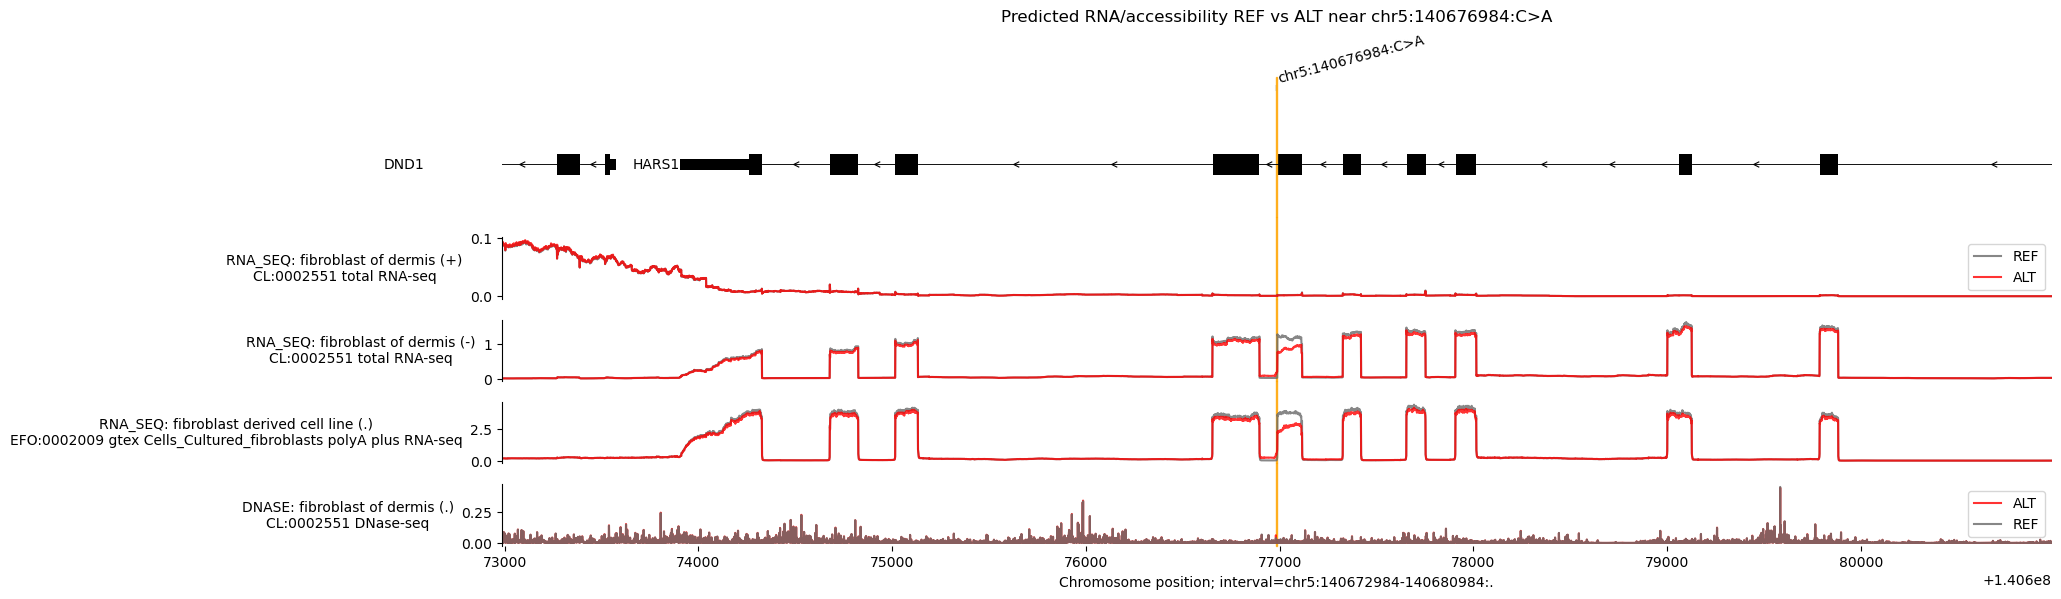

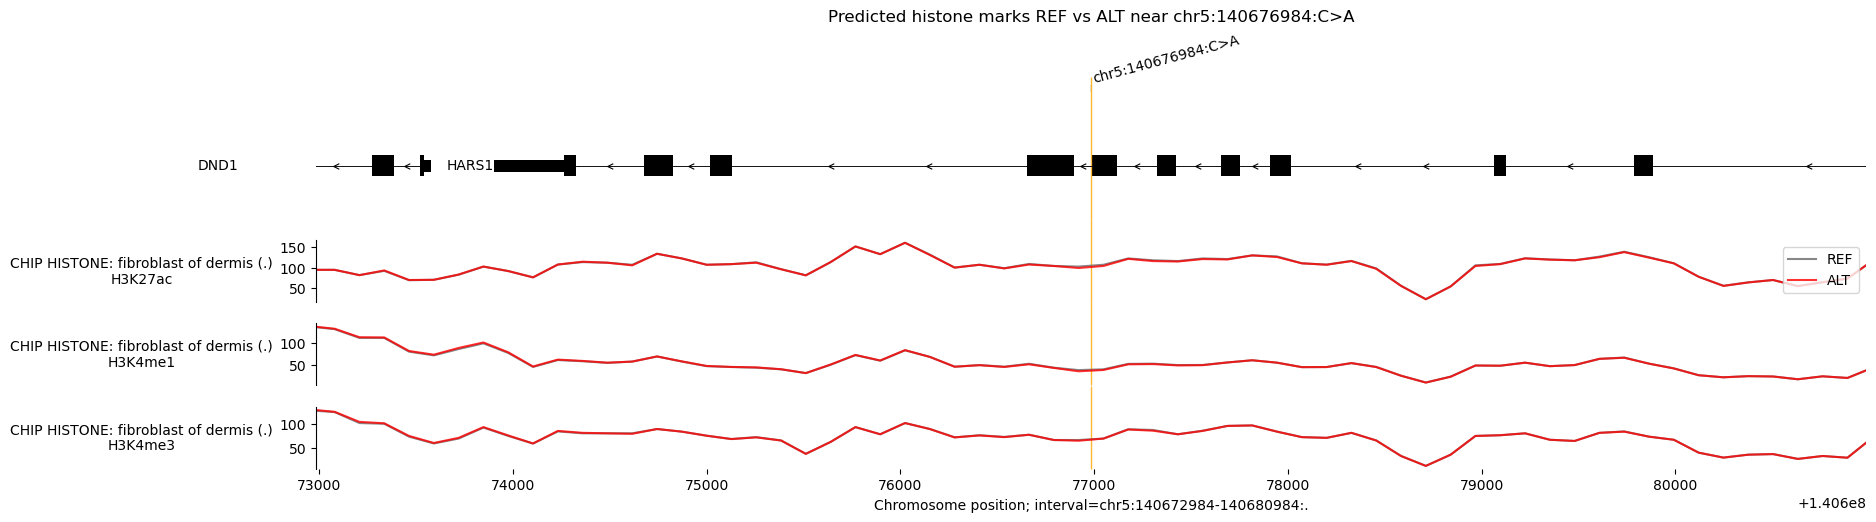

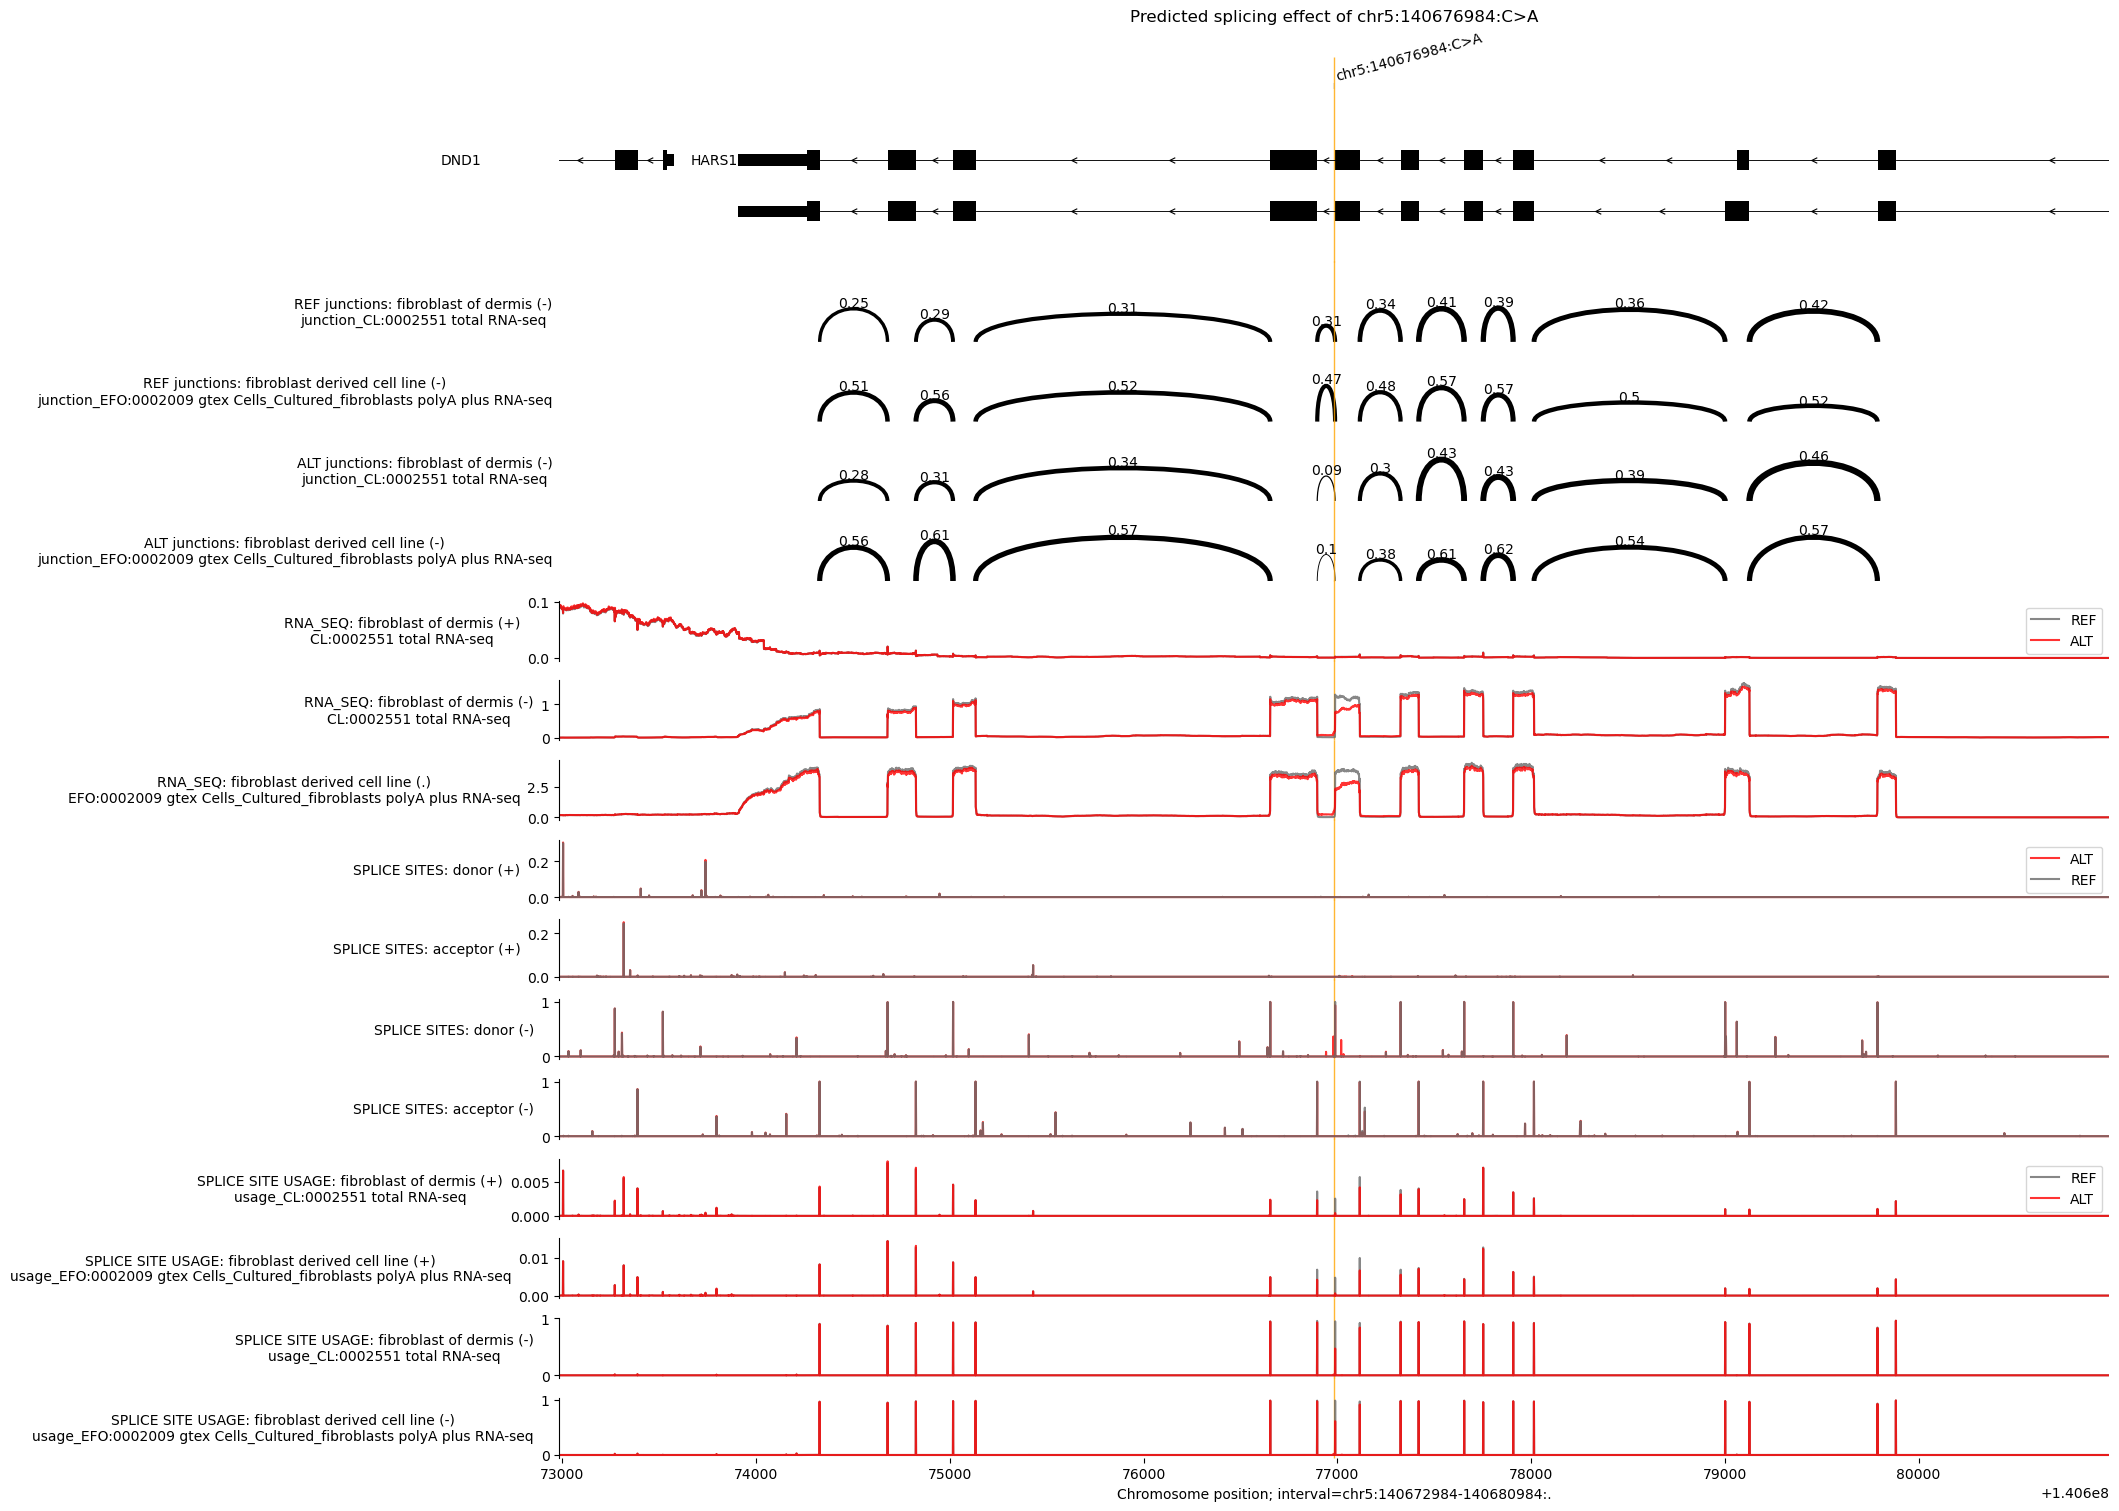

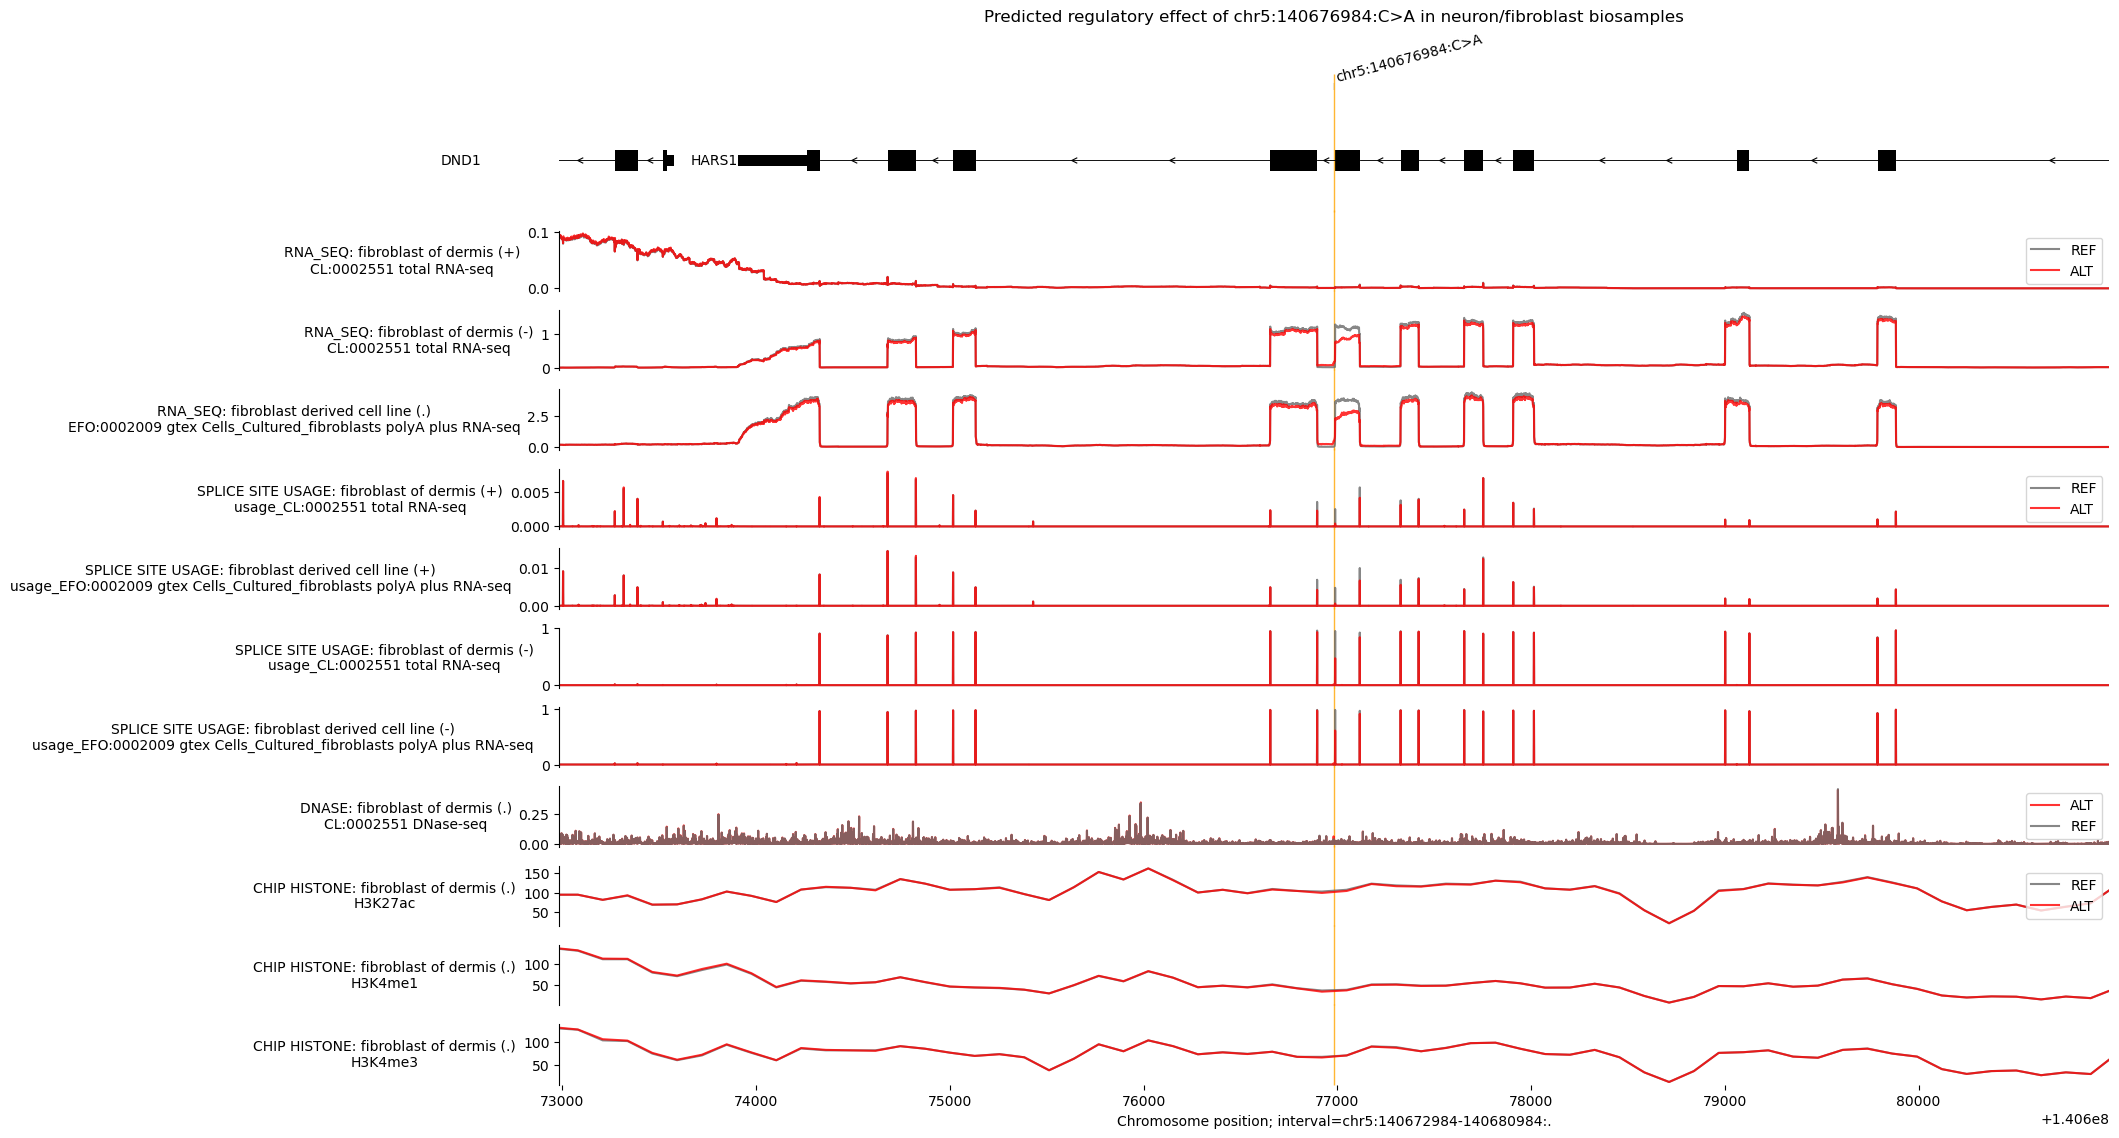


Saved outputs to: alphagenome_Fibroblast_variant_HARS1_chr5_140676984_C_A_splicedonor_plots_

REF RNA_SEQ metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
1,CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
2,EFO:0002009 gtex Cells_Cultured_fibroblasts po...,.,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,paired,False,0.056562



REF DNASE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 DNase-seq,.,DNase-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,encode,single,False,1.079167



REF ATAC metadata:


...

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K27ac,encode,single,False,1.049457
2,CL:0002551 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K4me1,encode,single,False,1.037979
4,CL:0002551 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,"adult,unknown",H3K4me3,encode,single,False,0.947388



REF SPLICE_SITE_USAGE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
1,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,+,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex
2,usage_CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
3,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,-,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex



REF SPLICE_JUNCTIONS metadata:


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0002551 total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,total RNA-seq
1,junction_EFO:0002009 gtex Cells_Cultured_fibro...,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,polyA plus RNA-seq


In [11]:
# PLot fibroblasts here

# ============================================================
# AlphaGenome variant visualization for chr8:24956773:G>C
# using YOUR OWN GENCODE file
# includes neuron + fibroblast + RNA + splicing
# ============================================================

# Optional install
# !pip install alphagenome pyarrow pandas matplotlib

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import gene_annotation, genome, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

# ============================================================
# 1. USER SETTINGS
# ============================================================

# ---- API key ----
# Option A: put your key here directly
API_KEY = ""

# Option B: or uncomment this and set an env var instead
# API_KEY = os.environ["ALPHAGENOME_API_KEY"]

# ---- Your GENCODE path ----
# Can be .feather or .gtf / .gtf.gz
GENCODE_PATH = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# ---- Variant of interest ----
VARIANT_STRING = "chr5:140676984:C>A"

# ---- Prediction interval width ----
PREDICTION_INTERVAL = dna_client.SEQUENCE_LENGTH_1MB

# ---- Plot zoom width around the variant ----
PLOT_WIDTH_BP = 8000

# ---- Optional enhancer annotation ----
ENHANCER_INTERVALS = [
    # genome.Interval("chr8", 24956000, 24957200, name="Nearby_enhancer")
]

# ---- Search words for neuron + fibroblast biosamples ----
# CELLTYPE_KEYWORDS = [
#     # Neuron-related
#     "neuron",
#     "neuronal",
#     "brain",
#     "cortex",
#     "cortical",
#     "cerebell",
#     "spinal",
#     "hippoc",
#     "motor neuron",
#     "neural",
# ]

CELLTYPE_KEYWORDS = {
    "fibroblast derived cell line",
    "fibroblast of dermis",
}

# ---- Histone marks to keep ----
HISTONE_KEEP = ["H3K27ac", "H3K4me1", "H3K4me3"]

# ---- Save figures? ----
SAVE_FIGURES = True
OUTDIR = "alphagenome_Fibroblast_variant_HARS1_chr5_140676984_C_A_splicedonor_plots_"

# ============================================================
# 2. CREATE MODEL
# ============================================================

dna_model = dna_client.create(API_KEY)

output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

# # ============================================================
# # 3. LOAD YOUR GENCODE FILE
# # ============================================================

# def parse_gtf_attributes(attr_string):
#     out = {}
#     if pd.isna(attr_string):
#         return out
#     matches = re.findall(r'(\S+)\s+"([^"]+)"', attr_string)
#     for key, val in matches:
#         out[key] = val
#     return out


# def load_gencode(path):
#     if path.endswith(".feather"):
#         return pd.read_feather(path)

#     gtf = pd.read_csv(
#         path,
#         sep="\t",
#         comment="#",
#         header=None,
#         compression="infer"
#     )

#     if gtf.shape[1] != 9:
#         raise ValueError(f"Expected 9 GTF columns, found {gtf.shape[1]}.")

#     gtf.columns = [
#         "Chromosome", "Source", "Feature", "Start", "End",
#         "Score", "Strand", "Frame", "Attributes"
#     ]

#     parsed = gtf["Attributes"].apply(parse_gtf_attributes).apply(pd.Series)
#     gtf = pd.concat([gtf, parsed], axis=1)

#     gtf["Chromosome"] = gtf["Chromosome"].astype(str)
#     gtf["Chromosome"] = gtf["Chromosome"].apply(
#         lambda x: x if x.startswith("chr") else f"chr{x}"
#     )

#     gtf["Start"] = pd.to_numeric(gtf["Start"], errors="coerce")
#     gtf["End"] = pd.to_numeric(gtf["End"], errors="coerce")

#     if "gene_type" not in gtf.columns and "gene_biotype" in gtf.columns:
#         gtf["gene_type"] = gtf["gene_biotype"]

#     if "transcript_type" not in gtf.columns and "transcript_biotype" in gtf.columns:
#         gtf["transcript_type"] = gtf["transcript_biotype"]

#     return gtf


# gtf = load_gencode(GENCODE_PATH)

# gtf_transcript = gene_annotation.filter_transcript_support_level(
#     gene_annotation.filter_protein_coding(gtf), ['1']
# )

# transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
#     gtf_transcript
# )

# longest_transcript_extractor = transcript.TranscriptExtractor(
#     gtf_longest_transcript
# )

# print("Loaded GENCODE.")
# print(f"Rows: {len(gtf):,}")

# ============================================================
# 4. DEFINE VARIANT AND INTERVAL
# ============================================================

variant = genome.Variant.from_str(VARIANT_STRING)
print("\nVariant:")
print(variant)

interval = variant.reference_interval.resize(PREDICTION_INTERVAL)
plot_interval = variant.reference_interval.resize(PLOT_WIDTH_BP)

print("\nPrediction interval:")
print(interval)

print("\nPlot interval:")
print(plot_interval)

# Longest transcripts for cleaner annotation
longest_transcripts = longest_transcript_extractor.extract(interval)

# Full transcripts are useful for splicing plots
all_transcripts = transcript_extractor.extract(interval)

# ============================================================
# 5. FIND MATCHING ONTOLOGY TERMS
# ============================================================

def find_matching_ontology_terms(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return []

    cols_to_search = []
    for c in ["biosample_name", "biosample_type", "ontology_curie", "name", "Assay title"]:
        if c in metadata_df.columns:
            cols_to_search.append(c)

    if len(cols_to_search) == 0:
        return []

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)

    matches = metadata_df.loc[mask].copy()

    if "ontology_curie" not in matches.columns:
        return []

    return sorted(matches["ontology_curie"].dropna().astype(str).unique().tolist())


dnase_terms = find_matching_ontology_terms(output_metadata.dnase, CELLTYPE_KEYWORDS)
atac_terms = find_matching_ontology_terms(output_metadata.atac, CELLTYPE_KEYWORDS)
chip_histone_terms = find_matching_ontology_terms(output_metadata.chip_histone, CELLTYPE_KEYWORDS)
rna_seq_terms = find_matching_ontology_terms(output_metadata.rna_seq, CELLTYPE_KEYWORDS)
splice_usage_terms = find_matching_ontology_terms(output_metadata.splice_site_usage, CELLTYPE_KEYWORDS)
splice_junction_terms = find_matching_ontology_terms(output_metadata.splice_junctions, CELLTYPE_KEYWORDS)

all_terms = sorted(
    set(dnase_terms)
    | set(atac_terms)
    | set(chip_histone_terms)
    | set(rna_seq_terms)
    | set(splice_usage_terms)
    | set(splice_junction_terms)
)

print("\nNeuron/fibroblast-related ontology terms found:")
print(all_terms[:100])
print(f"Total found: {len(all_terms)}")

if len(all_terms) == 0:
    print("\nWarning: no matching ontology terms were found.")

# ============================================================
# 6. RUN PREDICT_VARIANT
# ============================================================

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=all_terms if len(all_terms) > 0 else None,
)

ref_alt_colors = {"REF": "dimgrey", "ALT": "red"}

# ============================================================
# 7. FILTER TRACKS TO MATCHING BIOSAMPLES
# ============================================================

def metadata_keyword_mask(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.Series([], dtype=bool)

    cols_to_search = [
        c for c in ["biosample_name", "biosample_type", "ontology_curie", "name"]
        if c in metadata_df.columns
    ]
    if len(cols_to_search) == 0:
        return pd.Series([True] * len(metadata_df), index=metadata_df.index)

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)
    return mask


def filter_trackdata_by_keywords(tdata, keywords):
    if tdata is None:
        return tdata
    md = tdata.metadata
    if md is None or len(md) == 0:
        return tdata
    mask = metadata_keyword_mask(md, keywords)
    if len(mask) == 0 or mask.sum() == 0:
        return tdata
    return tdata.filter_tracks(mask.values)


ref_dnase = filter_trackdata_by_keywords(output.reference.dnase, CELLTYPE_KEYWORDS)
alt_dnase = filter_trackdata_by_keywords(output.alternate.dnase, CELLTYPE_KEYWORDS)

ref_atac = filter_trackdata_by_keywords(output.reference.atac, CELLTYPE_KEYWORDS)
alt_atac = filter_trackdata_by_keywords(output.alternate.atac, CELLTYPE_KEYWORDS)

ref_rna_seq = filter_trackdata_by_keywords(output.reference.rna_seq, CELLTYPE_KEYWORDS)
alt_rna_seq = filter_trackdata_by_keywords(output.alternate.rna_seq, CELLTYPE_KEYWORDS)

ref_splice_usage = filter_trackdata_by_keywords(output.reference.splice_site_usage, CELLTYPE_KEYWORDS)
alt_splice_usage = filter_trackdata_by_keywords(output.alternate.splice_site_usage, CELLTYPE_KEYWORDS)

ref_splice_junctions = filter_trackdata_by_keywords(output.reference.splice_junctions, CELLTYPE_KEYWORDS)
alt_splice_junctions = filter_trackdata_by_keywords(output.alternate.splice_junctions, CELLTYPE_KEYWORDS)

# splice_sites is tissue-agnostic, so use directly
ref_splice_sites = output.reference.splice_sites
alt_splice_sites = output.alternate.splice_sites

ref_chip_histone = filter_trackdata_by_keywords(output.reference.chip_histone, CELLTYPE_KEYWORDS)
alt_chip_histone = filter_trackdata_by_keywords(output.alternate.chip_histone, CELLTYPE_KEYWORDS)

# Keep only selected histone marks
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_chip_histone = ref_chip_histone.filter_tracks(
        ref_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_chip_histone = alt_chip_histone.filter_tracks(
        alt_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

# Safe reordering using positional indices
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_order = (
        ref_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    ref_chip_histone = ref_chip_histone.select_tracks_by_index(ref_order)

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_order = (
        alt_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    alt_chip_histone = alt_chip_histone.select_tracks_by_index(alt_order)

# ============================================================
# 8. BUILD ANNOTATIONS
# ============================================================

annotations = [plot_components.VariantAnnotation([variant])]

if len(ENHANCER_INTERVALS) > 0:
    annotations.append(plot_components.IntervalAnnotation(ENHANCER_INTERVALS))

# ============================================================
# 9. PLOT RNA + ACCESSIBILITY
# ============================================================

plot1 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted RNA/accessibility REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 10. PLOT CHIP_HISTONE
# ============================================================

plot2 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted histone marks REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 11. PLOT SPLICING
# ============================================================

plot3 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(all_transcripts),

        plot_components.Sashimi(
            ref_splice_junctions,
            ylabel_template="REF junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.Sashimi(
            alt_splice_junctions,
            ylabel_template="ALT junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_sites,
                "ALT": alt_splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITES: {name} ({strand})",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted splicing effect of {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 12. OPTIONAL COMBINED PLOT
# ============================================================

plot4 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),


        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted regulatory effect of {VARIANT_STRING} in neuron/fibroblast biosamples",
)

plt.show()

# ============================================================
# 13. OPTIONAL SAVE
# ============================================================

if SAVE_FIGURES:
    os.makedirs(OUTDIR, exist_ok=True)

    plot1.savefig(os.path.join(OUTDIR, "rna_dnase_atac_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot2.savefig(os.path.join(OUTDIR, "chip_histone_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot3.savefig(os.path.join(OUTDIR, "splicing_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot4.savefig(os.path.join(OUTDIR, "combined_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")

    if ref_rna_seq is not None:
        ref_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "ref_rna_seq_metadata.tsv"), sep="\t", index=False)
    if alt_rna_seq is not None:
        alt_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "alt_rna_seq_metadata.tsv"), sep="\t", index=False)

    if ref_dnase is not None:
        ref_dnase.metadata.to_csv(os.path.join(OUTDIR, "ref_dnase_metadata.tsv"), sep="\t", index=False)
    if alt_dnase is not None:
        alt_dnase.metadata.to_csv(os.path.join(OUTDIR, "alt_dnase_metadata.tsv"), sep="\t", index=False)

    if ref_atac is not None:
        ref_atac.metadata.to_csv(os.path.join(OUTDIR, "ref_atac_metadata.tsv"), sep="\t", index=False)
    if alt_atac is not None:
        alt_atac.metadata.to_csv(os.path.join(OUTDIR, "alt_atac_metadata.tsv"), sep="\t", index=False)

    if ref_chip_histone is not None:
        ref_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "ref_chip_histone_metadata.tsv"), sep="\t", index=False)
    if alt_chip_histone is not None:
        alt_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "alt_chip_histone_metadata.tsv"), sep="\t", index=False)

    if ref_splice_usage is not None:
        ref_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_usage_metadata.tsv"), sep="\t", index=False)
    if alt_splice_usage is not None:
        alt_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_usage_metadata.tsv"), sep="\t", index=False)

    if ref_splice_junctions is not None:
        ref_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_junctions_metadata.tsv"), sep="\t", index=False)
    if alt_splice_junctions is not None:
        alt_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_junctions_metadata.tsv"), sep="\t", index=False)

    print(f"\nSaved outputs to: {OUTDIR}")

# ============================================================
# 14. DISPLAY PLOTTED METADATA
# ============================================================

print("\nREF RNA_SEQ metadata:")
display(ref_rna_seq.metadata.head(20) if ref_rna_seq is not None else None)

print("\nREF DNASE metadata:")
display(ref_dnase.metadata.head(20) if ref_dnase is not None else None)

print("\nREF ATAC metadata:")
display(ref_atac.metadata.head(20) if ref_atac is not None else None)

print("\nREF CHIP_HISTONE metadata:")
display(ref_chip_histone.metadata.head(20) if ref_chip_histone is not None else None)

print("\nREF SPLICE_SITE_USAGE metadata:")
display(ref_splice_usage.metadata.head(20) if ref_splice_usage is not None else None)

print("\nREF SPLICE_JUNCTIONS metadata:")
display(ref_splice_junctions.metadata.head(20) if ref_splice_junctions is not None else None)

## ASL predict variant


Variant:
chr7:66089675:GGCGTCATCTCTAC>G

Prediction interval:
chr7:65565393-66613969:.

Plot interval:
chr7:66085681-66093681:.

Neuron/fibroblast-related ontology terms found:
['CL:0002551', 'EFO:0002009']
Total found: 2


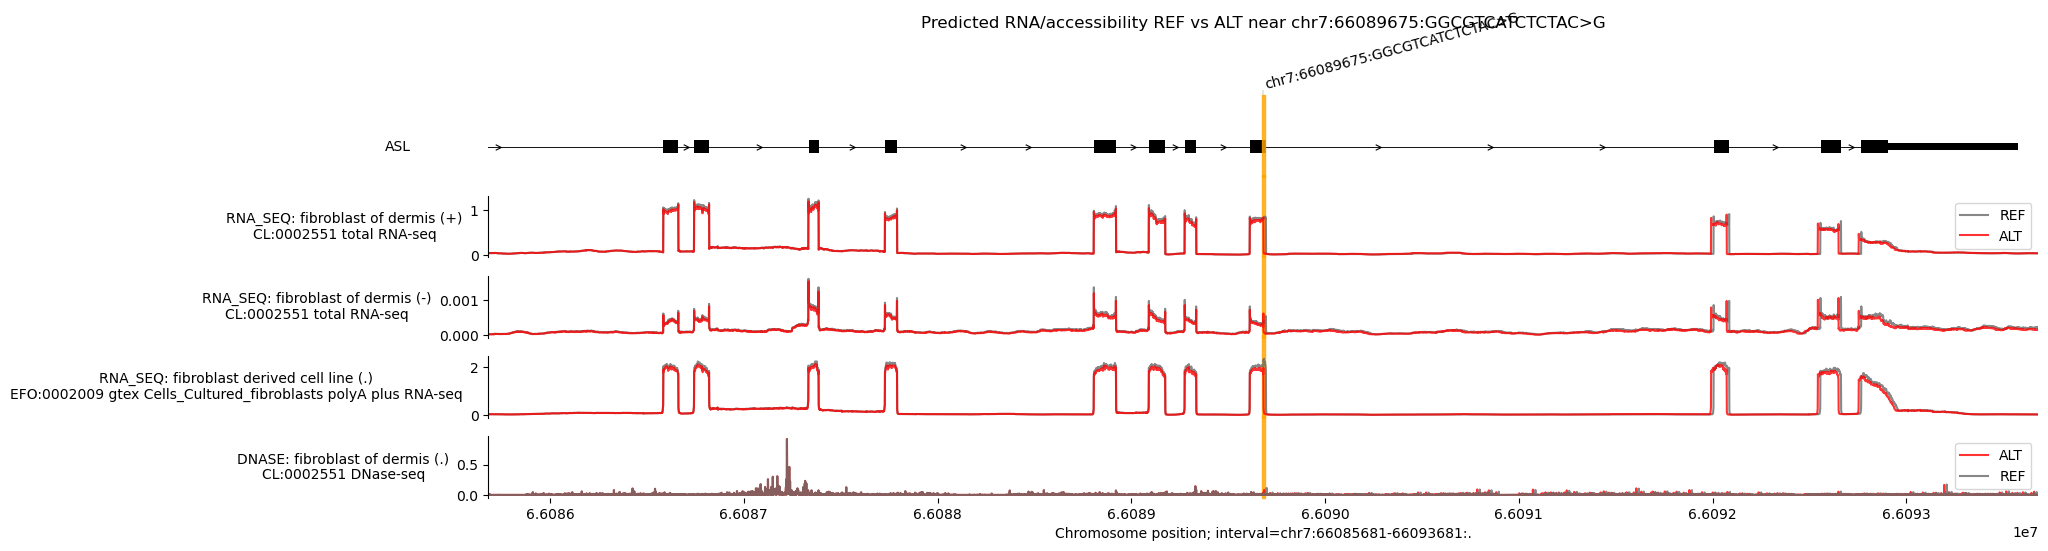

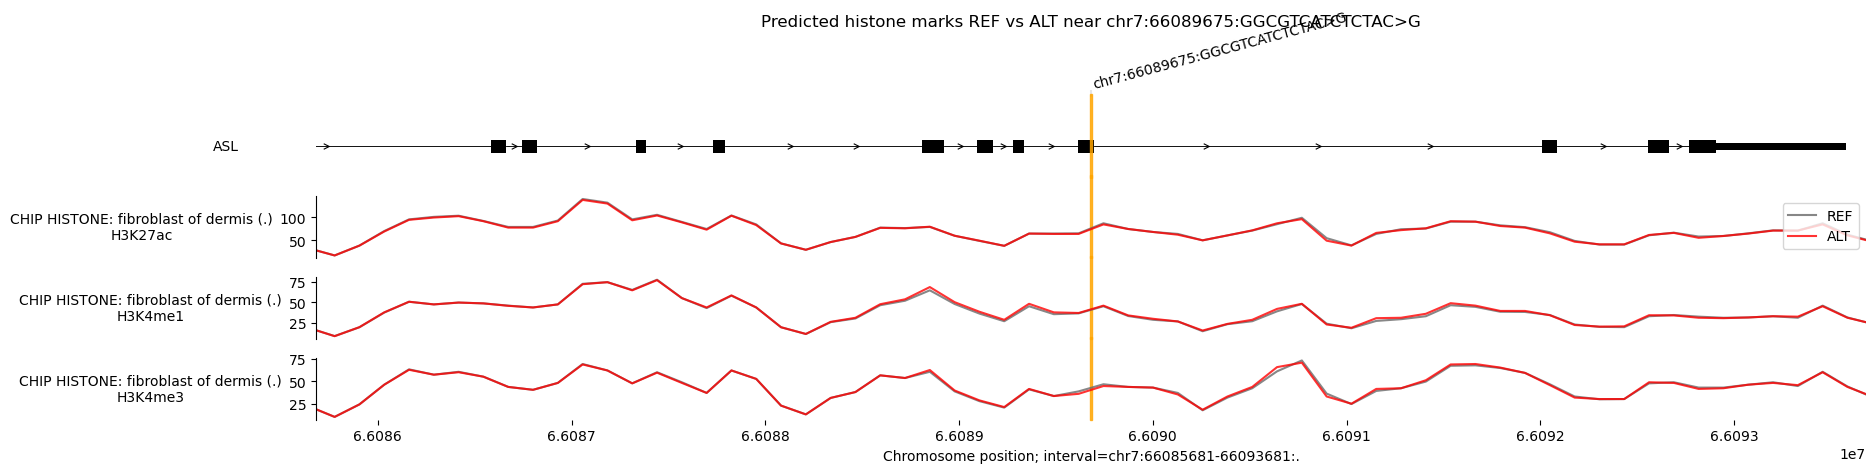

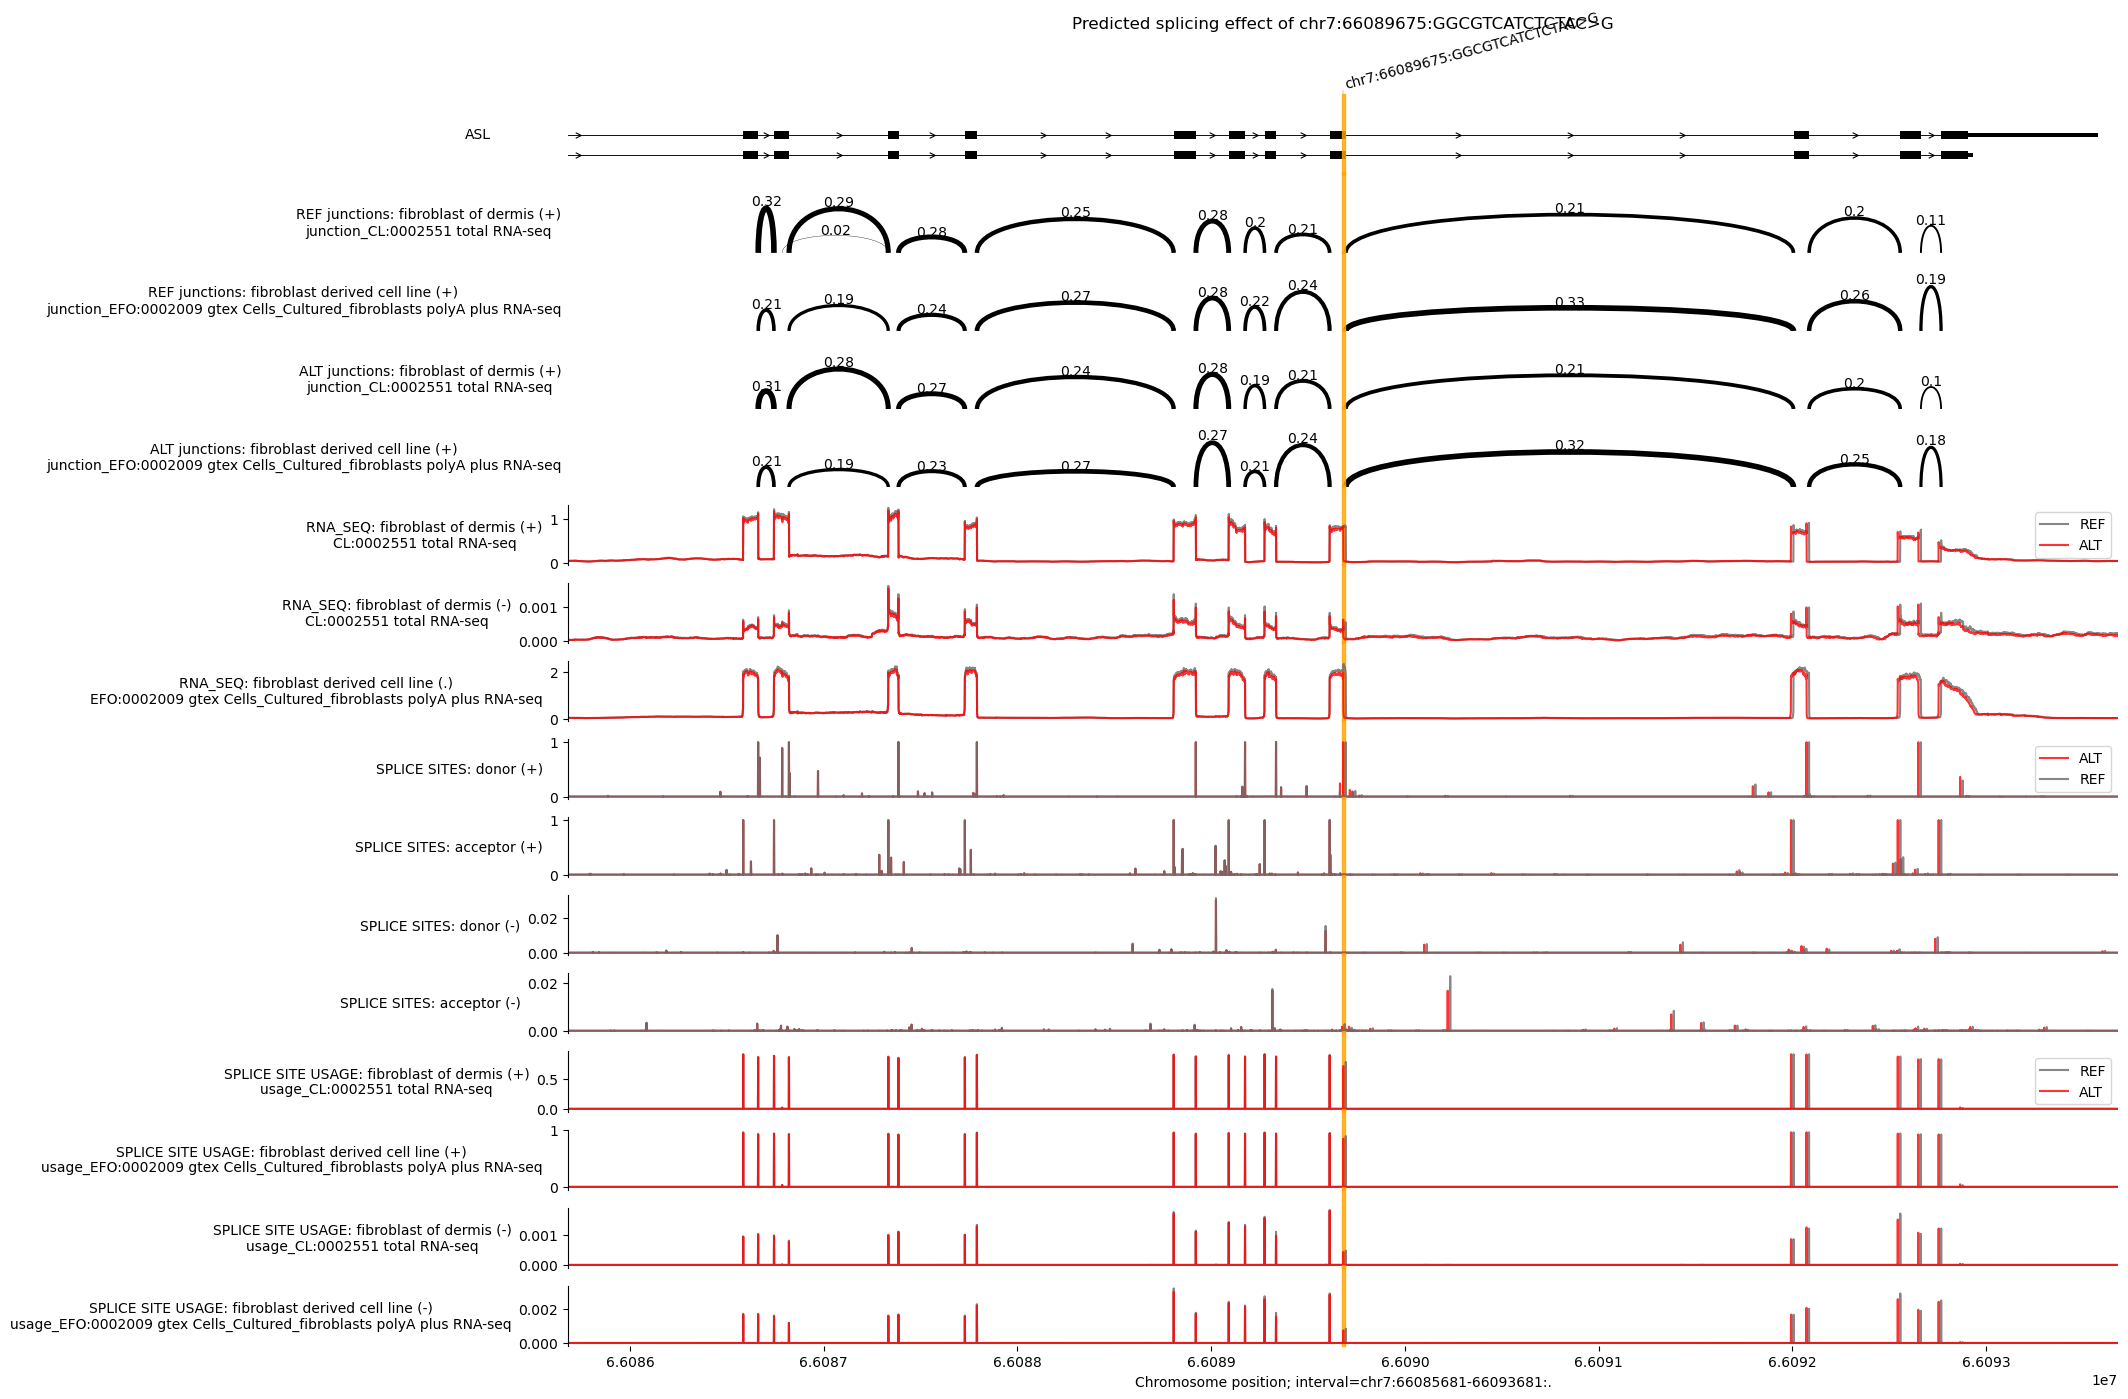

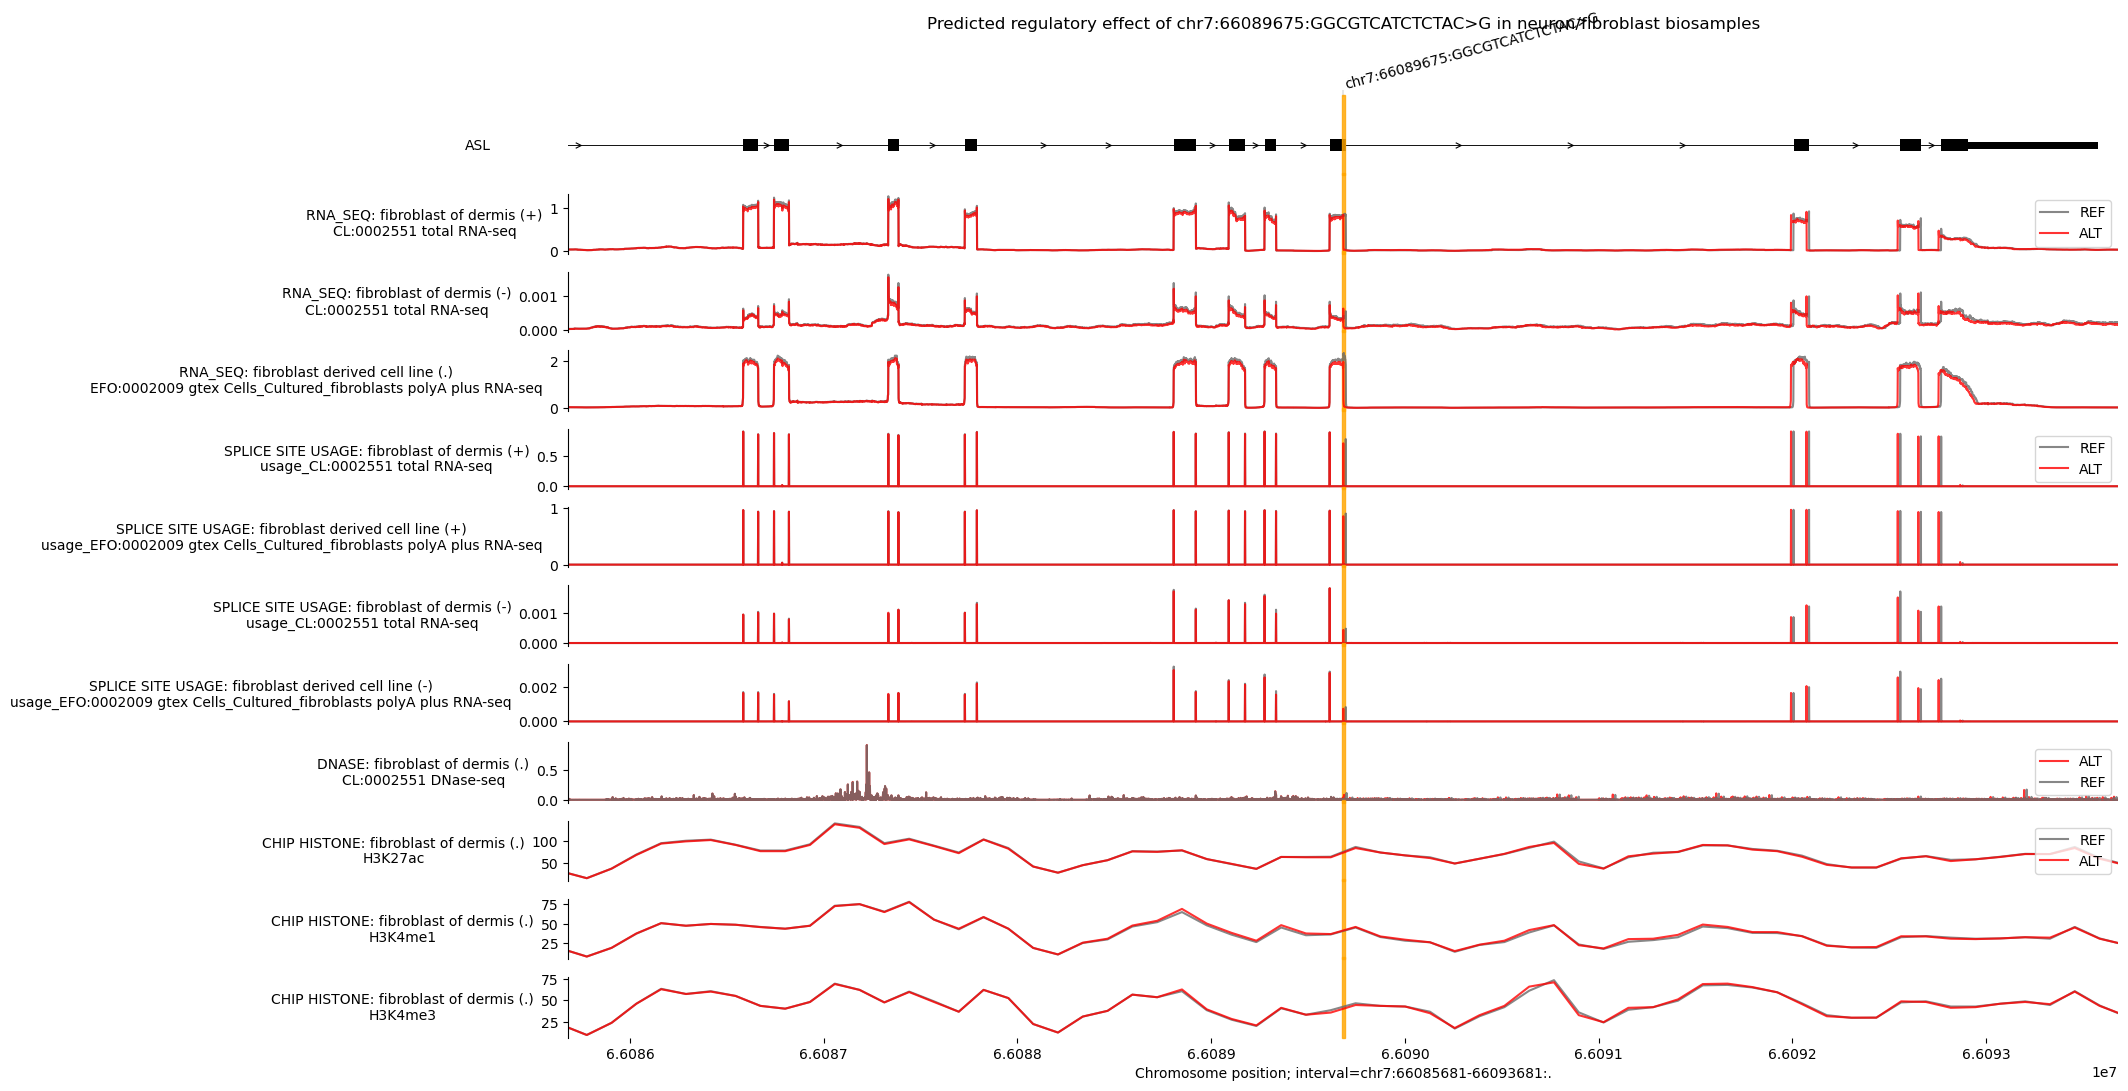


Saved outputs to: alphagenome_Fibroblast_variant_ASL_chr7_66089675_GGCGTCATCTCTAC_G_plots_

REF RNA_SEQ metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
1,CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
2,EFO:0002009 gtex Cells_Cultured_fibroblasts po...,.,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,paired,False,0.056562



REF DNASE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 DNase-seq,.,DNase-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,encode,single,False,1.079167



REF ATAC metadata:


...

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K27ac,encode,single,False,1.049457
2,CL:0002551 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K4me1,encode,single,False,1.037979
4,CL:0002551 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,"adult,unknown",H3K4me3,encode,single,False,0.947388



REF SPLICE_SITE_USAGE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
1,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,+,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex
2,usage_CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
3,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,-,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex



REF SPLICE_JUNCTIONS metadata:


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0002551 total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,total RNA-seq
1,junction_EFO:0002009 gtex Cells_Cultured_fibro...,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,polyA plus RNA-seq


In [12]:
# PLot fibroblasts here

# ============================================================
# AlphaGenome variant visualization for chr8:24956773:G>C
# using YOUR OWN GENCODE file
# includes neuron + fibroblast + RNA + splicing
# ============================================================

# Optional install
# !pip install alphagenome pyarrow pandas matplotlib

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import gene_annotation, genome, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

# ============================================================
# 1. USER SETTINGS
# ============================================================

# ---- API key ----
# Option A: put your key here directly
API_KEY = ""

# Option B: or uncomment this and set an env var instead
# API_KEY = os.environ["ALPHAGENOME_API_KEY"]

# ---- Your GENCODE path ----
# Can be .feather or .gtf / .gtf.gz
GENCODE_PATH = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# ---- Variant of interest ----
VARIANT_STRING = "chr7:66089675:GGCGTCATCTCTAC>G"

# ---- Prediction interval width ----
PREDICTION_INTERVAL = dna_client.SEQUENCE_LENGTH_1MB

# ---- Plot zoom width around the variant ----
PLOT_WIDTH_BP = 8000

# ---- Optional enhancer annotation ----
ENHANCER_INTERVALS = [
    # genome.Interval("chr8", 24956000, 24957200, name="Nearby_enhancer")
]

# ---- Search words for neuron + fibroblast biosamples ----
# CELLTYPE_KEYWORDS = [
#     # Neuron-related
#     "neuron",
#     "neuronal",
#     "brain",
#     "cortex",
#     "cortical",
#     "cerebell",
#     "spinal",
#     "hippoc",
#     "motor neuron",
#     "neural",
# ]

CELLTYPE_KEYWORDS = {
    "fibroblast derived cell line",
    "fibroblast of dermis",
}

# ---- Histone marks to keep ----
HISTONE_KEEP = ["H3K27ac", "H3K4me1", "H3K4me3"]

# ---- Save figures? ----
SAVE_FIGURES = True
OUTDIR = "alphagenome_Fibroblast_variant_ASL_chr7_66089675_GGCGTCATCTCTAC_G_plots_"

# ============================================================
# 2. CREATE MODEL
# ============================================================

dna_model = dna_client.create(API_KEY)

output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

# # ============================================================
# # 3. LOAD YOUR GENCODE FILE
# # ============================================================

# def parse_gtf_attributes(attr_string):
#     out = {}
#     if pd.isna(attr_string):
#         return out
#     matches = re.findall(r'(\S+)\s+"([^"]+)"', attr_string)
#     for key, val in matches:
#         out[key] = val
#     return out


# def load_gencode(path):
#     if path.endswith(".feather"):
#         return pd.read_feather(path)

#     gtf = pd.read_csv(
#         path,
#         sep="\t",
#         comment="#",
#         header=None,
#         compression="infer"
#     )

#     if gtf.shape[1] != 9:
#         raise ValueError(f"Expected 9 GTF columns, found {gtf.shape[1]}.")

#     gtf.columns = [
#         "Chromosome", "Source", "Feature", "Start", "End",
#         "Score", "Strand", "Frame", "Attributes"
#     ]

#     parsed = gtf["Attributes"].apply(parse_gtf_attributes).apply(pd.Series)
#     gtf = pd.concat([gtf, parsed], axis=1)

#     gtf["Chromosome"] = gtf["Chromosome"].astype(str)
#     gtf["Chromosome"] = gtf["Chromosome"].apply(
#         lambda x: x if x.startswith("chr") else f"chr{x}"
#     )

#     gtf["Start"] = pd.to_numeric(gtf["Start"], errors="coerce")
#     gtf["End"] = pd.to_numeric(gtf["End"], errors="coerce")

#     if "gene_type" not in gtf.columns and "gene_biotype" in gtf.columns:
#         gtf["gene_type"] = gtf["gene_biotype"]

#     if "transcript_type" not in gtf.columns and "transcript_biotype" in gtf.columns:
#         gtf["transcript_type"] = gtf["transcript_biotype"]

#     return gtf


# gtf = load_gencode(GENCODE_PATH)

# gtf_transcript = gene_annotation.filter_transcript_support_level(
#     gene_annotation.filter_protein_coding(gtf), ['1']
# )

# transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
#     gtf_transcript
# )

# longest_transcript_extractor = transcript.TranscriptExtractor(
#     gtf_longest_transcript
# )

# print("Loaded GENCODE.")
# print(f"Rows: {len(gtf):,}")

# ============================================================
# 4. DEFINE VARIANT AND INTERVAL
# ============================================================

variant = genome.Variant.from_str(VARIANT_STRING)
print("\nVariant:")
print(variant)

interval = variant.reference_interval.resize(PREDICTION_INTERVAL)
plot_interval = variant.reference_interval.resize(PLOT_WIDTH_BP)

print("\nPrediction interval:")
print(interval)

print("\nPlot interval:")
print(plot_interval)

# Longest transcripts for cleaner annotation
longest_transcripts = longest_transcript_extractor.extract(interval)

# Full transcripts are useful for splicing plots
all_transcripts = transcript_extractor.extract(interval)

# ============================================================
# 5. FIND MATCHING ONTOLOGY TERMS
# ============================================================

def find_matching_ontology_terms(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return []

    cols_to_search = []
    for c in ["biosample_name", "biosample_type", "ontology_curie", "name", "Assay title"]:
        if c in metadata_df.columns:
            cols_to_search.append(c)

    if len(cols_to_search) == 0:
        return []

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)

    matches = metadata_df.loc[mask].copy()

    if "ontology_curie" not in matches.columns:
        return []

    return sorted(matches["ontology_curie"].dropna().astype(str).unique().tolist())


dnase_terms = find_matching_ontology_terms(output_metadata.dnase, CELLTYPE_KEYWORDS)
atac_terms = find_matching_ontology_terms(output_metadata.atac, CELLTYPE_KEYWORDS)
chip_histone_terms = find_matching_ontology_terms(output_metadata.chip_histone, CELLTYPE_KEYWORDS)
rna_seq_terms = find_matching_ontology_terms(output_metadata.rna_seq, CELLTYPE_KEYWORDS)
splice_usage_terms = find_matching_ontology_terms(output_metadata.splice_site_usage, CELLTYPE_KEYWORDS)
splice_junction_terms = find_matching_ontology_terms(output_metadata.splice_junctions, CELLTYPE_KEYWORDS)

all_terms = sorted(
    set(dnase_terms)
    | set(atac_terms)
    | set(chip_histone_terms)
    | set(rna_seq_terms)
    | set(splice_usage_terms)
    | set(splice_junction_terms)
)

print("\nNeuron/fibroblast-related ontology terms found:")
print(all_terms[:100])
print(f"Total found: {len(all_terms)}")

if len(all_terms) == 0:
    print("\nWarning: no matching ontology terms were found.")

# ============================================================
# 6. RUN PREDICT_VARIANT
# ============================================================

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=all_terms if len(all_terms) > 0 else None,
)

ref_alt_colors = {"REF": "dimgrey", "ALT": "red"}

# ============================================================
# 7. FILTER TRACKS TO MATCHING BIOSAMPLES
# ============================================================

def metadata_keyword_mask(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.Series([], dtype=bool)

    cols_to_search = [
        c for c in ["biosample_name", "biosample_type", "ontology_curie", "name"]
        if c in metadata_df.columns
    ]
    if len(cols_to_search) == 0:
        return pd.Series([True] * len(metadata_df), index=metadata_df.index)

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)
    return mask


def filter_trackdata_by_keywords(tdata, keywords):
    if tdata is None:
        return tdata
    md = tdata.metadata
    if md is None or len(md) == 0:
        return tdata
    mask = metadata_keyword_mask(md, keywords)
    if len(mask) == 0 or mask.sum() == 0:
        return tdata
    return tdata.filter_tracks(mask.values)


ref_dnase = filter_trackdata_by_keywords(output.reference.dnase, CELLTYPE_KEYWORDS)
alt_dnase = filter_trackdata_by_keywords(output.alternate.dnase, CELLTYPE_KEYWORDS)

ref_atac = filter_trackdata_by_keywords(output.reference.atac, CELLTYPE_KEYWORDS)
alt_atac = filter_trackdata_by_keywords(output.alternate.atac, CELLTYPE_KEYWORDS)

ref_rna_seq = filter_trackdata_by_keywords(output.reference.rna_seq, CELLTYPE_KEYWORDS)
alt_rna_seq = filter_trackdata_by_keywords(output.alternate.rna_seq, CELLTYPE_KEYWORDS)

ref_splice_usage = filter_trackdata_by_keywords(output.reference.splice_site_usage, CELLTYPE_KEYWORDS)
alt_splice_usage = filter_trackdata_by_keywords(output.alternate.splice_site_usage, CELLTYPE_KEYWORDS)

ref_splice_junctions = filter_trackdata_by_keywords(output.reference.splice_junctions, CELLTYPE_KEYWORDS)
alt_splice_junctions = filter_trackdata_by_keywords(output.alternate.splice_junctions, CELLTYPE_KEYWORDS)

# splice_sites is tissue-agnostic, so use directly
ref_splice_sites = output.reference.splice_sites
alt_splice_sites = output.alternate.splice_sites

ref_chip_histone = filter_trackdata_by_keywords(output.reference.chip_histone, CELLTYPE_KEYWORDS)
alt_chip_histone = filter_trackdata_by_keywords(output.alternate.chip_histone, CELLTYPE_KEYWORDS)

# Keep only selected histone marks
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_chip_histone = ref_chip_histone.filter_tracks(
        ref_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_chip_histone = alt_chip_histone.filter_tracks(
        alt_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

# Safe reordering using positional indices
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_order = (
        ref_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    ref_chip_histone = ref_chip_histone.select_tracks_by_index(ref_order)

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_order = (
        alt_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    alt_chip_histone = alt_chip_histone.select_tracks_by_index(alt_order)

# ============================================================
# 8. BUILD ANNOTATIONS
# ============================================================

annotations = [plot_components.VariantAnnotation([variant])]

if len(ENHANCER_INTERVALS) > 0:
    annotations.append(plot_components.IntervalAnnotation(ENHANCER_INTERVALS))

# ============================================================
# 9. PLOT RNA + ACCESSIBILITY
# ============================================================

plot1 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted RNA/accessibility REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 10. PLOT CHIP_HISTONE
# ============================================================

plot2 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted histone marks REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 11. PLOT SPLICING
# ============================================================

plot3 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(all_transcripts),

        plot_components.Sashimi(
            ref_splice_junctions,
            ylabel_template="REF junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.Sashimi(
            alt_splice_junctions,
            ylabel_template="ALT junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_sites,
                "ALT": alt_splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITES: {name} ({strand})",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted splicing effect of {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 12. OPTIONAL COMBINED PLOT
# ============================================================

plot4 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),


        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted regulatory effect of {VARIANT_STRING} in neuron/fibroblast biosamples",
)

plt.show()

# ============================================================
# 13. OPTIONAL SAVE
# ============================================================

if SAVE_FIGURES:
    os.makedirs(OUTDIR, exist_ok=True)

    plot1.savefig(os.path.join(OUTDIR, "rna_dnase_atac_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot2.savefig(os.path.join(OUTDIR, "chip_histone_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot3.savefig(os.path.join(OUTDIR, "splicing_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot4.savefig(os.path.join(OUTDIR, "combined_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")

    if ref_rna_seq is not None:
        ref_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "ref_rna_seq_metadata.tsv"), sep="\t", index=False)
    if alt_rna_seq is not None:
        alt_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "alt_rna_seq_metadata.tsv"), sep="\t", index=False)

    if ref_dnase is not None:
        ref_dnase.metadata.to_csv(os.path.join(OUTDIR, "ref_dnase_metadata.tsv"), sep="\t", index=False)
    if alt_dnase is not None:
        alt_dnase.metadata.to_csv(os.path.join(OUTDIR, "alt_dnase_metadata.tsv"), sep="\t", index=False)

    if ref_atac is not None:
        ref_atac.metadata.to_csv(os.path.join(OUTDIR, "ref_atac_metadata.tsv"), sep="\t", index=False)
    if alt_atac is not None:
        alt_atac.metadata.to_csv(os.path.join(OUTDIR, "alt_atac_metadata.tsv"), sep="\t", index=False)

    if ref_chip_histone is not None:
        ref_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "ref_chip_histone_metadata.tsv"), sep="\t", index=False)
    if alt_chip_histone is not None:
        alt_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "alt_chip_histone_metadata.tsv"), sep="\t", index=False)

    if ref_splice_usage is not None:
        ref_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_usage_metadata.tsv"), sep="\t", index=False)
    if alt_splice_usage is not None:
        alt_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_usage_metadata.tsv"), sep="\t", index=False)

    if ref_splice_junctions is not None:
        ref_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_junctions_metadata.tsv"), sep="\t", index=False)
    if alt_splice_junctions is not None:
        alt_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_junctions_metadata.tsv"), sep="\t", index=False)

    print(f"\nSaved outputs to: {OUTDIR}")

# ============================================================
# 14. DISPLAY PLOTTED METADATA
# ============================================================

print("\nREF RNA_SEQ metadata:")
display(ref_rna_seq.metadata.head(20) if ref_rna_seq is not None else None)

print("\nREF DNASE metadata:")
display(ref_dnase.metadata.head(20) if ref_dnase is not None else None)

print("\nREF ATAC metadata:")
display(ref_atac.metadata.head(20) if ref_atac is not None else None)

print("\nREF CHIP_HISTONE metadata:")
display(ref_chip_histone.metadata.head(20) if ref_chip_histone is not None else None)

print("\nREF SPLICE_SITE_USAGE metadata:")
display(ref_splice_usage.metadata.head(20) if ref_splice_usage is not None else None)

print("\nREF SPLICE_JUNCTIONS metadata:")
display(ref_splice_junctions.metadata.head(20) if ref_splice_junctions is not None else None)


Variant:
chr7:66089675:GGCGTCATCTCTAC>G

Prediction interval:
chr7:65565393-66613969:.

Plot interval:
chr7:66089281-66090081:.

Neuron/fibroblast-related ontology terms found:
['CL:0002551', 'EFO:0002009']
Total found: 2


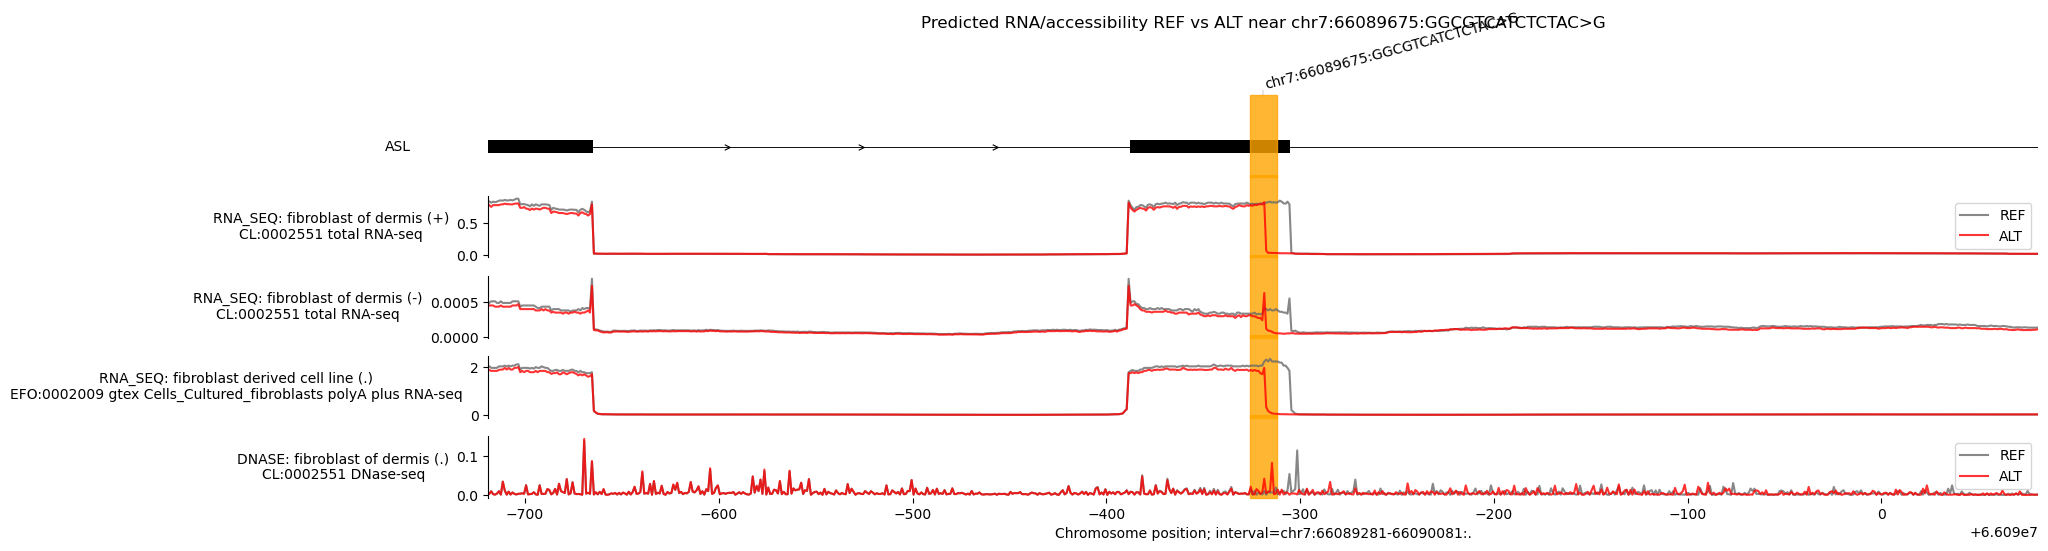

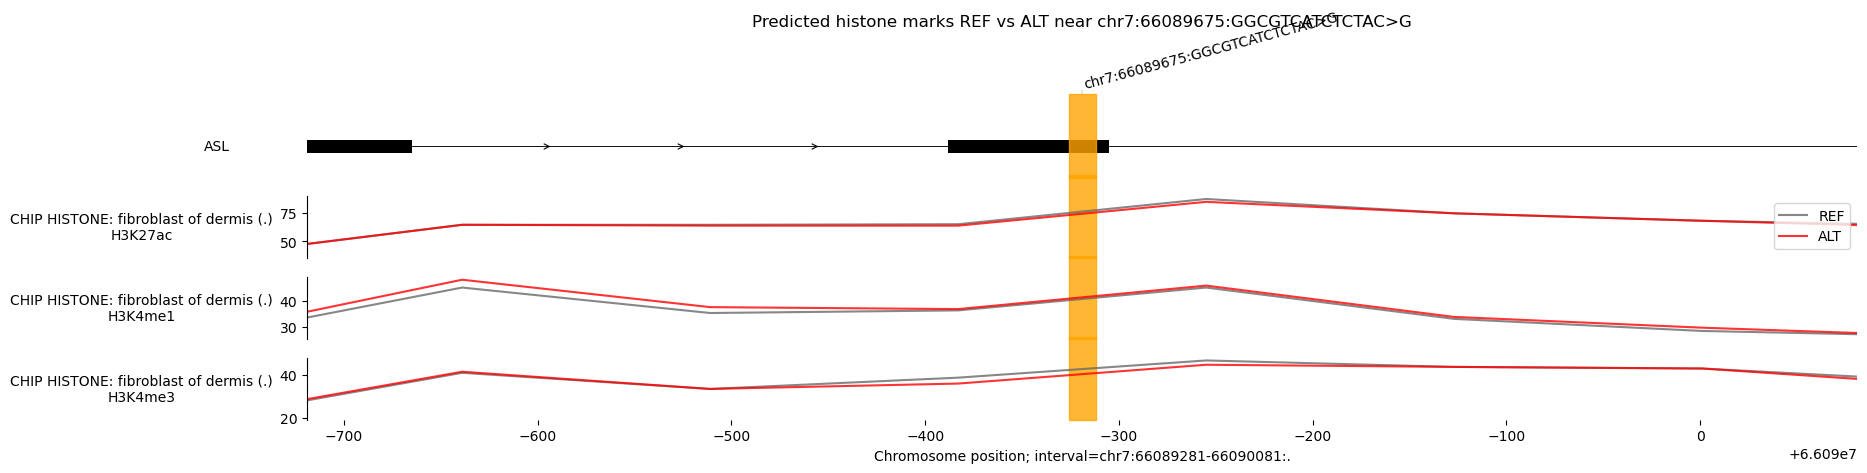

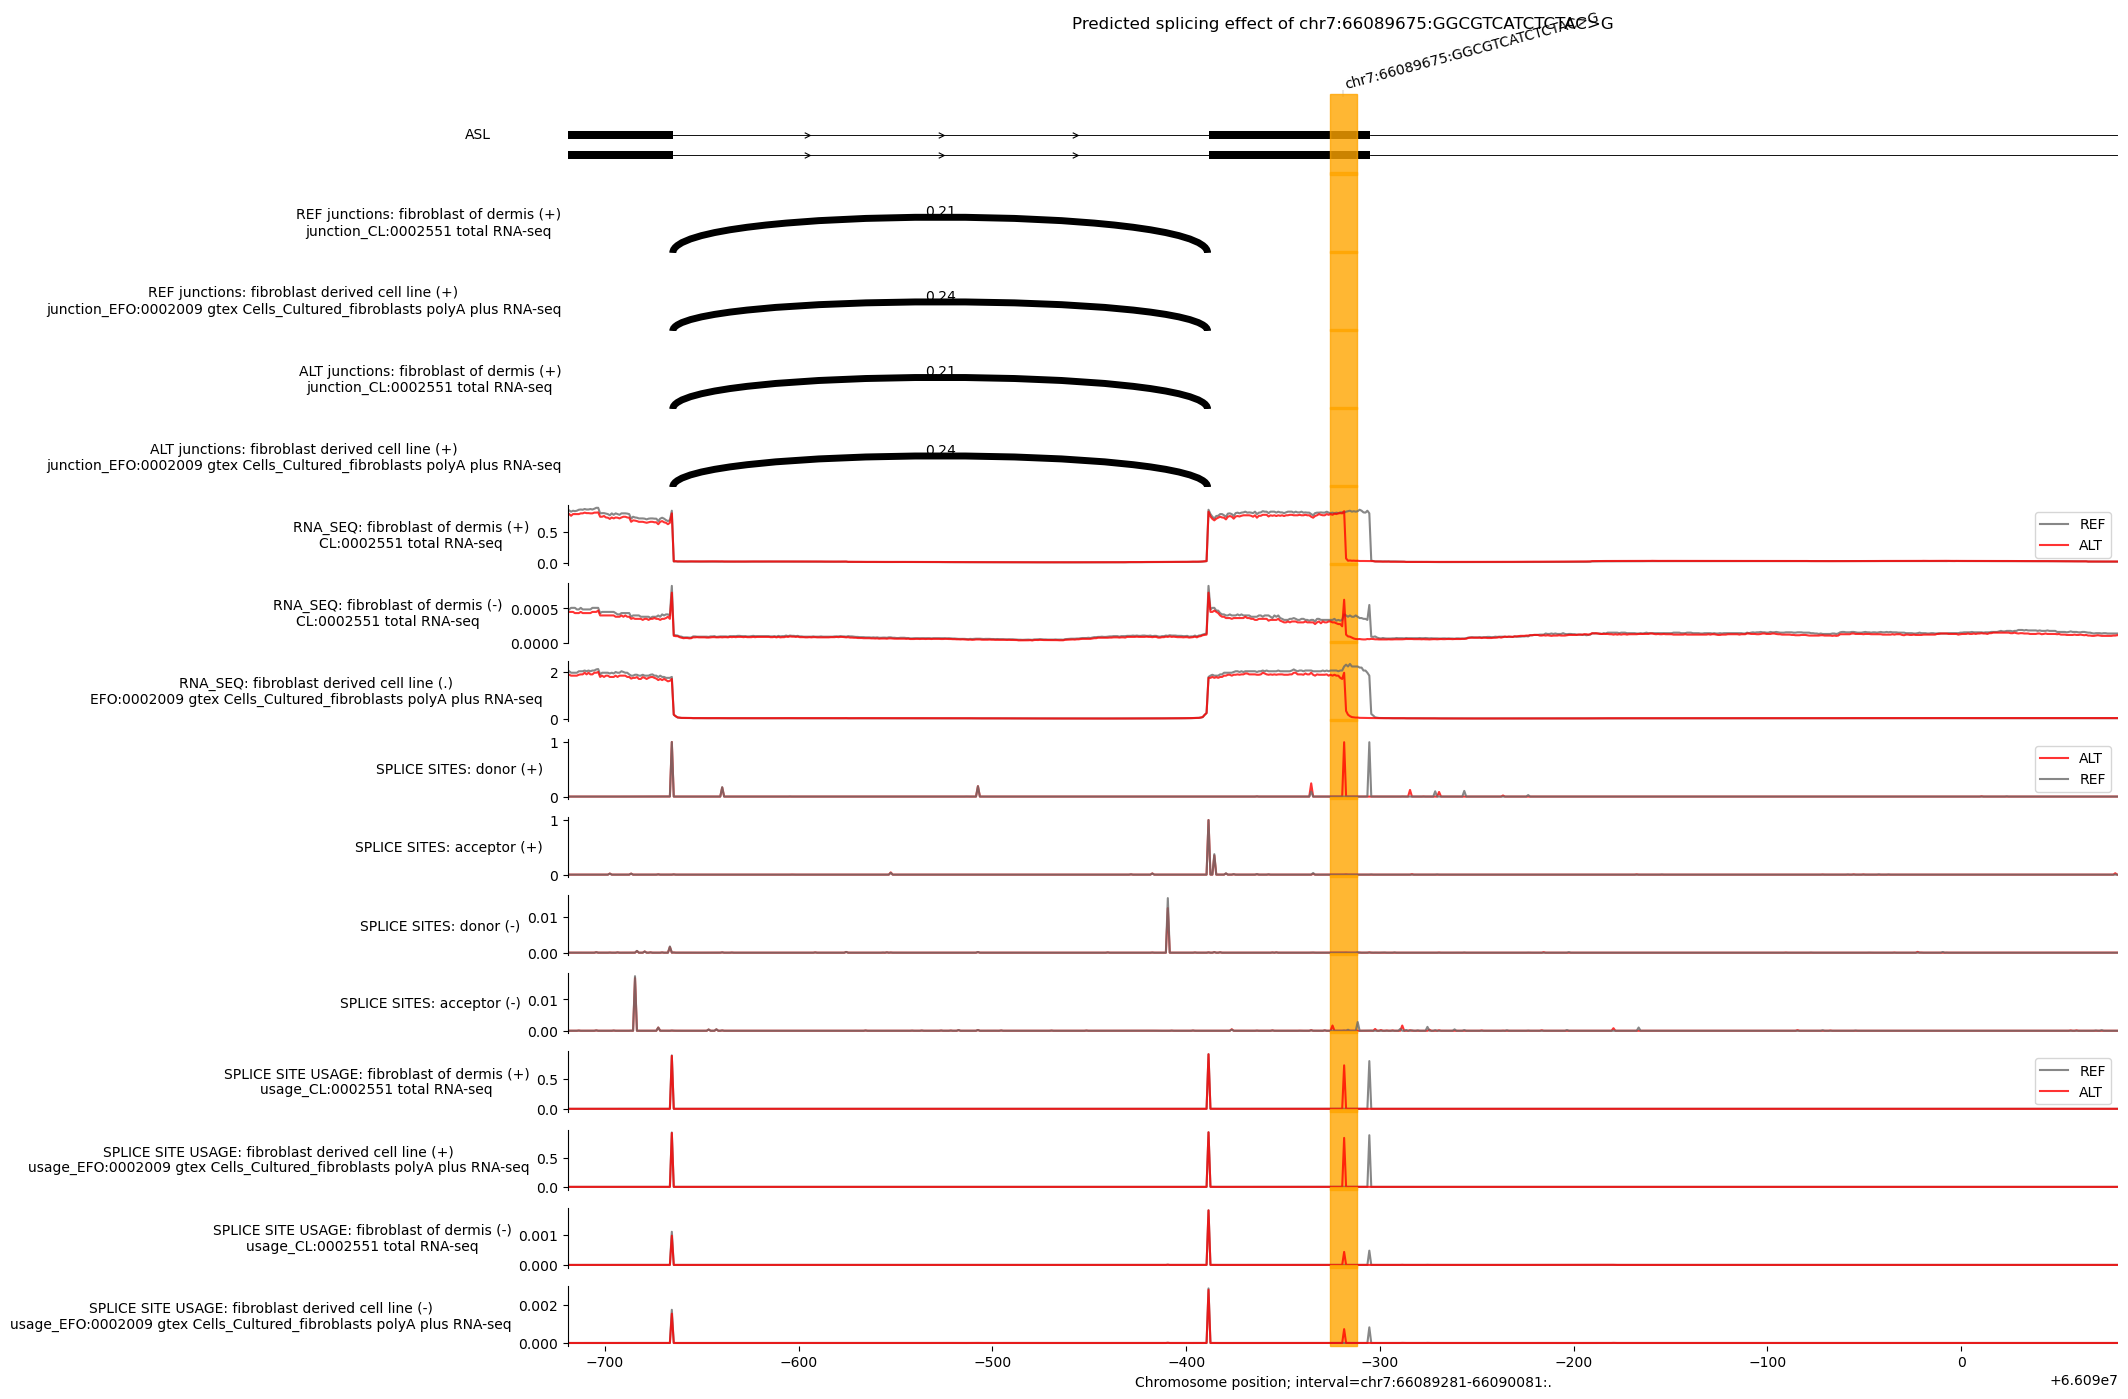

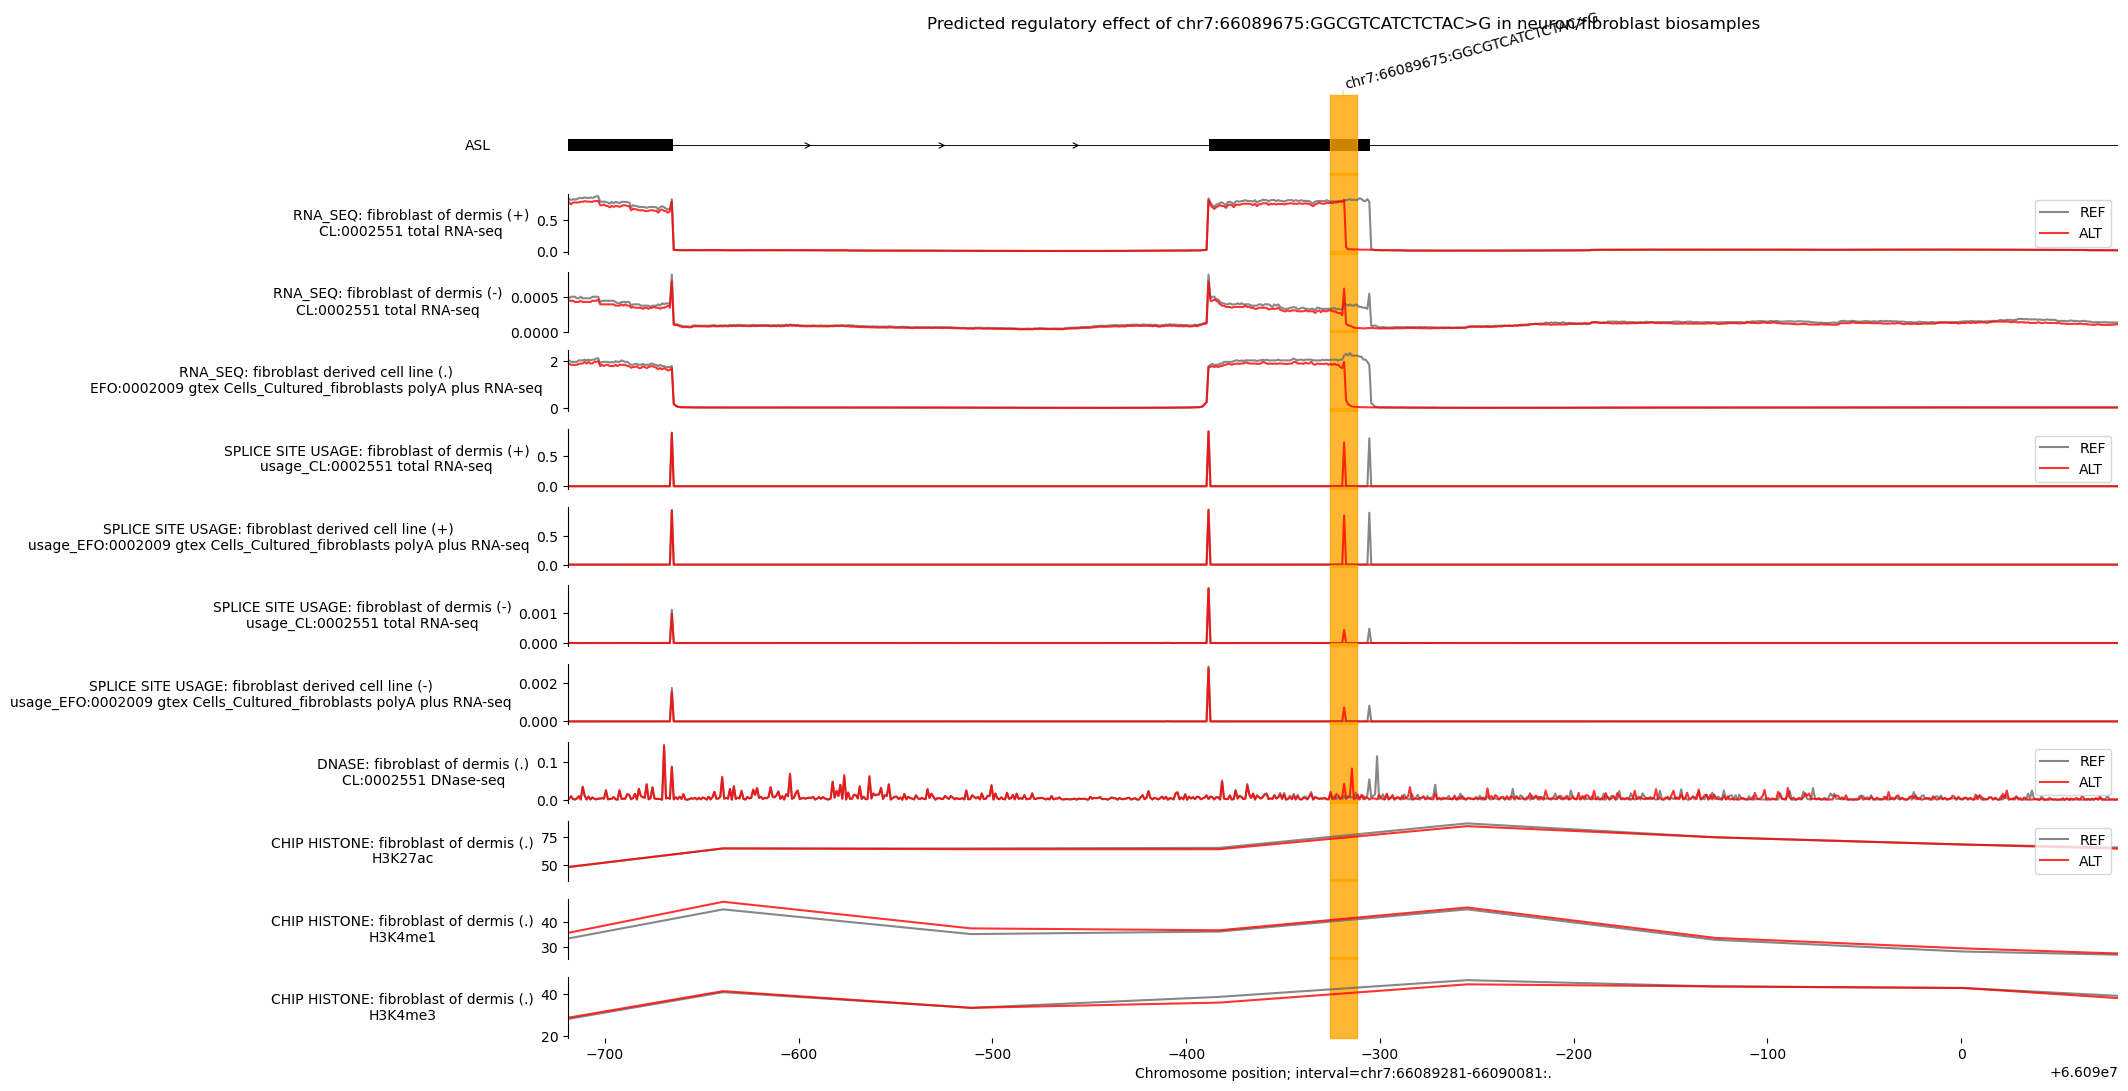


Saved outputs to: alphagenome_Fibroblast_variant_Zoomed_ASL_chr7_66089675_GGCGTCATCTCTAC_G_plots_

REF RNA_SEQ metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
1,CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,paired,False,0.086176
2,EFO:0002009 gtex Cells_Cultured_fibroblasts po...,.,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,paired,False,0.056562



REF DNASE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 DNase-seq,.,DNase-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,encode,single,False,1.079167



REF ATAC metadata:


...

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0002551 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K27ac,encode,single,False,1.049457
2,CL:0002551 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,unknown,H3K4me1,encode,single,False,1.037979
4,CL:0002551 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0002551,fibroblast of dermis,primary_cell,"adult,unknown",H3K4me3,encode,single,False,0.947388



REF SPLICE_SITE_USAGE metadata:


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0002551 total RNA-seq,+,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
1,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,+,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex
2,usage_CL:0002551 total RNA-seq,-,total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode
3,usage_EFO:0002009 gtex Cells_Cultured_fibrobla...,-,polyA plus RNA-seq,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex



REF SPLICE_JUNCTIONS metadata:


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0002551 total RNA-seq,CL:0002551,fibroblast of dermis,primary_cell,adult,,encode,total RNA-seq
1,junction_EFO:0002009 gtex Cells_Cultured_fibro...,EFO:0002009,fibroblast derived cell line,tissue,adult,Cells_Cultured_fibroblasts,gtex,polyA plus RNA-seq


In [13]:
# PLot fibroblasts here

# ============================================================
# AlphaGenome variant visualization for chr8:24956773:G>C
# using YOUR OWN GENCODE file
# includes neuron + fibroblast + RNA + splicing
# ============================================================

# Optional install
# !pip install alphagenome pyarrow pandas matplotlib

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

from alphagenome.data import gene_annotation, genome, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components

# ============================================================
# 1. USER SETTINGS
# ============================================================

# ---- API key ----
# Option A: put your key here directly
API_KEY = ""

# Option B: or uncomment this and set an env var instead
# API_KEY = os.environ["ALPHAGENOME_API_KEY"]

# ---- Your GENCODE path ----
# Can be .feather or .gtf / .gtf.gz
GENCODE_PATH = "/mmfs1/gscratch/stergachislab/yhhc/tools/Gencode/gencode.v47.annotation.gtf"

# ---- Variant of interest ----
VARIANT_STRING = "chr7:66089675:GGCGTCATCTCTAC>G"

# ---- Prediction interval width ----
PREDICTION_INTERVAL = dna_client.SEQUENCE_LENGTH_1MB

# ---- Plot zoom width around the variant ----
PLOT_WIDTH_BP = 800

# ---- Optional enhancer annotation ----
ENHANCER_INTERVALS = [
    # genome.Interval("chr8", 24956000, 24957200, name="Nearby_enhancer")
]

# ---- Search words for neuron + fibroblast biosamples ----
# CELLTYPE_KEYWORDS = [
#     # Neuron-related
#     "neuron",
#     "neuronal",
#     "brain",
#     "cortex",
#     "cortical",
#     "cerebell",
#     "spinal",
#     "hippoc",
#     "motor neuron",
#     "neural",
# ]

CELLTYPE_KEYWORDS = {
    "fibroblast derived cell line",
    "fibroblast of dermis",
}

# ---- Histone marks to keep ----
HISTONE_KEEP = ["H3K27ac", "H3K4me1", "H3K4me3"]

# ---- Save figures? ----
SAVE_FIGURES = True
OUTDIR = "alphagenome_Fibroblast_variant_Zoomed_ASL_chr7_66089675_GGCGTCATCTCTAC_G_plots_"

# ============================================================
# 2. CREATE MODEL
# ============================================================

dna_model = dna_client.create(API_KEY)

output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

# # ============================================================
# # 3. LOAD YOUR GENCODE FILE
# # ============================================================

# def parse_gtf_attributes(attr_string):
#     out = {}
#     if pd.isna(attr_string):
#         return out
#     matches = re.findall(r'(\S+)\s+"([^"]+)"', attr_string)
#     for key, val in matches:
#         out[key] = val
#     return out


# def load_gencode(path):
#     if path.endswith(".feather"):
#         return pd.read_feather(path)

#     gtf = pd.read_csv(
#         path,
#         sep="\t",
#         comment="#",
#         header=None,
#         compression="infer"
#     )

#     if gtf.shape[1] != 9:
#         raise ValueError(f"Expected 9 GTF columns, found {gtf.shape[1]}.")

#     gtf.columns = [
#         "Chromosome", "Source", "Feature", "Start", "End",
#         "Score", "Strand", "Frame", "Attributes"
#     ]

#     parsed = gtf["Attributes"].apply(parse_gtf_attributes).apply(pd.Series)
#     gtf = pd.concat([gtf, parsed], axis=1)

#     gtf["Chromosome"] = gtf["Chromosome"].astype(str)
#     gtf["Chromosome"] = gtf["Chromosome"].apply(
#         lambda x: x if x.startswith("chr") else f"chr{x}"
#     )

#     gtf["Start"] = pd.to_numeric(gtf["Start"], errors="coerce")
#     gtf["End"] = pd.to_numeric(gtf["End"], errors="coerce")

#     if "gene_type" not in gtf.columns and "gene_biotype" in gtf.columns:
#         gtf["gene_type"] = gtf["gene_biotype"]

#     if "transcript_type" not in gtf.columns and "transcript_biotype" in gtf.columns:
#         gtf["transcript_type"] = gtf["transcript_biotype"]

#     return gtf


# gtf = load_gencode(GENCODE_PATH)

# gtf_transcript = gene_annotation.filter_transcript_support_level(
#     gene_annotation.filter_protein_coding(gtf), ['1']
# )

# transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
#     gtf_transcript
# )

# longest_transcript_extractor = transcript.TranscriptExtractor(
#     gtf_longest_transcript
# )

# print("Loaded GENCODE.")
# print(f"Rows: {len(gtf):,}")

# ============================================================
# 4. DEFINE VARIANT AND INTERVAL
# ============================================================

variant = genome.Variant.from_str(VARIANT_STRING)
print("\nVariant:")
print(variant)

interval = variant.reference_interval.resize(PREDICTION_INTERVAL)
plot_interval = variant.reference_interval.resize(PLOT_WIDTH_BP)

print("\nPrediction interval:")
print(interval)

print("\nPlot interval:")
print(plot_interval)

# Longest transcripts for cleaner annotation
longest_transcripts = longest_transcript_extractor.extract(interval)

# Full transcripts are useful for splicing plots
all_transcripts = transcript_extractor.extract(interval)

# ============================================================
# 5. FIND MATCHING ONTOLOGY TERMS
# ============================================================

def find_matching_ontology_terms(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return []

    cols_to_search = []
    for c in ["biosample_name", "biosample_type", "ontology_curie", "name", "Assay title"]:
        if c in metadata_df.columns:
            cols_to_search.append(c)

    if len(cols_to_search) == 0:
        return []

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)

    matches = metadata_df.loc[mask].copy()

    if "ontology_curie" not in matches.columns:
        return []

    return sorted(matches["ontology_curie"].dropna().astype(str).unique().tolist())


dnase_terms = find_matching_ontology_terms(output_metadata.dnase, CELLTYPE_KEYWORDS)
atac_terms = find_matching_ontology_terms(output_metadata.atac, CELLTYPE_KEYWORDS)
chip_histone_terms = find_matching_ontology_terms(output_metadata.chip_histone, CELLTYPE_KEYWORDS)
rna_seq_terms = find_matching_ontology_terms(output_metadata.rna_seq, CELLTYPE_KEYWORDS)
splice_usage_terms = find_matching_ontology_terms(output_metadata.splice_site_usage, CELLTYPE_KEYWORDS)
splice_junction_terms = find_matching_ontology_terms(output_metadata.splice_junctions, CELLTYPE_KEYWORDS)

all_terms = sorted(
    set(dnase_terms)
    | set(atac_terms)
    | set(chip_histone_terms)
    | set(rna_seq_terms)
    | set(splice_usage_terms)
    | set(splice_junction_terms)
)

print("\nNeuron/fibroblast-related ontology terms found:")
print(all_terms[:100])
print(f"Total found: {len(all_terms)}")

if len(all_terms) == 0:
    print("\nWarning: no matching ontology terms were found.")

# ============================================================
# 6. RUN PREDICT_VARIANT
# ============================================================

output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=all_terms if len(all_terms) > 0 else None,
)

ref_alt_colors = {"REF": "dimgrey", "ALT": "red"}

# ============================================================
# 7. FILTER TRACKS TO MATCHING BIOSAMPLES
# ============================================================

def metadata_keyword_mask(metadata_df, keywords):
    if metadata_df is None or len(metadata_df) == 0:
        return pd.Series([], dtype=bool)

    cols_to_search = [
        c for c in ["biosample_name", "biosample_type", "ontology_curie", "name"]
        if c in metadata_df.columns
    ]
    if len(cols_to_search) == 0:
        return pd.Series([True] * len(metadata_df), index=metadata_df.index)

    text = pd.Series([""] * len(metadata_df), index=metadata_df.index, dtype=object)
    for c in cols_to_search:
        text = text + " " + metadata_df[c].astype(str)

    mask = pd.Series(False, index=metadata_df.index)
    for kw in keywords:
        mask = mask | text.str.contains(kw, case=False, na=False)
    return mask


def filter_trackdata_by_keywords(tdata, keywords):
    if tdata is None:
        return tdata
    md = tdata.metadata
    if md is None or len(md) == 0:
        return tdata
    mask = metadata_keyword_mask(md, keywords)
    if len(mask) == 0 or mask.sum() == 0:
        return tdata
    return tdata.filter_tracks(mask.values)


ref_dnase = filter_trackdata_by_keywords(output.reference.dnase, CELLTYPE_KEYWORDS)
alt_dnase = filter_trackdata_by_keywords(output.alternate.dnase, CELLTYPE_KEYWORDS)

ref_atac = filter_trackdata_by_keywords(output.reference.atac, CELLTYPE_KEYWORDS)
alt_atac = filter_trackdata_by_keywords(output.alternate.atac, CELLTYPE_KEYWORDS)

ref_rna_seq = filter_trackdata_by_keywords(output.reference.rna_seq, CELLTYPE_KEYWORDS)
alt_rna_seq = filter_trackdata_by_keywords(output.alternate.rna_seq, CELLTYPE_KEYWORDS)

ref_splice_usage = filter_trackdata_by_keywords(output.reference.splice_site_usage, CELLTYPE_KEYWORDS)
alt_splice_usage = filter_trackdata_by_keywords(output.alternate.splice_site_usage, CELLTYPE_KEYWORDS)

ref_splice_junctions = filter_trackdata_by_keywords(output.reference.splice_junctions, CELLTYPE_KEYWORDS)
alt_splice_junctions = filter_trackdata_by_keywords(output.alternate.splice_junctions, CELLTYPE_KEYWORDS)

# splice_sites is tissue-agnostic, so use directly
ref_splice_sites = output.reference.splice_sites
alt_splice_sites = output.alternate.splice_sites

ref_chip_histone = filter_trackdata_by_keywords(output.reference.chip_histone, CELLTYPE_KEYWORDS)
alt_chip_histone = filter_trackdata_by_keywords(output.alternate.chip_histone, CELLTYPE_KEYWORDS)

# Keep only selected histone marks
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_chip_histone = ref_chip_histone.filter_tracks(
        ref_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_chip_histone = alt_chip_histone.filter_tracks(
        alt_chip_histone.metadata["histone_mark"].isin(HISTONE_KEEP).values
    )

# Safe reordering using positional indices
if ref_chip_histone is not None and len(ref_chip_histone.metadata) > 0 and "histone_mark" in ref_chip_histone.metadata.columns:
    ref_order = (
        ref_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    ref_chip_histone = ref_chip_histone.select_tracks_by_index(ref_order)

if alt_chip_histone is not None and len(alt_chip_histone.metadata) > 0 and "histone_mark" in alt_chip_histone.metadata.columns:
    alt_order = (
        alt_chip_histone.metadata
        .reset_index(drop=True)
        .sort_values("histone_mark")
        .index
        .to_numpy()
    )
    alt_chip_histone = alt_chip_histone.select_tracks_by_index(alt_order)

# ============================================================
# 8. BUILD ANNOTATIONS
# ============================================================

annotations = [plot_components.VariantAnnotation([variant])]

if len(ENHANCER_INTERVALS) > 0:
    annotations.append(plot_components.IntervalAnnotation(ENHANCER_INTERVALS))

# ============================================================
# 9. PLOT RNA + ACCESSIBILITY
# ============================================================

plot1 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted RNA/accessibility REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 10. PLOT CHIP_HISTONE
# ============================================================

plot2 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted histone marks REF vs ALT near {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 11. PLOT SPLICING
# ============================================================

plot3 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(all_transcripts),

        plot_components.Sashimi(
            ref_splice_junctions,
            ylabel_template="REF junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.Sashimi(
            alt_splice_junctions,
            ylabel_template="ALT junctions: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_sites,
                "ALT": alt_splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITES: {name} ({strand})",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted splicing effect of {VARIANT_STRING}",
)

plt.show()

# ============================================================
# 12. OPTIONAL COMBINED PLOT
# ============================================================

plot4 = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_rna_seq,
                "ALT": alt_rna_seq,
            },
            colors=ref_alt_colors,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_splice_usage,
                "ALT": alt_splice_usage,
            },
            colors=ref_alt_colors,
            ylabel_template="SPLICE SITE USAGE: {biosample_name} ({strand})\n{name}",
        ),


        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_dnase,
                "ALT": alt_dnase,
            },
            colors=ref_alt_colors,
            ylabel_template="DNASE: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_atac,
                "ALT": alt_atac,
            },
            colors=ref_alt_colors,
            ylabel_template="ATAC: {biosample_name} ({strand})\n{name}",
        ),

        plot_components.OverlaidTracks(
            tdata={
                "REF": ref_chip_histone,
                "ALT": alt_chip_histone,
            },
            colors=ref_alt_colors,
            ylabel_template="CHIP HISTONE: {biosample_name} ({strand})\n{histone_mark}",
        ),
    ],
    interval=plot_interval,
    annotations=annotations,
    title=f"Predicted regulatory effect of {VARIANT_STRING} in neuron/fibroblast biosamples",
)

plt.show()

# ============================================================
# 13. OPTIONAL SAVE
# ============================================================

if SAVE_FIGURES:
    os.makedirs(OUTDIR, exist_ok=True)

    plot1.savefig(os.path.join(OUTDIR, "rna_dnase_atac_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot2.savefig(os.path.join(OUTDIR, "chip_histone_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot3.savefig(os.path.join(OUTDIR, "splicing_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")
    plot4.savefig(os.path.join(OUTDIR, "combined_ref_vs_alt.pdf"), dpi=300, bbox_inches="tight")

    if ref_rna_seq is not None:
        ref_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "ref_rna_seq_metadata.tsv"), sep="\t", index=False)
    if alt_rna_seq is not None:
        alt_rna_seq.metadata.to_csv(os.path.join(OUTDIR, "alt_rna_seq_metadata.tsv"), sep="\t", index=False)

    if ref_dnase is not None:
        ref_dnase.metadata.to_csv(os.path.join(OUTDIR, "ref_dnase_metadata.tsv"), sep="\t", index=False)
    if alt_dnase is not None:
        alt_dnase.metadata.to_csv(os.path.join(OUTDIR, "alt_dnase_metadata.tsv"), sep="\t", index=False)

    if ref_atac is not None:
        ref_atac.metadata.to_csv(os.path.join(OUTDIR, "ref_atac_metadata.tsv"), sep="\t", index=False)
    if alt_atac is not None:
        alt_atac.metadata.to_csv(os.path.join(OUTDIR, "alt_atac_metadata.tsv"), sep="\t", index=False)

    if ref_chip_histone is not None:
        ref_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "ref_chip_histone_metadata.tsv"), sep="\t", index=False)
    if alt_chip_histone is not None:
        alt_chip_histone.metadata.to_csv(os.path.join(OUTDIR, "alt_chip_histone_metadata.tsv"), sep="\t", index=False)

    if ref_splice_usage is not None:
        ref_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_usage_metadata.tsv"), sep="\t", index=False)
    if alt_splice_usage is not None:
        alt_splice_usage.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_usage_metadata.tsv"), sep="\t", index=False)

    if ref_splice_junctions is not None:
        ref_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "ref_splice_junctions_metadata.tsv"), sep="\t", index=False)
    if alt_splice_junctions is not None:
        alt_splice_junctions.metadata.to_csv(os.path.join(OUTDIR, "alt_splice_junctions_metadata.tsv"), sep="\t", index=False)

    print(f"\nSaved outputs to: {OUTDIR}")

# ============================================================
# 14. DISPLAY PLOTTED METADATA
# ============================================================

print("\nREF RNA_SEQ metadata:")
display(ref_rna_seq.metadata.head(20) if ref_rna_seq is not None else None)

print("\nREF DNASE metadata:")
display(ref_dnase.metadata.head(20) if ref_dnase is not None else None)

print("\nREF ATAC metadata:")
display(ref_atac.metadata.head(20) if ref_atac is not None else None)

print("\nREF CHIP_HISTONE metadata:")
display(ref_chip_histone.metadata.head(20) if ref_chip_histone is not None else None)

print("\nREF SPLICE_SITE_USAGE metadata:")
display(ref_splice_usage.metadata.head(20) if ref_splice_usage is not None else None)

print("\nREF SPLICE_JUNCTIONS metadata:")
display(ref_splice_junctions.metadata.head(20) if ref_splice_junctions is not None else None)